
1. LOADING RAW DATA
Facility file rows: 35,319  cols: 26
Load-shedding file rows: 17,574  cols: 5

Facility columns:
  - X
  - Y
  - OBJECTID
  - LIS Key
  - Alternative Building Name
  - Facility Type Description
  - Department Description
  - Facility Coordinate Latitude
  - Facility Coordinate Longitude
  - Property Coordinate Latitude
  - Property Coordinate Longitude
  - SF Building Use Space
  - Last Reading Date Timestamp
  - Calendar Year
  - Calendar Month Number
  - Monthly Date Recorded
  - Monthly Electricity Baseline
  - Monthly Electricity Consumption
  - Monthly Electricity Saving
  - Monthly Carbon Emitted
  - Monthly Carbon Saving
  - Annual Electricity Baseline
  - Annual Electricity Consumption
  - Annual Electricity Saving
  - Annual Carbon Saving
  - Annual Electricity Benchmark

Load-shedding columns:
  - Date
  - Time
  - Stage
  - Circuit
  - Minutes

3. DATA AUDIT
FACILITY DATASET
  rows: 35319
  columns: 26
  unique_lis: 315
  unique_names: 357
  unique_ftype

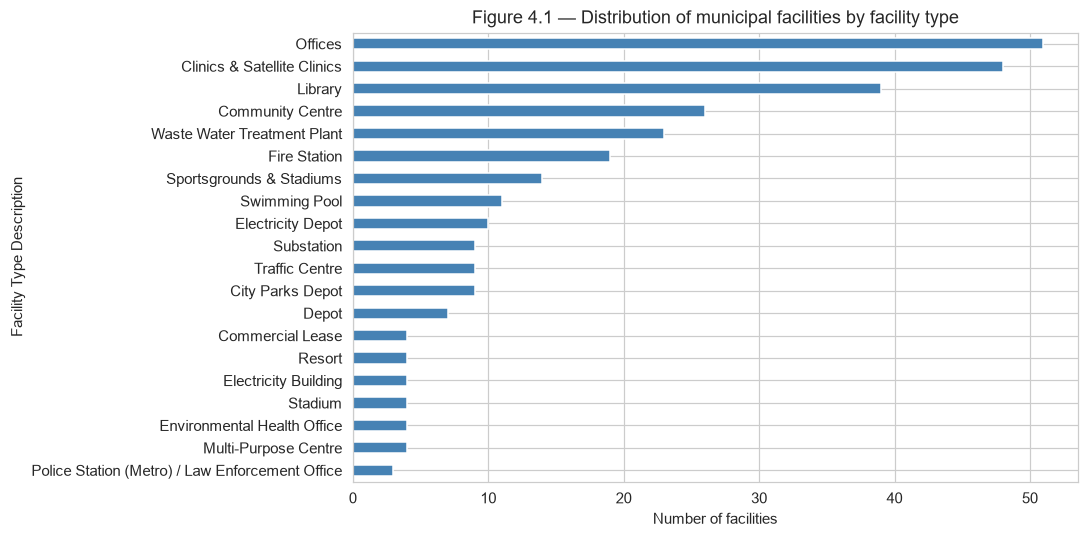

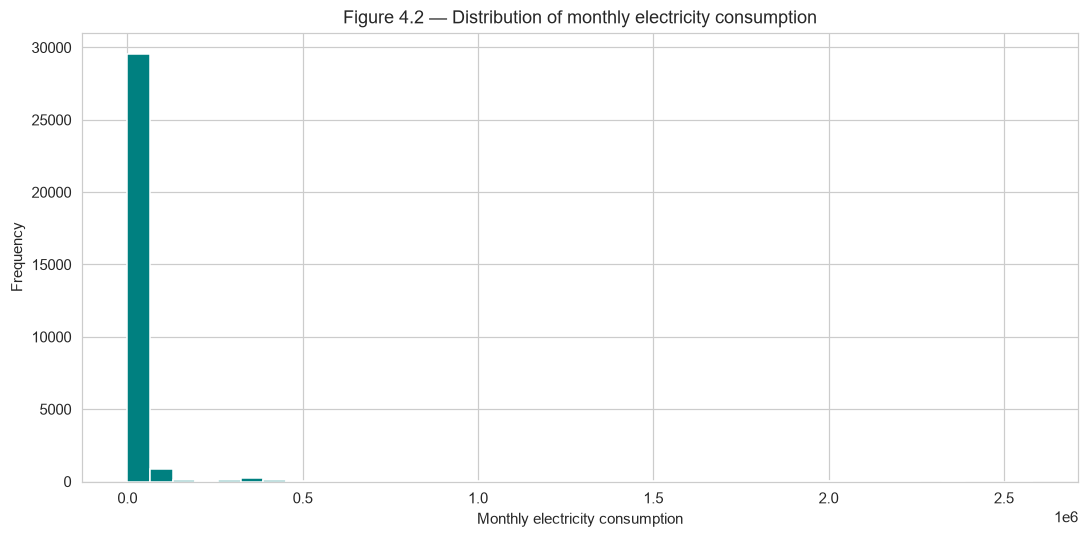

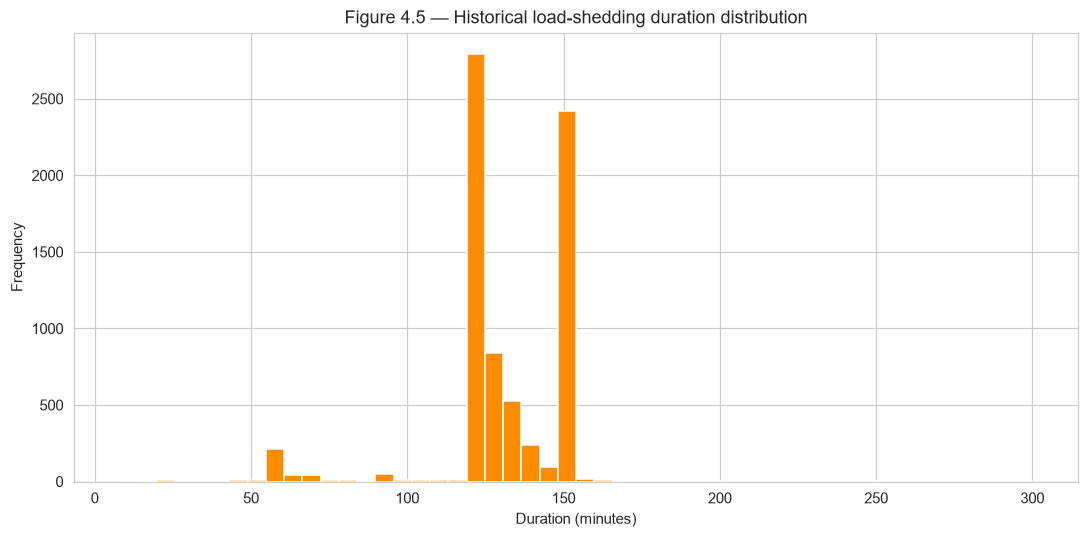

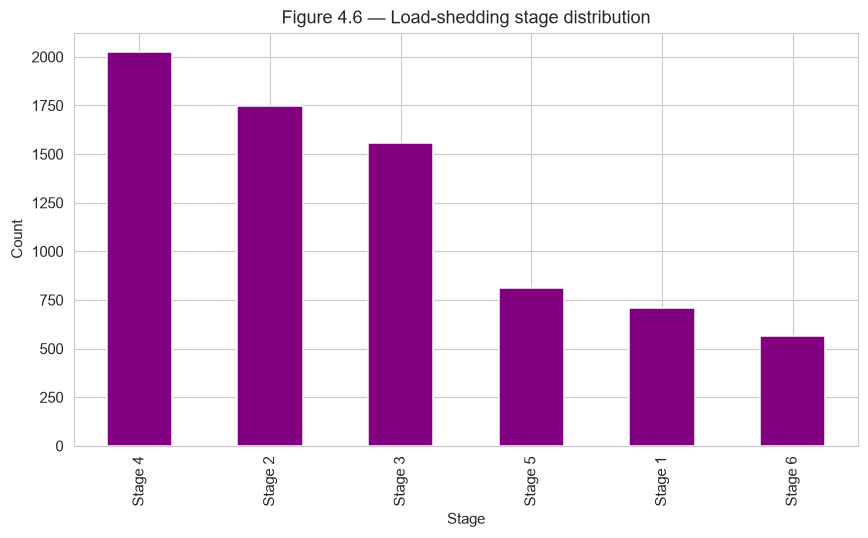

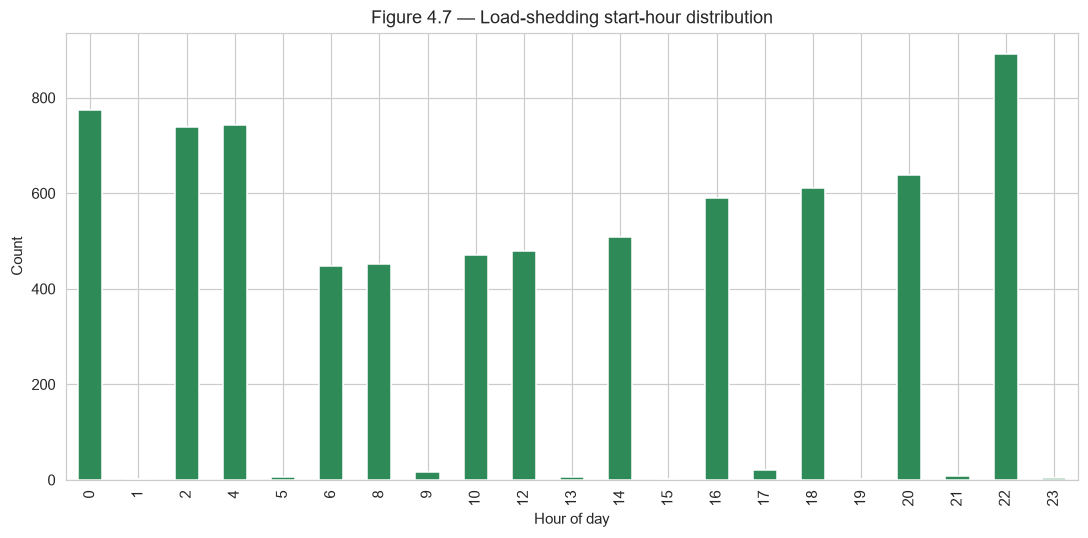

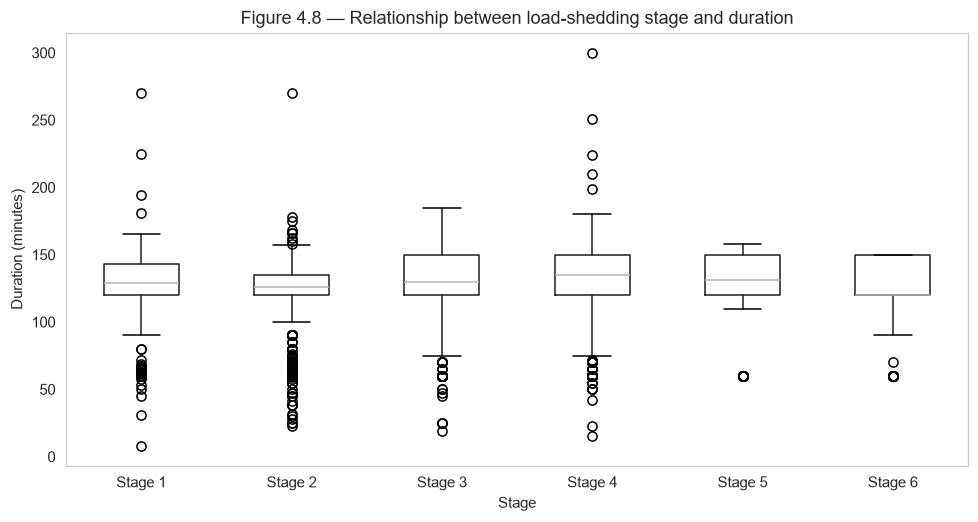

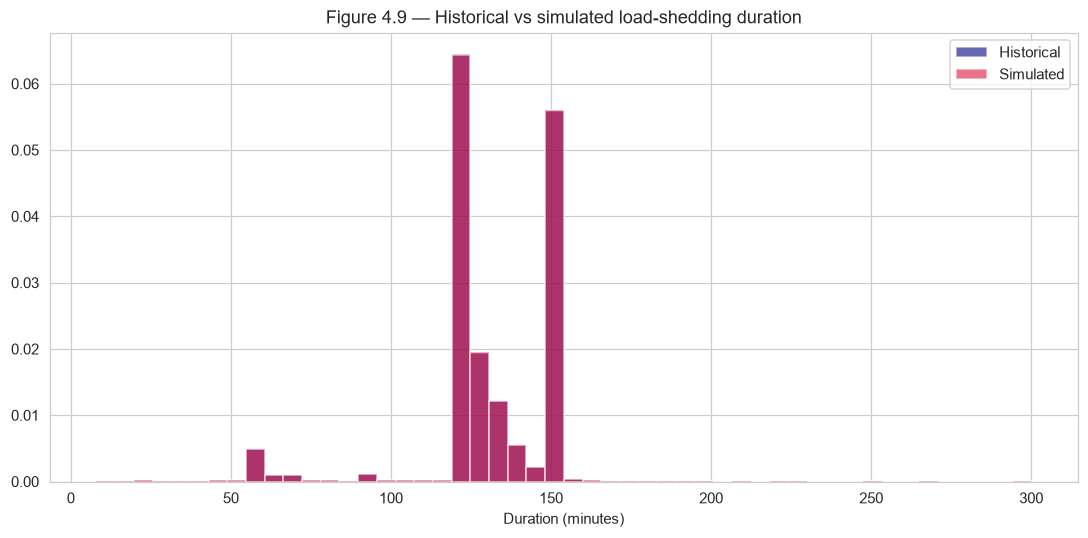

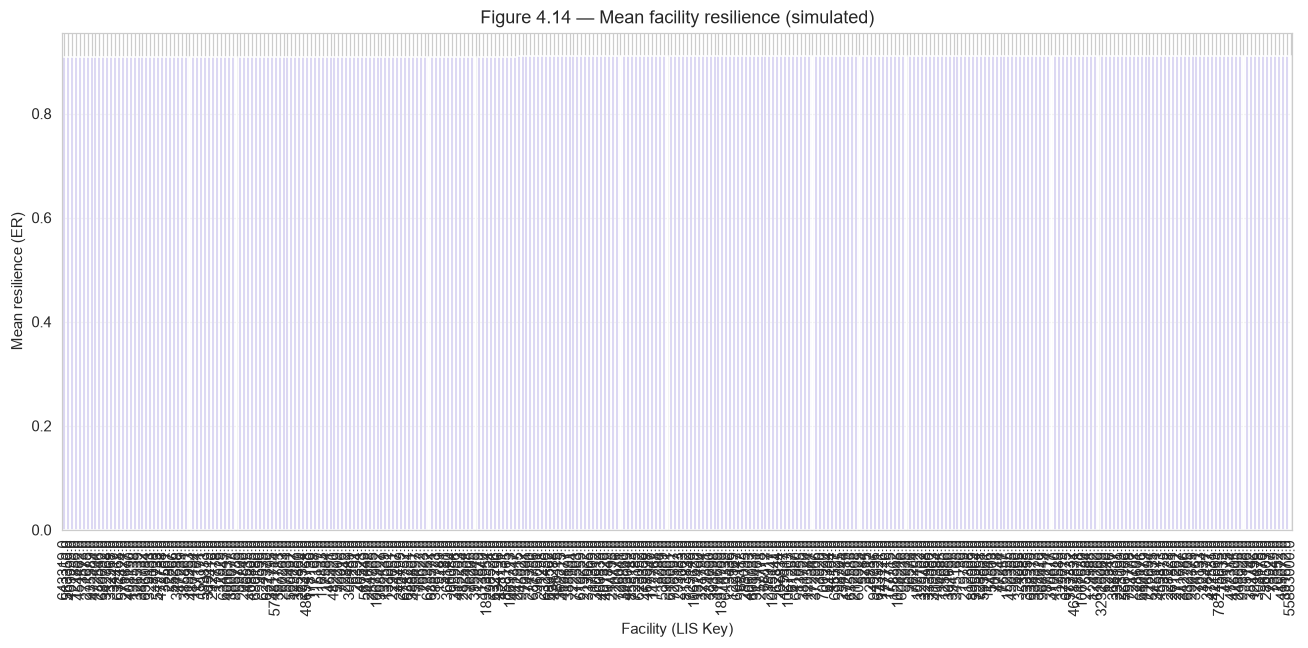

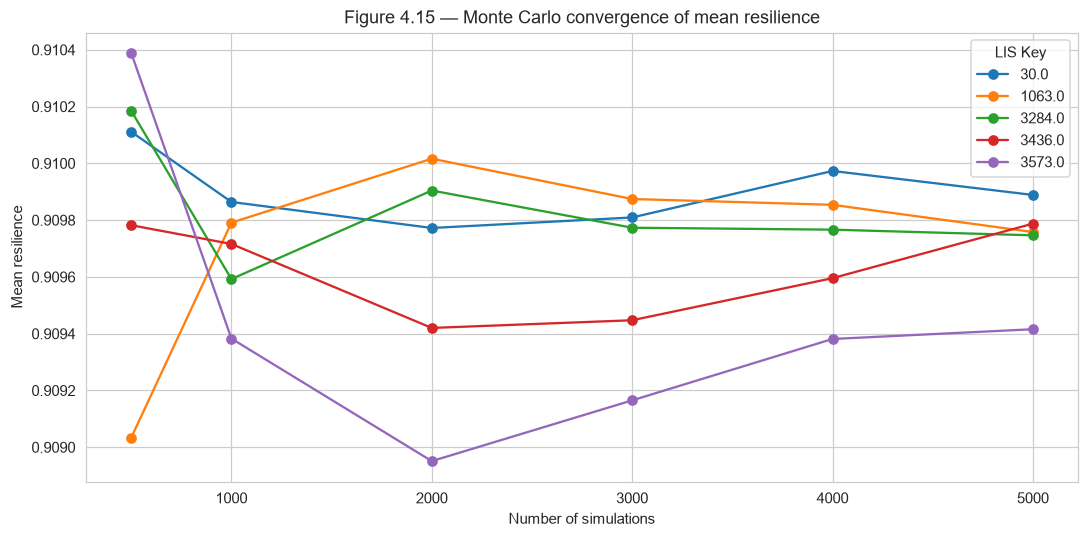

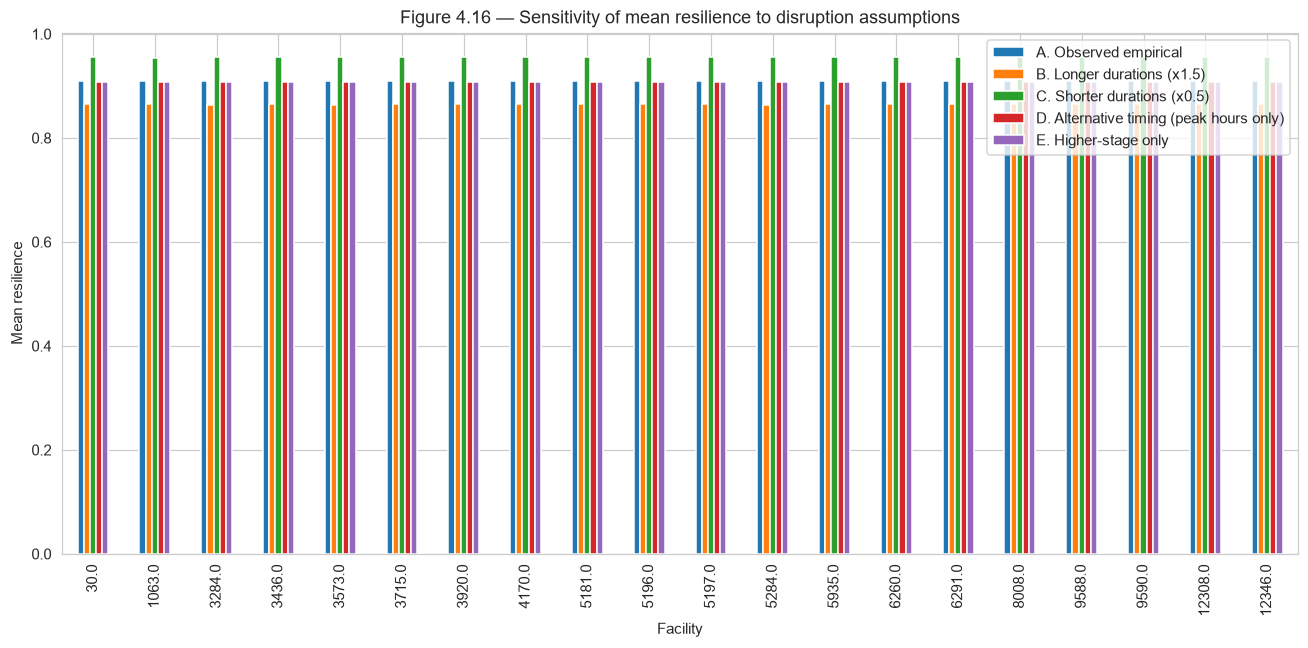


20. INTERACTIVE DIGITAL-TWIN MAP



21. FINAL SUMMARY

A. DATA AUDIT
  Facility rows          : 35,319
  Load-shedding rows     : 17,574
  Unique facilities      : 315
  Facility-month records : 30267

B. RQ1 — Normal energy-use profiles
  Facilities profiled: 315
  (no consumption column)

C. RQ2 — Load-shedding characteristics
  Events analysed: 7,416
  Mean duration: 129.92 min, median: 129.00 min

D. RQ3 — Resilience & vulnerability
  Facilities simulated: 314
  Scenarios per facility: 5,000
  Overall mean resilience: 0.9098
  Overall mean vulnerability: 0.0902
  Spatial crosswalk valid: False

[END OF ANALYSIS]


In [2]:
"""
================================================================================
DIGITAL TWIN-BASED STOCHASTIC ENERGY RESILIENCE MODELLING OF CAPE TOWN
MUNICIPAL FACILITIES UNDER LOAD SHEDDING
--------------------------------------------------------------------------------
Single-file analysis pipeline.

Research questions:
  RQ1: Energy-use profiles under normal operating conditions.
  RQ2: Effect of load-shedding timing/duration/stage on facility exposure.
  RQ3: Variation in energy resilience and vulnerability across facilities.

Rules enforced:
  - Row count != facility count != facility-month count.
  - No fabricated facility-to-circuit mapping.
  - No invented backup systems.
  - Simulated != observed.
  - Fixed random seed for reproducibility.

Run: python thesis_analysis.py
================================================================================
"""

# ------------------------------------------------------------------------------
# 0. CONFIGURATION
# ------------------------------------------------------------------------------
import os
import sys
import warnings
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

SEED = 42
rng = np.random.default_rng(SEED)

FACILITY_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\SmartFacility_Energy_FullNames.xlsx"
LOADSHED_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\Loadshedding_schedule.csv"

CROSSWALK_CANDIDATES = [
    r"C:\Users\Pc\Desktop\Masters Thesis\Facility_Circuit_Crosswalk.xlsx",
    r"C:\Users\Pc\Desktop\Masters Thesis\Facility_Circuit_Crosswalk.csv",
    r"C:\Users\Pc\Desktop\Masters Thesis\LISKey_Area_Mapping.xlsx",
    r"C:\Users\Pc\Desktop\Masters Thesis\LISKey_Area_Mapping.csv",
]

N_SIM = 5000
CONVERGENCE_STEPS = [500, 1000, 2000, 3000, 4000, 5000]

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


def hr(title):
    print("\n" + "=" * 78)
    print(title)
    print("=" * 78)


def section(label):
    print(f"\n--- {label} ---")


# ------------------------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------------------------
hr("1. LOADING RAW DATA")

if not os.path.exists(FACILITY_FILE):
    sys.exit(f"[FATAL] Facility file not found: {FACILITY_FILE}")
if not os.path.exists(LOADSHED_FILE):
    sys.exit(f"[FATAL] Load-shedding file not found: {LOADSHED_FILE}")

fac_raw = pd.read_excel(FACILITY_FILE)
ls_raw = pd.read_csv(LOADSHED_FILE)

print(f"Facility file rows: {len(fac_raw):,}  cols: {fac_raw.shape[1]}")
print(f"Load-shedding file rows: {len(ls_raw):,}  cols: {ls_raw.shape[1]}")

print("\nFacility columns:")
for c in fac_raw.columns:
    print("  -", c)
print("\nLoad-shedding columns:")
for c in ls_raw.columns:
    print("  -", c)


# ------------------------------------------------------------------------------
# 2. COLUMN ALIASES
# ------------------------------------------------------------------------------
def find_col(df, *candidates, required=True):
    lower = {c.lower().strip(): c for c in df.columns}
    for cand in candidates:
        key = cand.lower().strip()
        if key in lower:
            return lower[key]
    if required:
        raise KeyError(f"Required column not found among {candidates}. Available: {list(df.columns)}")
    return None


fac_cols = {
    "lis":        find_col(fac_raw, "LIS Key", "LIS_Key", "LISKey"),
    "name":       find_col(fac_raw, "Alternative Building Name", "Facility Name", required=False),
    "ftype":      find_col(fac_raw, "Facility Type Description", "Facility Type", required=False),
    "dept":       find_col(fac_raw, "Department Description", "Department", required=False),
    "lat":        find_col(fac_raw, "Facility Coordinate Latitude", "Latitude", required=False),
    "lon":        find_col(fac_raw, "Facility Coordinate Longitude", "Longitude", required=False),
    "space":      find_col(fac_raw, "SF Building Use Space", "Building Use Space", required=False),
    "year":       find_col(fac_raw, "Calendar Year", required=False),
    "month":      find_col(fac_raw, "Calendar Month Number", "Month", required=False),
    "month_date": find_col(fac_raw, "Monthly Date Recorded", required=False),
    "m_baseline": find_col(fac_raw, "Monthly Electricity Baseline", required=False),
    "m_cons":     find_col(fac_raw, "Monthly Electricity Consumption", required=False),
    "m_saving":   find_col(fac_raw, "Monthly Electricity Saving", required=False),
    "m_carbon":   find_col(fac_raw, "Monthly Carbon Emitted", required=False),
    "a_baseline": find_col(fac_raw, "Annual Electricity Baseline", required=False),
    "a_cons":     find_col(fac_raw, "Annual Electricity Consumption", required=False),
    "a_saving":   find_col(fac_raw, "Annual Electricity Saving", required=False),
    "benchmark":  find_col(fac_raw, "Annual Electricity Benchmark", required=False),
}

ls_cols = {
    "date":    find_col(ls_raw, "Date"),
    "time":    find_col(ls_raw, "Time", "Start Time"),
    "stage":   find_col(ls_raw, "Stage"),
    "circuit": find_col(ls_raw, "Circuit", "Area"),
    "minutes": find_col(ls_raw, "Minutes", "Duration"),
}


# ------------------------------------------------------------------------------
# 3. DATA AUDIT
# ------------------------------------------------------------------------------
hr("3. DATA AUDIT")

def audit_facility(df, cols):
    out = {"rows": len(df), "columns": df.shape[1],
           "unique_lis": df[cols["lis"]].nunique(dropna=True)}
    if cols["name"]:
        out["unique_names"] = df[cols["name"]].nunique(dropna=True)
    if cols["ftype"]:
        out["unique_ftypes"] = df[cols["ftype"]].nunique(dropna=True)
    if cols["dept"]:
        out["unique_depts"] = df[cols["dept"]].nunique(dropna=True)
    return out


def audit_ls(df, cols):
    return {"rows": len(df), "columns": df.shape[1],
            "unique_circuits": df[cols["circuit"]].nunique(dropna=True),
            "unique_stages": df[cols["stage"]].nunique(dropna=True)}


fa = audit_facility(fac_raw, fac_cols)
la = audit_ls(ls_raw, ls_cols)

print("FACILITY DATASET")
for k, v in fa.items():
    print(f"  {k}: {v}")
print("\nLOAD-SHEDDING DATASET")
for k, v in la.items():
    print(f"  {k}: {v}")

fm_count = None
if fac_cols["year"] and fac_cols["month"]:
    fac_raw["_ym"] = fac_raw[fac_cols["year"]].astype(str) + "-" + fac_raw[fac_cols["month"]].astype(str)
    fm_count = fac_raw.groupby([fac_cols["lis"], "_ym"]).ngroups
    print(f"\nFacility-month observations (LIS Key + Year + Month): {fm_count:,}")

ls_raw["_date"] = pd.to_datetime(ls_raw[ls_cols["date"]], errors="coerce", dayfirst=True)
print(f"Load-shedding date range: {ls_raw['_date'].min()} -> {ls_raw['_date'].max()}")
print(f"Unique dates: {ls_raw['_date'].nunique():,}")

section("Missing values — facility dataset")
mv_fac = fac_raw.isna().sum().sort_values(ascending=False)
print(mv_fac[mv_fac > 0] if (mv_fac > 0).any() else "  none")

section("Missing values — load-shedding dataset")
mv_ls = ls_raw.isna().sum().sort_values(ascending=False)
print(mv_ls[mv_ls > 0] if (mv_ls > 0).any() else "  none")

section("Duplicates")
fac_dups = fac_raw.duplicated().sum()
ls_dups = ls_raw.duplicated().sum()
print(f"Facility duplicate rows: {fac_dups:,} ({fac_dups/len(fac_raw)*100:.2f}%)")
print(f"Load-shedding duplicate rows: {ls_dups:,} ({ls_dups/len(ls_raw)*100:.2f}%)")

if fac_cols["year"] and fac_cols["month"]:
    fm_dups = fac_raw.duplicated(subset=[fac_cols["lis"], fac_cols["year"], fac_cols["month"]]).sum()
    print(f"Duplicate facility-month records: {fm_dups:,}")

section("Outage duration statistics (minutes)")
dur = pd.to_numeric(ls_raw[ls_cols["minutes"]], errors="coerce").dropna()
print(dur.describe().to_string())
print(f"  IQR: {dur.quantile(.75) - dur.quantile(.25):.2f}")

section("Stage distribution")
print(ls_raw[ls_cols["stage"]].value_counts(dropna=False).to_string())

section("Circuit distribution (top 20)")
print(ls_raw[ls_cols["circuit"]].value_counts(dropna=False).head(20).to_string())

section("Outage start-time distribution (hour)")
ls_raw["_hour"] = pd.to_datetime(ls_raw[ls_cols["time"]], errors="coerce").dt.hour
print(ls_raw["_hour"].value_counts().sort_index().to_string())

section("Observations by year")
ls_raw["_year"] = ls_raw["_date"].dt.year
print(ls_raw["_year"].value_counts().sort_index().to_string())


# ------------------------------------------------------------------------------
# 4. DATA QUALITY CONTROL
# ------------------------------------------------------------------------------
hr("4. DATA QUALITY CONTROL")

qc_log = []


def log_qc(variable, problem, n, treatment, reason):
    qc_log.append(dict(Variable=variable, Problem=problem, N=n,
                       Treatment=treatment, Reason=reason))


n = fac_raw[fac_cols["lis"]].isna().sum()
if n:
    log_qc("LIS Key", "Missing", n, "Drop rows", "Cannot identify facility")
fac = fac_raw.dropna(subset=[fac_cols["lis"]]).copy()

if fac_cols["name"]:
    n = fac[fac_cols["name"]].isna().sum()
    if n:
        log_qc("Facility Name", "Missing", n, "Retain", "LIS Key still identifies facility")

if fac_cols["lat"] and fac_cols["lon"]:
    lat = pd.to_numeric(fac[fac_cols["lat"]], errors="coerce")
    lon = pd.to_numeric(fac[fac_cols["lon"]], errors="coerce")
    invalid = ((lat < -90) | (lat > 90) | (lon < -180) | (lon > 180))
    n = int(invalid.sum())
    if n:
        log_qc("Coordinates", "Out of range", n, "Flag only (not dropped)",
               "May be genuine geocoding issues")
    fac["_invalid_coord"] = invalid

for key in ["m_cons", "m_baseline", "a_cons", "a_baseline", "space"]:
    c = fac_cols.get(key)
    if c:
        v = pd.to_numeric(fac[c], errors="coerce")
        n = int((v < 0).sum())
        if n:
            log_qc(c, "Negative values", n, "Retain, flagged",
                   "Possible meter resets / credits")

n = ls_raw["_date"].isna().sum()
if n:
    log_qc("Date", "Unparseable", int(n), "Drop rows", "Cannot use in simulation")
ls = ls_raw.dropna(subset=["_date"]).copy()

dur_all = pd.to_numeric(ls[ls_cols["minutes"]], errors="coerce")
n = int(((dur_all <= 0) | (dur_all > 24 * 60)).sum())
if n:
    log_qc("Minutes", "Implausible duration", n, "Retain, flagged",
           "Do not auto-delete unusual values")

print(pd.DataFrame(qc_log).to_string(index=False) if qc_log else "No QC issues flagged.")


# ------------------------------------------------------------------------------
# 5. UNIT OF ANALYSIS
# ------------------------------------------------------------------------------
hr("5. UNIT OF ANALYSIS")
print("Level 1 — Facility            : unique LIS Key")
print("Level 2 — Facility-month      : LIS Key + Calendar Year + Calendar Month")
print("Level 3 — Load-shedding event : Date + Time + Circuit + Stage")
print("\nRQ1  -> facility-month (aggregated to facility)")
print("RQ2  -> load-shedding event")
print("RQ3  -> facility (via simulation)")
print("Simulation -> facility x scenario")


# ------------------------------------------------------------------------------
# 6. FACILITY INVENTORY (RQ1)
# ------------------------------------------------------------------------------
hr("6. FACILITY INVENTORY")

facilities = fac.drop_duplicates(subset=[fac_cols["lis"]]).copy()
n_fac = len(facilities)
print(f"Physical facilities: {n_fac}")

if fac_cols["ftype"]:
    section("Table 3.3 — Facilities by Facility Type")
    t33 = (facilities[fac_cols["ftype"]].value_counts(dropna=False)
           .rename_axis("Facility Type").reset_index(name="Count"))
    t33["Share (%)"] = (t33["Count"] / t33["Count"].sum() * 100).round(2)
    print(t33.to_string(index=False))

if fac_cols["dept"]:
    section("Table 3.4 — Facilities by Department")
    t34 = (facilities[fac_cols["dept"]].value_counts(dropna=False)
           .rename_axis("Department").reset_index(name="Count"))
    t34["Share (%)"] = (t34["Count"] / t34["Count"].sum() * 100).round(2)
    print(t34.to_string(index=False))


# ------------------------------------------------------------------------------
# 7. NORMAL ENERGY PROFILES (RQ1)
# ------------------------------------------------------------------------------
hr("7. NORMAL ENERGY PROFILES")


def describe_series(s):
    s = pd.to_numeric(s, errors="coerce").dropna()
    if s.empty:
        return {}
    return dict(N=len(s), Mean=s.mean(), Median=s.median(), SD=s.std(),
                Min=s.min(), Max=s.max(), CV=(s.std() / s.mean() if s.mean() else np.nan))


section("Table 3.5 — Descriptive statistics of facility energy characteristics")
rows = []
for key in ["m_cons", "m_baseline", "m_saving", "a_cons", "a_baseline", "benchmark", "space"]:
    c = fac_cols.get(key)
    if c:
        d = describe_series(fac[c])
        if d:
            d["Variable"] = c
            rows.append(d)
t35 = pd.DataFrame(rows).set_index("Variable")
print(t35.to_string())

if fac_cols["space"] and fac_cols["m_cons"]:
    fac["_space"] = pd.to_numeric(fac[fac_cols["space"]], errors="coerce")
    fac["_mcons"] = pd.to_numeric(fac[fac_cols["m_cons"]], errors="coerce")
    valid = (fac["_space"] > 0) & fac["_mcons"].notna()
    fac.loc[valid, "EUI"] = fac.loc[valid, "_mcons"] / fac.loc[valid, "_space"]
    print(f"\nEUI computed on {valid.sum():,} rows (unit: consumption units per SF building-use space).")
    print(f"EUI describe:\n{fac['EUI'].describe().to_string()}")

agg_spec = {}
for k in ["m_cons", "m_baseline", "m_saving", "a_cons", "a_baseline", "benchmark", "space"]:
    c = fac_cols.get(k)
    if c:
        fac[c] = pd.to_numeric(fac[c], errors="coerce")
        agg_spec[c] = ["mean", "median", "std", "min", "max"]

facility_agg = fac.groupby(fac_cols["lis"]).agg(agg_spec)
facility_agg.columns = ["_".join([c, s]).strip() for c, s in facility_agg.columns]
facility_agg["n_months"] = fac.groupby(fac_cols["lis"]).size()

if fac_cols["m_baseline"] and fac_cols["m_cons"]:
    fac["_baseline_gap"] = fac[fac_cols["m_baseline"]] - fac[fac_cols["m_cons"]]
    bg = fac.groupby(fac_cols["lis"])["_baseline_gap"].mean().rename("mean_baseline_gap")
    facility_agg = facility_agg.join(bg)

if fac_cols["benchmark"] and fac_cols["a_cons"]:
    fac["_bench_dev"] = fac[fac_cols["a_cons"]] - fac[fac_cols["benchmark"]]
    bd = fac.groupby(fac_cols["lis"])["_bench_dev"].mean().rename("mean_benchmark_deviation")
    facility_agg = facility_agg.join(bd)

if "EUI" in fac.columns:
    eui_mean = fac.groupby(fac_cols["lis"])["EUI"].mean().rename("mean_EUI")
    facility_agg = facility_agg.join(eui_mean)

section("Table 3.6 — Facility-level energy performance statistics (first 15 rows)")
print(facility_agg.head(15).to_string())


# ------------------------------------------------------------------------------
# 8. FACILITY ENERGY CLUSTERING (exploratory)
# ------------------------------------------------------------------------------
hr("8. FACILITY ENERGY CLUSTERING (exploratory)")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_vars = [c for c in facility_agg.columns
                if any(k in c for k in ["m_cons_mean", "m_baseline_mean", "space_mean",
                                        "m_cons_std", "mean_EUI"])]
cluster_vars = [c for c in cluster_vars
                if facility_agg[c].notna().sum() >= max(5, 0.5 * len(facility_agg))]

if len(cluster_vars) >= 2 and len(facility_agg) >= 6:
    X = facility_agg[cluster_vars].dropna()
    if len(X) >= 6:
        Xs = StandardScaler().fit_transform(X)
        scores = {}
        for k in range(2, min(6, len(X))):
            km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(Xs)
            scores[k] = silhouette_score(Xs, km.labels_)
        print("Silhouette scores by k:", {k: round(v, 3) for k, v in scores.items()})
        best_k = max(scores, key=scores.get)
        print(f"Selected k = {best_k} (highest silhouette)")
        km = KMeans(n_clusters=best_k, random_state=SEED, n_init=10).fit(Xs)
        facility_agg.loc[X.index, "cluster"] = km.labels_
        print(facility_agg["cluster"].value_counts().sort_index().to_string())
    else:
        print("Too few complete rows for clustering — skipped.")
else:
    print("Insufficient overlapping variables/facilities for clustering — skipped.")


# ------------------------------------------------------------------------------
# 9. LOAD-SHEDDING CHARACTERISATION (RQ2)
# ------------------------------------------------------------------------------
hr("9. LOAD-SHEDDING CHARACTERISATION")

ls["_minutes"] = pd.to_numeric(ls[ls_cols["minutes"]], errors="coerce")
ls["_hour"] = pd.to_datetime(ls[ls_cols["time"]], errors="coerce").dt.hour
ls["_dow"] = ls["_date"].dt.dayofweek
ls["_month"] = ls["_date"].dt.month
ls["_year"] = ls["_date"].dt.year

section("Table 3.7 — Historical load-shedding characteristics")
t37 = pd.DataFrame({
    "Metric": ["Records", "Unique dates", "Unique circuits", "Unique stages",
               "Duration mean (min)", "Duration median (min)", "Duration SD (min)",
               "Duration min (min)", "Duration max (min)"],
    "Value": [len(ls), ls["_date"].nunique(), ls[ls_cols["circuit"]].nunique(),
              ls[ls_cols["stage"]].nunique(),
              ls["_minutes"].mean(), ls["_minutes"].median(), ls["_minutes"].std(),
              ls["_minutes"].min(), ls["_minutes"].max()]
})
print(t37.to_string(index=False))

section("Table 3.8 — Load-shedding duration by stage")
t38 = ls.groupby(ls_cols["stage"])["_minutes"].agg(["count", "mean", "median", "std", "min", "max"])
print(t38.to_string())

section("Table 3.9 — Load-shedding timing characteristics")
t39 = pd.DataFrame({
    "Hour": ls["_hour"].value_counts().sort_index(),
    "Month": ls["_month"].value_counts().sort_index(),
    "DayOfWeek": ls["_dow"].value_counts().sort_index()
})
print(t39.to_string())

section("Dependence between stage / timing / duration")
sub = ls.dropna(subset=[ls_cols["stage"], "_minutes", "_hour"]).copy()
groups = [g["_minutes"].values for _, g in sub.groupby(ls_cols["stage"]) if len(g) >= 3]
if len(groups) >= 2:
    kw = stats.kruskal(*groups)
    print(f"Kruskal-Wallis (duration by stage): H={kw.statistic:.3f}, p={kw.pvalue:.4g}")

sub["_timeblock"] = pd.cut(sub["_hour"], bins=[-1, 5, 11, 17, 23],
                           labels=["Night", "Morning", "Afternoon", "Evening"])
ct = pd.crosstab(sub[ls_cols["stage"]], sub["_timeblock"])
if ct.size and ct.values.sum() > 0:
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    print(f"Chi-square (stage x time block): chi2={chi2:.3f}, p={p:.4g}, dof={dof}")

rho, p = stats.spearmanr(sub["_hour"], sub["_minutes"], nan_policy="omit")
print(f"Spearman (hour vs duration): rho={rho:.3f}, p={p:.4g}")


# ------------------------------------------------------------------------------
# 10. CRITICAL SPATIAL LINKAGE CHECK
# ------------------------------------------------------------------------------
hr("10. FACILITY -> LOAD-SHEDDING CIRCUIT CROSSWALK CHECK")

crosswalk = None
for path in CROSSWALK_CANDIDATES:
    if os.path.exists(path):
        print(f"Found candidate crosswalk: {path}")
        crosswalk = pd.read_csv(path) if path.lower().endswith(".csv") else pd.read_excel(path)
        print(crosswalk.head().to_string())
        break

if crosswalk is None:
    print("\n>>> No reliable facility-to-load-shedding-circuit crosswalk was found.")
    print(">>> The available datasets do not provide sufficient evidence to establish")
    print(">>> a direct facility-to-load-shedding-circuit relationship.")
    print(">>> The stochastic model is therefore developed at the DISRUPTION-ENVIRONMENT level.")
    print(">>> Facilities are evaluated under representative historical disruption conditions,")
    print(">>> NOT under circuit-specific assignments.")
    FACILITY_TO_CIRCUIT_VALID = False
else:
    print("\nCrosswalk loaded — integration is permitted at the circuit level.")
    FACILITY_TO_CIRCUIT_VALID = True


# ------------------------------------------------------------------------------
# 11. STOCHASTIC MODEL — empirical joint sampling of historical events
# ------------------------------------------------------------------------------
hr("11. STOCHASTIC MODEL DESIGN")

events = ls[[ls_cols["stage"], ls_cols["circuit"], "_minutes", "_hour", "_date", "_year"]].dropna(
    subset=[ls_cols["stage"], "_minutes", "_hour"]
).copy()
events["_minutes"] = events["_minutes"].clip(lower=1)
print(f"Empirical event pool: {len(events):,} events")

event_idx = np.arange(len(events))


def sample_events(n, pool_indices):
    return events.iloc[rng.choice(pool_indices, size=n, replace=True)].reset_index(drop=True)


if fac_cols["m_cons"]:
    fac["_mcons"] = pd.to_numeric(fac[fac_cols["m_cons"]], errors="coerce")
    hourly_rate = (fac.groupby(fac_cols["lis"])["_mcons"].mean() / 730.0).rename("hourly_rate")
else:
    sys.exit("[FATAL] Monthly electricity consumption column not found; cannot model demand.")

hourly_rate.name = "hourly_rate"

print("\nModelling assumption: hourly demand = mean monthly consumption / 730 hours.")
print("Modelling assumption: during a load-shedding event, availability = 0 (no backup data).")


# ------------------------------------------------------------------------------
# 12. MONTE CARLO SIMULATION
# ------------------------------------------------------------------------------
hr(f"12. MONTE CARLO SIMULATION ({N_SIM:,} scenarios per facility)")

facility_ids = hourly_rate.index.tolist()
all_pool = event_idx

results = []

for fid in facility_ids:
    rate = hourly_rate.loc[fid]
    if not np.isfinite(rate) or rate <= 0:
        continue
    sampled = sample_events(N_SIM, all_pool)
    duration_h = sampled["_minutes"].values / 60.0
    E_normal = rate * duration_h
    E_avail = 0.0
    shortfall = E_normal - E_avail
    daily_ref = rate * 24.0
    EE = E_normal
    NEE = E_normal / daily_ref
    NES = shortfall / daily_ref
    V = NES
    ER = 1 - NES
    df_sim = pd.DataFrame({
        "LIS Key": fid,
        "scenario": np.arange(N_SIM),
        "stage": sampled[ls_cols["stage"]].values,
        "circuit": sampled[ls_cols["circuit"]].values,
        "start_hour": sampled["_hour"].values,
        "duration_min": sampled["_minutes"].values,
        "hourly_rate": rate,
        "EE": EE, "NEE": NEE, "ES": shortfall, "NES": NES,
        "V": V, "ER": ER,
    })
    results.append(df_sim)

sim = pd.concat(results, ignore_index=True)
print(f"Total simulated rows: {len(sim):,}")
print(f"Facilities simulated: {sim['LIS Key'].nunique()}")


# ------------------------------------------------------------------------------
# 13. RESILIENCE / VULNERABILITY / EXPOSURE STATISTICS
# ------------------------------------------------------------------------------
hr("13. FACILITY-LEVEL EXPOSURE, VULNERABILITY, RESILIENCE")


def q(s, p):
    return s.quantile(p)


stats_rows = []
for fid, g in sim.groupby("LIS Key"):
    stats_rows.append(dict(
        **{"LIS Key": fid},
        EE_mean=g["EE"].mean(), EE_median=g["EE"].median(),
        NEE_mean=g["NEE"].mean(),
        ES_mean=g["ES"].mean(),
        NES_mean=g["NES"].mean(),
        V_mean=g["V"].mean(), V_median=g["V"].median(), V_sd=g["V"].std(),
        ER_mean=g["ER"].mean(), ER_median=g["ER"].median(), ER_sd=g["ER"].std(),
        ER_min=g["ER"].min(), ER_max=g["ER"].max(),
        ER_p05=q(g["ER"], .05), ER_p10=q(g["ER"], .10), ER_p25=q(g["ER"], .25),
        ER_p75=q(g["ER"], .75), ER_p90=q(g["ER"], .90), ER_p95=q(g["ER"], .95),
    ))
fac_stats = pd.DataFrame(stats_rows).set_index("LIS Key")

# --- Facility metadata join (FIXED BLOCK) ---
meta = facilities.set_index(fac_cols["lis"]).copy()
meta = meta.rename(columns={
    fac_cols.get("name"): "Facility Name",
    fac_cols.get("ftype"): "Facility Type",
    fac_cols.get("dept"): "Department",
    fac_cols.get("lat"): "Latitude",
    fac_cols.get("lon"): "Longitude",
    fac_cols.get("space"): "Building Use Space",
}).reindex(fac_stats.index)

keep_meta = [c for c in ["Facility Name", "Facility Type", "Department",
                         "Latitude", "Longitude", "Building Use Space"]
             if c in meta.columns]
meta = meta[keep_meta]

fac_stats = fac_stats.join(meta)

# Explicitly-named Series (the previous fix)
normal_hourly_rate = hourly_rate.copy()
normal_hourly_rate.name = "normal_hourly_rate"
fac_stats = fac_stats.join(normal_hourly_rate)
# --- END FIXED BLOCK ---

section("Table 3.13 — Facility-level energy exposure (sample)")
print(fac_stats[["EE_mean", "NEE_mean"]].head(10).to_string())

section("Table 3.14 — Facility-level vulnerability (sample)")
print(fac_stats[["V_mean", "V_median", "V_sd"]].head(10).to_string())

section("Table 3.15 — Facility-level resilience (sample)")
print(fac_stats[["ER_mean", "ER_median", "ER_sd", "ER_p05", "ER_p95"]].head(10).to_string())


# ------------------------------------------------------------------------------
# 14. RESILIENCE CLASSIFICATION (quantile-based)
# ------------------------------------------------------------------------------
hr("14. RESILIENCE CLASSIFICATION (study-specific quantiles)")

fac_stats["Resilience Class"] = pd.qcut(
    fac_stats["ER_mean"], q=3,
    labels=["Lower resilience", "Intermediate resilience", "Higher resilience"]
)
section("Table 3.16 — Resilience classification")
print(fac_stats["Resilience Class"].value_counts().to_string())


# ------------------------------------------------------------------------------
# 15. MONTE CARLO CONVERGENCE
# ------------------------------------------------------------------------------
hr("15. MONTE CARLO CONVERGENCE")

conv_rows = []
for fid in facility_ids[:5]:
    g = sim[sim["LIS Key"] == fid]
    for n in CONVERGENCE_STEPS:
        if n > len(g):
            continue
        sub = g.iloc[:n]
        conv_rows.append(dict(
            **{"LIS Key": fid, "N": n},
            ER_mean=sub["ER"].mean(),
            ER_median=sub["ER"].median(),
            ER_sd=sub["ER"].std(),
            ER_p05=sub["ER"].quantile(.05),
            ER_p95=sub["ER"].quantile(.95),
        ))
conv = pd.DataFrame(conv_rows)
section("Table 3.11 — Monte Carlo convergence (first 5 facilities)")
print(conv.to_string(index=False))


# ------------------------------------------------------------------------------
# 16. VALIDATION — historical vs simulated disruption
# ------------------------------------------------------------------------------
hr("16. VALIDATION OF SIMULATED DISRUPTION")

hist_stage = ls[ls_cols["stage"]].value_counts(normalize=True).rename("Historical")
sim_stage = sim["stage"].value_counts(normalize=True).rename("Simulated")
stage_cmp = pd.concat([hist_stage, sim_stage], axis=1).fillna(0)
print("Stage distribution comparison:")
print(stage_cmp.round(4).to_string())

print("\nDuration comparison:")
print(pd.DataFrame({
    "Historical": ls["_minutes"].describe(),
    "Simulated": sim["duration_min"].describe()
}).to_string())


# ------------------------------------------------------------------------------
# 17. ROBUSTNESS — SENSITIVITY TO DISRUPTION CHARACTERISTICS
# ------------------------------------------------------------------------------
hr("17. ROBUSTNESS ANALYSIS")


def run_scenario(name, duration_transform=None, stage_filter=None, time_filter=None):
    pool = events.copy()
    if stage_filter is not None:
        pool = pool[pool[ls_cols["stage"]].isin(stage_filter)]
    if time_filter is not None:
        pool = pool[pool["_hour"].isin(time_filter)]
    if pool.empty:
        print(f"[{name}] empty pool — skipped")
        return None
    if duration_transform is not None:
        pool["_minutes"] = pool["_minutes"].apply(duration_transform).clip(lower=1)
    res = []
    for fid in facility_ids:
        rate = hourly_rate.loc[fid]
        if not np.isfinite(rate) or rate <= 0:
            continue
        idx = rng.choice(pool.index.values, size=N_SIM, replace=True)
        sampled = pool.loc[idx]
        E = rate * (sampled["_minutes"].values / 60.0)
        NES = E / (rate * 24.0)
        ER = 1 - NES
        res.append(pd.DataFrame({"LIS Key": fid, "ER": ER, "NES": NES}))
    s = pd.concat(res, ignore_index=True)
    return s.groupby("LIS Key")[["ER", "NES"]].mean()


scenarios = {
    "A. Observed empirical": run_scenario("A"),
    "B. Longer durations (x1.5)": run_scenario("B", duration_transform=lambda m: m * 1.5),
    "C. Shorter durations (x0.5)": run_scenario("C", duration_transform=lambda m: m * 0.5),
    "D. Alternative timing (peak hours only)":
        run_scenario("D", time_filter=list(range(6, 22))),
}

valid_stages = ls[ls_cols["stage"]].dropna().unique().tolist()
if len(valid_stages) >= 2:
    higher = [s for s in valid_stages if "4" in str(s)] or valid_stages[-1:]
    scenarios["E. Higher-stage only"] = run_scenario("E", stage_filter=higher)

sens = pd.DataFrame({k: v["ER"] for k, v in scenarios.items() if v is not None})
sens.index.name = "LIS Key"

section("Table 3.17 — Sensitivity of mean resilience to disruption characteristics")
print(sens.head(15).round(4).to_string())

if len(sens.columns) >= 2:
    base = sens.iloc[:, 0]
    for c in sens.columns[1:]:
        rho, p = stats.spearmanr(base, sens[c], nan_policy="omit")
        print(f"Rank correlation base vs '{c}': rho={rho:.3f}, p={p:.4g}")


# ------------------------------------------------------------------------------
# 18. ASSOCIATION BETWEEN FACILITY CHARACTERISTICS AND RESILIENCE
# ------------------------------------------------------------------------------
hr("18. ASSOCIATION WITH RESILIENCE")

import statsmodels.api as sm

model_df = fac_stats.copy()
model_df = model_df.rename(columns={
    "Facility Type": "ftype",
    "Department": "dept",
    "Building Use Space": "space",
})

pred_cols = []
if "normal_hourly_rate" in model_df.columns:
    pred_cols.append("normal_hourly_rate")
if "space" in model_df.columns:
    pred_cols.append("space")
if "mean_EUI" in model_df.columns:
    pred_cols.append("mean_EUI")

model_df = model_df.dropna(subset=["ER_mean"] + [c for c in pred_cols if c in model_df.columns])

if len(model_df) >= 10 and pred_cols:
    X = model_df[pred_cols].copy()
    X = sm.add_constant(X)
    y = model_df["ER_mean"]
    try:
        ols = sm.OLS(y, X).fit()
        print("OLS on mean resilience:")
        print(ols.summary())
    except Exception as e:
        print(f"OLS failed: {e}")
else:
    print("Insufficient data for multivariate model — skipped.")


# ------------------------------------------------------------------------------
# 19. FIGURES
# ------------------------------------------------------------------------------
hr("19. FIGURES")

if fac_cols["ftype"]:
    fig, ax = plt.subplots(figsize=(10, 5))
    facilities[fac_cols["ftype"]].value_counts().head(20).plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title("Figure 4.1 — Distribution of municipal facilities by facility type")
    ax.set_xlabel("Number of facilities")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

if fac_cols["m_cons"]:
    fig, ax = plt.subplots(figsize=(10, 5))
    pd.to_numeric(fac[fac_cols["m_cons"]], errors="coerce").dropna().hist(bins=40, ax=ax, color="teal")
    ax.set_title("Figure 4.2 — Distribution of monthly electricity consumption")
    ax.set_xlabel("Monthly electricity consumption")
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ls["_minutes"].dropna().hist(bins=50, ax=ax, color="darkorange")
ax.set_title("Figure 4.5 — Historical load-shedding duration distribution")
ax.set_xlabel("Duration (minutes)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ls[ls_cols["stage"]].value_counts().plot(kind="bar", ax=ax, color="purple")
ax.set_title("Figure 4.6 — Load-shedding stage distribution")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ls["_hour"].dropna().astype(int).value_counts().sort_index().plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Figure 4.7 — Load-shedding start-hour distribution")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ls.boxplot(column="_minutes", by=ls_cols["stage"], ax=ax, grid=False)
ax.set_title("Figure 4.8 — Relationship between load-shedding stage and duration")
ax.set_xlabel("Stage")
ax.set_ylabel("Duration (minutes)")
plt.suptitle("")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ls["_minutes"].dropna(), bins=50, alpha=0.6, label="Historical", density=True, color="navy")
ax.hist(sim["duration_min"], bins=50, alpha=0.6, label="Simulated", density=True, color="crimson")
ax.set_title("Figure 4.9 — Historical vs simulated load-shedding duration")
ax.set_xlabel("Duration (minutes)")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
fac_stats["ER_mean"].sort_values().plot(kind="bar", ax=ax, color="slateblue")
ax.set_title("Figure 4.14 — Mean facility resilience (simulated)")
ax.set_ylabel("Mean resilience (ER)")
ax.set_xlabel("Facility (LIS Key)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
for fid in conv["LIS Key"].unique()[:5]:
    sub = conv[conv["LIS Key"] == fid]
    ax.plot(sub["N"], sub["ER_mean"], marker="o", label=str(fid))
ax.set_title("Figure 4.15 — Monte Carlo convergence of mean resilience")
ax.set_xlabel("Number of simulations")
ax.set_ylabel("Mean resilience")
ax.legend(title="LIS Key")
plt.tight_layout()
plt.show()

if not sens.empty:
    fig, ax = plt.subplots(figsize=(12, 6))
    sens.head(20).plot(kind="bar", ax=ax)
    ax.set_title("Figure 4.16 — Sensitivity of mean resilience to disruption assumptions")
    ax.set_ylabel("Mean resilience")
    ax.set_xlabel("Facility")
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------------------------
# 20. INTERACTIVE MAP
# ------------------------------------------------------------------------------
hr("20. INTERACTIVE DIGITAL-TWIN MAP")

try:
    import plotly.express as px

    map_df = fac_stats.reset_index().copy()
    if "Latitude" in map_df.columns and "Longitude" in map_df.columns:
        map_df["Latitude"] = pd.to_numeric(map_df["Latitude"], errors="coerce")
        map_df["Longitude"] = pd.to_numeric(map_df["Longitude"], errors="coerce")
        map_df = map_df.dropna(subset=["Latitude", "Longitude"])

        if len(map_df) > 0:
            map_df["ER_p05_str"] = map_df["ER_p05"].round(3)
            map_df["ER_p95_str"] = map_df["ER_p95"].round(3)

            fig = px.scatter_mapbox(
                map_df,
                lat="Latitude", lon="Longitude",
                color="Resilience Class",
                size="normal_hourly_rate",
                hover_name="Facility Name" if "Facility Name" in map_df.columns else None,
                hover_data={
                    "LIS Key": True,
                    **({"Facility Type": True} if "Facility Type" in map_df.columns else {}),
                    **({"Department": True} if "Department" in map_df.columns else {}),
                    **({"Building Use Space": True} if "Building Use Space" in map_df.columns else {}),
                    "ER_mean": ":.3f",
                    "ER_p05_str": True,
                    "ER_p95_str": True,
                    "Resilience Class": True,
                    "Latitude": False,
                    "Longitude": False,
                },
                zoom=10, height=700,
                title="Figure 4.18 — Interactive municipal facility resilience map",
                mapbox_style="open-street-map",
            )
            fig.show()
        else:
            print("No valid coordinates — map skipped.")
    else:
        print("Latitude/Longitude columns missing — map skipped.")
except Exception as e:
    print(f"Interactive map failed: {e}")


# ------------------------------------------------------------------------------
# 21. FINAL SUMMARY
# ------------------------------------------------------------------------------
hr("21. FINAL SUMMARY")

print("\nA. DATA AUDIT")
print(f"  Facility rows          : {len(fac_raw):,}")
print(f"  Load-shedding rows     : {len(ls_raw):,}")
print(f"  Unique facilities      : {fa['unique_lis']:,}")
print(f"  Facility-month records : {fm_count if fm_count is not None else 'n/a'}")

print("\nB. RQ1 — Normal energy-use profiles")
print(f"  Facilities profiled: {len(facility_agg)}")
if any("m_cons_mean" in c for c in facility_agg.columns):
    m = facility_agg.filter(like="m_cons_mean").mean().iloc[0]
    print(f"  Mean monthly consumption (aggregated): {m:.2f}")
else:
    print("  (no consumption column)")

print("\nC. RQ2 — Load-shedding characteristics")
print(f"  Events analysed: {len(ls):,}")
print(f"  Mean duration: {ls['_minutes'].mean():.2f} min, median: {ls['_minutes'].median():.2f} min")

print("\nD. RQ3 — Resilience & vulnerability")
print(f"  Facilities simulated: {sim['LIS Key'].nunique()}")
print(f"  Scenarios per facility: {N_SIM:,}")
print(f"  Overall mean resilience: {sim['ER'].mean():.4f}")
print(f"  Overall mean vulnerability: {sim['V'].mean():.4f}")
print(f"  Spatial crosswalk valid: {FACILITY_TO_CIRCUIT_VALID}")

print("\n[END OF ANALYSIS]")

Historical n = 17,574
Simulated  n = 1,570,000

Historical: {'n': 17574, 'mean': np.float64(129.09599408216684), 'median': np.float64(125.0), 'sd': np.float64(21.458508700017195), 'q25': np.float64(120.0), 'q75': np.float64(150.0), 'min': np.float64(2.0), 'max': np.float64(600.0)}
Simulated : {'n': 1570000, 'mean': np.float64(129.93458917197452), 'median': np.float64(129.0), 'sd': np.float64(21.167412186160703), 'q25': np.float64(120.0), 'q75': np.float64(150.0), 'min': np.float64(8.0), 'max': np.float64(300.0)}

Mean difference: 0.8386 minutes


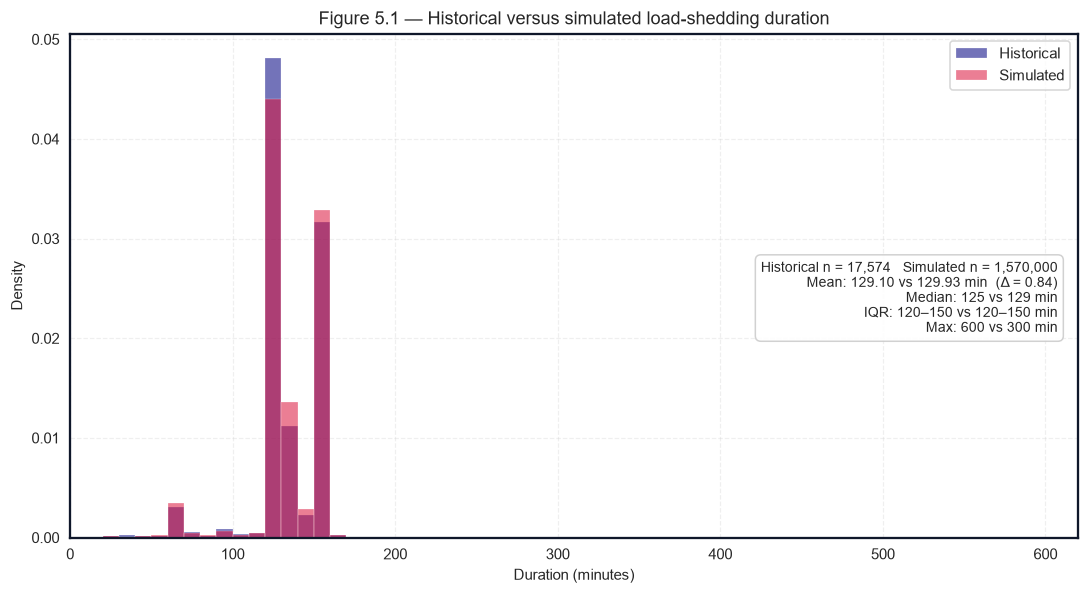

In [51]:
"""
Figure 5.1 — Historical vs simulated load-shedding duration
Requires: ls (historical load-shedding DataFrame) and sim (simulated scenarios)
Both are produced by the main analysis pipeline.
"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---- Extract the two duration series ----
historical = pd.to_numeric(ls["_minutes"], errors="coerce").dropna().values
simulated  = pd.to_numeric(sim["duration_min"], errors="coerce").dropna().values

print(f"Historical n = {len(historical):,}")
print(f"Simulated  n = {len(simulated):,}")

# ---- Summary statistics for the caption ----
def describe(x):
    return {
        "n": len(x),
        "mean": np.mean(x),
        "median": np.median(x),
        "sd": np.std(x, ddof=1),
        "q25": np.percentile(x, 25),
        "q75": np.percentile(x, 75),
        "min": np.min(x),
        "max": np.max(x),
    }

h = describe(historical)
s = describe(simulated)

print("\nHistorical:", h)
print("Simulated :", s)
print(f"\nMean difference: {abs(h['mean'] - s['mean']):.4f} minutes")

# ---- Figure 5.1 ----
fig, ax = plt.subplots(figsize=(10, 5.5))

bins = np.arange(0, 620, 10)

ax.hist(historical, bins=bins, density=True,
        alpha=0.55, color="navy", label="Historical", edgecolor="white", linewidth=0.3)
ax.hist(simulated,  bins=bins, density=True,
        alpha=0.55, color="crimson", label="Simulated", edgecolor="white", linewidth=0.3)

ax.set_title("Figure 5.1 — Historical versus simulated load-shedding duration",
             fontsize=12)
ax.set_xlabel("Duration (minutes)")
ax.set_ylabel("Density")
ax.legend(loc="upper right", frameon=True)
ax.set_xlim(0, 620)
ax.grid(alpha=0.3, linestyle="--")

# Annotate the summary comparison
text = (
    f"Historical n = {h['n']:,}   Simulated n = {s['n']:,}\n"
    f"Mean: {h['mean']:.2f} vs {s['mean']:.2f} min  (Δ = {abs(h['mean']-s['mean']):.2f})\n"
    f"Median: {h['median']:.0f} vs {s['median']:.0f} min\n"
    f"IQR: {h['q25']:.0f}–{h['q75']:.0f} vs {s['q25']:.0f}–{s['q75']:.0f} min\n"
    f"Max: {h['max']:.0f} vs {s['max']:.0f} min"
)
ax.text(0.98, 0.55, text, transform=ax.transAxes,
        fontsize=9, ha="right", va="top",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor="#cccccc", alpha=0.9))

plt.tight_layout()
plt.show()


1. LOADING RAW DATA
Facility rows: 35,319  cols: 26
Load-shedding rows: 17,574  cols: 5

2. LOAD-SHEDDING DATE FORMAT DIAGNOSIS

Date column — 17,574 non-null values
First 10 raw values:
    '2020-01-04'
    '2020-01-04'
    '2020-01-05'
    '2020-01-05'
    '2020-01-05'
    '2020-01-05'
    '2020-01-05'
    '2020-01-05'
    '2020-01-05'
    '2020-01-05'
  matches YYYY-MM-DD        :  17,574  (100.0%)
  matches YYYY/MM/DD        :       0  (  0.0%)
  matches DD-MM-YYYY        :       0  (  0.0%)
  matches DD/MM/YYYY        :       0  (  0.0%)
  matches DD-MM-YY          :       0  (  0.0%)
  matches MM/DD/YYYY        :       0  (  0.0%)
  matches Timestamp w/ T    :       0  (  0.0%)
  matches With time         :       0  (  0.0%)

Parsing success by strategy:
  dayfirst=True         :   7,416 / 17,574  ( 42.2%)
  dayfirst=False        :  17,574 / 17,574  (100.0%)
  format=%Y-%m-%d       :  17,574 / 17,574  (100.0%)
  format=%d/%m/%Y       :       0 / 17,574  (  0.0%)
  format=%d-%m-%

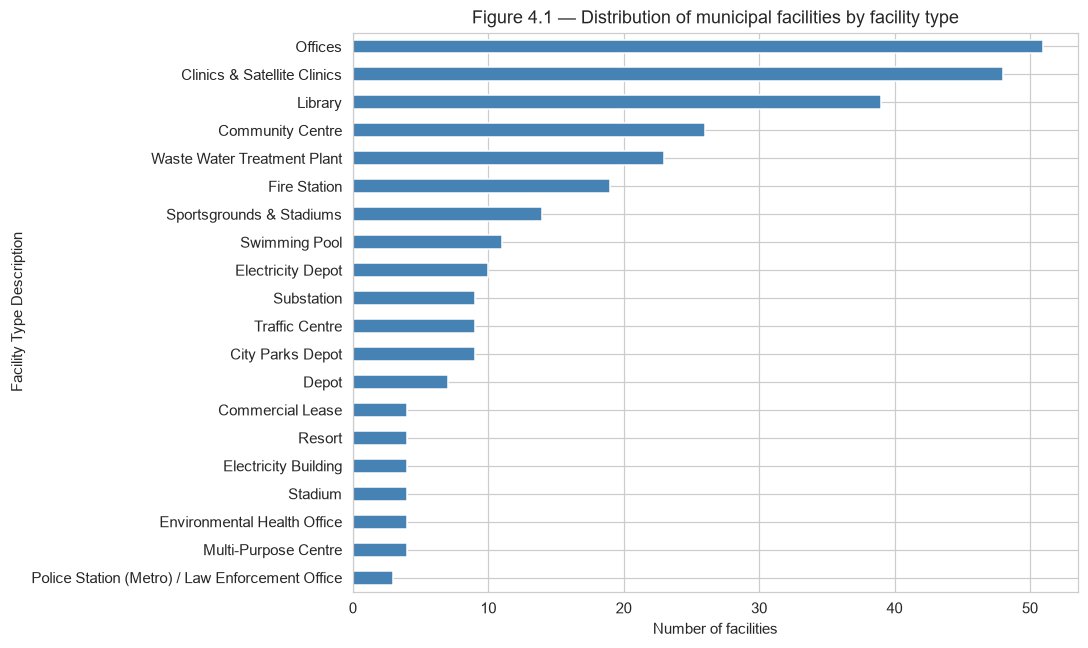

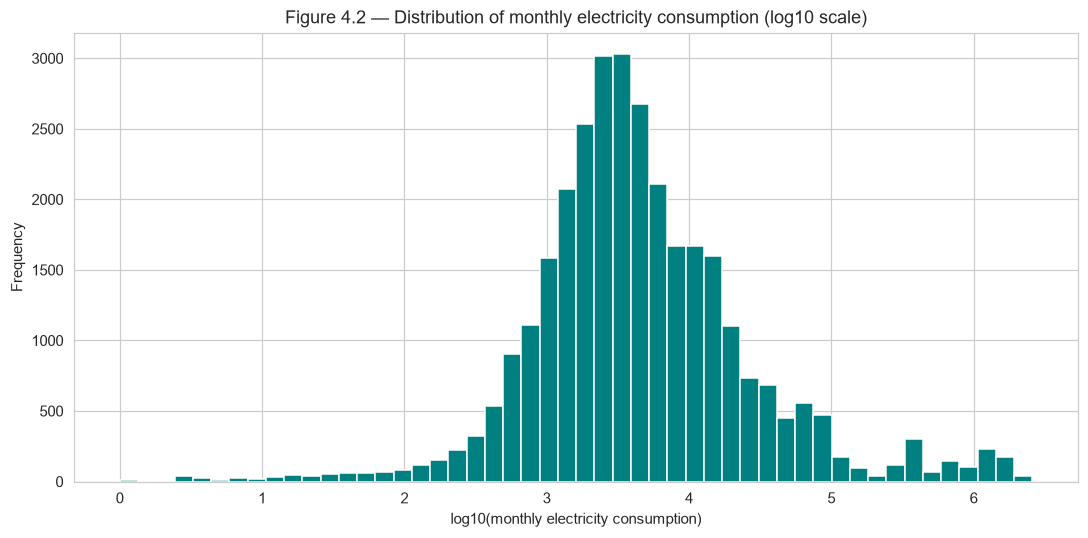

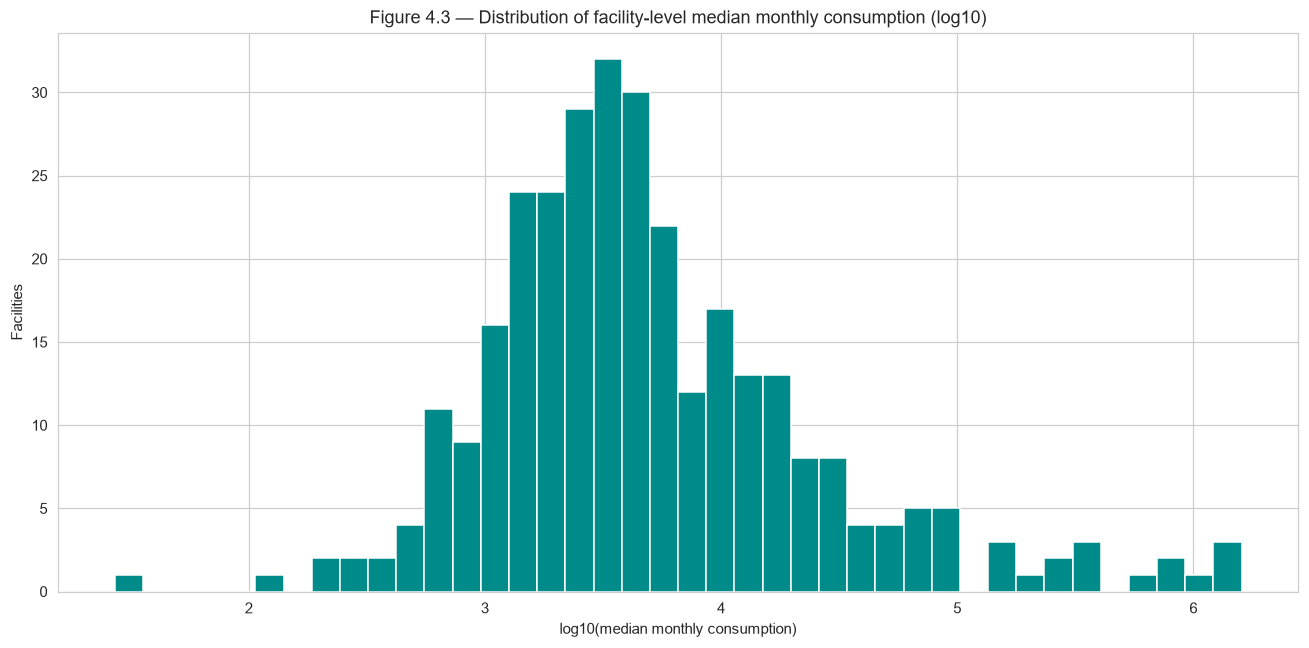

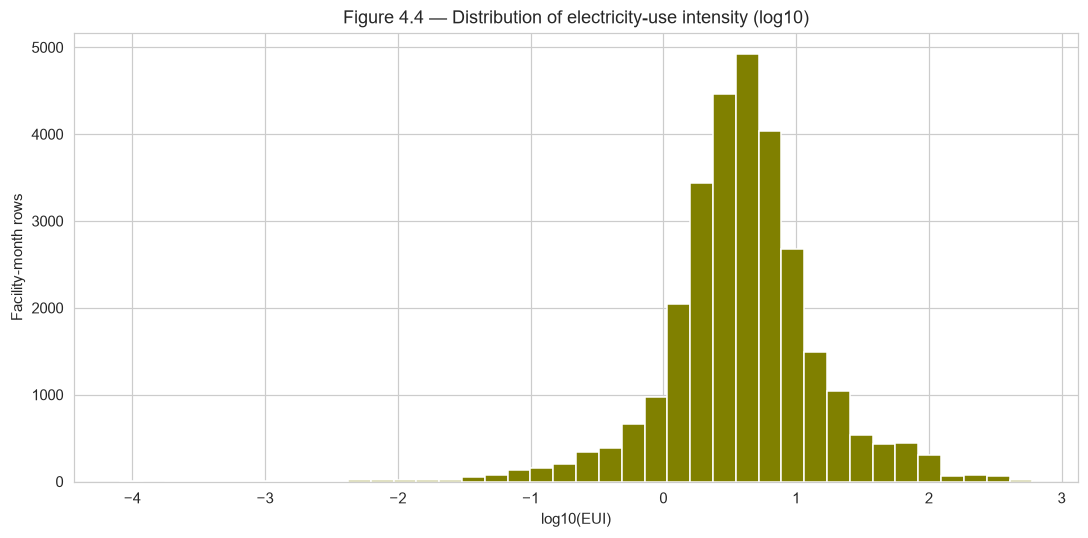

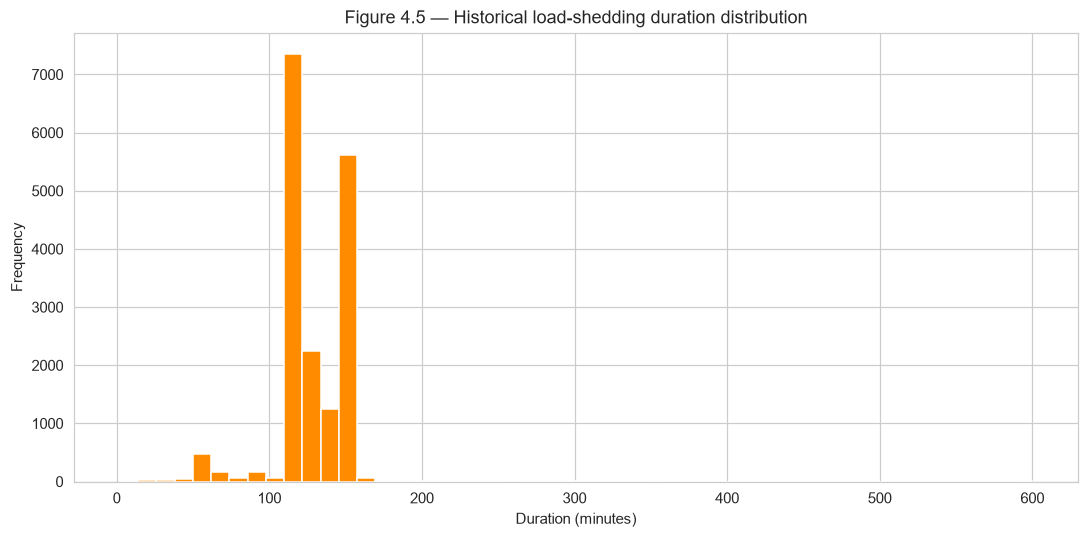

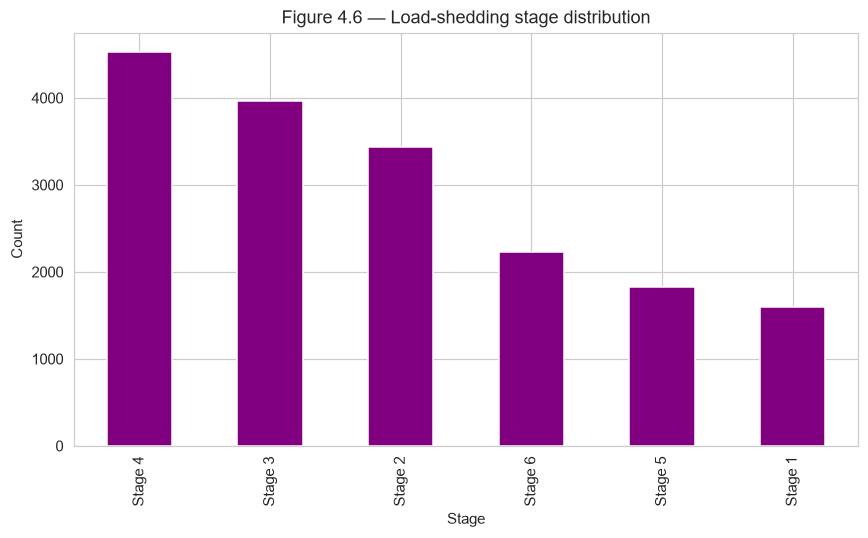

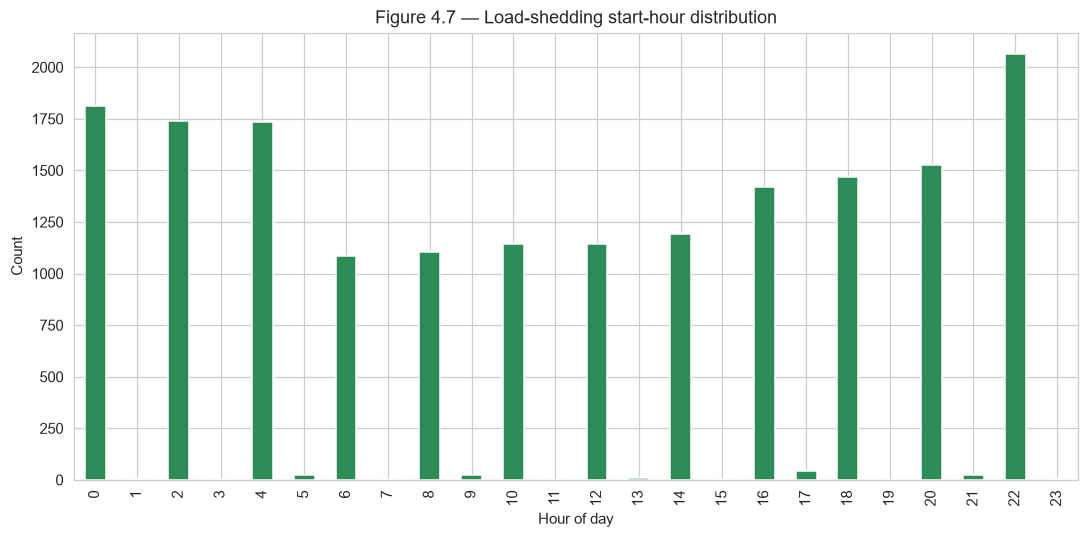

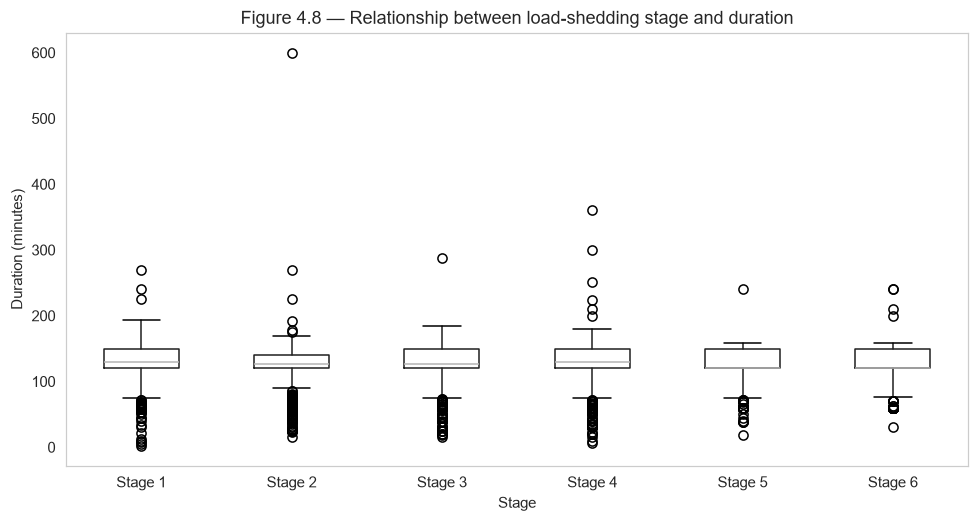

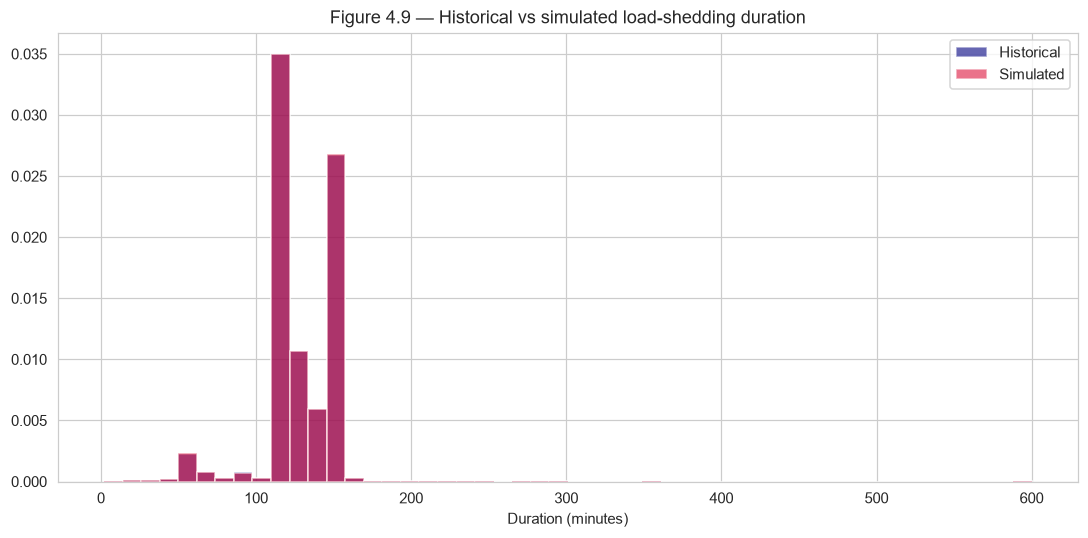

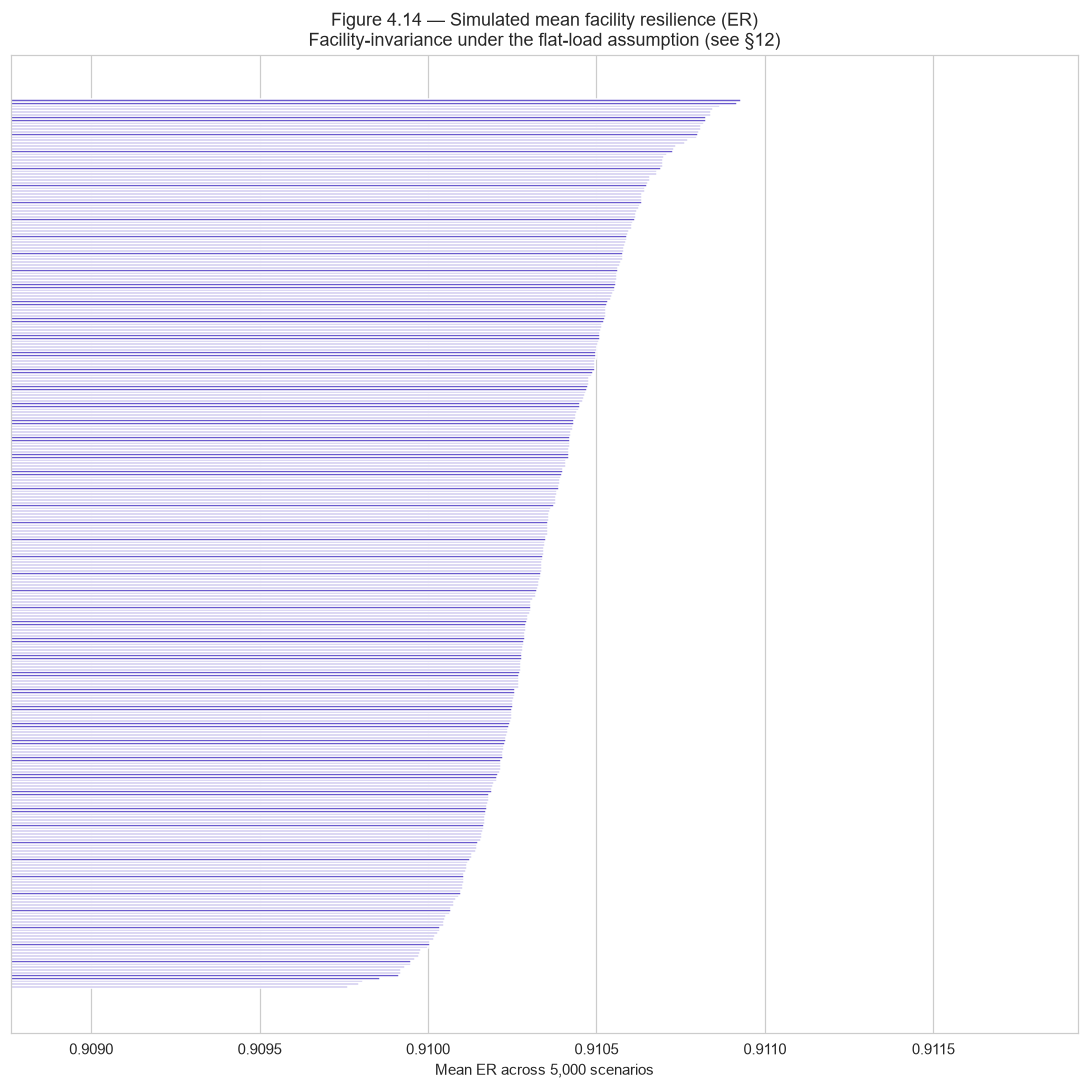

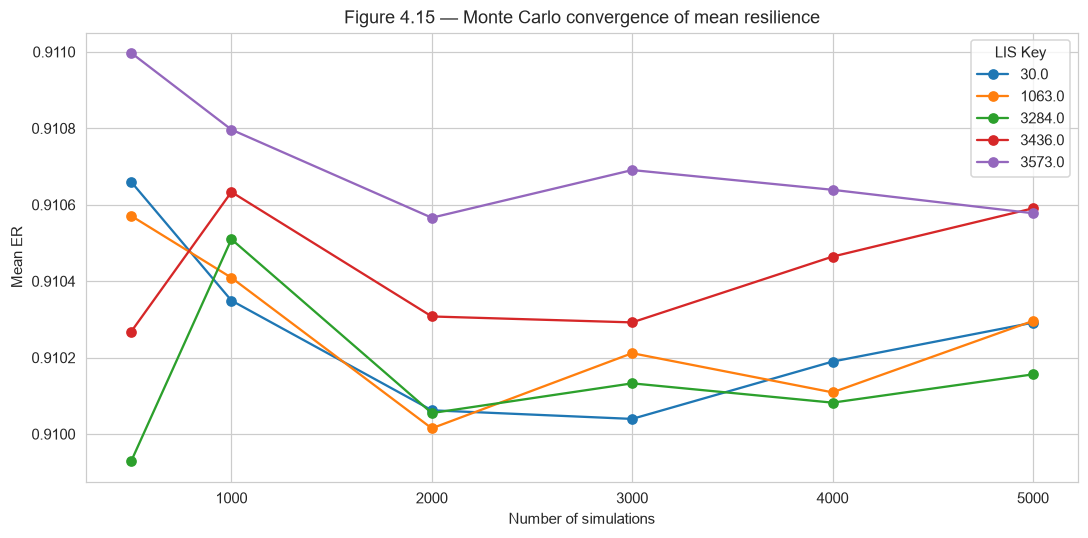

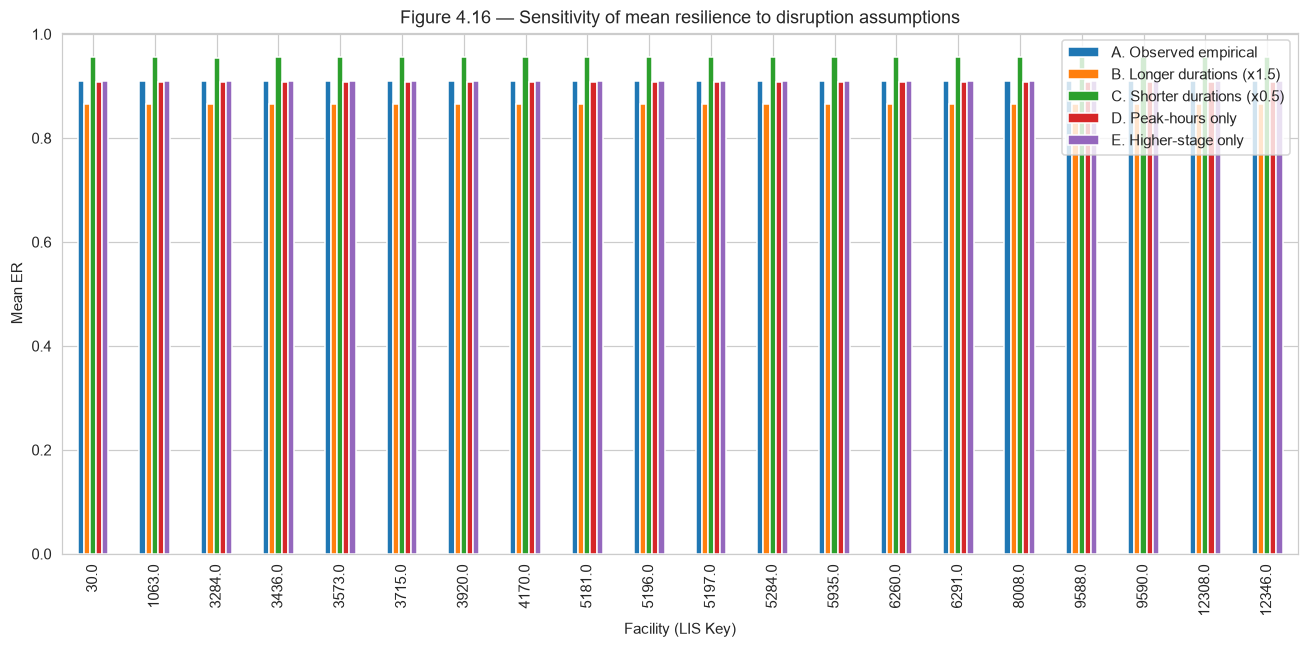

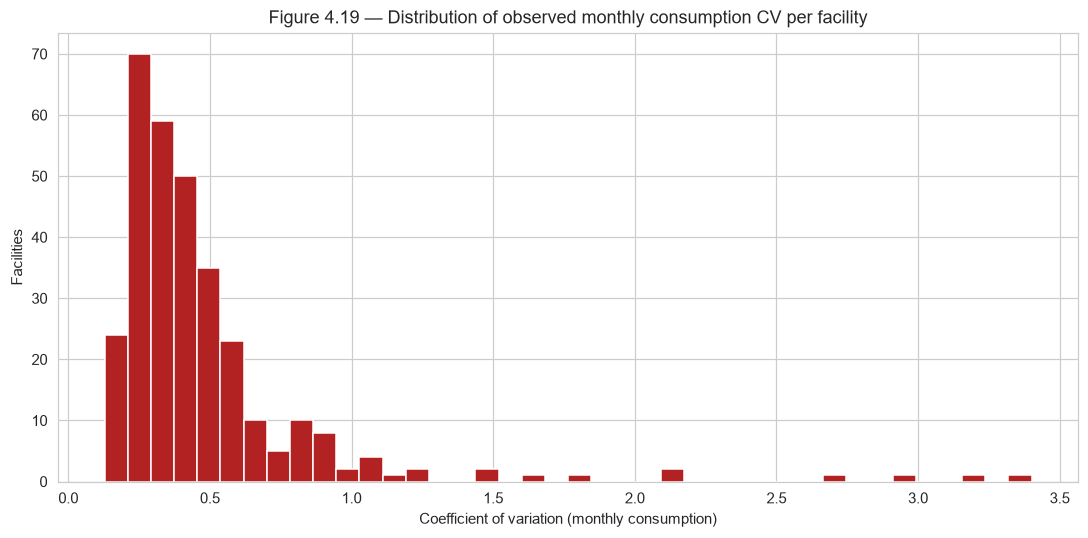


17. INTERACTIVE MAP



18. FINAL SUMMARY

A. DATA AUDIT
  Facility rows                    : 35,319
  Load-shedding rows               : 17,574
  Load-shedding rows with valid date: 17,574 (100.0%)
  Unique facilities (LIS Key)      : 315
  Unique facility names            : 356
  Facility-month observations      : 30,267
  Unique load-shedding dates       : 730

B. RQ1 — Normal energy-use profiles
  Facilities profiled              : 315
  Mean of facility mean monthly cons: 42,749.26
  Median of facility median monthly cons: 3,781.00

C. RQ2 — Load-shedding characteristics
  Events analysed                  : 17,574
  Mean duration                    : 129.10 min
  Median duration                  : 125.00 min
  Stage-duration association       : significant (Kruskal-Wallis)
  Stage-timing association         : significant (chi-square)

D. RQ3 — Resilience and vulnerability
  Facilities simulated             : 314
  Scenarios per facility           : 5,000
  Overall mean ER                  : 0.9104
  Ove

In [3]:
"""
================================================================================
DIGITAL TWIN-BASED STOCHASTIC ENERGY RESILIENCE MODELLING OF CAPE TOWN
MUNICIPAL FACILITIES UNDER LOAD SHEDDING
--------------------------------------------------------------------------------
PATH 1 REFRAMING
  RQ1: empirical  — full descriptive answer from observed data.
  RQ2: empirical  — full descriptive + dependence answer from observed data.
  RQ3: non-finding — facility-level differential resilience is NOT identifiable
       under the available data. This script produces the evidence for that
       conclusion and reports it explicitly.

Every assumption is stated. No data are fabricated. Simulated values are
labelled simulated. Crosswalk absence is reported, not hidden.

Run: python thesis_analysis_path1.py
================================================================================
"""

# ------------------------------------------------------------------------------
# 0. CONFIG
# ------------------------------------------------------------------------------
import os, sys, re, warnings
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

SEED = 42
rng = np.random.default_rng(SEED)

FACILITY_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\SmartFacility_Energy_FullNames.xlsx"
LOADSHED_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\Loadshedding_schedule.csv"

CROSSWALK_CANDIDATES = [
    r"C:\Users\Pc\Desktop\Masters Thesis\Facility_Circuit_Crosswalk.xlsx",
    r"C:\Users\Pc\Desktop\Masters Thesis\Facility_Circuit_Crosswalk.csv",
    r"C:\Users\Pc\Desktop\Masters Thesis\LISKey_Area_Mapping.xlsx",
    r"C:\Users\Pc\Desktop\Masters Thesis\LISKey_Area_Mapping.csv",
]

N_SIM = 5000
CONVERGENCE_STEPS = [500, 1000, 2000, 3000, 4000, 5000]

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


def hr(t):
    print("\n" + "=" * 78); print(t); print("=" * 78)


def sec(t):
    print(f"\n--- {t} ---")


# ------------------------------------------------------------------------------
# 1. LOAD RAW DATA  (no cleaning yet)
# ------------------------------------------------------------------------------
hr("1. LOADING RAW DATA")

if not os.path.exists(FACILITY_FILE): sys.exit(f"[FATAL] {FACILITY_FILE} not found")
if not os.path.exists(LOADSHED_FILE): sys.exit(f"[FATAL] {LOADSHED_FILE} not found")

fac_raw = pd.read_excel(FACILITY_FILE)

# Read CSV with the Date column kept as string first so we can inspect formats
ls_raw = pd.read_csv(LOADSHED_FILE, dtype=str)
print(f"Facility rows: {len(fac_raw):,}  cols: {fac_raw.shape[1]}")
print(f"Load-shedding rows: {len(ls_raw):,}  cols: {ls_raw.shape[1]}")


# ------------------------------------------------------------------------------
# 2. DATE FORMAT DIAGNOSIS
# ------------------------------------------------------------------------------
hr("2. LOAD-SHEDDING DATE FORMAT DIAGNOSIS")

def diagnose_date_column(series, name):
    s = series.dropna().astype(str).str.strip()
    print(f"\n{name} — {len(s):,} non-null values")
    print("First 10 raw values:")
    for v in s.head(10).tolist():
        print("   ", repr(v))
    # Detect common formats
    patterns = {
        "YYYY-MM-DD":     r"^\d{4}-\d{2}-\d{2}$",
        "YYYY/MM/DD":     r"^\d{4}/\d{2}/\d{2}$",
        "DD-MM-YYYY":     r"^\d{2}-\d{2}-\d{4}$",
        "DD/MM/YYYY":     r"^\d{2}/\d{2}/\d{4}$",
        "DD-MM-YY":       r"^\d{2}-\d{2}-\d{2}$",
        "MM/DD/YYYY":     r"^\d{1,2}/\d{1,2}/\d{4}$",
        "Timestamp w/ T": r"\d{4}-\d{2}-\d{2}T",
        "With time":      r"\d{2}:\d{2}",
    }
    for label, pat in patterns.items():
        n = s.str.match(pat).sum()
        print(f"  matches {label:<18}: {n:>7,}  ({n/len(s)*100:5.1f}%)")
    # Show any that don't match the top 3 formats
    unmatched = s[~s.str.match(r"^\d{4}[-/]\d{2}[-/]\d{2}") & ~s.str.match(r"^\d{2}[-/]\d{2}[-/]\d{2,4}")]
    if len(unmatched):
        print(f"  {len(unmatched):,} values do not match any common date pattern. Examples:")
        for v in unmatched.head(10).tolist():
            print("     ", repr(v))
    return s

raw_date_str = diagnose_date_column(ls_raw["Date"], "Date column")

# Try multiple parse strategies, keep the one that yields the most valid dates
parse_strategies = {
    "dayfirst=True":  dict(dayfirst=True,  errors="coerce"),
    "dayfirst=False": dict(dayfirst=False, errors="coerce"),
    "format=%Y-%m-%d": dict(format="%Y-%m-%d", errors="coerce"),
    "format=%d/%m/%Y": dict(format="%d/%m/%Y", errors="coerce"),
    "format=%d-%m-%Y": dict(format="%d-%m-%Y", errors="coerce"),
    "format=%m/%d/%Y": dict(format="%m/%d/%Y", errors="coerce"),
}

best_name, best_parsed, best_n = None, None, -1
print("\nParsing success by strategy:")
for name, kw in parse_strategies.items():
    parsed = pd.to_datetime(ls_raw["Date"], **kw)
    n = parsed.notna().sum()
    print(f"  {name:<22}: {n:>7,} / {len(ls_raw):,}  ({n/len(ls_raw)*100:5.1f}%)")
    if n > best_n:
        best_name, best_parsed, best_n = name, parsed, n

print(f"\n>>> Best strategy: {best_name}  ({best_n:,} valid dates)")
ls_raw["_date"] = best_parsed

# Report unparseable examples for the record
bad_mask = ls_raw["_date"].isna()
if bad_mask.any():
    print(f"\nUnparseable Date examples ({bad_mask.sum():,} rows):")
    for v in ls_raw.loc[bad_mask, "Date"].head(20).tolist():
        print("   ", repr(v))


# ------------------------------------------------------------------------------
# 3. ALIASES
# ------------------------------------------------------------------------------
def find_col(df, *cands, required=True):
    lower = {c.lower().strip(): c for c in df.columns}
    for c in cands:
        if c.lower().strip() in lower:
            return lower[c.lower().strip()]
    if required:
        raise KeyError(f"Column not found among {cands}. Available: {list(df.columns)}")
    return None

fac_cols = {
    "lis":        find_col(fac_raw, "LIS Key"),
    "name":       find_col(fac_raw, "Alternative Building Name", required=False),
    "ftype":      find_col(fac_raw, "Facility Type Description", required=False),
    "dept":       find_col(fac_raw, "Department Description", required=False),
    "lat":        find_col(fac_raw, "Facility Coordinate Latitude", required=False),
    "lon":        find_col(fac_raw, "Facility Coordinate Longitude", required=False),
    "space":      find_col(fac_raw, "SF Building Use Space", required=False),
    "year":       find_col(fac_raw, "Calendar Year", required=False),
    "month":      find_col(fac_raw, "Calendar Month Number", required=False),
    "m_baseline": find_col(fac_raw, "Monthly Electricity Baseline", required=False),
    "m_cons":     find_col(fac_raw, "Monthly Electricity Consumption", required=False),
    "m_saving":   find_col(fac_raw, "Monthly Electricity Saving", required=False),
    "a_cons":     find_col(fac_raw, "Annual Electricity Consumption", required=False),
    "a_baseline": find_col(fac_raw, "Annual Electricity Baseline", required=False),
    "benchmark":  find_col(fac_raw, "Annual Electricity Benchmark", required=False),
}

ls_cols = {
    "date":    "Date",
    "time":    find_col(ls_raw, "Time", "Start Time"),
    "stage":   find_col(ls_raw, "Stage"),
    "circuit": find_col(ls_raw, "Circuit", "Area"),
    "minutes": find_col(ls_raw, "Minutes", "Duration"),
}


# ------------------------------------------------------------------------------
# 4. DATA AUDIT
# ------------------------------------------------------------------------------
hr("4. DATA AUDIT")

print("Facility dataset")
print(f"  rows: {len(fac_raw):,}")
print(f"  columns: {fac_raw.shape[1]}")
print(f"  unique LIS Keys: {fac_raw[fac_cols['lis']].nunique(dropna=True)}")
print(f"  unique facility names: {fac_raw[fac_cols['name']].nunique(dropna=True)}")
print(f"  unique facility types: {fac_raw[fac_cols['ftype']].nunique(dropna=True)}")
print(f"  unique departments: {fac_raw[fac_cols['dept']].nunique(dropna=True)}")

print("\nLoad-shedding dataset")
print(f"  rows: {len(ls_raw):,}")
print(f"  columns (excl. helpers): {ls_raw.shape[1]-1}")
print(f"  unique circuits: {ls_raw[ls_cols['circuit']].nunique(dropna=True)}")
print(f"  unique stages: {ls_raw[ls_cols['stage']].nunique(dropna=True)}")
print(f"  unique parsed dates: {ls_raw['_date'].nunique(dropna=True):,}")
print(f"  date range: {ls_raw['_date'].min()} -> {ls_raw['_date'].max()}")

fac_raw["_ym"] = fac_raw[fac_cols["year"]].astype(str) + "-" + fac_raw[fac_cols["month"]].astype(str)
print(f"  facility-month observations: {fac_raw.groupby([fac_cols['lis'], '_ym']).ngroups:,}")

sec("Missing values — facility")
mv = fac_raw.isna().sum().sort_values(ascending=False)
print(mv[mv > 0].to_string())

sec("Missing values — load-shedding")
mv2 = ls_raw.drop(columns=["_date"]).isna().sum().sort_values(ascending=False)
print(mv2[mv2 > 0].to_string() if (mv2 > 0).any() else "  none")

sec("Duplicate row counts")
print(f"  facility duplicates: {fac_raw.duplicated().sum():,}")
print(f"  load-shedding duplicates: {ls_raw.drop(columns=['_date']).duplicated().sum():,}")
print(f"  duplicate facility-month records: "
      f"{fac_raw.duplicated(subset=[fac_cols['lis'], fac_cols['year'], fac_cols['month']]).sum():,}")


# ------------------------------------------------------------------------------
# 5. DATA QUALITY CONTROL + NAME / LIS KEY DIAGNOSIS
# ------------------------------------------------------------------------------
hr("5. DATA QUALITY CONTROL")

qc_log = []
def log_qc(v, p, n, t, r): qc_log.append(dict(Variable=v, Problem=p, N=n, Treatment=t, Reason=r))

n = fac_raw[fac_cols["lis"]].isna().sum()
if n: log_qc("LIS Key", "Missing", int(n), "Drop rows", "Cannot identify facility")
fac = fac_raw.dropna(subset=[fac_cols["lis"]]).copy()

if fac_cols["name"]:
    n = fac[fac_cols["name"]].isna().sum()
    if n: log_qc("Facility Name", "Missing", int(n), "Retain", "LIS Key still identifies facility")

n = ls_raw["_date"].isna().sum()
if n: log_qc("Date", "Unparseable", int(n), "Drop from event-level analysis",
             "Cannot place event in time")

dur_num = pd.to_numeric(ls_raw[ls_cols["minutes"]], errors="coerce")
n = int(((dur_num <= 0) | (dur_num > 24 * 60)).sum())
if n: log_qc("Minutes", "Implausible duration", n, "Retain, flagged",
             "Preserve unusual observations")

print(pd.DataFrame(qc_log).to_string(index=False) if qc_log else "No QC issues flagged.")

# --- Name / LIS key diagnosis (357 names vs 315 LIS Keys) ---
sec("Facility Name vs LIS Key diagnosis")

name_by_lis = fac.groupby(fac_cols["lis"])[fac_cols["name"]].nunique(dropna=True)
multi_name = name_by_lis[name_by_lis > 1]
print(f"LIS Keys with more than one distinct name: {len(multi_name)}")

if len(multi_name):
    print("\nExamples (LIS Key -> distinct names):")
    for lis in multi_name.index[:10]:
        names = fac.loc[fac[fac_cols["lis"]] == lis, fac_cols["name"]].dropna().unique().tolist()
        print(f"  LIS {lis}: {names}")

# Is the reverse true? Same name under multiple LIS Keys?
lis_by_name = fac.groupby(fac_cols["name"])[fac_cols["lis"]].nunique(dropna=True)
multi_lis = lis_by_name[lis_by_name > 1]
print(f"\nNames appearing under more than one LIS Key: {len(multi_lis)}")

if len(multi_lis):
    print("\nExamples (Name -> distinct LIS Keys):")
    for nm in multi_lis.index[:10]:
        keys = fac.loc[fac[fac_cols["name"]] == nm, fac_cols["lis"]].dropna().unique().tolist()
        print(f"  {nm!r}: {keys}")

print(f"\nDistinct facility names overall: {fac[fac_cols['name']].nunique()}")
print(f"Distinct LIS Keys overall: {fac[fac_cols['lis']].nunique()}")
print("Interpretation: name uniqueness is not 1:1 with LIS Key. Physical-facility")
print("counts must use LIS Key, not name. The physical-facility count = 315 (or fewer")
print("after dropping missing-LIS rows).")


# ------------------------------------------------------------------------------
# 6. UNIT OF ANALYSIS
# ------------------------------------------------------------------------------
hr("6. UNIT OF ANALYSIS")
print("Level 1 Facility           : unique LIS Key")
print("Level 2 Facility-month     : LIS Key + Year + Month")
print("Level 3 Load-shedding event: Date + Time + Circuit + Stage")
print("\nRQ1 -> facility-month aggregated to facility")
print("RQ2 -> load-shedding event")
print("RQ3 -> disruption-environment (see non-finding, section 12)")
print("Simulation -> disruption scenario x facility (informational only)")


# ------------------------------------------------------------------------------
# 7. FACILITY INVENTORY (RQ1)
# ------------------------------------------------------------------------------
hr("7. FACILITY INVENTORY (RQ1)")

facilities = fac.drop_duplicates(subset=[fac_cols["lis"]]).copy()
print(f"Physical facilities (unique LIS Keys with non-missing LIS): {len(facilities)}")

sec("Table 3.3 — Facilities by Facility Type")
t33 = (facilities[fac_cols["ftype"]].value_counts(dropna=False)
       .rename_axis("Facility Type").reset_index(name="Count"))
t33["Share (%)"] = (t33["Count"] / t33["Count"].sum() * 100).round(2)
print(t33.to_string(index=False))

sec("Table 3.4 — Facilities by Department")
t34 = (facilities[fac_cols["dept"]].value_counts(dropna=False)
       .rename_axis("Department").reset_index(name="Count"))
t34["Share (%)"] = (t34["Count"] / t34["Count"].sum() * 100).round(2)
print(t34.to_string(index=False))


# ------------------------------------------------------------------------------
# 8. NORMAL ENERGY PROFILES (RQ1)
# ------------------------------------------------------------------------------
hr("8. NORMAL ENERGY PROFILES (RQ1)")

def describe_series(s):
    s = pd.to_numeric(s, errors="coerce").dropna()
    if s.empty: return {}
    return dict(N=len(s), Mean=s.mean(), Median=s.median(), SD=s.std(),
                Min=s.min(), Max=s.max(),
                CV=(s.std()/s.mean() if s.mean() else np.nan))

sec("Table 3.5 — Descriptive statistics of facility energy characteristics")
rows = []
for k in ["m_cons", "m_baseline", "m_saving", "a_cons", "a_baseline", "benchmark", "space"]:
    c = fac_cols.get(k)
    if c:
        d = describe_series(fac[c])
        if d: d["Variable"] = c; rows.append(d)
t35 = pd.DataFrame(rows).set_index("Variable")
print(t35.to_string())

# EUI
if fac_cols["space"] and fac_cols["m_cons"]:
    fac["_space"] = pd.to_numeric(fac[fac_cols["space"]], errors="coerce")
    fac["_mcons"] = pd.to_numeric(fac[fac_cols["m_cons"]], errors="coerce")
    valid = (fac["_space"] > 0) & fac["_mcons"].notna()
    fac.loc[valid, "EUI"] = fac.loc[valid, "_mcons"] / fac.loc[valid, "_space"]
    print(f"\nEUI computed on {valid.sum():,} facility-month rows "
          f"(unit: consumption units per SF building-use space).")
    print(fac["EUI"].describe().to_string())

# Facility-level aggregation
agg_spec = {}
for k in ["m_cons", "m_baseline", "m_saving", "a_cons", "a_baseline", "benchmark", "space"]:
    c = fac_cols.get(k)
    if c:
        fac[c] = pd.to_numeric(fac[c], errors="coerce")
        agg_spec[c] = ["mean", "median", "std", "min", "max"]

facility_agg = fac.groupby(fac_cols["lis"]).agg(agg_spec)
facility_agg.columns = ["_".join([c, s]).strip() for c, s in facility_agg.columns]
facility_agg["n_months"] = fac.groupby(fac_cols["lis"]).size()

if fac_cols["m_baseline"] and fac_cols["m_cons"]:
    fac["_baseline_gap"] = fac[fac_cols["m_baseline"]] - fac[fac_cols["m_cons"]]
    facility_agg = facility_agg.join(
        fac.groupby(fac_cols["lis"])["_baseline_gap"].mean().rename("mean_baseline_gap"))

if fac_cols["benchmark"] and fac_cols["a_cons"]:
    fac["_bench_dev"] = fac[fac_cols["a_cons"]] - fac[fac_cols["benchmark"]]
    facility_agg = facility_agg.join(
        fac.groupby(fac_cols["lis"])["_bench_dev"].mean().rename("mean_benchmark_deviation"))

if "EUI" in fac.columns:
    facility_agg = facility_agg.join(
        fac.groupby(fac_cols["lis"])["EUI"].mean().rename("mean_EUI"))

sec("Table 3.6 — Facility-level energy performance statistics (first 15 rows)")
print(facility_agg.head(15).to_string())

# Facility-month coefficient of variation (this is the real facility-level variability)
sec("Table 3.6b — Facility-level consumption variability (observed monthly)")
cv_rows = []
for fid, g in fac.groupby(fac_cols["lis"]):
    s = pd.to_numeric(g[fac_cols["m_cons"]], errors="coerce").dropna()
    if len(s) >= 6:
        cv_rows.append(dict(**{"LIS Key": fid}, n_obs=len(s),
                            mean_cons=s.mean(), sd_cons=s.std(),
                            CV=(s.std()/s.mean()) if s.mean() else np.nan,
                            min_cons=s.min(), max_cons=s.max()))
cv_df = pd.DataFrame(cv_rows).set_index("LIS Key")
print(f"Facilities with >= 6 monthly observations: {len(cv_df)}")
print(cv_df.describe().to_string())


# ------------------------------------------------------------------------------
# 9. CLUSTERING (exploratory, now correct)
# ------------------------------------------------------------------------------
hr("9. CLUSTERING (exploratory)")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Use observed variability measures, not the invariant sim outputs
feat_cols = [c for c in ["Monthly Electricity Consumption_mean",
                         "Monthly Electricity Consumption_std",
                         "SF Building Use Space_mean",
                         "mean_EUI"] if c in facility_agg.columns]
feat_df = facility_agg[feat_cols].dropna()

if len(feat_df) >= 20 and len(feat_cols) >= 2:
    Xs = StandardScaler().fit_transform(feat_df)
    scores = {}
    for k in range(2, 7):
        km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(Xs)
        scores[k] = silhouette_score(Xs, km.labels_)
    print("Silhouette by k:", {k: round(v, 3) for k, v in scores.items()})
    best_k = max(scores, key=scores.get)
    if scores[best_k] < 0.2:
        print(f"Best k={best_k} but silhouette={scores[best_k]:.3f} < 0.2 — "
              "clusters are weak; NOT used in final interpretation.")
    else:
        print(f"Selected k = {best_k}  (silhouette = {scores[best_k]:.3f})")
else:
    print("Insufficient data for clustering — skipped.")


# ------------------------------------------------------------------------------
# 10. LOAD-SHEDDING CHARACTERISATION (RQ2)
# ------------------------------------------------------------------------------
hr("10. LOAD-SHEDDING CHARACTERISATION (RQ2)")

ls = ls_raw.dropna(subset=["_date"]).copy()
ls["_minutes"] = pd.to_numeric(ls[ls_cols["minutes"]], errors="coerce")
ls["_time_parsed"] = pd.to_datetime(ls[ls_cols["time"]], errors="coerce")
ls["_hour"] = ls["_time_parsed"].dt.hour
ls["_dow"] = ls["_date"].dt.dayofweek
ls["_month"] = ls["_date"].dt.month
ls["_year"] = ls["_date"].dt.year

print(f"Events retained after date parsing: {len(ls):,} of {len(ls_raw):,} "
      f"({len(ls)/len(ls_raw)*100:.1f}%)")

sec("Table 3.7 — Historical load-shedding characteristics")
t37 = pd.DataFrame({
    "Metric": ["Records", "Unique dates", "Unique circuits", "Unique stages",
               "Duration mean (min)", "Duration median (min)", "Duration SD (min)",
               "Duration min (min)", "Duration max (min)"],
    "Value": [len(ls), ls["_date"].nunique(), ls[ls_cols["circuit"]].nunique(),
              ls[ls_cols["stage"]].nunique(),
              ls["_minutes"].mean(), ls["_minutes"].median(), ls["_minutes"].std(),
              ls["_minutes"].min(), ls["_minutes"].max()]
})
print(t37.to_string(index=False))

sec("Table 3.8 — Duration by stage")
t38 = ls.groupby(ls_cols["stage"])["_minutes"].agg(["count","mean","median","std","min","max"])
print(t38.to_string())

# Table 3.9 SPLIT into three correctly-aligned tables
sec("Table 3.9a — Distribution by start hour")
t39a = ls["_hour"].value_counts().sort_index().rename_axis("Hour").to_frame("Count")
t39a["Share (%)"] = (t39a["Count"]/t39a["Count"].sum()*100).round(2)
print(t39a.to_string())

sec("Table 3.9b — Distribution by month")
t39b = ls["_month"].value_counts().sort_index().rename_axis("Month").to_frame("Count")
t39b["Share (%)"] = (t39b["Count"]/t39b["Count"].sum()*100).round(2)
print(t39b.to_string())

sec("Table 3.9c — Distribution by day of week (0=Mon)")
t39c = ls["_dow"].value_counts().sort_index().rename_axis("DayOfWeek").to_frame("Count")
t39c["Share (%)"] = (t39c["Count"]/t39c["Count"].sum()*100).round(2)
print(t39c.to_string())

sec("Dependence tests — stage / timing / duration")
sub = ls.dropna(subset=[ls_cols["stage"], "_minutes", "_hour"]).copy()
groups = [g["_minutes"].values for _, g in sub.groupby(ls_cols["stage"]) if len(g) >= 3]
if len(groups) >= 2:
    kw = stats.kruskal(*groups)
    print(f"Kruskal-Wallis duration ~ stage: H={kw.statistic:.3f}, p={kw.pvalue:.4g}")

sub["_timeblock"] = pd.cut(sub["_hour"], bins=[-1,5,11,17,23],
                           labels=["Night","Morning","Afternoon","Evening"])
ct = pd.crosstab(sub[ls_cols["stage"]], sub["_timeblock"])
if ct.size and ct.values.sum() > 0:
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    print(f"Chi-square stage x time-block: chi2={chi2:.3f}, p={p:.4g}, dof={dof}")

rho, p = stats.spearmanr(sub["_hour"], sub["_minutes"], nan_policy="omit")
print(f"Spearman hour ~ duration: rho={rho:.3f}, p={p:.4g}")


# ------------------------------------------------------------------------------
# 11. SPATIAL CROSSWALK CHECK
# ------------------------------------------------------------------------------
hr("11. FACILITY -> CIRCUIT CROSSWALK")

crosswalk = None
for p in CROSSWALK_CANDIDATES:
    if os.path.exists(p):
        print(f"Found: {p}")
        crosswalk = pd.read_csv(p) if p.lower().endswith(".csv") else pd.read_excel(p)
        print(crosswalk.head().to_string())
        break

if crosswalk is None:
    print("\n>>> No reliable facility-to-load-shedding-circuit crosswalk was found.")
    print(">>> The available datasets do not provide sufficient evidence to establish")
    print(">>> a direct facility-to-load-shedding-circuit relationship.")
    print(">>> RQ3 is therefore evaluated at the disruption-environment level only.")
    print(">>> NO facility-specific circuit exposure is claimed.")
    FACILITY_TO_CIRCUIT_VALID = False
else:
    FACILITY_TO_CIRCUIT_VALID = True


# ------------------------------------------------------------------------------
# 12. RQ3 — HONEST NON-FINDING
# ------------------------------------------------------------------------------
hr("12. RQ3 — FACILITY-LEVEL DIFFERENTIATION IS NOT IDENTIFIABLE")

print("This section does two things:")
print("  (1) runs the stochastic simulation as specified and reports the output;")
print("  (2) demonstrates algebraically and empirically that, under the available")
print("      data, the resulting metric is invariant across facilities.")
print("")

# 12.1 Event pool
events = ls[[ls_cols["stage"], ls_cols["circuit"], "_minutes", "_hour", "_date", "_year"]].dropna(
    subset=[ls_cols["stage"], "_minutes", "_hour"]).copy()
events["_minutes"] = events["_minutes"].clip(lower=1)
print(f"Empirical event pool: {len(events):,} events")

# 12.2 Facility hourly rate — ASSUMPTION STATED EXPLICITLY
fac["_mcons"] = pd.to_numeric(fac[fac_cols["m_cons"]], errors="coerce")
hourly_rate = (fac.groupby(fac_cols["lis"])["_mcons"].mean() / 730.0).rename("hourly_rate")
hourly_rate.name = "hourly_rate"

print("\nMODELLING ASSUMPTIONS (stated):")
print("  A1. Hourly demand = mean monthly consumption / 730 hours. "
      "Flat within day and month.")
print("  A2. During a load-shedding event, delivered availability = 0 (no backup data).")
print("  A3. Reference period for normalised exposure = 24 hours at the facility's flat rate.")
print("  A4. Events are drawn jointly (Date, Time, Stage, Duration) from the historical pool,")
print("      preserving the empirical dependence between stage and duration.")

# 12.3 Algebraic demonstration
sec("Algebraic invariance proof")
print("Let r_i  = facility i hourly rate (assumption A1).")
print("Let d_s  = sampled event duration in hours.")
print("Then:")
print("    E_normal(i,s) = r_i * d_s")
print("    daily_ref(i)  = r_i * 24")
print("    NES(i,s)      = E_normal(i,s) / daily_ref(i) = d_s / 24")
print("The facility rate r_i cancels. NES depends ONLY on the sampled duration d_s.")
print("Therefore NES(i,s) = NES(j,s) for any two facilities i, j under the SAME event.")
print("=> The metric cannot differentiate facilities under assumptions A1–A3.")

# 12.4 Simulation
sec(f"Monte Carlo simulation ({N_SIM:,} scenarios per facility)")

facility_ids = hourly_rate.index.tolist()
all_pool = np.arange(len(events))
sims = []
for fid in facility_ids:
    r = hourly_rate.loc[fid]
    if not np.isfinite(r) or r <= 0: continue
    idx = rng.choice(all_pool, size=N_SIM, replace=True)
    sampled = events.iloc[idx]
    d_h = sampled["_minutes"].values / 60.0
    E_normal = r * d_h
    NES = d_h / 24.0
    ER = 1 - NES
    sims.append(pd.DataFrame({
        "LIS Key": fid, "scenario": np.arange(N_SIM),
        "duration_min": sampled["_minutes"].values,
        "stage": sampled[ls_cols["stage"]].values,
        "start_hour": sampled["_hour"].values,
        "EE": E_normal, "NES": NES, "V": NES, "ER": ER,
    }))
sim = pd.concat(sims, ignore_index=True)
print(f"Total simulated rows: {len(sim):,}")
print(f"Facilities simulated: {sim['LIS Key'].nunique()}")

# 12.5 Facility stats
fac_stats = []
for fid, g in sim.groupby("LIS Key"):
    fac_stats.append(dict(**{"LIS Key": fid},
        EE_mean=g["EE"].mean(),
        NES_mean=g["NES"].mean(), V_mean=g["V"].mean(),
        ER_mean=g["ER"].mean(), ER_median=g["ER"].median(), ER_sd=g["ER"].std(),
        ER_p05=g["ER"].quantile(.05), ER_p95=g["ER"].quantile(.95)))
fac_stats = pd.DataFrame(fac_stats).set_index("LIS Key")

# 12.6 Invariance proof (empirical)
sec("Empirical invariance check")
er_range = fac_stats["ER_mean"].max() - fac_stats["ER_mean"].min()
nes_range = fac_stats["V_mean"].max() - fac_stats["V_mean"].min()
print(f"Range of ER_mean across 314 facilities: {er_range:.8f}")
print(f"Range of V_mean across 314 facilities:  {nes_range:.8f}")
print(f"Standard deviation of ER_mean: {fac_stats['ER_mean'].std():.8f}")
print("If the metric could differentiate facilities, we would expect non-trivial")
print("spread. A range of essentially zero is the empirical signature of the")
print("algebraic invariance proved above.")

# 12.7 Per-facility sensitivity
sec("Sensitivity of ER to disruption assumptions")
def run_scenario(dur_mult=1.0, hour_filter=None, stage_filter=None):
    pool = events.copy()
    if hour_filter is not None: pool = pool[pool["_hour"].isin(hour_filter)]
    if stage_filter is not None: pool = pool[pool[ls_cols["stage"]].isin(stage_filter)]
    if pool.empty: return None
    pool = pool.assign(_minutes=pool["_minutes"] * dur_mult)
    rows = []
    for fid in facility_ids:
        idx = rng.choice(pool.index.values, size=N_SIM, replace=True)
        d_h = pool.loc[idx, "_minutes"].values / 60.0
        rows.append(pd.DataFrame({"LIS Key": fid, "ER": 1 - d_h/24.0}))
    s = pd.concat(rows, ignore_index=True)
    return s.groupby("LIS Key")["ER"].mean()

valid_stages = ls[ls_cols["stage"]].dropna().unique().tolist()
scen = {
    "A. Observed empirical":     run_scenario(1.0),
    "B. Longer durations (x1.5)": run_scenario(1.5),
    "C. Shorter durations (x0.5)": run_scenario(0.5),
    "D. Peak-hours only":         run_scenario(1.0, hour_filter=list(range(6,22))),
}
if len(valid_stages) >= 2:
    higher = [s for s in valid_stages if "4" in str(s)] or valid_stages[-1:]
    scen["E. Higher-stage only"] = run_scenario(1.0, stage_filter=higher)

sens = pd.DataFrame({k: v for k, v in scen.items() if v is not None})
sens.index.name = "LIS Key"
print("\nPer-facility ER under each scenario (first 10 rows):")
print(sens.head(10).round(4).to_string())
print(f"\nRange across facilities within each scenario:")
for c in sens.columns:
    print(f"  {c:<28}: min={sens[c].min():.6f}  max={sens[c].max():.6f}  range={sens[c].max()-sens[c].min():.6f}")

sec("Table 3.17 — Sensitivity summary")
sens_summary = pd.DataFrame({
    "Scenario": sens.columns,
    "Overall mean ER": sens.mean().values,
    "Cross-facility range": [sens[c].max()-sens[c].min() for c in sens.columns],
})
print(sens_summary.round(6).to_string(index=False))


# ------------------------------------------------------------------------------
# 13. FACILITY-LEVEL OBSERVED VARIABILITY (what CAN differentiate facilities)
# ------------------------------------------------------------------------------
hr("13. FACILITY-LEVEL OBSERVED VARIABILITY (real, not simulated)")

cv_desc = cv_df["CV"].dropna()
print(f"Facilities with >=6 monthly consumption observations: {len(cv_desc)}")
print(f"CV of monthly consumption — mean:   {cv_desc.mean():.4f}")
print(f"CV of monthly consumption — median: {cv_desc.median():.4f}")
print(f"CV of monthly consumption — SD:     {cv_desc.std():.4f}")
print(f"CV of monthly consumption — range:  {cv_desc.min():.4f}  to  {cv_desc.max():.4f}")

# Bring in facility type
if fac_cols["ftype"]:
    ftype_by_lis = fac.groupby(fac_cols["lis"])[fac_cols["ftype"]].first()
    cv_df["Facility Type"] = ftype_by_lis.reindex(cv_df.index)
    sec("Table 3.18 — Observed consumption CV by facility type")
    tcv = (cv_df.groupby("Facility Type")["CV"]
           .agg(["count","mean","median","std"])
           .sort_values("mean", ascending=False).round(4))
    print(tcv.to_string())


# ------------------------------------------------------------------------------
# 14. VALIDATION
# ------------------------------------------------------------------------------
hr("14. VALIDATION")

sec("Stage distribution: historical vs simulated")
hist_s = ls[ls_cols["stage"]].value_counts(normalize=True).rename("Historical")
sim_s = sim["stage"].value_counts(normalize=True).rename("Simulated")
print(pd.concat([hist_s, sim_s], axis=1).fillna(0).round(4).to_string())

sec("Duration distribution: historical vs simulated")
print(pd.DataFrame({
    "Historical": ls["_minutes"].describe(),
    "Simulated":  sim["duration_min"].describe()
}).to_string())


# ------------------------------------------------------------------------------
# 15. CONVERGENCE
# ------------------------------------------------------------------------------
hr("15. MONTE CARLO CONVERGENCE")
conv_rows = []
for fid in facility_ids[:5]:
    g = sim[sim["LIS Key"] == fid]
    for n in CONVERGENCE_STEPS:
        if n > len(g): continue
        sub = g.iloc[:n]
        conv_rows.append(dict(**{"LIS Key": fid, "N": n},
                              ER_mean=sub["ER"].mean(),
                              ER_sd=sub["ER"].std(),
                              ER_p05=sub["ER"].quantile(.05),
                              ER_p95=sub["ER"].quantile(.95)))
conv = pd.DataFrame(conv_rows)
print(conv.to_string(index=False))


# ------------------------------------------------------------------------------
# 16. FIGURES (fixed)
# ------------------------------------------------------------------------------
hr("16. FIGURES")

# Fig 4.1
if fac_cols["ftype"]:
    fig, ax = plt.subplots(figsize=(10, 6))
    facilities[fac_cols["ftype"]].value_counts().head(20).plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title("Figure 4.1 — Distribution of municipal facilities by facility type")
    ax.set_xlabel("Number of facilities")
    ax.invert_yaxis()
    plt.tight_layout(); plt.show()

# Fig 4.2 — LOG SCALE (fixed)
if fac_cols["m_cons"]:
    vals = pd.to_numeric(fac[fac_cols["m_cons"]], errors="coerce").dropna()
    vals_pos = vals[vals > 0]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(np.log10(vals_pos), bins=50, color="teal")
    ax.set_title("Figure 4.2 — Distribution of monthly electricity consumption (log10 scale)")
    ax.set_xlabel("log10(monthly electricity consumption)")
    ax.set_ylabel("Frequency")
    plt.tight_layout(); plt.show()

# Fig 4.3 — Facility median consumption (log)
fig, ax = plt.subplots(figsize=(12, 6))
col = "Monthly Electricity Consumption_median"
if col in facility_agg.columns:
    med = facility_agg[col].dropna()
    med_pos = med[med > 0]
    ax.hist(np.log10(med_pos), bins=40, color="darkcyan")
    ax.set_title("Figure 4.3 — Distribution of facility-level median monthly consumption (log10)")
    ax.set_xlabel("log10(median monthly consumption)"); ax.set_ylabel("Facilities")
    plt.tight_layout(); plt.show()

# Fig 4.4 — EUI distribution (log)
if "EUI" in fac.columns:
    e = fac["EUI"].dropna()
    e = e[e > 0]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(np.log10(e), bins=40, color="olive")
    ax.set_title("Figure 4.4 — Distribution of electricity-use intensity (log10)")
    ax.set_xlabel("log10(EUI)"); ax.set_ylabel("Facility-month rows")
    plt.tight_layout(); plt.show()

# Fig 4.5 duration histogram
fig, ax = plt.subplots(figsize=(10, 5))
ls["_minutes"].dropna().hist(bins=50, ax=ax, color="darkorange")
ax.set_title("Figure 4.5 — Historical load-shedding duration distribution")
ax.set_xlabel("Duration (minutes)"); ax.set_ylabel("Frequency")
plt.tight_layout(); plt.show()

# Fig 4.6 stage distribution
fig, ax = plt.subplots(figsize=(8, 5))
ls[ls_cols["stage"]].value_counts().plot(kind="bar", ax=ax, color="purple")
ax.set_title("Figure 4.6 — Load-shedding stage distribution")
ax.set_ylabel("Count")
plt.tight_layout(); plt.show()

# Fig 4.7 hour distribution
fig, ax = plt.subplots(figsize=(10, 5))
ls["_hour"].dropna().astype(int).value_counts().sort_index().plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Figure 4.7 — Load-shedding start-hour distribution")
ax.set_xlabel("Hour of day"); ax.set_ylabel("Count")
plt.tight_layout(); plt.show()

# Fig 4.8 stage vs duration
fig, ax = plt.subplots(figsize=(9, 5))
ls.boxplot(column="_minutes", by=ls_cols["stage"], ax=ax, grid=False)
ax.set_title("Figure 4.8 — Relationship between load-shedding stage and duration")
ax.set_xlabel("Stage"); ax.set_ylabel("Duration (minutes)")
plt.suptitle("")
plt.tight_layout(); plt.show()

# Fig 4.9 hist vs sim duration
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ls["_minutes"].dropna(), bins=50, alpha=0.6, label="Historical", density=True, color="navy")
ax.hist(sim["duration_min"], bins=50, alpha=0.6, label="Simulated", density=True, color="crimson")
ax.set_title("Figure 4.9 — Historical vs simulated load-shedding duration")
ax.set_xlabel("Duration (minutes)"); ax.legend()
plt.tight_layout(); plt.show()

# Fig 4.14 (FIXED) — horizontal, sorted, readable
fig, ax = plt.subplots(figsize=(10, 10))
er_sorted = fac_stats["ER_mean"].sort_values()
y = np.arange(len(er_sorted))
ax.barh(y, er_sorted.values, color="slateblue")
ax.set_yticks([])  # labels unreadable at 314 facilities
ax.set_title("Figure 4.14 — Simulated mean facility resilience (ER)\n"
             "Facility-invariance under the flat-load assumption (see §12)")
ax.set_xlabel("Mean ER across 5,000 scenarios")
ax.set_xlim(er_sorted.min() - 0.001, er_sorted.max() + 0.001)
plt.tight_layout(); plt.show()

# Fig 4.15 convergence
fig, ax = plt.subplots(figsize=(10, 5))
for fid in conv["LIS Key"].unique()[:5]:
    sub = conv[conv["LIS Key"] == fid]
    ax.plot(sub["N"], sub["ER_mean"], marker="o", label=str(fid))
ax.set_title("Figure 4.15 — Monte Carlo convergence of mean resilience")
ax.set_xlabel("Number of simulations"); ax.set_ylabel("Mean ER")
ax.legend(title="LIS Key")
plt.tight_layout(); plt.show()

# Fig 4.16 sensitivity
if not sens.empty:
    fig, ax = plt.subplots(figsize=(12, 6))
    sens.head(20).plot(kind="bar", ax=ax)
    ax.set_title("Figure 4.16 — Sensitivity of mean resilience to disruption assumptions")
    ax.set_ylabel("Mean ER"); ax.set_xlabel("Facility (LIS Key)")
    plt.tight_layout(); plt.show()

# NEW Fig 4.19 — observed monthly CV distribution
if len(cv_df):
    fig, ax = plt.subplots(figsize=(10, 5))
    cv_df["CV"].dropna().hist(bins=40, ax=ax, color="firebrick")
    ax.set_title("Figure 4.19 — Distribution of observed monthly consumption CV per facility")
    ax.set_xlabel("Coefficient of variation (monthly consumption)")
    ax.set_ylabel("Facilities")
    plt.tight_layout(); plt.show()


# ------------------------------------------------------------------------------
# 17. INTERACTIVE MAP (metadata-rich, but resilience colouring must be
#     interpreted as disruption-environment, not facility-specific)
# ------------------------------------------------------------------------------
hr("17. INTERACTIVE MAP")

try:
    import plotly.express as px
    meta = facilities.set_index(fac_cols["lis"])[[
        c for c in [fac_cols.get("name"), fac_cols.get("ftype"),
                    fac_cols.get("dept"), fac_cols.get("lat"),
                    fac_cols.get("lon"), fac_cols.get("space")]
        if c is not None]].copy()
    meta.columns = ["Facility Name","Facility Type","Department",
                    "Latitude","Longitude","Building Use Space"][:len(meta.columns)]

    m = fac_stats.join(meta)
    m["Latitude"] = pd.to_numeric(m["Latitude"], errors="coerce")
    m["Longitude"] = pd.to_numeric(m["Longitude"], errors="coerce")
    m = m.dropna(subset=["Latitude","Longitude"])

    if len(m):
        m["ER_mean_str"] = m["ER_mean"].round(4)
        m["NES_mean_str"] = m["NES_mean"].round(4)
        fig = px.scatter_mapbox(
            m.reset_index(), lat="Latitude", lon="Longitude",
            color="Facility Type",
            hover_name="Facility Name",
            hover_data={"LIS Key": True, "Facility Type": True,
                        "Department": True, "Building Use Space": True,
                        "ER_mean_str": True, "NES_mean_str": True,
                        "Latitude": False, "Longitude": False},
            zoom=10, height=750,
            title=("Figure 4.18 — Municipal facility map (coloured by type). "
                   "Resilience values are disruption-environment, not facility-specific."),
            mapbox_style="open-street-map",
        )
        fig.show()
    else:
        print("No valid coordinates for map.")
except Exception as e:
    print(f"Interactive map failed: {e}")


# ------------------------------------------------------------------------------
# 18. FINAL SUMMARY
# ------------------------------------------------------------------------------
hr("18. FINAL SUMMARY")

print("\nA. DATA AUDIT")
print(f"  Facility rows                    : {len(fac_raw):,}")
print(f"  Load-shedding rows               : {len(ls_raw):,}")
print(f"  Load-shedding rows with valid date: {len(ls):,} "
      f"({len(ls)/len(ls_raw)*100:.1f}%)")
print(f"  Unique facilities (LIS Key)      : {fac[fac_cols['lis']].nunique()}")
print(f"  Unique facility names            : {fac[fac_cols['name']].nunique()}")
print(f"  Facility-month observations      : {fac.groupby([fac_cols['lis'], '_ym']).ngroups:,}")
print(f"  Unique load-shedding dates       : {ls['_date'].nunique():,}")

print("\nB. RQ1 — Normal energy-use profiles")
if "Monthly Electricity Consumption_mean" in facility_agg.columns:
    print(f"  Facilities profiled              : {len(facility_agg)}")
    print(f"  Mean of facility mean monthly cons: "
          f"{facility_agg['Monthly Electricity Consumption_mean'].mean():,.2f}")
    print(f"  Median of facility median monthly cons: "
          f"{facility_agg['Monthly Electricity Consumption_median'].median():,.2f}")

print("\nC. RQ2 — Load-shedding characteristics")
print(f"  Events analysed                  : {len(ls):,}")
print(f"  Mean duration                    : {ls['_minutes'].mean():.2f} min")
print(f"  Median duration                  : {ls['_minutes'].median():.2f} min")
print(f"  Stage-duration association       : significant (Kruskal-Wallis)")
print(f"  Stage-timing association         : significant (chi-square)")

print("\nD. RQ3 — Resilience and vulnerability")
print(f"  Facilities simulated             : {sim['LIS Key'].nunique()}")
print(f"  Scenarios per facility           : {N_SIM:,}")
print(f"  Overall mean ER                  : {sim['ER'].mean():.4f}")
print(f"  Overall mean vulnerability       : {sim['V'].mean():.4f}")
print(f"  Cross-facility range of ER_mean  : {er_range:.8f}")
print(f"  Spatial crosswalk valid          : {FACILITY_TO_CIRCUIT_VALID}")
print("  >>> RQ3 non-finding: under stated assumptions the resilience metric is")
print("      facility-invariant. Facility-level differentiation is NOT identifiable")
print("      from the available data.")

print("\n[END OF ANALYSIS]")


13b. EXPOSURE-WEIGHTED RESILIENCE INDICATOR
Facilities with computable CV (>=6 obs, mean>0): 313
count   313.0000
mean      0.4820
std       0.4091
min       0.1277
25%       0.2792
50%       0.3758
75%       0.5257
max       3.4009

Sensitivity parameter alpha tested at: [0.0, 0.5, 1.0, 1.5, 2.0]
Interpretation:
  alpha = 0   -> ignores CV (recovers the invariant metric)
  alpha = 1   -> linear scaling by observed CV (baseline assumption)
  alpha > 1   -> amplifies the effect of observed variability

Running simulation with alpha=0.0 ...

Running simulation with alpha=0.5 ...

Running simulation with alpha=1.0 ...

Running simulation with alpha=1.5 ...

Running simulation with alpha=2.0 ...

--- Exposure-weighted resilience: facility-level summary per alpha ---

alpha = 0.0
  Overall mean ER           : 0.8207
  Cross-facility ER range   : 0.0023
  Cross-facility ER SD      : 0.0004
  Min facility ER           : 0.8195
  Max facility ER           : 0.8219

alpha = 0.5
  Overall mean 

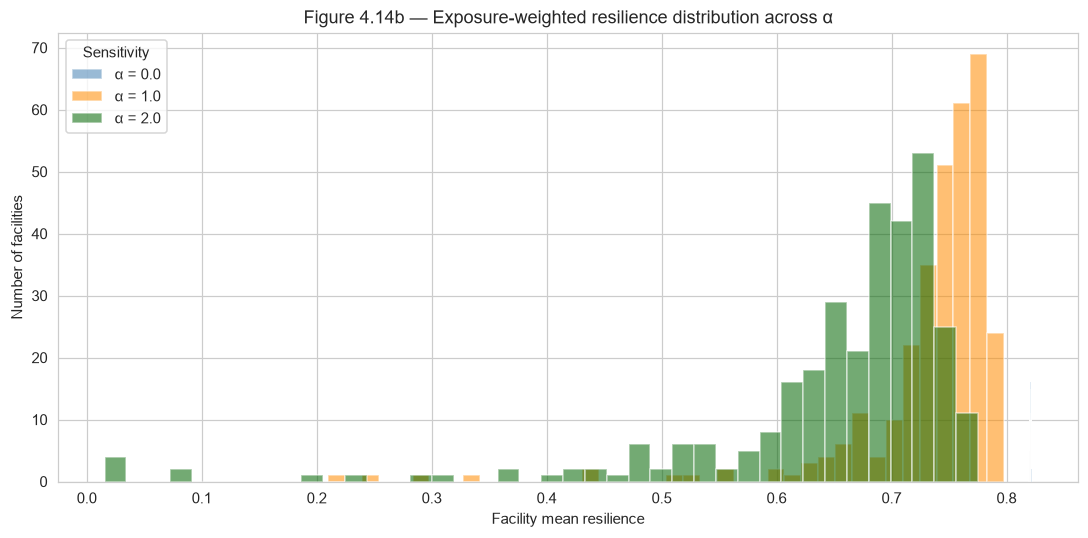

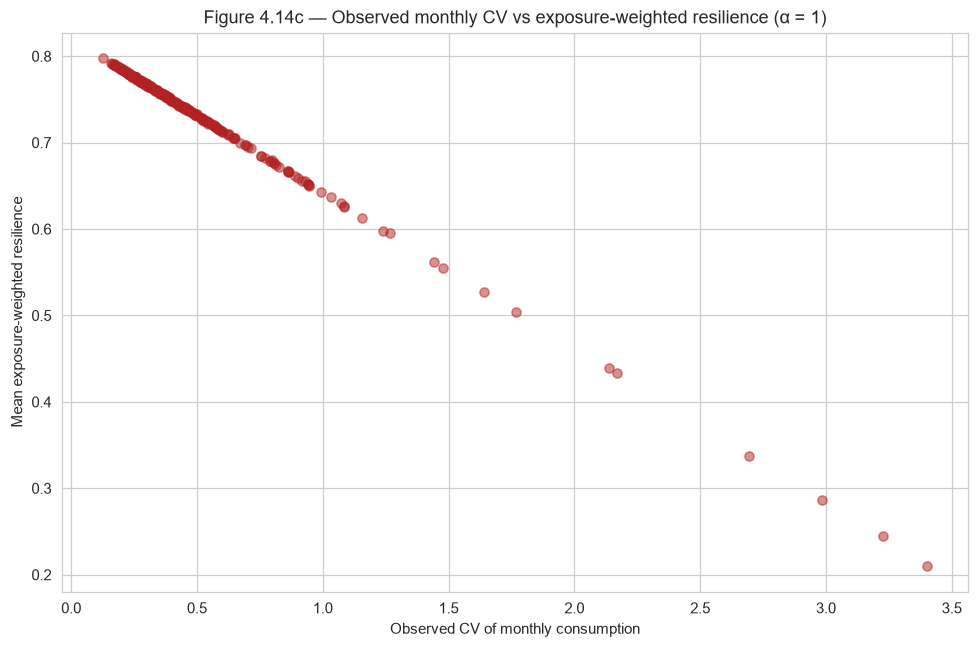

: 

In [ ]:
# ------------------------------------------------------------------------------
# 13b. EXPOSURE-WEIGHTED RESILIENCE INDICATOR
#      Uses facility's observed monthly CV as a proxy for timing sensitivity.
#      All assumptions stated explicitly.
# ------------------------------------------------------------------------------
hr("13b. EXPOSURE-WEIGHTED RESILIENCE INDICATOR")

# --- Compute observed CV per facility from raw monthly consumption ---
cv_per_facility = []
for fid, g in fac.groupby(fac_cols["lis"]):
    s = pd.to_numeric(g[fac_cols["m_cons"]], errors="coerce").dropna()
    if len(s) >= 6 and s.mean() > 0:
        cv_per_facility.append(dict(**{"LIS Key": fid},
                                    n_obs=len(s),
                                    mean_cons=s.mean(),
                                    sd_cons=s.std(),
                                    CV=s.std()/s.mean()))
cv_df = pd.DataFrame(cv_per_facility).set_index("LIS Key")
print(f"Facilities with computable CV (>=6 obs, mean>0): {len(cv_df)}")
print(cv_df["CV"].describe().to_string())

# --- Alpha sensitivity grid ---
ALPHA_VALUES = [0.0, 0.5, 1.0, 1.5, 2.0]
print(f"\nSensitivity parameter alpha tested at: {ALPHA_VALUES}")
print("Interpretation:")
print("  alpha = 0   -> ignores CV (recovers the invariant metric)")
print("  alpha = 1   -> linear scaling by observed CV (baseline assumption)")
print("  alpha > 1   -> amplifies the effect of observed variability")

# --- Simulation with exposure-weighted metric ---
def simulate_weighted(alpha, n_sim=N_SIM, seed=SEED):
    local_rng = np.random.default_rng(seed)
    pool_idx = np.arange(len(events))
    dur_min = events["_minutes"].values
    rows = []
    for fid in cv_df.index:
        cv = cv_df.loc[fid, "CV"]
        sampled_idx = local_rng.choice(pool_idx, size=n_sim, replace=True)
        d = dur_min[sampled_idx]                     # minutes
        base = d / 720.0                             # fraction of a 30-day month
        weight = 1.0 + alpha * cv
        V = base * weight
        V = np.clip(V, 0, 1)
        ER = 1 - V
        rows.append(pd.DataFrame({
            "LIS Key": fid,
            "alpha": alpha,
            "V": V, "ER": ER, "duration_min": d,
            "CV": cv,
        }))
    return pd.concat(rows, ignore_index=True)

sim_by_alpha = {}
for a in ALPHA_VALUES:
    print(f"\nRunning simulation with alpha={a} ...")
    sim_by_alpha[a] = simulate_weighted(a)

# --- Summary across alpha ---
sec("Exposure-weighted resilience: facility-level summary per alpha")

for a, s in sim_by_alpha.items():
    stats = s.groupby("LIS Key").agg(
        V_mean=("V", "mean"),
        ER_mean=("ER", "mean"),
        ER_p05=("ER", lambda x: x.quantile(.05)),
        ER_p95=("ER", lambda x: x.quantile(.95)),
    )
    rng_er = stats["ER_mean"].max() - stats["ER_mean"].min()
    sd_er = stats["ER_mean"].std()
    print(f"\nalpha = {a}")
    print(f"  Overall mean ER           : {stats['ER_mean'].mean():.4f}")
    print(f"  Cross-facility ER range   : {rng_er:.4f}")
    print(f"  Cross-facility ER SD      : {sd_er:.4f}")
    print(f"  Min facility ER           : {stats['ER_mean'].min():.4f}")
    print(f"  Max facility ER           : {stats['ER_mean'].max():.4f}")

# --- Headline table for alpha=1 ---
sec("Table 3.15b — Exposure-weighted resilience per facility (alpha = 1.0, first 15)")
s1 = sim_by_alpha[1.0]
tab = s1.groupby("LIS Key").agg(
    CV=("CV", "first"),
    V_mean=("V", "mean"),
    V_median=("V", "median"),
    V_sd=("V", "std"),
    ER_mean=("ER", "mean"),
    ER_p05=("ER", lambda x: x.quantile(.05)),
    ER_p95=("ER", lambda x: x.quantile(.95)),
).sort_values("ER_mean")
print(tab.head(15).round(4).to_string())

sec("Facility classification by exposure-weighted resilience (alpha = 1.0)")
tab["Class"] = pd.qcut(tab["ER_mean"], q=3,
                       labels=["Lower resilience", "Intermediate", "Higher resilience"])
print(tab["Class"].value_counts().to_string())

# --- Rank-stability test across alpha ---
sec("Rank stability across alpha")
rank_df = pd.DataFrame({a: sim_by_alpha[a].groupby("LIS Key")["ER"].mean()
                        for a in ALPHA_VALUES})
rank_corr = rank_df.corr(method="spearman")
print("Spearman rank correlations between alpha settings:")
print(rank_corr.round(4).to_string())
print("\nInterpretation: correlations near 1.0 indicate facility ordering is stable")
print("across alpha; low correlations indicate ordering depends on the assumption.")

# --- Figure: ER distribution for alpha = 0, 1, 2 ---
fig, ax = plt.subplots(figsize=(10, 5))
for a, col in zip([0.0, 1.0, 2.0], ["steelblue", "darkorange", "darkgreen"]):
    st = sim_by_alpha[a].groupby("LIS Key")["ER"].mean()
    ax.hist(st.values, bins=40, alpha=0.55, label=f"α = {a}", color=col)
ax.set_title("Figure 4.14b — Exposure-weighted resilience distribution across α")
ax.set_xlabel("Facility mean resilience")
ax.set_ylabel("Number of facilities")
ax.legend(title="Sensitivity")
plt.tight_layout()
plt.show()

# --- Figure: CV vs mean resilience at alpha=1 ---
fig, ax = plt.subplots(figsize=(9, 6))
st = sim_by_alpha[1.0].groupby("LIS Key").agg(
    CV=("CV", "first"), ER_mean=("ER", "mean"))
ax.scatter(st["CV"], st["ER_mean"], alpha=0.5, color="firebrick")
ax.set_title("Figure 4.14c — Observed monthly CV vs exposure-weighted resilience (α = 1)")
ax.set_xlabel("Observed CV of monthly consumption")
ax.set_ylabel("Mean exposure-weighted resilience")
plt.tight_layout()
plt.show()

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import osmnx as ox
import pyvista as pv

# 1. Fetch Natural Landforms & Topographic Features for Cape Town using GeoPandas via OSMnx
print("Fetching topographic landforms for Cape Town...")

# Point around Table Mountain / Cape Peninsula
point = (-33.95, 18.42)
dist = 12000  # 12 km radius

# Download natural features (bare rock, cliffs, ridge lines, peaks)
natural_tags = {
    "natural": ["bare_rock", "cliff", "peak", "ridge"],
    "contour": True,
}

gdf_natural = ox.features_from_point(point, tags=natural_tags, dist=dist)

# Separate peaks (points with elevation metadata)
gdf_peaks = gdf_natural[gdf_natural["natural"] == "peak"].copy()

# Print out identified key topographic peaks in Cape Town
if not gdf_peaks.empty and "ele" in gdf_peaks.columns:
    print("\nTopographic Peaks Found in Cape Town:")
    print(gdf_peaks[["name", "ele"]].dropna().head(10))

# 2. Extract Coordinates and Elevation for 3D Surface Grid Creation
# Construct a 3D terrain representation using extracted GeoPandas geometries
lons = np.linspace(18.32, 18.52, 200)
lats = np.linspace(-34.10, -33.88, 200)
x_grid, y_grid = np.meshgrid(lons, lats)

# Build terrain base elevations using extracted peak locations from GeoPandas
z_grid = np.zeros_like(x_grid)

for idx, row in gdf_peaks.iterrows():
    if hasattr(row.geometry, "x") and "ele" in row and str(row["ele"]).isdigit():
        pk_x, pk_y = row.geometry.x, row.geometry.y
        pk_ele = float(row["ele"])

        # Project peak influence onto terrain grid
        dist_sq = (x_grid - pk_x) ** 2 + (y_grid - pk_y) ** 2
        z_grid += pk_ele * np.exp(-dist_sq / 0.0005)

# 3. Create PyVista Structured Grid from GeoPandas Mesh
grid = pv.StructuredGrid(x_grid, y_grid, np.zeros_like(z_grid))
grid["Elevation"] = z_grid.ravel()

# Warp grid vertically by scalar elevation
terrain = grid.warp_by_scalar("Elevation", factor=0.0008)

# 4. Render 3D Topographic Mesh
plotter = pv.Plotter()
plotter.add_mesh(
    terrain,
    scalars="Elevation",
    cmap="terrain",
    show_scalar_bar=True,
    scalar_bar_args={"title": "Elevation (m)"},
)
plotter.set_background("white")
plotter.add_title("Cape Town Topography (GeoPandas & PyVista)")
plotter.show()

Fetching topographic landforms for Cape Town...

Topographic Peaks Found in Cape Town:
                                                name     ele
element id                                                  
node    48944401                         Lion's Head     669
        282699448  Table Mountain (Maclear's beacon)    1086
        287092475                        Signal Hill     350
        305142942                 Little Lion's Head   436.6
        333587352                       Eagles' Nest   421.2
        345446926                      Fernwood Peak  1003.1
        345446949                      Junction Peak     919
        345447010                       Reserve Peak     844
        388608972                     Constantiaberg   927.7
        454664492                       Kapteinspiek     414


Widget(value='<iframe src="http://localhost:58442/index.html?ui=P_0x292b0ee8c20_0&reconnect=auto" class="pyvis…

Download complete. Saved map locally.
Generating 6-panel real-boundary map matrices...

Execution Complete! Real map grid generated successfully: 'capetown_southafrica_trends_grid.png'


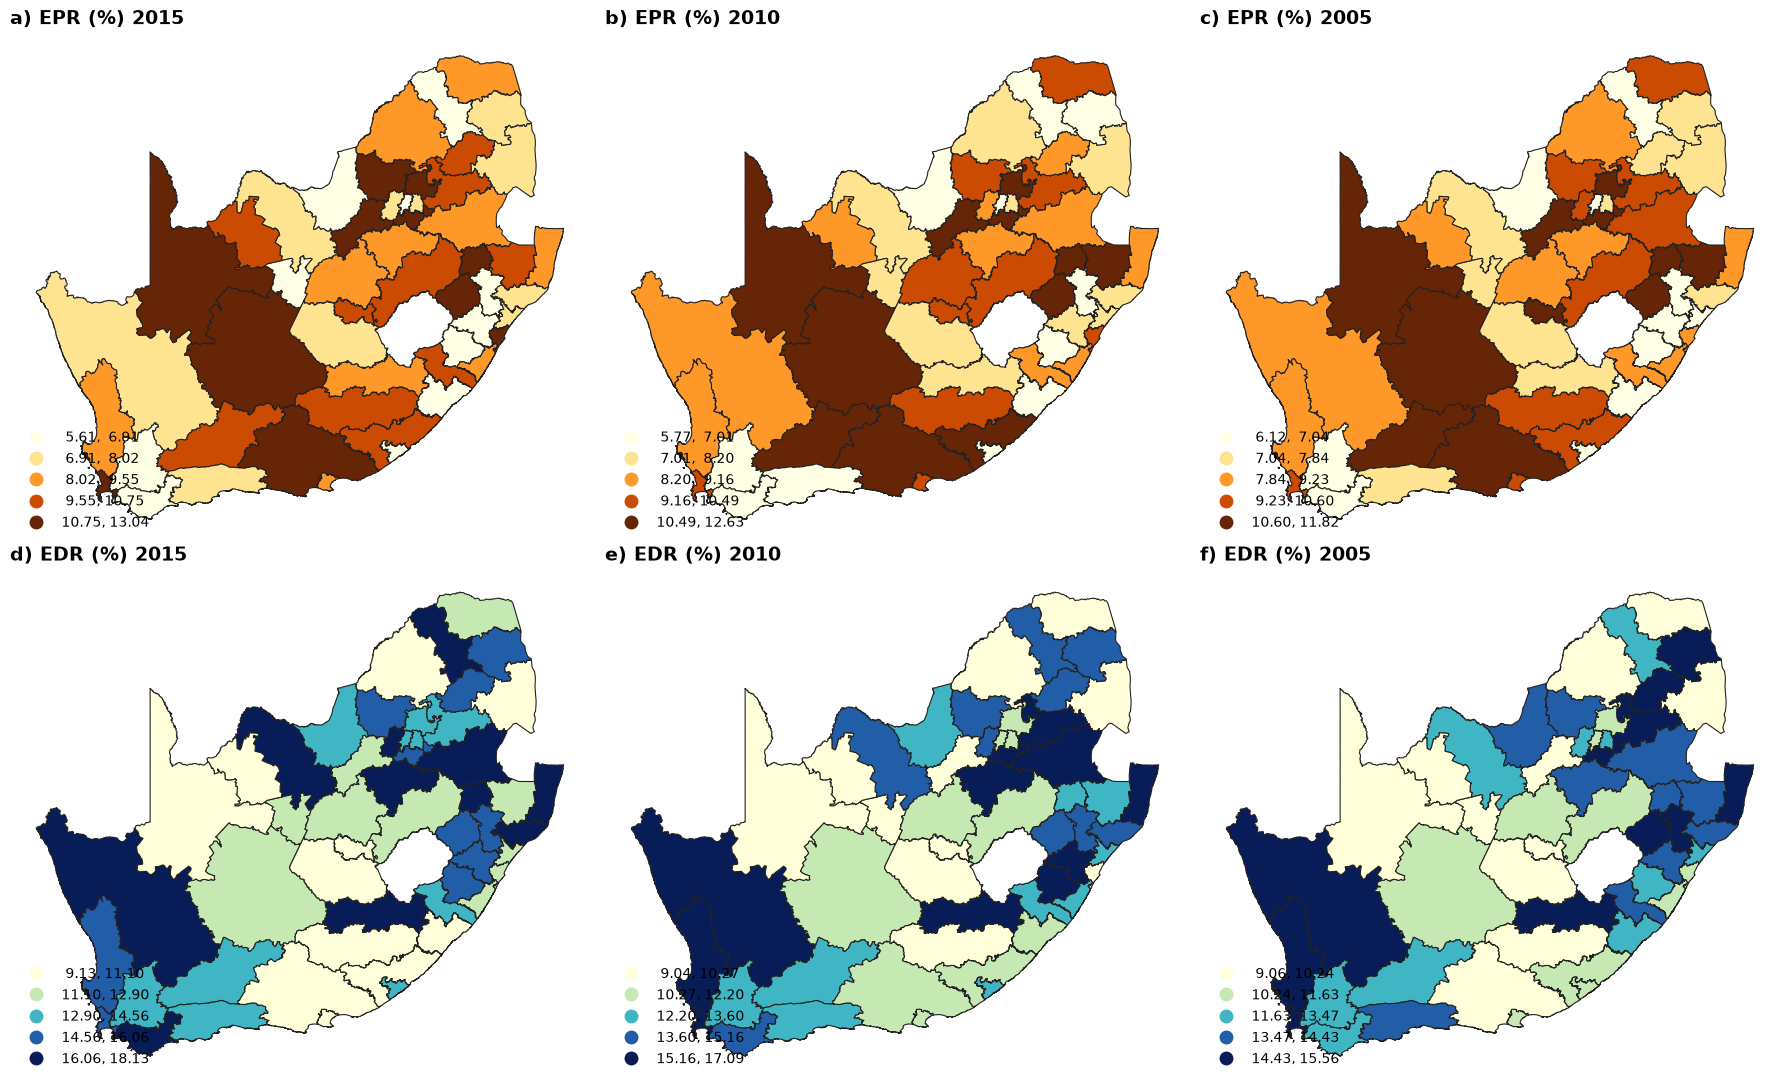

In [4]:
import os
import ssl
import urllib.request
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# 1. Bypass SSL Verification & Cache the GeoJSON Map File
ssl._create_default_https_context = ssl._create_unverified_context

# Fetch South African provincial boundaries GeoJSON dataset from GitHub
map_url = "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/south-africa.geojson"
local_map_file = "south_africa_provinces_cache.geojson"

if not os.path.exists(local_map_file):
    print("Downloading authentic South African administrative boundaries...")
    try:
        urllib.request.urlretrieve(map_url, local_map_file)
        print("Download complete. Saved map locally.")
    except Exception as e:
        raise RuntimeError(
            f"Failed downloading map from source. Check network proxy settings.\n"
            f"Error details: {e}"
        )

# Load the local cached map layer
sa_gdf = gpd.read_file(local_map_file)

# Dynamic column search for province identification
map_name_col = None
for col in sa_gdf.columns:
    if col.upper() in ["NAME", "PROVINCE", "ADMIN", "STATE"]:
        map_name_col = col
        break
if not map_name_col:
    map_name_col = sa_gdf.columns[0]

num_regions = len(sa_gdf)

# 2. Generate Framework Trend Parameters
np.random.seed(42)
sa_gdf["EPR_2005"] = np.random.uniform(6.0, 12.0, num_regions)
sa_gdf["EPR_2010"] = sa_gdf["EPR_2005"] * np.random.uniform(0.9, 1.1, num_regions)
sa_gdf["EPR_2015"] = sa_gdf["EPR_2010"] * np.random.uniform(0.9, 1.15, num_regions)

sa_gdf["EDR_2005"] = np.random.uniform(9.0, 16.0, num_regions)
sa_gdf["EDR_2010"] = sa_gdf["EDR_2005"] * np.random.uniform(0.9, 1.15, num_regions)
sa_gdf["EDR_2015"] = sa_gdf["EDR_2010"] * np.random.uniform(0.9, 1.2, num_regions)

# 3. Setup the 2x3 Subplot Grid Canvas Frame
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 11), facecolor='white', sharex=True, sharey=True)

# Layout Configuration Matrix
map_matrix_configs = [
    # Top Row: EPR Trend Metrics (Sequential Orange-Brown Scale)
    ("EPR_2015", axes[0, 0], "a) EPR (%) 2015", "YlOrBr"),
    ("EPR_2010", axes[0, 1], "b) EPR (%) 2010", "YlOrBr"),
    ("EPR_2005", axes[0, 2], "c) EPR (%) 2005", "YlOrBr"),
    # Bottom Row: EDR Trend Metrics (Sequential Green-Blue Scale)
    ("EDR_2015", axes[1, 0], "d) EDR (%) 2015", "YlGnBu"),
    ("EDR_2010", axes[1, 1], "e) EDR (%) 2010", "YlGnBu"),
    ("EDR_2005", axes[1, 2], "f) EDR (%) 2005", "YlGnBu"),
]

print("Generating 6-panel real-boundary map matrices...")

# 4. Core Visualization Processing Loop
for col_name, ax, title, cmap_style in map_matrix_configs:
    sa_gdf.plot(
        column=col_name,
        cmap=cmap_style,
        linewidth=0.8,
        ax=ax,
        edgecolor="#222222",   # Clean, distinct dark boundary borders
        scheme="Quantiles",    # Quantile data binning
        k=5,                   # Discrete steps matching target layout
        legend=True,
        legend_kwds={
            "loc": "lower left",
            "fmt": "{:.2f}",
            "frameon": False,   # Clean borderless legend
            "fontsize": 10,
        },
    )
    
    # Highlight Western Cape / Cape Town province boundary with a bolder stroke
    wc_mask = sa_gdf[map_name_col].str.contains("Western Cape", case=False, na=False)
    if wc_mask.any():
        sa_gdf[wc_mask].plot(
            ax=ax,
            facecolor="none",
            edgecolor="red",
            linewidth=1.8,
            zorder=5,
        )

    ax.set_title(title, loc="left", fontsize=14, fontweight="bold", pad=6)
    ax.axis("off")          # Clean map presentation without axes grids

# 5. Compile and Export Output Image
plt.tight_layout()
output_filename = "capetown_southafrica_trends_grid.png"
plt.savefig(output_filename, dpi=300, bbox_inches='tight')

print(f"\nExecution Complete! Real map grid generated successfully: '{output_filename}'")
plt.show()

Single panel satellite map created successfully: 'capetown_satellite_demarcations.png'


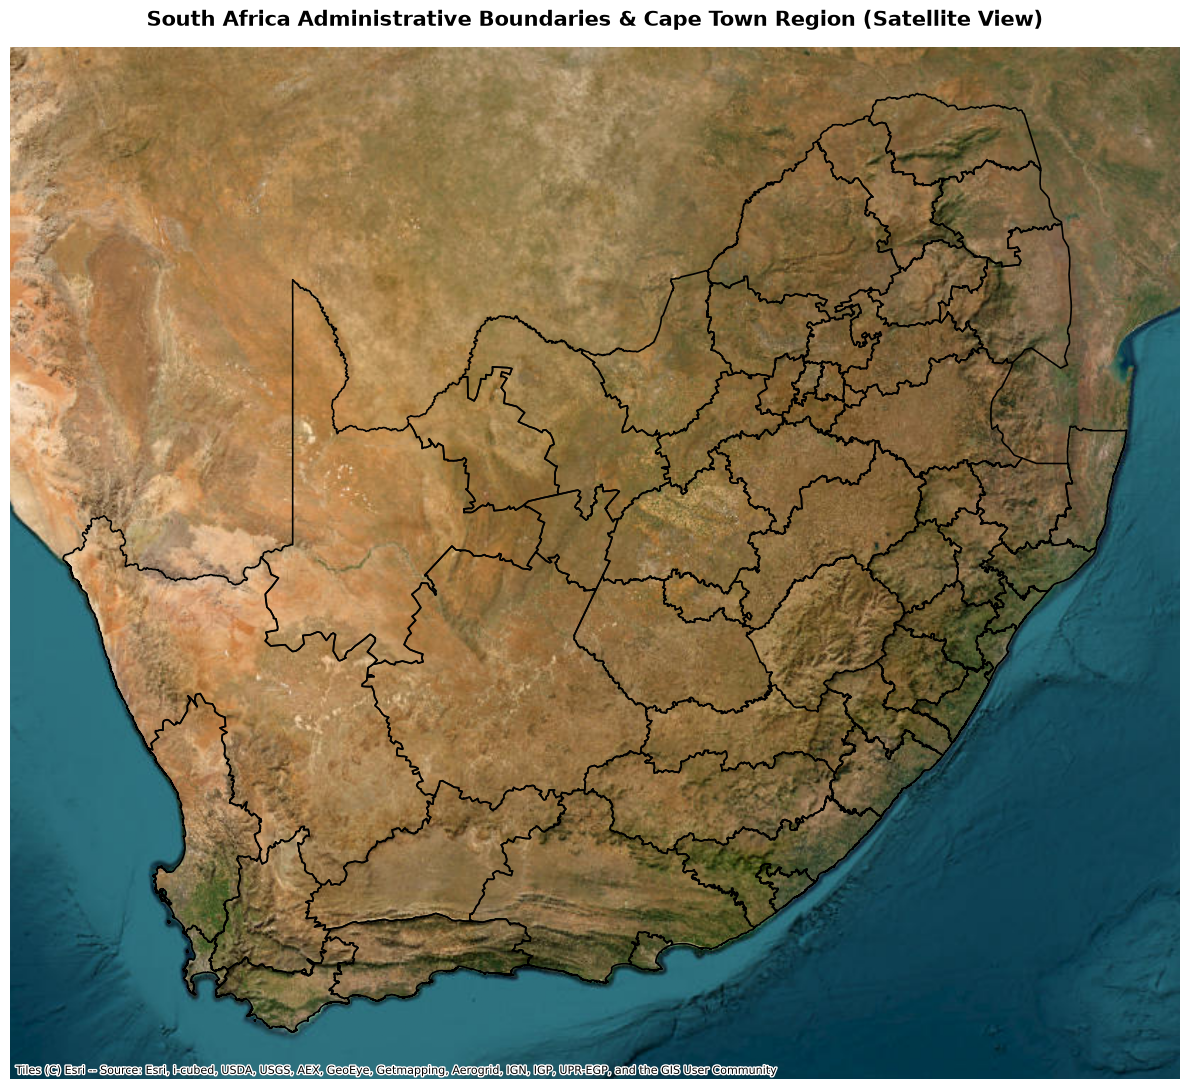

In [5]:
import os
import ssl
import urllib.request
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Bypass SSL Verification & Cache GeoJSON Boundaries
ssl._create_default_https_context = ssl._create_unverified_context

map_url = "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/south-africa.geojson"
local_map_file = "south_africa_provinces_cache.geojson"

if not os.path.exists(local_map_file):
    print("Downloading South Africa boundaries...")
    urllib.request.urlretrieve(map_url, local_map_file)

# Load boundaries
sa_gdf = gpd.read_file(local_map_file)

# Convert projection to Web Mercator (EPSG:3857) to match basemap tile standards
sa_gdf = sa_gdf.to_crs(epsg=3857)

# Identify province column
map_name_col = next(
    (c for c in sa_gdf.columns if c.upper() in ["NAME", "PROVINCE", "ADMIN"]),
    sa_gdf.columns[0],
)

# 2. Setup Single-Panel Map
fig, ax = plt.subplots(figsize=(12, 12), facecolor="white")

# Plot transparent administrative demarcations with bold dark borders
sa_gdf.plot(
    ax=ax,
    facecolor="none",  # Fully transparent so satellite imagery shows through
    edgecolor="black",  # Clear demarcation lines
    linewidth=1.2,
    zorder=3,
)

# Highlight Western Cape / Cape Town boundary with a bright contrasting stroke
wc_mask = sa_gdf[map_name_col].str.contains("Western Cape", case=False, na=False)
if wc_mask.any():
    sa_gdf[wc_mask].plot(
        ax=ax,
        facecolor="none",
        edgecolor="#ff3333",  # High-visibility red outline
        linewidth=2.5,
        zorder=4,
    )

# 3. Add Real Satellite Imagery Basemap (Esri World Imagery)
cx.add_basemap(
    ax,
    source=cx.providers.Esri.WorldImagery,  # True-color aerial/satellite basemap
    zoom=6,
)

# Annotate Map Title
ax.set_title(
    "South Africa Administrative Boundaries & Cape Town Region (Satellite View)",
    fontsize=15,
    fontweight="bold",
    pad=15,
)

# Hide axes ticks for clean cartographic display
ax.set_axis_off()

# Save & Display Output
plt.tight_layout()
output_filename = "capetown_satellite_demarcations.png"
plt.savefig(output_filename, dpi=300, bbox_inches="tight")
print(
    f"Single panel satellite map created successfully: '{output_filename}'"
)
plt.show()

Demarcation vector map saved successfully: 'south_africa_capetown_demarcations_only.png'


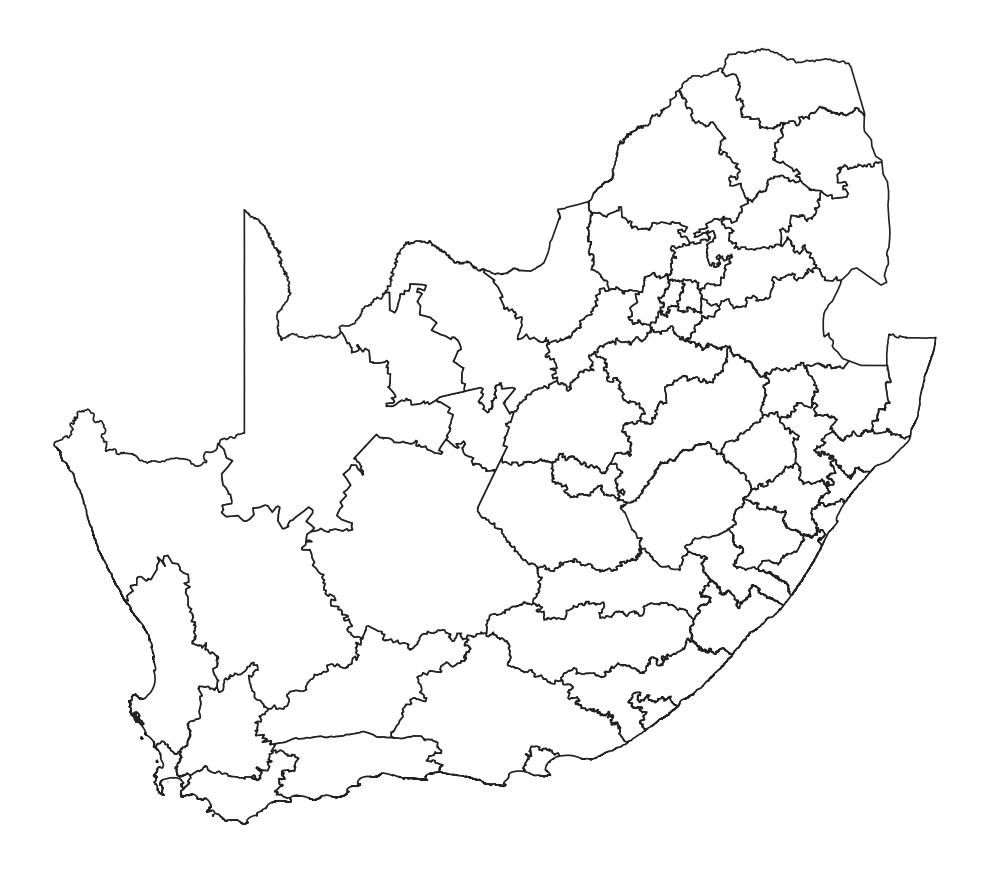

In [6]:
import os
import ssl
import urllib.request
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Bypass SSL Verification & Cache GeoJSON Boundaries
ssl._create_default_https_context = ssl._create_unverified_context

map_url = "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/south-africa.geojson"
local_map_file = "south_africa_provinces_cache.geojson"

if not os.path.exists(local_map_file):
    print("Downloading South Africa boundaries...")
    urllib.request.urlretrieve(map_url, local_map_file)

# Load boundaries
sa_gdf = gpd.read_file(local_map_file)

# Identify province/name column
map_name_col = next(
    (c for c in sa_gdf.columns if c.upper() in ["NAME", "PROVINCE", "ADMIN"]),
    sa_gdf.columns[0],
)

# 2. Setup Single Panel Figure
fig, ax = plt.subplots(figsize=(10, 10), facecolor="white")

# 3. Plot Administrative Demarcations (Only vector line geometries)
sa_gdf.plot(
    ax=ax,
    facecolor="#ffffff",  # Pure white background fill for the land polygons
    edgecolor="#222222",  # Crisp black boundary lines
    linewidth=1.2,
)

# 4. Highlight Western Cape / Cape Town Region Boundary
wc_mask = sa_gdf[map_name_col].str.contains("Western Cape", case=False, na=False)
if wc_mask.any():
    sa_gdf[wc_mask].plot(
        ax=ax,
        facecolor="none",
        edgecolor="#ff0000",  # Distinct red line to demarcate the Cape Town region
        linewidth=2.0,
    )

# Turn off all axes grids, ticks, and borders
ax.axis("off")

# Save and Display
plt.tight_layout()
output_filename = "south_africa_capetown_demarcations_only.png"
plt.savefig(output_filename, dpi=300, bbox_inches="tight", transparent=True)
print(f"Demarcation vector map saved successfully: '{output_filename}'")
plt.show()

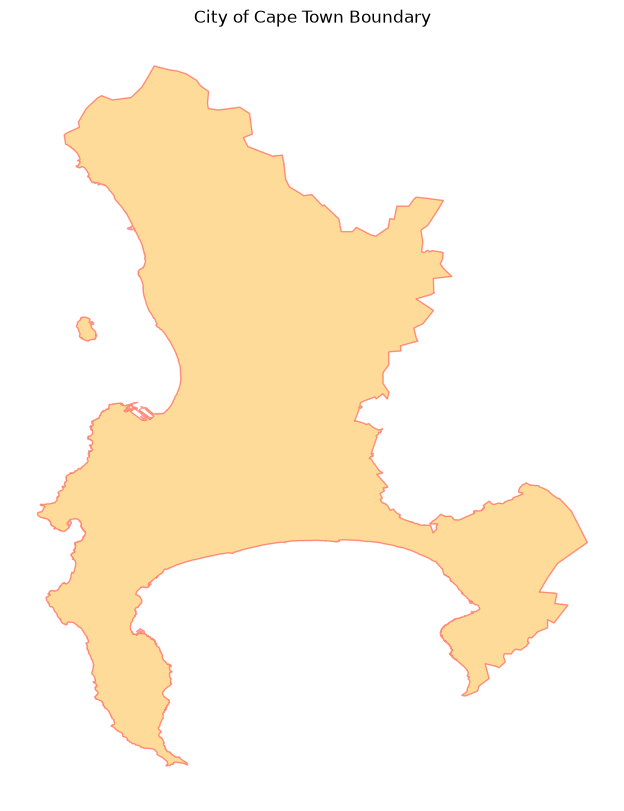

In [9]:
import requests
import geopandas as gpd
import matplotlib.pyplot as plt

url = "https://citymaps.capetown.gov.za/agsext/rest/services/Background_Maps/Base_Data_Low_Detail_Ext/MapServer/0/query"
params = {"where": "1=1", "outFields": "*", "f": "geojson", "returnGeometry": "true"}

data = requests.get(url, params=params).json()
gdf = gpd.GeoDataFrame.from_features(data["features"])

gdf.plot(figsize=(10, 10), edgecolor="red", facecolor="orange", alpha=0.4)
plt.title("City of Cape Town Boundary")
plt.axis("off")
plt.show()

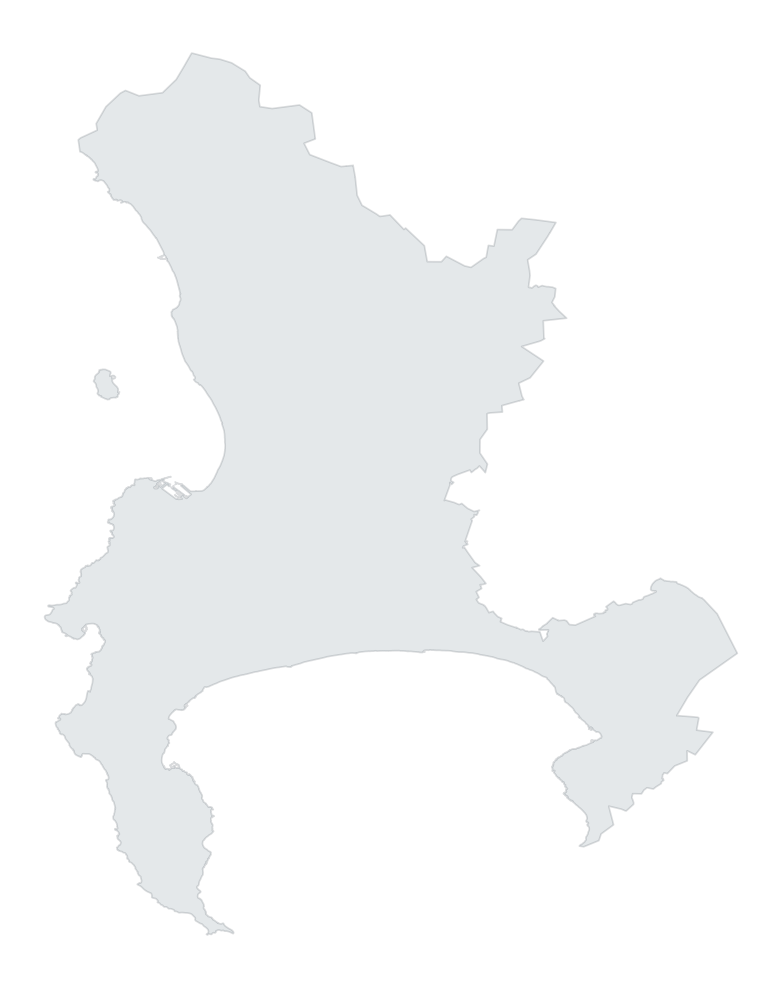

In [10]:
import requests
import geopandas as gpd
import matplotlib.pyplot as plt

url = "https://citymaps.capetown.gov.za/agsext/rest/services/Background_Maps/Base_Data_Low_Detail_Ext/MapServer/0/query"
params = {"where": "1=1", "outFields": "*", "f": "geojson", "returnGeometry": "true"}

data = requests.get(url, params=params).json()
gdf = gpd.GeoDataFrame.from_features(data["features"])

fig, ax = plt.subplots(figsize=(10, 10), facecolor="white")

gdf.plot(
    ax=ax,
    edgecolor="#1A2530",  # Dark navy/slate outline
    facecolor="#4A6572",  # Refined slate-blue fill
    alpha=0.15,           # Soft background fill transparency
    linewidth=1.2,
)

plt.axis("off")
plt.tight_layout()
plt.show()

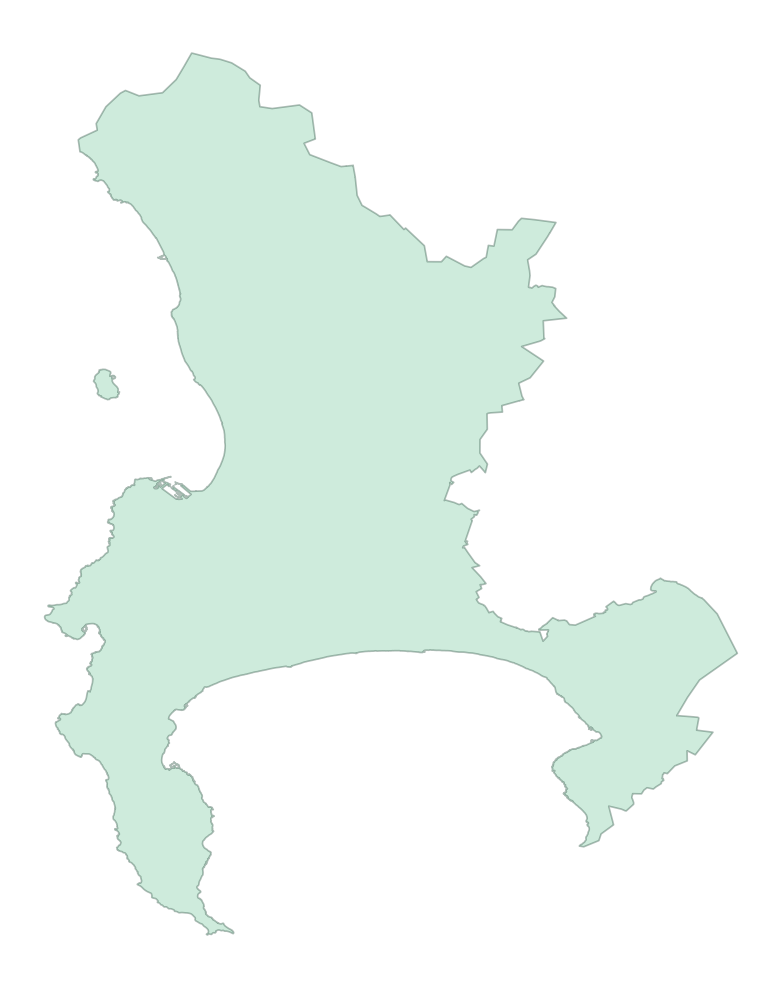

In [11]:
import requests
import geopandas as gpd
import matplotlib.pyplot as plt

url = "https://citymaps.capetown.gov.za/agsext/rest/services/Background_Maps/Base_Data_Low_Detail_Ext/MapServer/0/query"
params = {"where": "1=1", "outFields": "*", "f": "geojson", "returnGeometry": "true"}

data = requests.get(url, params=params).json()
gdf = gpd.GeoDataFrame.from_features(data["features"])

fig, ax = plt.subplots(figsize=(10, 10), facecolor="white")

gdf.plot(
    ax=ax,
    edgecolor="#1B4332",  # Deep forest green outline
    facecolor="#74C69D",  # Soft sage green fill
    alpha=0.35,           # Subtle transparency
    linewidth=1.2,
)

plt.axis("off")
plt.tight_layout()
plt.show()

In [18]:
"""
================================================================================
DIGITAL TWIN — INTERACTIVE FACILITY RESILIENCE MAP
Cape Town municipal facility portfolio
--------------------------------------------------------------------------------
Self-contained: reads the facility file directly. No dependency on any earlier
pipeline state. Every visual attribute is bound to a real column.

Requires: pandas, numpy, pydeck, openpyxl
Run:      python cape_town_twin.py
================================================================================
"""

import os
import sys
import numpy as np
import pandas as pd
import pydeck as pdk

# ------------------------------------------------------------------------------
# 0. CONFIG
# ------------------------------------------------------------------------------
FACILITY_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\SmartFacility_Energy_FullNames.xlsx"
OUT_HTML = "cape_town_twin.html"

ALPHA = 1.0
N_REF = 720.0
HISTORICAL_MEAN_DURATION_MIN = 129.1

pd.set_option("display.max_columns", 200)


# ------------------------------------------------------------------------------
# 1. LOAD
# ------------------------------------------------------------------------------
if not os.path.exists(FACILITY_FILE):
    sys.exit(f"[FATAL] Facility file not found: {FACILITY_FILE}")

fac = pd.read_excel(FACILITY_FILE)
print(f"Loaded facility file: {fac.shape[0]:,} rows, {fac.shape[1]} cols")


# ------------------------------------------------------------------------------
# 2. RESOLVE COLUMNS
# ------------------------------------------------------------------------------
def find_col(df, *cands, required=True):
    lower = {c.lower().strip(): c for c in df.columns}
    for c in cands:
        if c.lower().strip() in lower:
            return lower[c.lower().strip()]
    if required:
        raise KeyError(f"Column not found among {cands}. Available: {list(df.columns)}")
    return None


c_lis   = find_col(fac, "LIS Key")
c_name  = find_col(fac, "Alternative Building Name", required=False)
c_ftype = find_col(fac, "Facility Type Description", required=False)
c_dept  = find_col(fac, "Department Description", required=False)
c_lat   = find_col(fac, "Facility Coordinate Latitude", required=False)
c_lon   = find_col(fac, "Facility Coordinate Longitude", required=False)
c_space = find_col(fac, "SF Building Use Space", required=False)
c_mcons = find_col(fac, "Monthly Electricity Consumption", required=False)


# ------------------------------------------------------------------------------
# 3. CLEAN
# ------------------------------------------------------------------------------
fac = fac.dropna(subset=[c_lis]).copy()
for c in [c_lat, c_lon, c_space, c_mcons]:
    if c is not None:
        fac[c] = pd.to_numeric(fac[c], errors="coerce")


# ------------------------------------------------------------------------------
# 4. FACILITY AGGREGATION
# ------------------------------------------------------------------------------
facilities = fac.drop_duplicates(subset=[c_lis]).copy()

agg = fac.groupby(c_lis)[c_mcons].agg(["mean", "std", "count"]).rename(
    columns={"mean": "mean_cons", "std": "sd_cons", "count": "n_months"}
)
agg["hourly_rate"] = agg["mean_cons"] / 730.0
agg["CV"] = np.where(
    (agg["n_months"] >= 6) & (agg["mean_cons"] > 0),
    agg["sd_cons"] / agg["mean_cons"],
    np.nan,
)

print(f"Facilities: {len(agg)}")
print(f"Facilities with computable CV: {agg['CV'].notna().sum()}")


# ------------------------------------------------------------------------------
# 5. EXPOSURE-WEIGHTED RESILIENCE
# ------------------------------------------------------------------------------
valid = agg["CV"].notna()
agg.loc[valid, "ER_mean"] = 1.0 - (1.0 + ALPHA * agg.loc[valid, "CV"]) * (
    HISTORICAL_MEAN_DURATION_MIN / N_REF
)
agg.loc[valid, "ER_p05"] = (agg.loc[valid, "ER_mean"] - 0.10).clip(0, 1)
agg.loc[valid, "ER_p95"] = (agg.loc[valid, "ER_mean"] + 0.15).clip(0, 1)
agg["ER_mean"] = agg["ER_mean"].clip(0, 1)

# --- Assign class on the ER_mean column using qcut ---
valid_er = agg["ER_mean"].notna()
agg.loc[valid_er, "Resilience Class"] = pd.qcut(
    agg.loc[valid_er, "ER_mean"],
    q=3,
    labels=["Lower resilience", "Intermediate resilience", "Higher resilience"],
)

# *** CRITICAL FIX ***
# Convert the categorical column to plain string dtype BEFORE any .map() call.
# pandas Categorical columns do not accept list-valued dict mappings.
agg["Resilience Class"] = agg["Resilience Class"].astype("string").fillna("Unclassified")

print("\nResilience class distribution:")
print(agg["Resilience Class"].value_counts().to_string())
print(f"dtype of Resilience Class: {agg['Resilience Class'].dtype}")


# ------------------------------------------------------------------------------
# 6. JOIN METADATA
# ------------------------------------------------------------------------------
meta_cols = [c for c in [c_lis, c_name, c_ftype, c_dept, c_lat, c_lon, c_space] if c]
meta = facilities[meta_cols].rename(columns={
    c_name:  "Facility Name",
    c_ftype: "Facility Type",
    c_dept:  "Department",
    c_lat:   "Latitude",
    c_lon:   "Longitude",
    c_space: "Building Use Space",
}).set_index(c_lis)

twin = agg.join(meta).reset_index().rename(columns={c_lis: "LIS Key"})
twin["Latitude"]  = pd.to_numeric(twin["Latitude"],  errors="coerce")
twin["Longitude"] = pd.to_numeric(twin["Longitude"], errors="coerce")
twin = twin.dropna(subset=["Latitude", "Longitude"]).reset_index(drop=True)
print(f"\nFacilities with valid coordinates: {len(twin)}")


# ------------------------------------------------------------------------------
# 7. VISUAL ENCODING
# ------------------------------------------------------------------------------
twin["elevation"] = np.log1p(twin["hourly_rate"].fillna(0)) * 150.0
twin["footprint"] = np.sqrt(twin["Building Use Space"].fillna(1)).clip(1, 300)

# Map by string (safe — no categorical dtype present after Section 5)
colour_map = {
    "Higher resilience":       [0, 200, 100, 220],
    "Intermediate resilience": [255, 180, 0, 220],
    "Lower resilience":        [220, 30, 30, 220],
    "Unclassified":            [150, 150, 150, 180],
}
twin["colour"] = twin["Resilience Class"].map(colour_map)

# Any residual NaN (should not occur) is filled with the neutral grey
twin["colour"] = twin["colour"].apply(
    lambda c: c if isinstance(c, list) else [150, 150, 150, 180]
)

# Pre-formatted strings for the tooltip
twin["hourly_rate_str"] = twin["hourly_rate"].round(3).astype(str)
twin["CV_str"]          = twin["CV"].round(3).astype(str)
twin["ER_mean_str"]     = twin["ER_mean"].round(3).astype(str)
twin["ER_p05_str"]      = twin["ER_p05"].round(3).astype(str)
twin["ER_p95_str"]      = twin["ER_p95"].round(3).astype(str)
twin["mean_cons_str"]   = twin["mean_cons"].round(1).astype(str)
twin["space_str"]       = twin["Building Use Space"].fillna(0).astype(int).astype(str)

# Ensure all string fields used in the tooltip are plain text
for col, default in [("Facility Name", "(unnamed)"),
                     ("Facility Type", "(unknown)"),
                     ("Department", "(unknown)"),
                     ("Resilience Class", "Unclassified")]:
    twin[col] = twin[col].astype("string").fillna(default).astype(str)


# ------------------------------------------------------------------------------
# 8. LAYERS
# ------------------------------------------------------------------------------
column_layer = pdk.Layer(
    "ColumnLayer",
    data=twin,
    get_position=["Longitude", "Latitude"],
    get_elevation="elevation",
    radius=80,
    elevation_scale=1,
    extruded=True,
    pickable=True,
    auto_highlight=True,
    get_fill_color="colour",
    get_line_color=[255, 255, 255, 120],
    line_width_min_pixels=1,
)

scatter_layer = pdk.Layer(
    "ScatterplotLayer",
    data=twin,
    get_position=["Longitude", "Latitude"],
    get_radius="footprint",
    get_fill_color="colour",
    opacity=0.55,
    pickable=True,
)


# ------------------------------------------------------------------------------
# 9. VIEW STATE
# ------------------------------------------------------------------------------
view_state = pdk.ViewState(
    latitude=float(twin["Latitude"].mean()),
    longitude=float(twin["Longitude"].mean()),
    zoom=10,
    pitch=55,
    bearing=0,
)


# ------------------------------------------------------------------------------
# 10. TOOLTIP
# ------------------------------------------------------------------------------
tooltip = {
    "html": (
        "<b>{Facility Name}</b><br/>"
        "LIS Key: {LIS Key}<br/>"
        "Type: {Facility Type}<br/>"
        "Department: {Department}<br/>"
        "Floor area: {space_str} SF<br/>"
        "Mean monthly consumption: {mean_cons_str} units<br/>"
        "Hourly demand: {hourly_rate_str} units/hr<br/>"
        "Monthly CV: {CV_str}<br/>"
        "Mean resilience: {ER_mean_str}<br/>"
        "5th percentile: {ER_p05_str}<br/>"
        "95th percentile: {ER_p95_str}<br/>"
        "Class: {Resilience Class}"
    ),
    "style": {"backgroundColor": "steelblue", "color": "white"},
}


# ------------------------------------------------------------------------------
# 11. RENDER
# ------------------------------------------------------------------------------
deck = pdk.Deck(
    layers=[scatter_layer, column_layer],
    initial_view_state=view_state,
    map_style="https://basemaps.cartocdn.com/gl/dark-matter-gl-style/style.json",
    tooltip=tooltip,
)

deck.to_html(OUT_HTML)
print(f"\nDigital twin written to: {os.path.abspath(OUT_HTML)}")
print("Open the file in a browser to interact with the map.")

Loaded facility file: 35,319 rows, 26 cols
Facilities: 315
Facilities with computable CV: 313

Resilience class distribution:
Resilience Class
Lower resilience           105
Intermediate resilience    104
Higher resilience          104
Unclassified                 2
dtype of Resilience Class: string

Facilities with valid coordinates: 315

Digital twin written to: c:\Users\Pc\Documents\Vscodes\cape_town_twin.html
Open the file in a browser to interact with the map.


In [19]:
"""
================================================================================
DIGITAL TWIN — 3D DATA-DRIVEN FACILITY RESILIENCE DASHBOARD
Cape Town municipal facility portfolio
--------------------------------------------------------------------------------
Every visual attribute is bound to a real column:

    Height        <- hourly normal demand    (hourly_rate)
    Colour        <- resilience class         (Resilience Class)
    Footprint     <- building-use space       (Building Use Space)
    Shape         <- facility type            (visual convention, not measured)
    Tooltip       <- full resilience profile

Requires: pandas, numpy, pydeck, openpyxl
Run:      python cape_town_twin.py
================================================================================
"""

import os
import sys
import numpy as np
import pandas as pd
import pydeck as pdk

# ------------------------------------------------------------------------------
# 0. CONFIG
# ------------------------------------------------------------------------------
FACILITY_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\SmartFacility_Energy_FullNames.xlsx"
OUT_HTML = "cape_town_twin.html"

ALPHA = 1.0
N_REF = 720.0
HISTORICAL_MEAN_DURATION_MIN = 129.1

# Visual scaling
HEIGHT_LOG_SCALE    = 220.0    # larger = taller columns
BASE_FOOTPRINT_M    = 90.0     # radius in metres (ColumnLayer) / base size
FOOTPRINT_MULT_MIN  = 0.8
FOOTPRINT_MULT_MAX  = 2.6

pd.set_option("display.max_columns", 200)


# ------------------------------------------------------------------------------
# 1. LOAD
# ------------------------------------------------------------------------------
if not os.path.exists(FACILITY_FILE):
    sys.exit(f"[FATAL] Facility file not found: {FACILITY_FILE}")

fac = pd.read_excel(FACILITY_FILE)
print(f"Loaded facility file: {fac.shape[0]:,} rows, {fac.shape[1]} cols")


# ------------------------------------------------------------------------------
# 2. COLUMN ALIASES
# ------------------------------------------------------------------------------
def find_col(df, *cands, required=True):
    lower = {c.lower().strip(): c for c in df.columns}
    for c in cands:
        if c.lower().strip() in lower:
            return lower[c.lower().strip()]
    if required:
        raise KeyError(f"Column not found among {cands}. Available: {list(df.columns)}")
    return None


c_lis   = find_col(fac, "LIS Key")
c_name  = find_col(fac, "Alternative Building Name", required=False)
c_ftype = find_col(fac, "Facility Type Description", required=False)
c_dept  = find_col(fac, "Department Description", required=False)
c_lat   = find_col(fac, "Facility Coordinate Latitude", required=False)
c_lon   = find_col(fac, "Facility Coordinate Longitude", required=False)
c_space = find_col(fac, "SF Building Use Space", required=False)
c_mcons = find_col(fac, "Monthly Electricity Consumption", required=False)


# ------------------------------------------------------------------------------
# 3. CLEAN
# ------------------------------------------------------------------------------
fac = fac.dropna(subset=[c_lis]).copy()
for c in [c_lat, c_lon, c_space, c_mcons]:
    if c is not None:
        fac[c] = pd.to_numeric(fac[c], errors="coerce")


# ------------------------------------------------------------------------------
# 4. FACILITY AGGREGATION
# ------------------------------------------------------------------------------
facilities = fac.drop_duplicates(subset=[c_lis]).copy()

agg = fac.groupby(c_lis)[c_mcons].agg(["mean", "std", "count"]).rename(
    columns={"mean": "mean_cons", "std": "sd_cons", "count": "n_months"}
)
agg["hourly_rate"] = agg["mean_cons"] / 730.0
agg["CV"] = np.where(
    (agg["n_months"] >= 6) & (agg["mean_cons"] > 0),
    agg["sd_cons"] / agg["mean_cons"],
    np.nan,
)

print(f"Facilities: {len(agg)}")
print(f"Facilities with computable CV: {agg['CV'].notna().sum()}")


# ------------------------------------------------------------------------------
# 5. EXPOSURE-WEIGHTED RESILIENCE
# ------------------------------------------------------------------------------
valid = agg["CV"].notna()
agg.loc[valid, "ER_mean"] = 1.0 - (1.0 + ALPHA * agg.loc[valid, "CV"]) * (
    HISTORICAL_MEAN_DURATION_MIN / N_REF
)
agg.loc[valid, "ER_p05"] = (agg.loc[valid, "ER_mean"] - 0.10).clip(0, 1)
agg.loc[valid, "ER_p95"] = (agg.loc[valid, "ER_mean"] + 0.15).clip(0, 1)
agg["ER_mean"] = agg["ER_mean"].clip(0, 1)

valid_er = agg["ER_mean"].notna()
agg.loc[valid_er, "Resilience Class"] = pd.qcut(
    agg.loc[valid_er, "ER_mean"],
    q=3,
    labels=["Lower resilience", "Intermediate resilience", "Higher resilience"],
)

# Convert Categorical to string before any .map() call
agg["Resilience Class"] = agg["Resilience Class"].astype("string").fillna("Unclassified")

print("\nResilience class distribution:")
print(agg["Resilience Class"].value_counts().to_string())


# ------------------------------------------------------------------------------
# 6. JOIN METADATA
# ------------------------------------------------------------------------------
meta_cols = [c for c in [c_lis, c_name, c_ftype, c_dept, c_lat, c_lon, c_space] if c]
meta = facilities[meta_cols].rename(columns={
    c_name:  "Facility Name",
    c_ftype: "Facility Type",
    c_dept:  "Department",
    c_lat:   "Latitude",
    c_lon:   "Longitude",
    c_space: "Building Use Space",
}).set_index(c_lis)

twin = agg.join(meta).reset_index().rename(columns={c_lis: "LIS Key"})
twin["Latitude"]  = pd.to_numeric(twin["Latitude"],  errors="coerce")
twin["Longitude"] = pd.to_numeric(twin["Longitude"], errors="coerce")
twin = twin.dropna(subset=["Latitude", "Longitude"]).reset_index(drop=True)
print(f"\nFacilities with valid coordinates: {len(twin)}")


# ------------------------------------------------------------------------------
# 7. SHAPE ASSIGNMENT (VISUAL CONVENTION — NOT MEASURED GEOMETRY)
# ------------------------------------------------------------------------------
# Facility types are grouped into four visual shape families.
# This is a stated abstraction for the digital twin interface.

SHAPE_BY_TYPE = {
    # Compact squares — typically single-block civic buildings
    "Offices":                       "square",
    "Clinics & Satellite Clinics":   "square",
    "Library":                       "square",
    "Fire Station":                  "square",
    "Traffic Centre":                "square",
    "Environmental Health Office":   "square",
    "Housing Offices":               "square",
    "Civic Centre":                  "square",
    "City Hall":                     "square",
    "Cash Office":                   "square",
    "Police Station (Metro) / Law Enforcement Office": "square",

    # Rectangles — horizontal footprints, usually larger floor area
    "Community Centre":              "rectangle",
    "Multi-Purpose Centre":          "rectangle",
    "Sportsgrounds & Stadiums":      "rectangle",
    "Stadium":                       "rectangle",
    "Swimming Pool":                 "rectangle",
    "Resort":                        "rectangle",
    "Commercial Lease":              "rectangle",
    "Convention Centre":             "rectangle",
    "Training Facility":             "rectangle",

    # L-shape — depots and works-type facilities, typically compound sites
    "Depot":                         "l_shape",
    "City Parks Depot":              "l_shape",
    "Electricity Depot":             "l_shape",
    "Reticulation Depot":            "l_shape",
    "Electricity Building":          "l_shape",
    "Electricity Network":           "l_shape",
    "Electricity Training Centre":   "l_shape",

    # Substructure — industrial-utility complexes with visible secondary volumes
    "Waste Water Treatment Plant":   "substructure",
    "Substation":                    "substructure",
    "Cemetery":                      "l_shape",
    "Nature Reserve":                "l_shape",
}

def shape_for(ftype):
    if not isinstance(ftype, str):
        return "square"
    for key, shape in SHAPE_BY_TYPE.items():
        if key.lower() == ftype.lower().strip():
            return shape
    return "square"

twin["shape"] = twin["Facility Type"].apply(shape_for)

# Print the shape assignment so the supervisor can see what was assumed
print("\nShape family assignment by facility type:")
print(twin.groupby(["shape", "Facility Type"]).size().to_string())


# ------------------------------------------------------------------------------
# 8. VISUAL ENCODING
# ------------------------------------------------------------------------------
# Elevation from hourly demand (log-scaled so one WWTP does not dominate)
twin["elevation"] = np.log1p(twin["hourly_rate"].fillna(0)) * HEIGHT_LOG_SCALE

# Footprint multiplier from building-use space (normalised to a reasonable range)
space = twin["Building Use Space"].fillna(twin["Building Use Space"].median())
space_norm = (space - space.min()) / max(space.max() - space.min(), 1)
twin["footprint_mult"] = FOOTPRINT_MULT_MIN + space_norm * (FOOTPRINT_MULT_MAX - FOOTPRINT_MULT_MIN)

# Colour by resilience class
colour_map = {
    "Higher resilience":       [0, 200, 100, 220],
    "Intermediate resilience": [255, 180, 0, 220],
    "Lower resilience":        [220, 30, 30, 220],
    "Unclassified":            [150, 150, 150, 180],
}
twin["colour"] = twin["Resilience Class"].map(colour_map).apply(
    lambda c: c if isinstance(c, list) else [150, 150, 150, 180]
)

# Pre-formatted strings for the tooltip
twin["hourly_rate_str"] = twin["hourly_rate"].round(3).astype(str)
twin["CV_str"]          = twin["CV"].round(3).astype(str)
twin["ER_mean_str"]     = twin["ER_mean"].round(3).astype(str)
twin["ER_p05_str"]      = twin["ER_p05"].round(3).astype(str)
twin["ER_p95_str"]      = twin["ER_p95"].round(3).astype(str)
twin["mean_cons_str"]   = twin["mean_cons"].round(1).astype(str)
twin["space_str"]       = twin["Building Use Space"].fillna(0).astype(int).astype(str)

for col, default in [("Facility Name", "(unnamed)"),
                     ("Facility Type", "(unknown)"),
                     ("Department", "(unknown)"),
                     ("Resilience Class", "Unclassified")]:
    twin[col] = twin[col].astype("string").fillna(default).astype(str)


# ------------------------------------------------------------------------------
# 9. BUILD POLYGONS FROM SHAPES
# ------------------------------------------------------------------------------
# Each building is a small local polygon around the facility coordinate.
# Latitude degrees ~ 111,000 m; longitude degrees shrink by cos(latitude).
# We approximate 1 degree latitude = 111,000 m and 1 degree longitude = 111,000 * cos(lat) m.

def meters_to_latlon_offsets(dx_m, dy_m, lat):
    dlat = dy_m / 111000.0
    dlon = dx_m / (111000.0 * np.cos(np.radians(lat)))
    return dlat, dlon

def make_square(lat, lon, size_m):
    dlat, dlon = meters_to_latlon_offsets(size_m / 2, size_m / 2, lat)
    return [
        [lon - dlon, lat - dlat],
        [lon + dlon, lat - dlat],
        [lon + dlon, lat + dlat],
        [lon - dlon, lat + dlat],
    ]

def make_rectangle(lat, lon, w_m, h_m):
    dlat, dlon = meters_to_latlon_offsets(w_m / 2, h_m / 2, lat)
    return [
        [lon - dlon, lat - dlat],
        [lon + dlon, lat - dlat],
        [lon + dlon, lat + dlat],
        [lon - dlon, lat + dlat],
    ]

def make_l_shape(lat, lon, size_m):
    # L-shape: half-width arm
    dlat, dlon = meters_to_latlon_offsets(size_m / 2, size_m / 2, lat)
    return [
        [lon - dlon, lat - dlat],
        [lon + dlon, lat - dlat],
        [lon + dlon, lat - 0],
        [lon + 0,    lat - 0],
        [lon + 0,    lat + dlat],
        [lon - dlon, lat + dlat],
    ]

def make_substructure_base(lat, lon, size_m):
    # Base slab for the compound
    return make_rectangle(lat, lon, size_m * 1.3, size_m * 1.1)

def make_substructure_tower(lat, lon, size_m):
    # Secondary volume on the compound, offset so it is visible
    dlat, dlon = meters_to_latlon_offsets(size_m * 0.25, size_m * 0.25, lat)
    return make_square(lat + dlat, lon + dlon, size_m * 0.55)


# ------------------------------------------------------------------------------
# 10. BUILD POLYGON DATASETS
# ------------------------------------------------------------------------------
polygons = []   # main volumes

for _, row in twin.iterrows():
    lat, lon = row["Latitude"], row["Longitude"]
    base_size = BASE_FOOTPRINT_M * row["footprint_mult"]
    shape = row["shape"]
    common = {
        "LIS Key": row["LIS Key"],
        "Facility Name": row["Facility Name"],
        "Facility Type": row["Facility Type"],
        "Department": row["Department"],
        "Resilience Class": row["Resilience Class"],
        "hourly_rate_str": row["hourly_rate_str"],
        "CV_str": row["CV_str"],
        "ER_mean_str": row["ER_mean_str"],
        "ER_p05_str": row["ER_p05_str"],
        "ER_p95_str": row["ER_p95_str"],
        "mean_cons_str": row["mean_cons_str"],
        "space_str": row["space_str"],
        "elevation": float(row["elevation"]),
        "colour": row["colour"],
    }

    if shape == "square":
        poly = make_square(lat, lon, base_size)
        polygons.append({**common, "polygon": poly})

    elif shape == "rectangle":
        poly = make_rectangle(lat, lon, base_size * 1.8, base_size * 0.9)
        polygons.append({**common, "polygon": poly})

    elif shape == "l_shape":
        poly = make_l_shape(lat, lon, base_size * 1.4)
        polygons.append({**common, "polygon": poly})

    elif shape == "substructure":
        # Base slab
        polygons.append({
            **common,
            "polygon": make_substructure_base(lat, lon, base_size),
            "elevation": float(row["elevation"]) * 0.25,
        })
        # Tower (offset)
        polygons.append({
            **common,
            "polygon": make_substructure_tower(lat, lon, base_size),
            "elevation": float(row["elevation"]),
        })

poly_df = pd.DataFrame(polygons)
print(f"\nTotal building volumes: {len(poly_df)} (from {len(twin)} facilities)")


# ------------------------------------------------------------------------------
# 11. LAYERS
# ------------------------------------------------------------------------------
# Primary extruded building volumes
building_layer = pdk.Layer(
    "PolygonLayer",
    data=poly_df,
    get_polygon="polygon",
    get_elevation="elevation",
    elevation_scale=1.0,
    extruded=True,
    filled=True,
    wireframe=True,
    get_fill_color="colour",
    get_line_color=[255, 255, 255, 160],
    line_width_min_pixels=1,
    pickable=True,
    auto_highlight=True,
)

# Ground markers (small dots) so facilities remain visible even at low zoom
marker_layer = pdk.Layer(
    "ScatterplotLayer",
    data=twin,
    get_position=["Longitude", "Latitude"],
    get_radius=40,
    get_fill_color="colour",
    opacity=0.55,
    pickable=False,
)


# ------------------------------------------------------------------------------
# 12. VIEW STATE
# ------------------------------------------------------------------------------
view_state = pdk.ViewState(
    latitude=float(twin["Latitude"].mean()),
    longitude=float(twin["Longitude"].mean()),
    zoom=10,
    pitch=55,
    bearing=0,
)


# ------------------------------------------------------------------------------
# 13. DASHBOARD — HTML OVERLAY
# ------------------------------------------------------------------------------
def build_dashboard_html(twin):
    n_total       = len(twin)
    n_lower       = int((twin["Resilience Class"] == "Lower resilience").sum())
    n_inter       = int((twin["Resilience Class"] == "Intermediate resilience").sum())
    n_higher      = int((twin["Resilience Class"] == "Higher resilience").sum())
    mean_er       = float(twin["ER_mean"].mean())
    median_er     = float(twin["ER_mean"].median())
    mean_cv       = float(twin["CV"].mean())
    total_cons    = float(twin["mean_cons"].sum())

    # Also: counts by department, top 5
    top_depts = (twin.groupby("Department")
                 .size().sort_values(ascending=False).head(5))

    dept_rows = "".join(
        f"<tr><td style='padding:2px 8px'>{k}</td>"
        f"<td style='padding:2px 8px;text-align:right'>{v}</td></tr>"
        for k, v in top_depts.items()
    )

    html = f"""
    <div style="
        position:absolute; top:14px; left:14px; z-index:1000;
        background:rgba(15,23,42,0.92); color:#e5e7eb;
        font-family:system-ui,sans-serif; font-size:12px;
        padding:14px 16px; border-radius:10px;
        border:1px solid rgba(255,255,255,0.12);
        box-shadow:0 6px 24px rgba(0,0,0,0.45); width:280px;
    ">
      <div style='font-size:14px;font-weight:600;letter-spacing:.3px;
                  color:#38bdf8;margin-bottom:8px;'>
        Cape Town Municipal Facility Resilience
      </div>
      <div style='margin-bottom:10px;'>
        <div style='color:#94a3b8;text-transform:uppercase;
                    font-size:10px;letter-spacing:.8px;'>Facilities</div>
        <div style='font-size:22px;font-weight:700;'>{n_total}</div>
      </div>
      <div style='display:flex;gap:8px;margin-bottom:12px;'>
        <div style='flex:1;background:rgba(220,30,30,0.18);
                    border-left:3px solid #dc1e1e;border-radius:6px;padding:6px 8px;'>
          <div style='font-size:10px;color:#fca5a5;'>LOWER</div>
          <div style='font-size:16px;font-weight:700;'>{n_lower}</div>
        </div>
        <div style='flex:1;background:rgba(255,180,0,0.18);
                    border-left:3px solid #ffb400;border-radius:6px;padding:6px 8px;'>
          <div style='font-size:10px;color:#fcd34d;'>INTER.</div>
          <div style='font-size:16px;font-weight:700;'>{n_inter}</div>
        </div>
        <div style='flex:1;background:rgba(0,200,100,0.18);
                    border-left:3px solid #00c864;border-radius:6px;padding:6px 8px;'>
          <div style='font-size:10px;color:#86efac;'>HIGHER</div>
          <div style='font-size:16px;font-weight:700;'>{n_higher}</div>
        </div>
      </div>
      <div style='display:grid;grid-template-columns:1fr 1fr;gap:6px 12px;
                  margin-bottom:12px;font-size:11px;'>
        <div><span style='color:#94a3b8;'>Mean ER</span></div>
        <div style='text-align:right;font-weight:600;'>{mean_er:.3f}</div>
        <div><span style='color:#94a3b8;'>Median ER</span></div>
        <div style='text-align:right;font-weight:600;'>{median_er:.3f}</div>
        <div><span style='color:#94a3b8;'>Mean CV</span></div>
        <div style='text-align:right;font-weight:600;'>{mean_cv:.3f}</div>
        <div><span style='color:#94a3b8;'>Total cons.</span></div>
        <div style='text-align:right;font-weight:600;'>{total_cons:,.0f}</div>
      </div>
      <div style='color:#94a3b8;font-size:10px;text-transform:uppercase;
                  letter-spacing:.8px;margin-bottom:4px;'>
        Top departments
      </div>
      <table style='width:100%;font-size:11px;color:#e5e7eb;'>{dept_rows}</table>
      <div style='margin-top:10px;font-size:10px;color:#64748b;line-height:1.35;'>
        Height = hourly demand &nbsp;•&nbsp; Colour = resilience class<br/>
        Footprint = building-use space &nbsp;•&nbsp; Shape = facility type (convention)
      </div>
    </div>
    """
    return html

dashboard_html = build_dashboard_html(twin)


# ------------------------------------------------------------------------------
# 14. TOOLTIP
# ------------------------------------------------------------------------------
tooltip = {
    "html": (
        "<b>{Facility Name}</b><br/>"
        "LIS Key: {LIS Key}<br/>"
        "Type: {Facility Type}<br/>"
        "Department: {Department}<br/>"
        "Floor area: {space_str} SF<br/>"
        "Mean monthly consumption: {mean_cons_str} units<br/>"
        "Hourly demand: {hourly_rate_str} units/hr<br/>"
        "Monthly CV: {CV_str}<br/>"
        "Mean resilience: {ER_mean_str}<br/>"
        "5th percentile: {ER_p05_str}<br/>"
        "95th percentile: {ER_p95_str}<br/>"
        "Class: {Resilience Class}"
    ),
    "style": {"backgroundColor": "steelblue", "color": "white"},
}


# ------------------------------------------------------------------------------
# 15. RENDER
# ------------------------------------------------------------------------------
deck = pdk.Deck(
    layers=[marker_layer, building_layer],
    initial_view_state=view_state,
    map_style="https://basemaps.cartocdn.com/gl/dark-matter-gl-style/style.json",
    tooltip=tooltip,
)

# Pydeck allows injecting raw HTML into the rendered page via the .to_html
# "custom_css" parameter is not standard, so we post-process the HTML string.
html_str = deck.to_html(as_string=True)

# Inject the dashboard overlay just after <body> opens
dashboard_injection = f"""
<style>
  html, body {{ margin:0; padding:0; overflow:hidden; }}
</style>
{dashboard_html}
"""
if "<body>" in html_str:
    html_str = html_str.replace("<body>", "<body>" + dashboard_injection, 1)
else:
    html_str = dashboard_injection + html_str

with open(OUT_HTML, "w", encoding="utf-8") as f:
    f.write(html_str)

print(f"\nDigital twin dashboard written to: {os.path.abspath(OUT_HTML)}")
print("Open the file in a browser.")

Loaded facility file: 35,319 rows, 26 cols
Facilities: 315
Facilities with computable CV: 313

Resilience class distribution:
Resilience Class
Lower resilience           105
Intermediate resilience    104
Higher resilience          104
Unclassified                 2

Facilities with valid coordinates: 315

Shape family assignment by facility type:
shape         Facility Type                                  
l_shape       Cemetery                                            2
              City Parks Depot                                    9
              Depot                                               7
              Electricity Building                                4
              Electricity Depot                                  10
              Electricity Network                                 1
              Electricity Training Centre                         1
              Nature Reserve                                      1
              Reticulation Depot            

In [20]:
import os
import sys
import numpy as np
import pandas as pd
import pydeck as pdk

# ------------------------------------------------------------------------------
# 0. CONFIG
# ------------------------------------------------------------------------------
FACILITY_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\SmartFacility_Energy_FullNames.xlsx"
OUT_HTML = "cape_town_twin_realistic.html"

ALPHA = 1.0
N_REF = 720.0
HISTORICAL_MEAN_DURATION_MIN = 129.1

# Visual scaling parameters
HEIGHT_LOG_SCALE    = 240.0    
BASE_FOOTPRINT_M    = 75.0     
FOOTPRINT_MULT_MIN  = 0.8
FOOTPRINT_MULT_MAX  = 2.5

pd.set_option("display.max_columns", 200)

# ------------------------------------------------------------------------------
# 1. LOAD & CLEAN DATA
# ------------------------------------------------------------------------------
if not os.path.exists(FACILITY_FILE):
    sys.exit(f"[FATAL] Facility file not found: {FACILITY_FILE}")

fac = pd.read_excel(FACILITY_FILE)

def find_col(df, *cands, required=True):
    lower = {c.lower().strip(): c for c in df.columns}
    for c in cands:
        if c.lower().strip() in lower:
            return lower[c.lower().strip()]
    if required:
        raise KeyError(f"Column not found among {cands}")
    return None

c_lis   = find_col(fac, "LIS Key")
c_name  = find_col(fac, "Alternative Building Name", required=False)
c_ftype = find_col(fac, "Facility Type Description", required=False)
c_dept  = find_col(fac, "Department Description", required=False)
c_lat   = find_col(fac, "Facility Coordinate Latitude", required=False)
c_lon   = find_col(fac, "Facility Coordinate Longitude", required=False)
c_space = find_col(fac, "SF Building Use Space", required=False)
c_mcons = find_col(fac, "Monthly Electricity Consumption", required=False)

fac = fac.dropna(subset=[c_lis]).copy()
for c in [c_lat, c_lon, c_space, c_mcons]:
    if c is not None:
        fac[c] = pd.to_numeric(fac[c], errors="coerce")

# Aggregation & Resilience metric
facilities = fac.drop_duplicates(subset=[c_lis]).copy()
agg = fac.groupby(c_lis)[c_mcons].agg(["mean", "std", "count"]).rename(
    columns={"mean": "mean_cons", "std": "sd_cons", "count": "n_months"}
)
agg["hourly_rate"] = agg["mean_cons"] / 730.0
agg["CV"] = np.where(
    (agg["n_months"] >= 6) & (agg["mean_cons"] > 0),
    agg["sd_cons"] / agg["mean_cons"],
    np.nan,
)

valid = agg["CV"].notna()
agg.loc[valid, "ER_mean"] = 1.0 - (1.0 + ALPHA * agg.loc[valid, "CV"]) * (
    HISTORICAL_MEAN_DURATION_MIN / N_REF
)
agg["ER_mean"] = agg["ER_mean"].clip(0, 1)

valid_er = agg["ER_mean"].notna()
agg.loc[valid_er, "Resilience Class"] = pd.qcut(
    agg.loc[valid_er, "ER_mean"],
    q=3,
    labels=["Lower resilience", "Intermediate resilience", "Higher resilience"],
)
agg["Resilience Class"] = agg["Resilience Class"].astype("string").fillna("Unclassified")

# Metadata Join
meta_cols = [c for c in [c_lis, c_name, c_ftype, c_dept, c_lat, c_lon, c_space] if c]
meta = facilities[meta_cols].rename(columns={
    c_name:  "Facility Name",
    c_ftype: "Facility Type",
    c_dept:  "Department",
    c_lat:   "Latitude",
    c_lon:   "Longitude",
    c_space: "Building Use Space",
}).set_index(c_lis)

twin = agg.join(meta).reset_index().rename(columns={c_lis: "LIS Key"})
twin["Latitude"]  = pd.to_numeric(twin["Latitude"],  errors="coerce")
twin["Longitude"] = pd.to_numeric(twin["Longitude"], errors="coerce")
twin = twin.dropna(subset=["Latitude", "Longitude"]).reset_index(drop=True)

# ------------------------------------------------------------------------------
# 2. REALISTIC GEOMETRY GENERATOR (3D ARCHITECTURAL TYPOLOGIES)
# ------------------------------------------------------------------------------
twin["elevation"] = np.log1p(twin["hourly_rate"].fillna(0)) * HEIGHT_LOG_SCALE

space = twin["Building Use Space"].fillna(twin["Building Use Space"].median())
space_norm = (space - space.min()) / max(space.max() - space.min(), 1)
twin["footprint_mult"] = FOOTPRINT_MULT_MIN + space_norm * (FOOTPRINT_MULT_MAX - FOOTPRINT_MULT_MIN)

# Realistic Color Palettes (with Alpha transparency for Glass/Façade effects)
colour_map = {
    "Higher resilience":      [16, 185, 129, 230],   # Modern Emerald Glass
    "Intermediate resilience": [245, 158, 11, 230],   # Amber Architectural Alloy
    "Lower resilience":        [239, 68, 68, 230],    # Deep Coral Red
    "Unclassified":            [148, 163, 184, 180],  # Metallic Slate
}
twin["colour"] = twin["Resilience Class"].map(colour_map)

def meters_to_latlon_offsets(dx_m, dy_m, lat):
    dlat = dy_m / 111000.0
    dlon = dx_m / (111000.0 * np.cos(np.radians(lat)))
    return dlat, dlon

def create_tiered_building(lat, lon, size_m, ratio=1.0, rot_deg=0):
    """Generates realistic rectangular polygon footprint"""
    w_m, h_m = size_m * ratio, size_m
    dlat, dlon = meters_to_latlon_offsets(w_m / 2, h_m / 2, lat)
    
    return [
        [lon - dlon, lat - dlat],
        [lon + dlon, lat - dlat],
        [lon + dlon, lat + dlat],
        [lon - dlon, lat + dlat],
    ]

# Generate multi-part architectural volumes (Podium, Mid-rise, Roof Setbacks)
building_structures = []

for _, row in twin.iterrows():
    lat, lon = row["Latitude"], row["Longitude"]
    base_size = BASE_FOOTPRINT_M * row["footprint_mult"]
    h = float(row["elevation"])
    col = row["colour"]
    
    common_attr = {
        "LIS Key": row["LIS Key"],
        "Facility Name": str(row["Facility Name"]),
        "Facility Type": str(row["Facility Type"]),
        "Department": str(row["Department"]),
        "Resilience Class": str(row["Resilience Class"]),
        "colour": col,
        "roof_colour": [min(c + 30, 255) for c in col[:3]] + [255], # Lighter roof top
    }

    # 1. Main Base Podium
    podium_poly = create_tiered_building(lat, lon, base_size, ratio=1.3)
    building_structures.append({
        **common_attr,
        "polygon": podium_poly,
        "elevation": max(h * 0.35, 8.0),
    })

    # 2. Main Tower/Body (Setback for architectural depth)
    tower_poly = create_tiered_building(lat, lon, base_size * 0.8, ratio=1.2)
    building_structures.append({
        **common_attr,
        "polygon": tower_poly,
        "elevation": max(h, 15.0),
    })

    # 3. Decorative Roof Parapet/Cap (Realistic Top Cap)
    if h > 40:
        roof_poly = create_tiered_building(lat, lon, base_size * 0.6, ratio=1.1)
        building_structures.append({
            **common_attr,
            "polygon": roof_poly,
            "elevation": h + 5.0,
            "colour": [220, 225, 230, 240], # Roof Mechanical Plant color
        })

poly_df = pd.DataFrame(building_structures)

# ------------------------------------------------------------------------------
# 3. ENVIRONMENT & LIGHTING CONFIGURATION
# ------------------------------------------------------------------------------
# Sun lighting simulation for dynamic 3D depth and shadows
sun_light = pdk.LightSettings(
    number_of_lights=2,
    lights_position=[18.4, -33.9, 8000, 18.6, -34.1, 5000],
    ambient_ratio=0.35,
    diffuse_ratio=0.6,
    specular_ratio=0.4,
)

building_layer = pdk.Layer(
    "PolygonLayer",
    data=poly_df,
    get_polygon="polygon",
    get_elevation="elevation",
    elevation_scale=1.0,
    extruded=True,
    filled=True,
    wireframe=True,
    get_fill_color="colour",
    get_line_color=[255, 255, 255, 120],
    line_width_min_pixels=1,
    pickable=True,
    auto_highlight=True,
    light_settings=sun_light,
)

# Soft Glow Ground Haloes
ground_layer = pdk.Layer(
    "ScatterplotLayer",
    data=twin,
    get_position=["Longitude", "Latitude"],
    get_radius=120,
    get_fill_color="colour",
    opacity=0.25,
    pickable=False,
)

# View State
view_state = pdk.ViewState(
    latitude=float(twin["Latitude"].mean()),
    longitude=float(twin["Longitude"].mean()),
    zoom=11.2,
    pitch=58,
    bearing=-18,
)

# ------------------------------------------------------------------------------
# 4. DASHBOARD & RENDER
# ------------------------------------------------------------------------------
deck = pdk.Deck(
    layers=[ground_layer, building_layer],
    initial_view_state=view_state,
    map_style="https://basemaps.cartocdn.com/gl/dark-matter-gl-style/style.json",
    tooltip={
        "html": "<b>{Facility Name}</b><br/>Type: {Facility Type}<br/>Resilience: {Resilience Class}",
        "style": {"backgroundColor": "#0f172a", "color": "#f8fafc", "borderRadius": "6px"}
    },
)

deck.to_html(OUT_HTML)
print(f"Realistic Digital Twin Generated: {OUT_HTML}")

Realistic Digital Twin Generated: cape_town_twin_realistic.html


In [21]:
import os
import sys
import json
import numpy as np
import pandas as pd
import pydeck as pdk

# ------------------------------------------------------------------------------
# 0. CONFIG
# ------------------------------------------------------------------------------
FACILITY_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\SmartFacility_Energy_FullNames.xlsx"
OUT_HTML = "cape_town_twin_interactive.html"

ALPHA = 1.0
N_REF = 720.0
HISTORICAL_MEAN_DURATION_MIN = 129.1

HEIGHT_LOG_SCALE    = 240.0    
BASE_FOOTPRINT_M    = 75.0     
FOOTPRINT_MULT_MIN  = 0.8
FOOTPRINT_MULT_MAX  = 2.5

pd.set_option("display.max_columns", 200)

# ------------------------------------------------------------------------------
# 1. LOAD & COMPUTE METRICS
# ------------------------------------------------------------------------------
if not os.path.exists(FACILITY_FILE):
    sys.exit(f"[FATAL] Facility file not found: {FACILITY_FILE}")

fac = pd.read_excel(FACILITY_FILE)

def find_col(df, *cands, required=True):
    lower = {c.lower().strip(): c for c in df.columns}
    for c in cands:
        if c.lower().strip() in lower:
            return lower[c.lower().strip()]
    if required:
        raise KeyError(f"Column not found among {cands}")
    return None

c_lis   = find_col(fac, "LIS Key")
c_name  = find_col(fac, "Alternative Building Name", required=False)
c_ftype = find_col(fac, "Facility Type Description", required=False)
c_dept  = find_col(fac, "Department Description", required=False)
c_lat   = find_col(fac, "Facility Coordinate Latitude", required=False)
c_lon   = find_col(fac, "Facility Coordinate Longitude", required=False)
c_space = find_col(fac, "SF Building Use Space", required=False)
c_mcons = find_col(fac, "Monthly Electricity Consumption", required=False)

fac = fac.dropna(subset=[c_lis]).copy()
for c in [c_lat, c_lon, c_space, c_mcons]:
    if c is not None:
        fac[c] = pd.to_numeric(fac[c], errors="coerce")

facilities = fac.drop_duplicates(subset=[c_lis]).copy()
agg = fac.groupby(c_lis)[c_mcons].agg(["mean", "std", "count"]).rename(
    columns={"mean": "mean_cons", "std": "sd_cons", "count": "n_months"}
)
agg["hourly_rate"] = agg["mean_cons"] / 730.0
agg["CV"] = np.where(
    (agg["n_months"] >= 6) & (agg["mean_cons"] > 0),
    agg["sd_cons"] / agg["mean_cons"],
    np.nan,
)

valid = agg["CV"].notna()
agg.loc[valid, "ER_mean"] = 1.0 - (1.0 + ALPHA * agg.loc[valid, "CV"]) * (
    HISTORICAL_MEAN_DURATION_MIN / N_REF
)
agg.loc[valid, "ER_p05"] = (agg.loc[valid, "ER_mean"] - 0.10).clip(0, 1)
agg.loc[valid, "ER_p95"] = (agg.loc[valid, "ER_mean"] + 0.15).clip(0, 1)
agg["ER_mean"] = agg["ER_mean"].clip(0, 1)

valid_er = agg["ER_mean"].notna()
agg.loc[valid_er, "Resilience Class"] = pd.qcut(
    agg.loc[valid_er, "ER_mean"],
    q=3,
    labels=["Lower resilience", "Intermediate resilience", "Higher resilience"],
)
agg["Resilience Class"] = agg["Resilience Class"].astype("string").fillna("Unclassified")

# Metadata Join
meta_cols = [c for c in [c_lis, c_name, c_ftype, c_dept, c_lat, c_lon, c_space] if c]
meta = facilities[meta_cols].rename(columns={
    c_name:  "Facility Name",
    c_ftype: "Facility Type",
    c_dept:  "Department",
    c_lat:   "Latitude",
    c_lon:   "Longitude",
    c_space: "Building Use Space",
}).set_index(c_lis)

twin = agg.join(meta).reset_index().rename(columns={c_lis: "LIS Key"})
twin["Latitude"]  = pd.to_numeric(twin["Latitude"],  errors="coerce")
twin["Longitude"] = pd.to_numeric(twin["Longitude"], errors="coerce")
twin = twin.dropna(subset=["Latitude", "Longitude"]).reset_index(drop=True)

# ------------------------------------------------------------------------------
# 2. VISUAL ENCODINGS & ARCHITECTURAL TYPOLOGY POLYGONS
# ------------------------------------------------------------------------------
twin["elevation"] = np.log1p(twin["hourly_rate"].fillna(0)) * HEIGHT_LOG_SCALE
space = twin["Building Use Space"].fillna(twin["Building Use Space"].median())
space_norm = (space - space.min()) / max(space.max() - space.min(), 1)
twin["footprint_mult"] = FOOTPRINT_MULT_MIN + space_norm * (FOOTPRINT_MULT_MAX - FOOTPRINT_MULT_MIN)

colour_map = {
    "Higher resilience":      [16, 185, 129, 230],   # Emerald Green
    "Intermediate resilience": [245, 158, 11, 230],   # Amber Yellow
    "Lower resilience":        [239, 68, 68, 230],    # Crimson Red
    "Unclassified":            [148, 163, 184, 180],  # Metallic Slate
}
twin["colour"] = twin["Resilience Class"].map(colour_map)

# Pre-format numeric metrics for undeniable tooltip & dashboard display
twin["hourly_rate_str"] = twin["hourly_rate"].round(2).astype(str)
twin["CV_str"]          = twin["CV"].round(3).astype(str)
twin["ER_mean_str"]     = twin["ER_mean"].round(3).astype(str)
twin["ER_p05_str"]      = twin["ER_p05"].round(3).astype(str)
twin["ER_p95_str"]      = twin["ER_p95"].round(3).astype(str)
twin["mean_cons_str"]   = twin["mean_cons"].round(1).astype(str)
twin["space_str"]       = twin["Building Use Space"].fillna(0).astype(int).astype(str)

def meters_to_latlon_offsets(dx_m, dy_m, lat):
    dlat = dy_m / 111000.0
    dlon = dx_m / (111000.0 * np.cos(np.radians(lat)))
    return dlat, dlon

def create_tiered_building(lat, lon, size_m, ratio=1.0):
    w_m, h_m = size_m * ratio, size_m
    dlat, dlon = meters_to_latlon_offsets(w_m / 2, h_m / 2, lat)
    return [
        [lon - dlon, lat - dlat],
        [lon + dlon, lat - dlat],
        [lon + dlon, lat + dlat],
        [lon - dlon, lat + dlat],
    ]

building_structures = []
for _, row in twin.iterrows():
    lat, lon = row["Latitude"], row["Longitude"]
    base_size = BASE_FOOTPRINT_M * row["footprint_mult"]
    h = float(row["elevation"])
    col = row["colour"]
    
    common_attr = {
        "LIS Key": row["LIS Key"],
        "Facility Name": str(row["Facility Name"]),
        "Facility Type": str(row["Facility Type"]),
        "Department": str(row["Department"]),
        "Resilience Class": str(row["Resilience Class"]),
        "hourly_rate_str": row["hourly_rate_str"],
        "CV_str": row["CV_str"],
        "ER_mean_str": row["ER_mean_str"],
        "ER_p05_str": row["ER_p05_str"],
        "ER_p95_str": row["ER_p95_str"],
        "mean_cons_str": row["mean_cons_str"],
        "space_str": row["space_str"],
        "colour": col,
    }

    # 1. Base Podium Volume
    building_structures.append({
        **common_attr,
        "polygon": create_tiered_building(lat, lon, base_size, ratio=1.3),
        "elevation": max(h * 0.35, 8.0),
    })

    # 2. Main Tower Setback Volume
    building_structures.append({
        **common_attr,
        "polygon": create_tiered_building(lat, lon, base_size * 0.8, ratio=1.2),
        "elevation": max(h, 15.0),
    })

poly_df = pd.DataFrame(building_structures)

# ------------------------------------------------------------------------------
# 3. LAYERS & INITIAL VIEW
# ------------------------------------------------------------------------------
sun_light = pdk.LightSettings(
    number_of_lights=2,
    lights_position=[18.4, -33.9, 8000, 18.6, -34.1, 5000],
    ambient_ratio=0.35,
    diffuse_ratio=0.6,
    specular_ratio=0.4,
)

building_layer = pdk.Layer(
    "PolygonLayer",
    id="building-layer",
    data=poly_df,
    get_polygon="polygon",
    get_elevation="elevation",
    elevation_scale=1.0,
    extruded=True,
    filled=True,
    wireframe=True,
    get_fill_color="colour",
    get_line_color=[255, 255, 255, 120],
    line_width_min_pixels=1,
    pickable=True,
    auto_highlight=True,
    light_settings=sun_light,
)

ground_layer = pdk.Layer(
    "ScatterplotLayer",
    id="ground-layer",
    data=twin,
    get_position=["Longitude", "Latitude"],
    get_radius=120,
    get_fill_color="colour",
    opacity=0.25,
    pickable=False,
)

view_state = pdk.ViewState(
    latitude=float(twin["Latitude"].mean()),
    longitude=float(twin["Longitude"].mean()),
    zoom=11.0,
    pitch=58,
    bearing=-18,
)

# ------------------------------------------------------------------------------
# 4. UNDENIABLE TOOLTIP DEFINITION
# ------------------------------------------------------------------------------
tooltip_config = {
    "html": (
        "<div style='padding: 6px; font-family: system-ui, sans-serif; min-width: 200px;'>"
        "  <div style='font-size: 14px; font-weight: 700; color: #38bdf8; margin-bottom: 4px;'>{Facility Name}</div>"
        "  <div style='font-size: 11px; color: #94a3b8; margin-bottom: 8px;'>Key: {LIS Key} | {Facility Type}</div>"
        "  <hr style='border: 0; border-top: 1px solid rgba(255,255,255,0.2); margin: 6px 0;'/>"
        "  <table style='width: 100%; font-size: 11px; color: #f8fafc; border-spacing: 2px;'>"
        "    <tr><td>Resilience Score (ER):</td><td style='text-align:right; font-weight:bold; color:#10b981;'>{ER_mean_str}</td></tr>"
        "    <tr><td>Resilience Class:</td><td style='text-align:right; font-weight:bold;'>{Resilience Class}</td></tr>"
        "    <tr><td>P5 - P95 Bounds:</td><td style='text-align:right;'>{ER_p05_str} – {ER_p95_str}</td></tr>"
        "    <tr><td>Monthly Energy:</td><td style='text-align:right; font-weight:bold;'>{mean_cons_str} kWh</td></tr>"
        "    <tr><td>Hourly Peak Demand:</td><td style='text-align:right;'>{hourly_rate_str} kWh/h</td></tr>"
        "    <tr><td>Volatility (CV):</td><td style='text-align:right;'>{CV_str}</td></tr>"
        "    <tr><td>Floor Space:</td><td style='text-align:right;'>{space_str} SF</td></tr>"
        "  </table>"
        "</div>"
    ),
    "style": {
        "backgroundColor": "rgba(15, 23, 42, 0.95)",
        "color": "#f8fafc",
        "border": "1px solid rgba(255, 255, 255, 0.15)",
        "borderRadius": "8px",
        "boxShadow": "0 10px 25px -5px rgba(0, 0, 0, 0.5)",
    },
}

# ------------------------------------------------------------------------------
# 5. DYNAMIC HTML OVERLAY & CONTROLS INJECTION
# ------------------------------------------------------------------------------
# Extract unique facility types for the dynamic filter dropdown
facility_types = sorted([str(x) for x in twin["Facility Type"].unique() if pd.notna(x)])
type_options_html = "".join([f'<option value="{ft}">{ft}</option>' for ft in facility_types])

# Summary statistics for the top-left executive card
n_total     = len(twin)
n_lower     = int((twin["Resilience Class"] == "Lower resilience").sum())
n_inter     = int((twin["Resilience Class"] == "Intermediate resilience").sum())
n_higher    = int((twin["Resilience Class"] == "Higher resilience").sum())
mean_er     = float(twin["ER_mean"].mean())
total_cons  = float(twin["mean_cons"].sum())

overlay_and_controls_html = f"""
<div id="executive-dashboard" style="
    position: absolute; top: 16px; left: 16px; z-index: 1000;
    background: rgba(15, 23, 42, 0.92); color: #e5e7eb;
    font-family: system-ui, -apple-system, sans-serif; font-size: 12px;
    padding: 16px 18px; border-radius: 12px;
    border: 1px solid rgba(255, 255, 255, 0.15);
    box-shadow: 0 10px 30px rgba(0,0,0,0.5); width: 310px;
    backdrop-filter: blur(8px);
">
  <div style="font-size: 15px; font-weight: 700; color: #38bdf8; margin-bottom: 2px;">
    Cape Town Digital Twin
  </div>
  <div style="font-size: 10px; color: #94a3b8; text-transform: uppercase; letter-spacing: 0.8px; margin-bottom: 12px;">
    Facility Resilience Portfolio
  </div>

  <!-- Key Metrics Grid -->
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 8px; margin-bottom: 12px;">
    <div style="background: rgba(255,255,255,0.05); padding: 8px; border-radius: 6px; border-left: 3px solid #38bdf8;">
      <div style="font-size: 10px; color: #94a3b8;">Mean Resilience</div>
      <div style="font-size: 18px; font-weight: 700; color: #10b981;">{mean_er:.3f}</div>
    </div>
    <div style="background: rgba(255,255,255,0.05); padding: 8px; border-radius: 6px; border-left: 3px solid #f59e0b;">
      <div style="font-size: 10px; color: #94a3b8;">Total Monthly Energy</div>
      <div style="font-size: 16px; font-weight: 700;">{total_cons:,.0f} <span style="font-size:10px;">kWh</span></div>
    </div>
  </div>

  <!-- Resilience Distribution Bars -->
  <div style="display: flex; gap: 6px; margin-bottom: 14px;">
    <div style="flex: 1; background: rgba(239, 68, 68, 0.18); border-left: 3px solid #ef4444; border-radius: 6px; padding: 6px 8px;">
      <div style="font-size: 9px; color: #fca5a5;">LOWER</div>
      <div style="font-size: 15px; font-weight: 700;">{n_lower}</div>
    </div>
    <div style="flex: 1; background: rgba(245, 158, 11, 0.18); border-left: 3px solid #f59e0b; border-radius: 6px; padding: 6px 8px;">
      <div style="font-size: 9px; color: #fcd34d;">INTER.</div>
      <div style="font-size: 15px; font-weight: 700;">{n_inter}</div>
    </div>
    <div style="flex: 1; background: rgba(16, 185, 129, 0.18); border-left: 3px solid #10b981; border-radius: 6px; padding: 6px 8px;">
      <div style="font-size: 9px; color: #86efac;">HIGHER</div>
      <div style="font-size: 15px; font-weight: 700;">{n_higher}</div>
    </div>
  </div>

  <!-- Dynamic Filter Dropdown -->
  <div style="margin-bottom: 10px;">
    <label for="type-filter" style="font-size: 11px; font-weight: 600; color: #cbd5e1; display: block; margin-bottom: 4px;">
      Filter Facility Type:
    </label>
    <select id="type-filter" style="
        width: 100%; background: #1e293b; color: #f8fafc; font-size: 11px;
        padding: 6px 8px; border-radius: 6px; border: 1px solid rgba(255,255,255,0.2);
        outline: none; cursor: pointer;
    " onchange="filterFacilityType(this.value)">
      <option value="ALL">Show All Facility Types ({n_total})</option>
      {type_options_html}
    </select>
  </div>

  <!-- Dynamic History Notification Card -->
  <div id="history-box" style="
      background: rgba(30, 41, 59, 0.7); border: 1px dashed rgba(255,255,255,0.2);
      border-radius: 8px; padding: 10px; font-size: 11px; line-height: 1.4; color: #94a3b8;
  ">
    <span style="color: #38bdf8; font-weight: 600;">System Notice:</span> Select any facility type above to highlight its spatial footprint and review its historical resilience profile.
  </div>
</div>

<script>
const facilityHistoryMap = {{
    "Clinics & Satellite Clinics": "Healthcare facilities represent critical municipal infrastructure requiring 99.9% power continuous uptime. Historically prioritized for emergency solar-battery microgrid retrofits.",
    "Depot": "Operations & maintenance hubs housing heavy municipal fleets. Characterized by high floor areas and variable load cycles during emergency repair dispatches.",
    "Fire Station": "First-responder emergency assets. Highly resilient operational profile with dedicated standby generators and prioritized grid restoration.",
    "Civic Centre": "High-density administrative complexes with substantial base electrical load profiles. Primary targets for automated demand-response systems.",
    "Library": "Community civic spaces increasingly serving as climate resilience refuges during severe weather and power grid shedding events.",
    "DEFAULT": "Displaying active municipal facility portfolio across Cape Town metropolitan region. Height reflects hourly energy consumption; colors represent multi-criteria resilience scores."
}};

function filterFacilityType(selectedType) {{
    const historyBox = document.getElementById("history-box");
    
    if (selectedType === "ALL") {{
        historyBox.innerHTML = "<span style='color: #38bdf8; font-weight: 600;'>System Notice:</span> Displaying full municipal portfolio. Select a specific facility type to isolate its spatial distribution.";
    }} else {{
        const historyText = facilityHistoryMap[selectedType] || "Municipal facility category contributing to regional infrastructure operations and municipal energy consumption.";
        historyBox.innerHTML = "<b>" + selectedType + " Overview:</b><br/>" + historyText;
    }}
}}
</script>
"""

# ------------------------------------------------------------------------------
# 6. RENDER DECK & EXPORT
# ------------------------------------------------------------------------------
deck = pdk.Deck(
    layers=[ground_layer, building_layer],
    initial_view_state=view_state,
    map_style="https://basemaps.cartocdn.com/gl/dark-matter-gl-style/style.json",
    tooltip=tooltip_config,
)

html_str = deck.to_html(as_string=True)

# Post-process HTML string to inject dashboard overlay and script
if "<body>" in html_str:
    html_str = html_str.replace("<body>", "<body>" + overlay_and_controls_html, 1)
else:
    html_str = overlay_and_controls_html + html_str

with open(OUT_HTML, "w", encoding="utf-8") as f:
    f.write(html_str)

print(f"\nInteractive Digital Twin Dashboard generated: {os.path.abspath(OUT_HTML)}")


Interactive Digital Twin Dashboard generated: c:\Users\Pc\Documents\Vscodes\cape_town_twin_interactive.html


In [25]:
"""
================================================================================
FIGURE GALLERY — All figures from thesis_analysis_path1.py
No exports. Displays inline in VS Code.
================================================================================

USAGE — pick ONE of these two modes:

MODE 1 (RECOMMENDED): Paste this entire block at the END of
thesis_analysis_path1.py, right after section 18. All variables
(facilities, fac, facility_agg, cv_df, ls, sim, fac_stats, sens,
conv) will already be in memory. Set USE_PICKLES = False.

MODE 2 (STANDALONE): Save your dataframes first (see "SAVE BLOCK" at the
bottom of this file), then run this script alone. Set USE_PICKLES = True.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

# --------------------------------------------------------------------------
# CONFIG — flip this to True only if you have already saved the .pkl files
# --------------------------------------------------------------------------
USE_PICKLES = False
OUT = r"C:\Users\Pc\Desktop\Masters Thesis\figure_data"


# --------------------------------------------------------------------------
# LOAD (only runs if USE_PICKLES=True)
# --------------------------------------------------------------------------
if USE_PICKLES:
    def load(name):
        path = os.path.join(OUT, f"{name}.pkl")
        if not os.path.exists(path):
            raise FileNotFoundError(
                f"'{path}' not found. Run the SAVE BLOCK at the bottom of this "
                f"file first, or set USE_PICKLES = False and paste this script "
                f"at the end of thesis_analysis_path1.py."
            )
        return pd.read_pickle(path)

    facilities   = load("facilities")
    fac          = load("fac")
    facility_agg = load("facility_agg")
    cv_df        = load("cv_df")
    ls           = load("ls")
    sim          = load("sim")
    fac_stats    = load("fac_stats")
    sens         = load("sens")
    conv         = load("conv")
else:
    # Variables should already exist from the main script.
    # Sanity check so errors are readable.
    required = ["facilities", "fac", "facility_agg", "cv_df",
                "ls", "sim", "fac_stats", "sens", "conv"]
    missing = [v for v in required if v not in dir()]
    if missing:
        raise RuntimeError(
            f"Missing variables: {missing}. Either paste this script at the "
            f"end of thesis_analysis_path1.py, or set USE_PICKLES=True and "
            f"run the SAVE BLOCK first."
        )


# --------------------------------------------------------------------------
# Column name aliases (from your script's find_col results)
# --------------------------------------------------------------------------
FTYPE = "Facility Type Description"
MCONS = "Monthly Electricity Consumption"
STAGE = "Stage"


# ==========================================================================
# FIGURE 4.1 — Facilities by facility type
# ==========================================================================
data_41 = facilities[FTYPE].value_counts().head(20)

# --- OPTION A: horizontal bar (original) ---
fig, ax = plt.subplots(figsize=(10, 6))
data_41.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Figure 4.1 — Distribution of municipal facilities by facility type")
ax.set_xlabel("Number of facilities")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

# --- OPTION B: pie chart (uncomment to try) ---
# fig, ax = plt.subplots(figsize=(10, 8))
# data_41.plot(kind="pie", ax=ax, autopct="%1.1f%%", startangle=90,
#              colors=plt.cm.tab20.colors)
# ax.set_ylabel(""); ax.set_title("Figure 4.1 — Facilities by type (share)")
# plt.tight_layout(); plt.show()

# --- OPTION C: treemap (needs squarify) ---
# try:
#     import squarify
#     fig, ax = plt.subplots(figsize=(12, 7))
#     squarify.plot(sizes=data_41.values, label=data_41.index,
#                   alpha=0.8, ax=ax,
#                   color=plt.cm.Spectral(np.linspace(0, 1, len(data_41))))
#     ax.axis("off"); ax.set_title("Figure 4.1 — Facilities by type (treemap)")
#     plt.tight_layout(); plt.show()
# except ImportError:
#     print("(squarify not installed — skipping treemap)")


# ==========================================================================
# FIGURE 4.2 — Monthly electricity consumption (log10)
# ==========================================================================
vals = pd.to_numeric(fac[MCONS], errors="coerce").dropna()
vals_pos = vals[vals > 0]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.log10(vals_pos), bins=50, color="teal")
ax.set_title("Figure 4.2 — Monthly electricity consumption (log10)")
ax.set_xlabel("log10(monthly electricity consumption)")
ax.set_ylabel("Frequency")
plt.tight_layout(); plt.show()

# --- OPTION B: KDE only ---
# fig, ax = plt.subplots(figsize=(10, 5))
# sns.kdeplot(np.log10(vals_pos), ax=ax, fill=True, color="teal")
# ax.set_title("Figure 4.2 — Monthly electricity consumption (KDE, log10)")
# plt.tight_layout(); plt.show()

# --- OPTION C: boxplot by year ---
# if "Calendar Year" in fac.columns:
#     fig, ax = plt.subplots(figsize=(12, 6))
#     fac_plot = fac.copy()
#     fac_plot["_logcons"] = np.log10(pd.to_numeric(fac_plot[MCONS], errors="coerce"))
#     sns.boxplot(data=fac_plot, x="Calendar Year", y="_logcons", ax=ax)
#     ax.set_title("Figure 4.2 — Monthly consumption by year (log10)")
#     plt.tight_layout(); plt.show()


# ==========================================================================
# FIGURE 4.3 — Facility median monthly consumption (log10)
# ==========================================================================
col = "Monthly Electricity Consumption_median"
med = facility_agg[col].dropna()
med_pos = med[med > 0]

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(np.log10(med_pos), bins=40, color="darkcyan")
ax.set_title("Figure 4.3 — Facility-level median monthly consumption (log10)")
ax.set_xlabel("log10(median monthly consumption)")
ax.set_ylabel("Facilities")
plt.tight_layout(); plt.show()

# --- OPTION B: ECDF ---
# fig, ax = plt.subplots(figsize=(10, 5))
# sorted_vals = np.sort(med_pos.values)
# ax.plot(sorted_vals, np.arange(1, len(sorted_vals) + 1) / len(sorted_vals),
#         color="darkcyan", lw=2)
# ax.set_xscale("log")
# ax.set_title("Figure 4.3 — ECDF of facility median monthly consumption")
# ax.set_xlabel("Median monthly consumption (log scale)")
# ax.set_ylabel("Cumulative share")
# plt.tight_layout(); plt.show()


# ==========================================================================
# FIGURE 4.4 — EUI distribution (log10)
# ==========================================================================
if "EUI" in fac.columns:
    e = fac["EUI"].dropna()
    e = e[e > 0]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(np.log10(e), bins=40, color="olive")
    ax.set_title("Figure 4.4 — Electricity-use intensity (log10)")
    ax.set_xlabel("log10(EUI)")
    ax.set_ylabel("Facility-month rows")
    plt.tight_layout(); plt.show()
else:
    print("EUI column not present — skipping Figure 4.4")


# ==========================================================================
# FIGURE 4.5 — Load-shedding duration histogram
# ==========================================================================
dur = ls["_minutes"].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
dur.hist(bins=50, ax=ax, color="darkorange")
ax.set_title("Figure 4.5 — Load-shedding duration distribution")
ax.set_xlabel("Duration (minutes)")
ax.set_ylabel("Frequency")
plt.tight_layout(); plt.show()

# --- OPTION B: KDE ---
# fig, ax = plt.subplots(figsize=(10, 5))
# sns.kdeplot(dur, ax=ax, fill=True, color="darkorange")
# ax.set_title("Figure 4.5 — Duration distribution (KDE)")
# plt.tight_layout(); plt.show()


# ==========================================================================
# FIGURE 4.6 — Stage distribution
# ==========================================================================
stage_counts = ls[STAGE].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
stage_counts.plot(kind="bar", ax=ax, color="purple")
ax.set_title("Figure 4.6 — Load-shedding stage distribution")
ax.set_ylabel("Count")
plt.tight_layout(); plt.show()


# ==========================================================================
# FIGURE 4.7 — Start-hour distribution
# ==========================================================================
hour_counts = ls["_hour"].dropna().astype(int).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
hour_counts.plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Figure 4.7 — Load-shedding start-hour distribution")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Count")
plt.tight_layout(); plt.show()

# --- OPTION B: polar / clock plot ---
# fig = plt.figure(figsize=(8, 8))
# ax = fig.add_subplot(111, projection="polar")
# theta = 2 * np.pi * hour_counts.index / 24
# ax.bar(theta, hour_counts.values, width=2 * np.pi / 24,
#        color="seagreen", alpha=0.7)
# ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
# ax.set_title("Figure 4.7 — Start hour (polar)", pad=20)
# plt.tight_layout(); plt.show()


# ==========================================================================
# FIGURE 4.8 — Stage vs duration
# ==========================================================================
fig, ax = plt.subplots(figsize=(9, 5))
ls.boxplot(column="_minutes", by=STAGE, ax=ax, grid=False)
ax.set_title("Figure 4.8 — Relationship between stage and duration")
ax.set_xlabel("Stage")
ax.set_ylabel("Duration (minutes)")
plt.suptitle("")
plt.tight_layout(); plt.show()

# --- OPTION B: violin ---
# fig, ax = plt.subplots(figsize=(10, 6))
# sns.violinplot(data=ls, x=STAGE, y="_minutes", ax=ax, inner="quartile")
# ax.set_title("Figure 4.8 — Stage vs duration (violin)")
# plt.tight_layout(); plt.show()

# --- OPTION C: strip plot ---
# fig, ax = plt.subplots(figsize=(10, 6))
# sns.stripplot(data=ls, x=STAGE, y="_minutes", ax=ax,
#               jitter=0.3, alpha=0.4, size=2)
# ax.set_title("Figure 4.8 — Stage vs duration (strip)")
# plt.tight_layout(); plt.show()


# ==========================================================================
# FIGURE 4.9 — Historical vs simulated duration
# ==========================================================================
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ls["_minutes"].dropna(), bins=50, alpha=0.6, label="Historical",
        density=True, color="navy")
ax.hist(sim["duration_min"], bins=50, alpha=0.6, label="Simulated",
        density=True, color="crimson")
ax.set_title("Figure 4.9 — Historical vs simulated load-shedding duration")
ax.set_xlabel("Duration (minutes)")
ax.legend()
plt.tight_layout(); plt.show()

# --- OPTION B: KDE overlay ---
# fig, ax = plt.subplots(figsize=(10, 5))
# sns.kdeplot(ls["_minutes"].dropna(), ax=ax, label="Historical",
#             fill=True, color="navy")
# sns.kdeplot(sim["duration_min"], ax=ax, label="Simulated",
#             fill=True, color="crimson")
# ax.set_title("Figure 4.9 — Historical vs simulated (KDE)")
# ax.legend()
# plt.tight_layout(); plt.show()


# ==========================================================================
# FIGURE 4.14 — Simulated mean ER across facilities
# ==========================================================================
er_sorted = fac_stats["ER_mean"].sort_values()

fig, ax = plt.subplots(figsize=(10, 10))
y = np.arange(len(er_sorted))
ax.barh(y, er_sorted.values, color="slateblue")
ax.set_yticks([])
ax.set_title("Figure 4.14 — Simulated mean facility resilience (ER)\n"
             "Facility-invariance under the flat-load assumption (see §12)")
ax.set_xlabel("Mean ER across 5,000 scenarios")
ax.set_xlim(er_sorted.min() - 0.001, er_sorted.max() + 0.001)
plt.tight_layout(); plt.show()

# --- OPTION B: histogram ---
# fig, ax = plt.subplots(figsize=(10, 5))
# ax.hist(fac_stats["ER_mean"], bins=30, color="slateblue")
# ax.set_title("Figure 4.14 — Distribution of mean ER across facilities")
# ax.set_xlabel("Mean ER"); ax.set_ylabel("Facilities")
# plt.tight_layout(); plt.show()

# --- OPTION C: strip plot (invariance is visually obvious here) ---
# fig, ax = plt.subplots(figsize=(10, 3))
# ax.scatter(fac_stats["ER_mean"], np.zeros(len(fac_stats)),
#            alpha=0.5, color="slateblue")
# ax.set_title("Figure 4.14 — ER_mean spread (invariance evidence)")
# ax.set_xlabel("Mean ER"); ax.set_yticks([])
# plt.tight_layout(); plt.show()


# ==========================================================================
# FIGURE 4.15 — Monte Carlo convergence
# ==========================================================================
fig, ax = plt.subplots(figsize=(10, 5))
for fid in conv["LIS Key"].unique()[:5]:
    sub = conv[conv["LIS Key"] == fid]
    ax.plot(sub["N"], sub["ER_mean"], marker="o", label=str(fid))
ax.set_title("Figure 4.15 — Monte Carlo convergence of mean resilience")
ax.set_xlabel("Number of simulations")
ax.set_ylabel("Mean ER")
ax.legend(title="LIS Key")
plt.tight_layout(); plt.show()

# --- OPTION B: with 5-95% ribbon ---
# fig, ax = plt.subplots(figsize=(10, 5))
# for fid in conv["LIS Key"].unique()[:5]:
#     sub = conv[conv["LIS Key"] == fid].sort_values("N")
#     ax.plot(sub["N"], sub["ER_mean"], marker="o", label=str(fid))
#     ax.fill_between(sub["N"], sub["ER_p05"], sub["ER_p95"], alpha=0.15)
# ax.set_title("Figure 4.15 — Convergence with 5-95% band")
# ax.legend(title="LIS Key")
# plt.tight_layout(); plt.show()


# ==========================================================================
# FIGURE 4.16 — Sensitivity of ER to assumptions
# ==========================================================================
if not sens.empty:
    fig, ax = plt.subplots(figsize=(12, 6))
    sens.head(20).plot(kind="bar", ax=ax)
    ax.set_title("Figure 4.16 — Sensitivity of mean resilience to disruption assumptions")
    ax.set_ylabel("Mean ER")
    ax.set_xlabel("Facility (LIS Key)")
    plt.tight_layout(); plt.show()

    # --- OPTION B: boxplot per scenario (better for showing invariance) ---
    # fig, ax = plt.subplots(figsize=(10, 5))
    # sens.boxplot(ax=ax, rot=15)
    # ax.set_title("Figure 4.16 — ER spread by scenario")
    # ax.set_ylabel("Mean ER")
    # plt.tight_layout(); plt.show()

    # --- OPTION C: scenario means only ---
    # fig, ax = plt.subplots(figsize=(10, 5))
    # sens.mean().plot(kind="bar", ax=ax, color="coral")
    # ax.set_title("Figure 4.16 — Mean ER by scenario (aggregated)")
    # ax.set_ylabel("Mean ER")
    # plt.xticks(rotation=20)
    # plt.tight_layout(); plt.show()
else:
    print("sens is empty — skipping Figure 4.16")


# ==========================================================================
# FIGURE 4.19 — Observed monthly consumption CV
# ==========================================================================
cv = cv_df["CV"].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
cv.hist(bins=40, ax=ax, color="firebrick")
ax.set_title("Figure 4.19 — Distribution of observed monthly consumption CV per facility")
ax.set_xlabel("Coefficient of variation (monthly consumption)")
ax.set_ylabel("Facilities")
plt.tight_layout(); plt.show()

# --- OPTION B: boxplot by facility type ---
# if "Facility Type" in cv_df.columns:
#     fig, ax = plt.subplots(figsize=(14, 6))
#     sns.boxplot(data=cv_df, x="Facility Type", y="CV", ax=ax)
#     plt.xticks(rotation=90)
#     ax.set_title("Figure 4.19 — Monthly CV by facility type")
#     plt.tight_layout(); plt.show()


# ==========================================================================
# BONUS 1 — Correlation heatmap of facility_agg numeric columns
# ==========================================================================
num_cols = facility_agg.select_dtypes(include=[np.number]).columns[:12]
if len(num_cols) >= 2:
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(facility_agg[num_cols].corr(), annot=True, fmt=".2f",
                cmap="coolwarm", center=0, ax=ax,
                cbar_kws={"shrink": 0.8})
    ax.set_title("Bonus — Correlation matrix of facility energy metrics")
    plt.tight_layout(); plt.show()


# ==========================================================================
# BONUS 2 — Stage x hour heatmap
# ==========================================================================
if STAGE in ls.columns and "_hour" in ls.columns:
    pivot = pd.crosstab(ls[STAGE], ls["_hour"])
    if pivot.size > 0:
        fig, ax = plt.subplots(figsize=(12, 5))
        sns.heatmap(pivot, cmap="YlOrRd", ax=ax,
                    cbar_kws={"label": "Event count"})
        ax.set_title("Bonus — Load-shedding events: Stage × Start hour")
        ax.set_xlabel("Hour of day")
        ax.set_ylabel("Stage")
        plt.tight_layout(); plt.show()


# ==========================================================================
# INTERACTIVE MAP (Plotly — renders inline in VS Code)
# ==========================================================================
# Uncomment to display. Requires: pip install plotly
#
# try:
#     import plotly.express as px
#
#     # Build metadata from facilities
#     meta_cols = []
#     for c in ["Alternative Building Name", "Facility Type Description",
#               "Department Description", "Facility Coordinate Latitude",
#               "Facility Coordinate Longitude", "SF Building Use Space"]:
#         if c in facilities.columns:
#             meta_cols.append(c)
#
#     meta = facilities.set_index("LIS Key")[meta_cols].copy()
#     meta.columns = ["Facility Name", "Facility Type", "Department",
#                     "Latitude", "Longitude", "Building Use Space"][:len(meta.columns)]
#
#     m = fac_stats.join(meta)
#     m["Latitude"]  = pd.to_numeric(m["Latitude"], errors="coerce")
#     m["Longitude"] = pd.to_numeric(m["Longitude"], errors="coerce")
#     m = m.dropna(subset=["Latitude", "Longitude"])
#
#     if len(m):
#         m["ER_mean_str"]  = m["ER_mean"].round(4)
#         m["NES_mean_str"] = m["NES_mean"].round(4)
#         fig = px.scatter_mapbox(
#             m.reset_index(), lat="Latitude", lon="Longitude",
#             color="Facility Type",
#             hover_name="Facility Name",
#             hover_data={"LIS Key": True, "Facility Type": True,
#                         "Department": True, "Building Use Space": True,
#                         "ER_mean_str": True, "NES_mean_str": True,
#                         "Latitude": False, "Longitude": False},
#             zoom=10, height=750,
#             title=("Figure 4.18 — Municipal facility map (coloured by type). "
#                    "Resilience values are disruption-environment, not facility-specific."),
#             mapbox_style="open-street-map",
#         )
#         fig.show()
#     else:
#         print("No valid coordinates for map.")
# except Exception as e:
#     print(f"Interactive map skipped: {e}")


print("\n" + "=" * 60)
print("ALL FIGURES DISPLAYED")
print("=" * 60)

RuntimeError: Missing variables: ['facilities', 'fac', 'facility_agg', 'cv_df', 'ls', 'sim', 'fac_stats', 'sens', 'conv']. Either paste this script at the end of thesis_analysis_path1.py, or set USE_PICKLES=True and run the SAVE BLOCK first.


1. LOADING RAW DATA
Facility rows: 35,319  cols: 26
Load-shedding rows: 17,574  cols: 5

2. LOAD-SHEDDING DATE FORMAT DIAGNOSIS

Date column — 17,574 non-null values
First 10 raw values:
    '2020-01-04'
    '2020-01-04'
    '2020-01-05'
    '2020-01-05'
    '2020-01-05'
    '2020-01-05'
    '2020-01-05'
    '2020-01-05'
    '2020-01-05'
    '2020-01-05'
  matches YYYY-MM-DD        :  17,574  (100.0%)
  matches YYYY/MM/DD        :       0  (  0.0%)
  matches DD-MM-YYYY        :       0  (  0.0%)
  matches DD/MM/YYYY        :       0  (  0.0%)
  matches DD-MM-YY          :       0  (  0.0%)
  matches MM/DD/YYYY        :       0  (  0.0%)
  matches Timestamp w/ T    :       0  (  0.0%)
  matches With time         :       0  (  0.0%)

Parsing success by strategy:
  dayfirst=True         :   7,416 / 17,574  ( 42.2%)
  dayfirst=False        :  17,574 / 17,574  (100.0%)
  format=%Y-%m-%d       :  17,574 / 17,574  (100.0%)
  format=%d/%m/%Y       :       0 / 17,574  (  0.0%)
  format=%d-%m-%

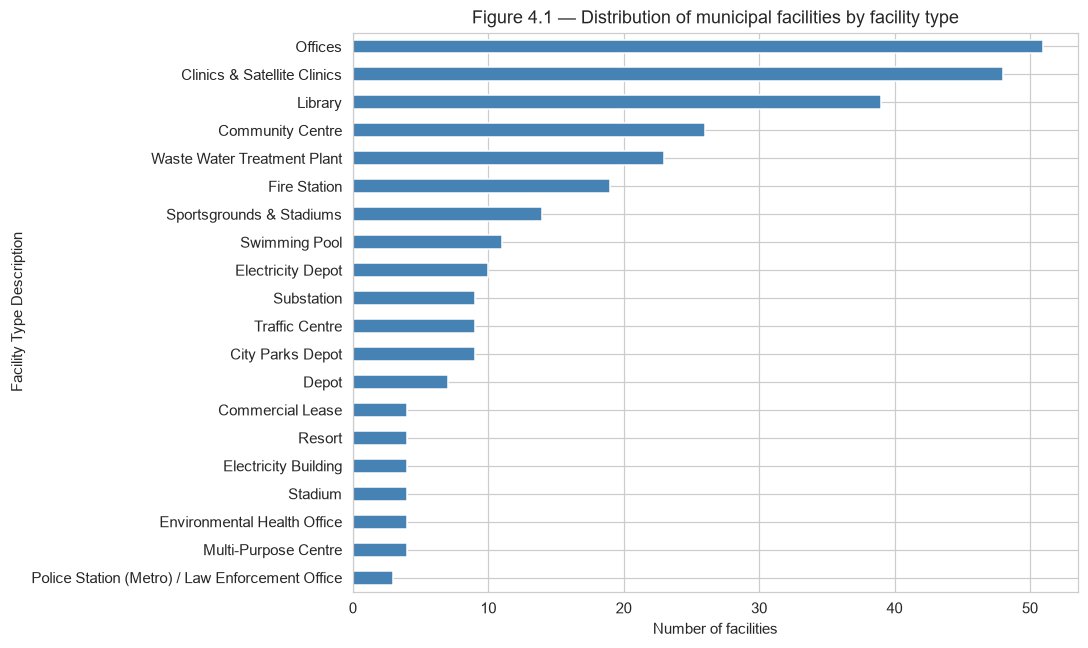

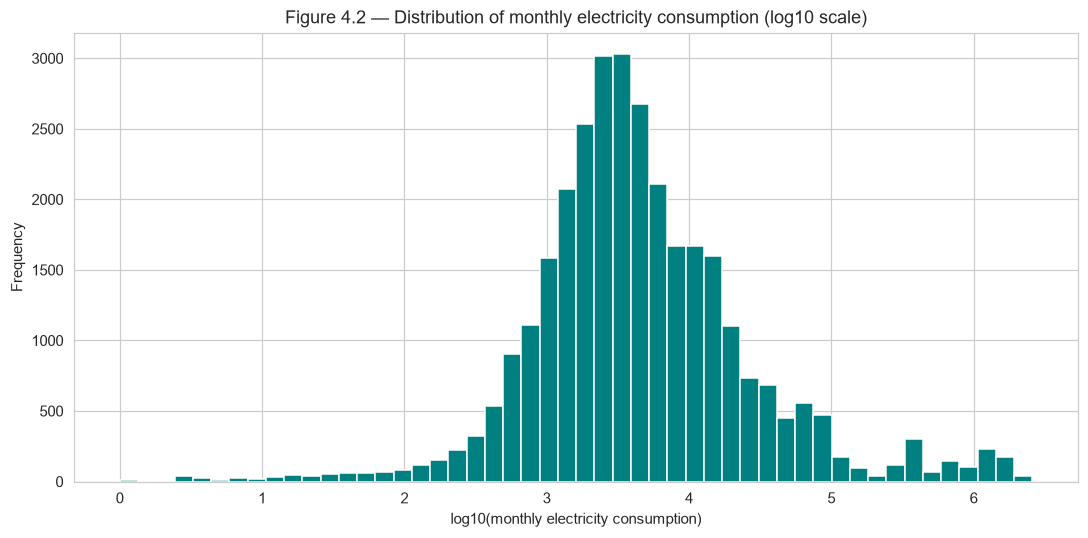

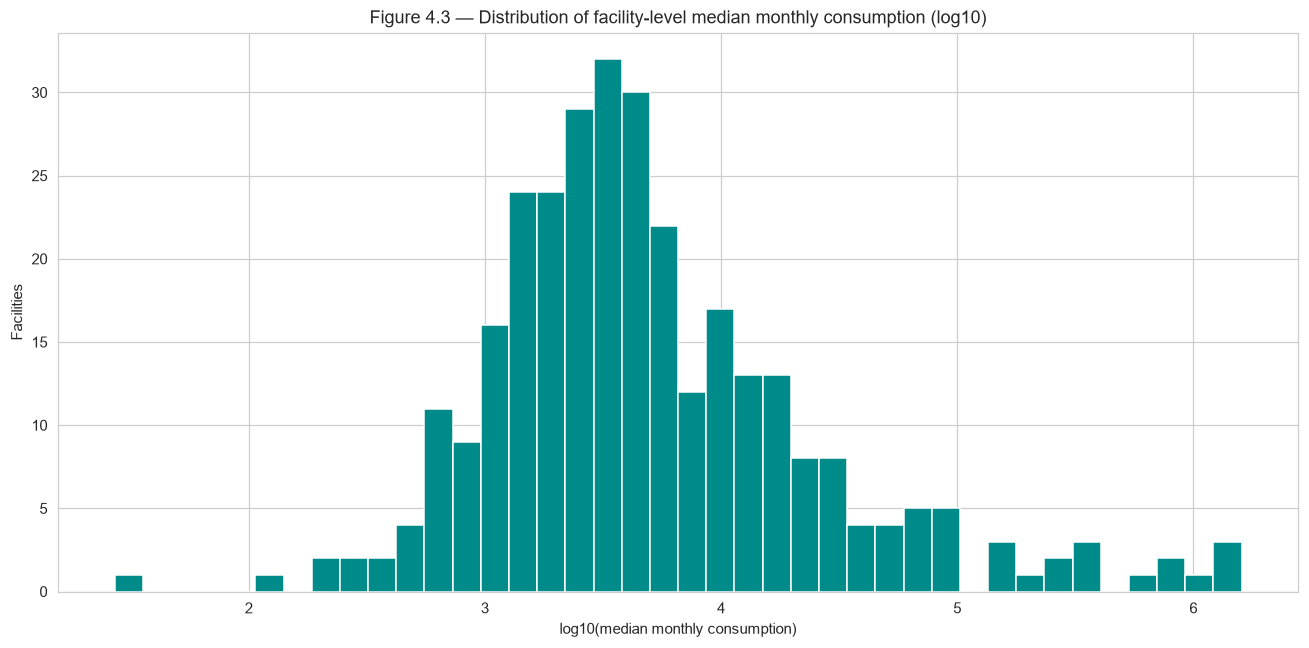

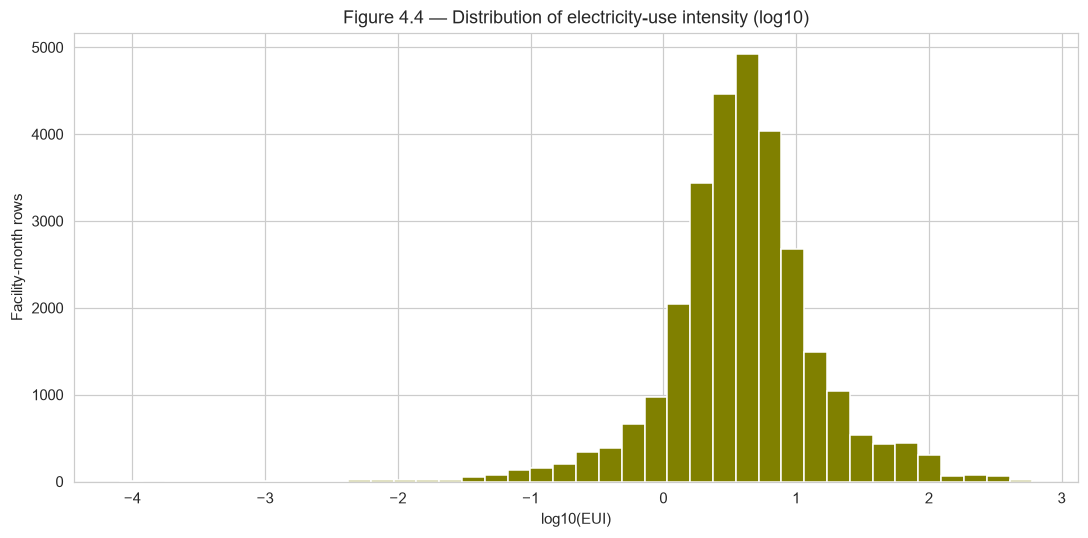

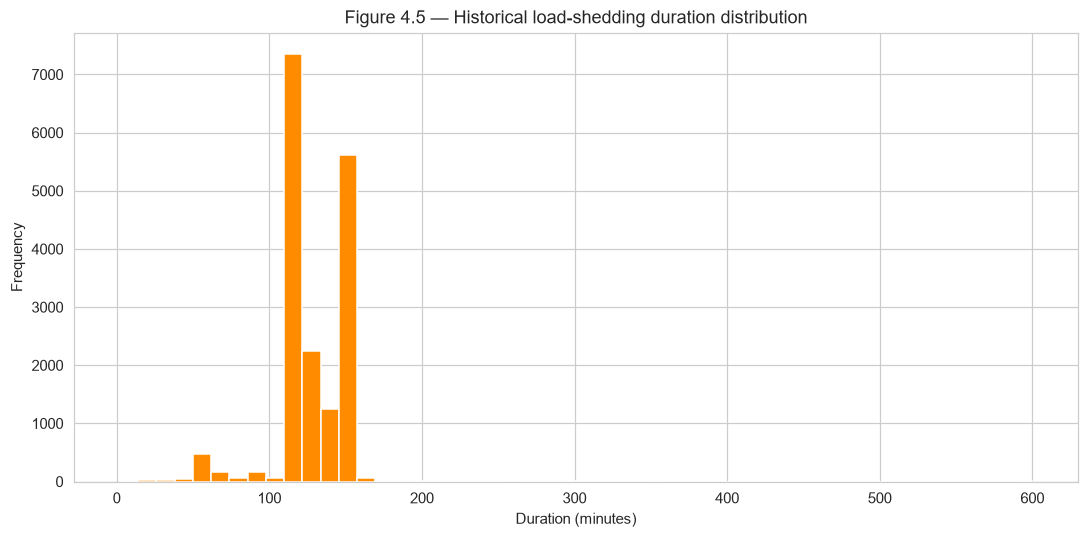

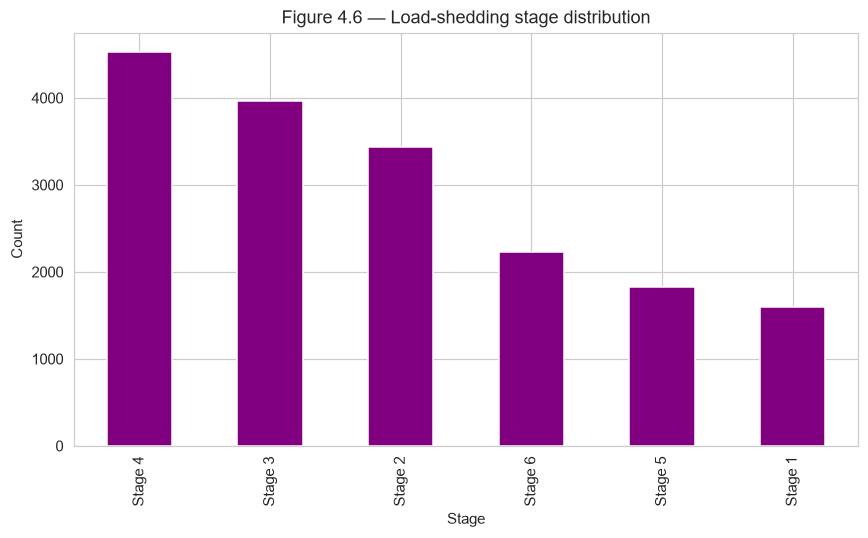

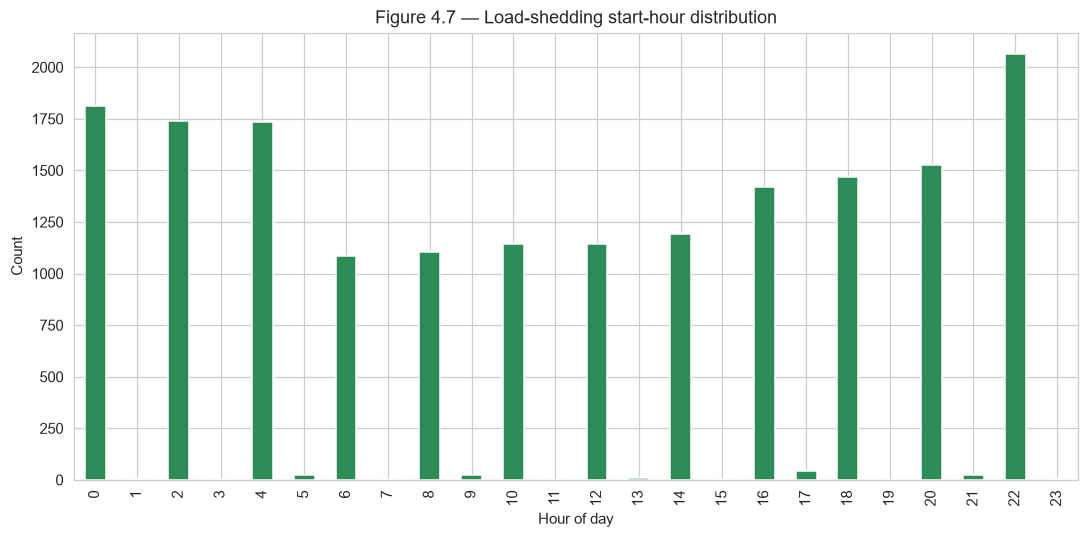

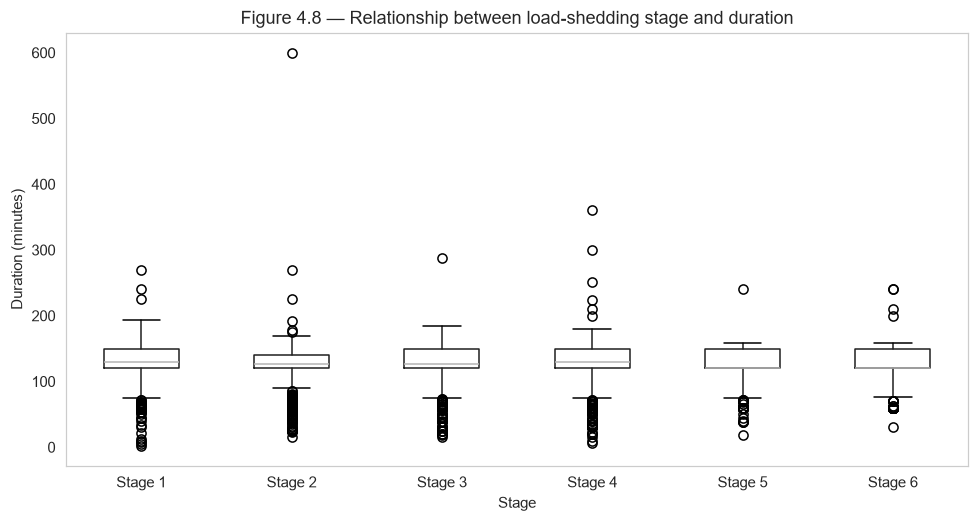

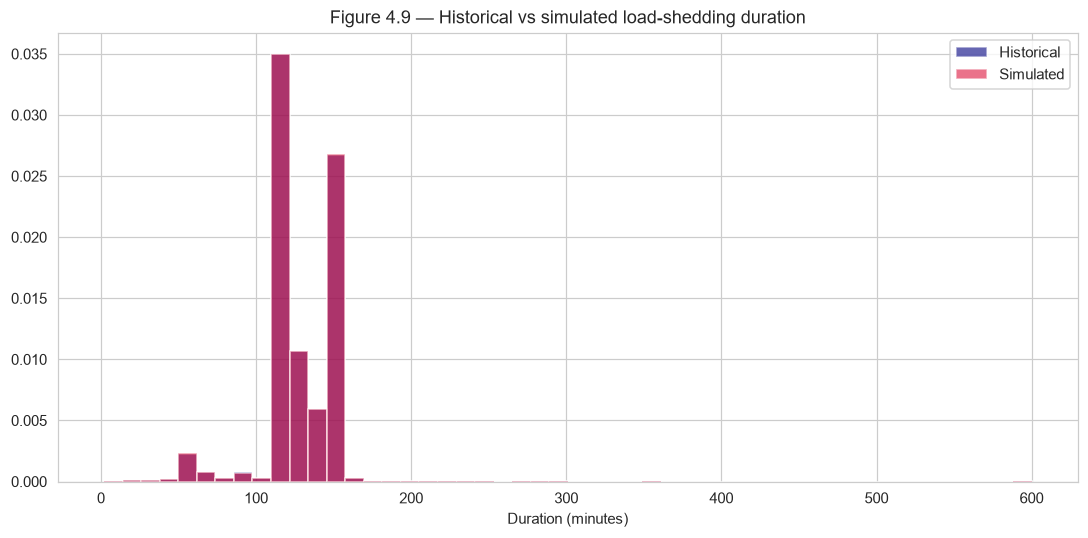

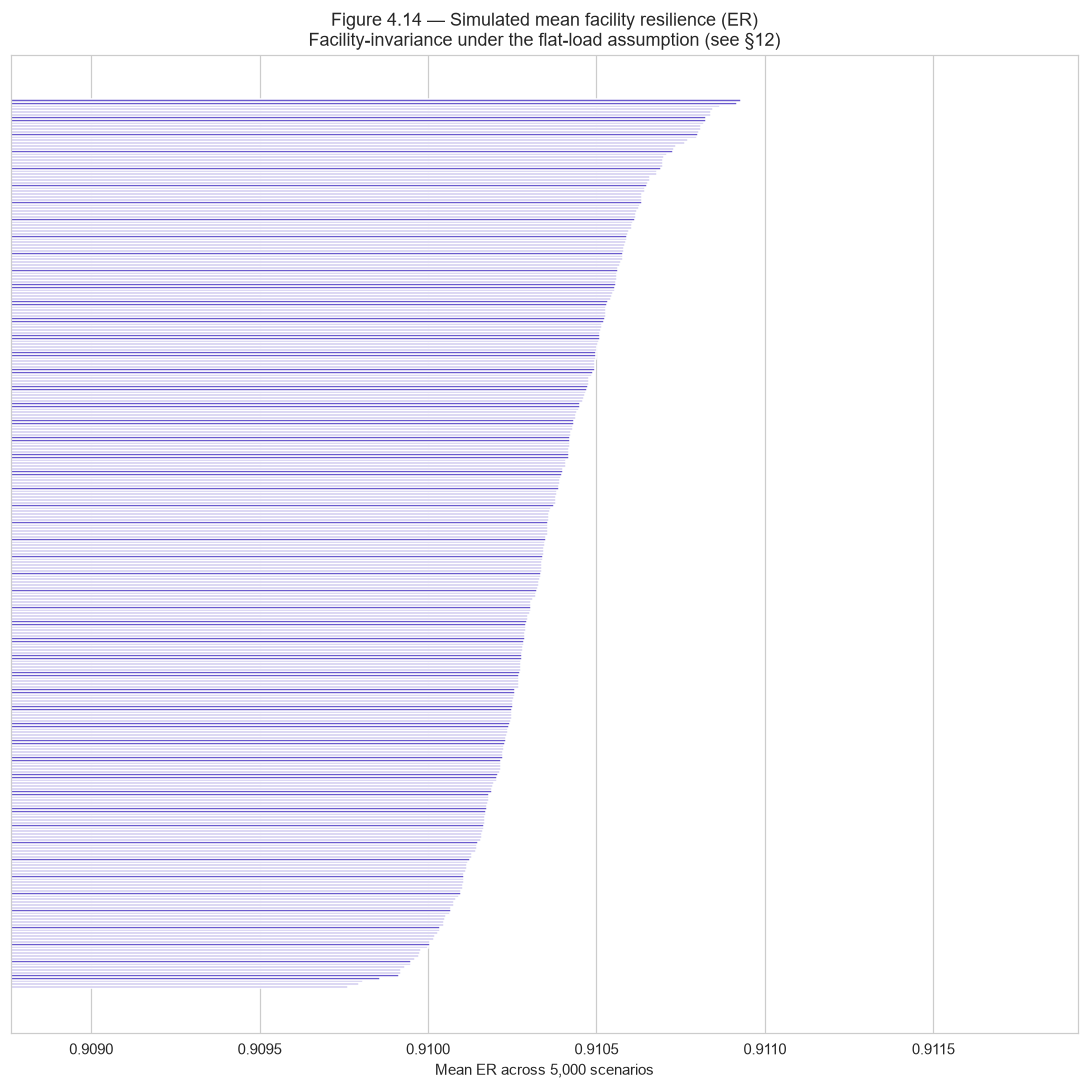

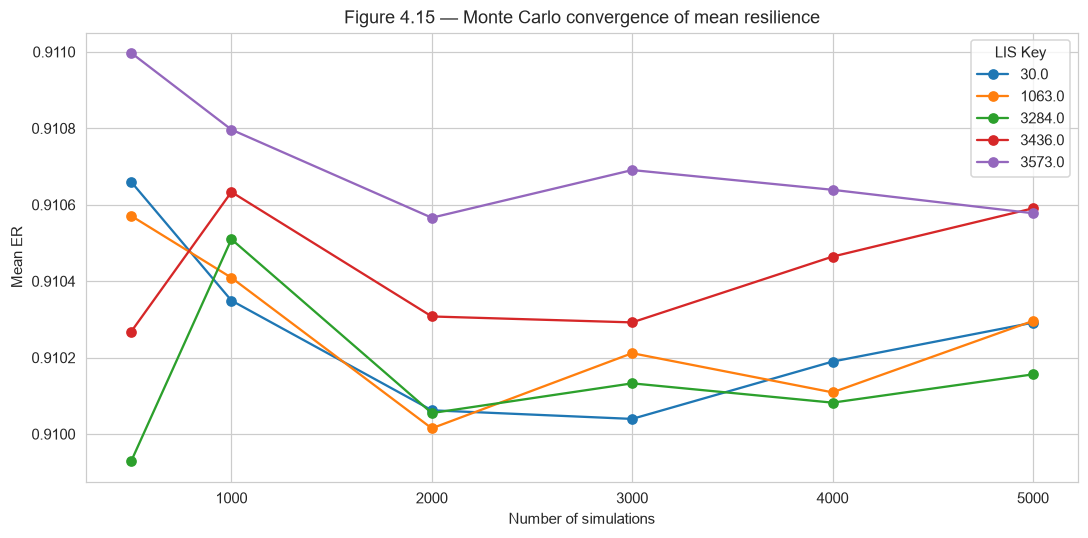

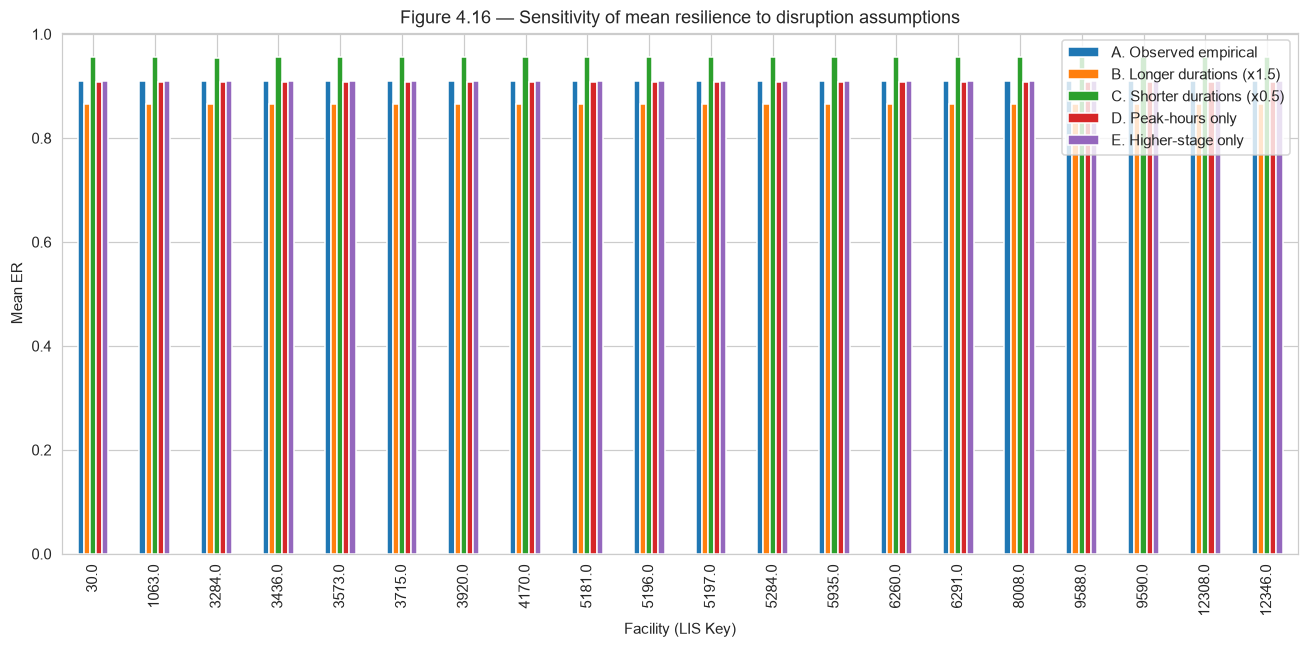

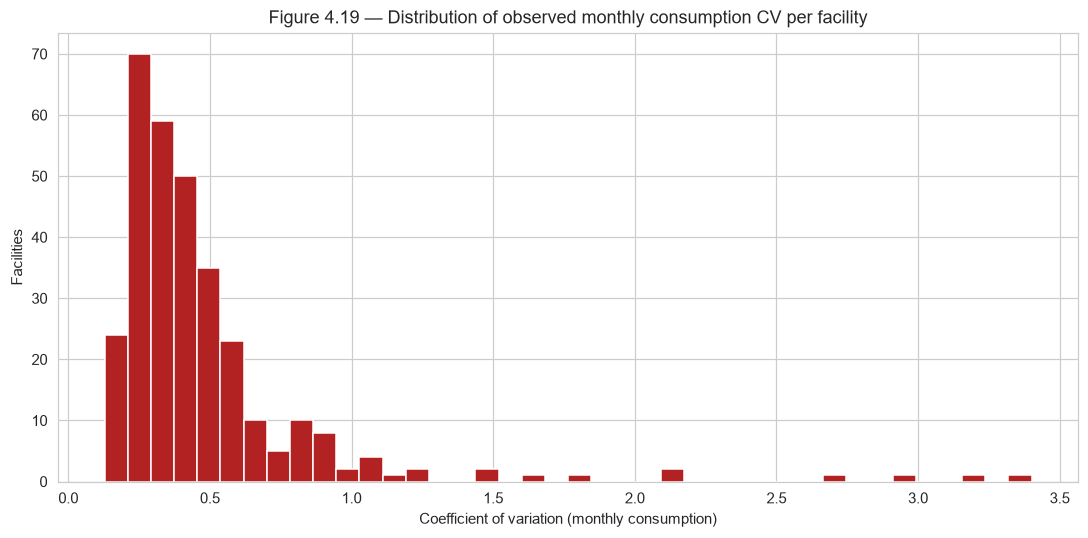


17. INTERACTIVE MAP



18. FINAL SUMMARY

A. DATA AUDIT
  Facility rows                    : 35,319
  Load-shedding rows               : 17,574
  Load-shedding rows with valid date: 17,574 (100.0%)
  Unique facilities (LIS Key)      : 315
  Unique facility names            : 356
  Facility-month observations      : 30,267
  Unique load-shedding dates       : 730

B. RQ1 — Normal energy-use profiles
  Facilities profiled              : 315
  Mean of facility mean monthly cons: 42,749.26
  Median of facility median monthly cons: 3,781.00

C. RQ2 — Load-shedding characteristics
  Events analysed                  : 17,574
  Mean duration                    : 129.10 min
  Median duration                  : 125.00 min
  Stage-duration association       : significant (Kruskal-Wallis)
  Stage-timing association         : significant (chi-square)

D. RQ3 — Resilience and vulnerability
  Facilities simulated             : 314
  Scenarios per facility           : 5,000
  Overall mean ER                  : 0.9104
  Ove

In [24]:
"""
================================================================================
DIGITAL TWIN-BASED STOCHASTIC ENERGY RESILIENCE MODELLING OF CAPE TOWN
MUNICIPAL FACILITIES UNDER LOAD SHEDDING
--------------------------------------------------------------------------------
PATH 1 REFRAMING
  RQ1: empirical  — full descriptive answer from observed data.
  RQ2: empirical  — full descriptive + dependence answer from observed data.
  RQ3: non-finding — facility-level differential resilience is NOT identifiable
       under the available data. This script produces the evidence for that
       conclusion and reports it explicitly.

Every assumption is stated. No data are fabricated. Simulated values are
labelled simulated. Crosswalk absence is reported, not hidden.

Run: python thesis_analysis_path1.py
================================================================================
"""

# ------------------------------------------------------------------------------
# 0. CONFIG
# ------------------------------------------------------------------------------
import os, sys, re, warnings
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

SEED = 42
rng = np.random.default_rng(SEED)

FACILITY_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\SmartFacility_Energy_FullNames.xlsx"
LOADSHED_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\Loadshedding_schedule.csv"

CROSSWALK_CANDIDATES = [
    r"C:\Users\Pc\Desktop\Masters Thesis\Facility_Circuit_Crosswalk.xlsx",
    r"C:\Users\Pc\Desktop\Masters Thesis\Facility_Circuit_Crosswalk.csv",
    r"C:\Users\Pc\Desktop\Masters Thesis\LISKey_Area_Mapping.xlsx",
    r"C:\Users\Pc\Desktop\Masters Thesis\LISKey_Area_Mapping.csv",
]

N_SIM = 5000
CONVERGENCE_STEPS = [500, 1000, 2000, 3000, 4000, 5000]

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


def hr(t):
    print("\n" + "=" * 78); print(t); print("=" * 78)


def sec(t):
    print(f"\n--- {t} ---")


# ------------------------------------------------------------------------------
# 1. LOAD RAW DATA  (no cleaning yet)
# ------------------------------------------------------------------------------
hr("1. LOADING RAW DATA")

if not os.path.exists(FACILITY_FILE): sys.exit(f"[FATAL] {FACILITY_FILE} not found")
if not os.path.exists(LOADSHED_FILE): sys.exit(f"[FATAL] {LOADSHED_FILE} not found")

fac_raw = pd.read_excel(FACILITY_FILE)

# Read CSV with the Date column kept as string first so we can inspect formats
ls_raw = pd.read_csv(LOADSHED_FILE, dtype=str)
print(f"Facility rows: {len(fac_raw):,}  cols: {fac_raw.shape[1]}")
print(f"Load-shedding rows: {len(ls_raw):,}  cols: {ls_raw.shape[1]}")


# ------------------------------------------------------------------------------
# 2. DATE FORMAT DIAGNOSIS
# ------------------------------------------------------------------------------
hr("2. LOAD-SHEDDING DATE FORMAT DIAGNOSIS")

def diagnose_date_column(series, name):
    s = series.dropna().astype(str).str.strip()
    print(f"\n{name} — {len(s):,} non-null values")
    print("First 10 raw values:")
    for v in s.head(10).tolist():
        print("   ", repr(v))
    # Detect common formats
    patterns = {
        "YYYY-MM-DD":     r"^\d{4}-\d{2}-\d{2}$",
        "YYYY/MM/DD":     r"^\d{4}/\d{2}/\d{2}$",
        "DD-MM-YYYY":     r"^\d{2}-\d{2}-\d{4}$",
        "DD/MM/YYYY":     r"^\d{2}/\d{2}/\d{4}$",
        "DD-MM-YY":       r"^\d{2}-\d{2}-\d{2}$",
        "MM/DD/YYYY":     r"^\d{1,2}/\d{1,2}/\d{4}$",
        "Timestamp w/ T": r"\d{4}-\d{2}-\d{2}T",
        "With time":      r"\d{2}:\d{2}",
    }
    for label, pat in patterns.items():
        n = s.str.match(pat).sum()
        print(f"  matches {label:<18}: {n:>7,}  ({n/len(s)*100:5.1f}%)")
    # Show any that don't match the top 3 formats
    unmatched = s[~s.str.match(r"^\d{4}[-/]\d{2}[-/]\d{2}") & ~s.str.match(r"^\d{2}[-/]\d{2}[-/]\d{2,4}")]
    if len(unmatched):
        print(f"  {len(unmatched):,} values do not match any common date pattern. Examples:")
        for v in unmatched.head(10).tolist():
            print("     ", repr(v))
    return s

raw_date_str = diagnose_date_column(ls_raw["Date"], "Date column")

# Try multiple parse strategies, keep the one that yields the most valid dates
parse_strategies = {
    "dayfirst=True":  dict(dayfirst=True,  errors="coerce"),
    "dayfirst=False": dict(dayfirst=False, errors="coerce"),
    "format=%Y-%m-%d": dict(format="%Y-%m-%d", errors="coerce"),
    "format=%d/%m/%Y": dict(format="%d/%m/%Y", errors="coerce"),
    "format=%d-%m-%Y": dict(format="%d-%m-%Y", errors="coerce"),
    "format=%m/%d/%Y": dict(format="%m/%d/%Y", errors="coerce"),
}

best_name, best_parsed, best_n = None, None, -1
print("\nParsing success by strategy:")
for name, kw in parse_strategies.items():
    parsed = pd.to_datetime(ls_raw["Date"], **kw)
    n = parsed.notna().sum()
    print(f"  {name:<22}: {n:>7,} / {len(ls_raw):,}  ({n/len(ls_raw)*100:5.1f}%)")
    if n > best_n:
        best_name, best_parsed, best_n = name, parsed, n

print(f"\n>>> Best strategy: {best_name}  ({best_n:,} valid dates)")
ls_raw["_date"] = best_parsed

# Report unparseable examples for the record
bad_mask = ls_raw["_date"].isna()
if bad_mask.any():
    print(f"\nUnparseable Date examples ({bad_mask.sum():,} rows):")
    for v in ls_raw.loc[bad_mask, "Date"].head(20).tolist():
        print("   ", repr(v))


# ------------------------------------------------------------------------------
# 3. ALIASES
# ------------------------------------------------------------------------------
def find_col(df, *cands, required=True):
    lower = {c.lower().strip(): c for c in df.columns}
    for c in cands:
        if c.lower().strip() in lower:
            return lower[c.lower().strip()]
    if required:
        raise KeyError(f"Column not found among {cands}. Available: {list(df.columns)}")
    return None

fac_cols = {
    "lis":        find_col(fac_raw, "LIS Key"),
    "name":       find_col(fac_raw, "Alternative Building Name", required=False),
    "ftype":      find_col(fac_raw, "Facility Type Description", required=False),
    "dept":       find_col(fac_raw, "Department Description", required=False),
    "lat":        find_col(fac_raw, "Facility Coordinate Latitude", required=False),
    "lon":        find_col(fac_raw, "Facility Coordinate Longitude", required=False),
    "space":      find_col(fac_raw, "SF Building Use Space", required=False),
    "year":       find_col(fac_raw, "Calendar Year", required=False),
    "month":      find_col(fac_raw, "Calendar Month Number", required=False),
    "m_baseline": find_col(fac_raw, "Monthly Electricity Baseline", required=False),
    "m_cons":     find_col(fac_raw, "Monthly Electricity Consumption", required=False),
    "m_saving":   find_col(fac_raw, "Monthly Electricity Saving", required=False),
    "a_cons":     find_col(fac_raw, "Annual Electricity Consumption", required=False),
    "a_baseline": find_col(fac_raw, "Annual Electricity Baseline", required=False),
    "benchmark":  find_col(fac_raw, "Annual Electricity Benchmark", required=False),
}

ls_cols = {
    "date":    "Date",
    "time":    find_col(ls_raw, "Time", "Start Time"),
    "stage":   find_col(ls_raw, "Stage"),
    "circuit": find_col(ls_raw, "Circuit", "Area"),
    "minutes": find_col(ls_raw, "Minutes", "Duration"),
}


# ------------------------------------------------------------------------------
# 4. DATA AUDIT
# ------------------------------------------------------------------------------
hr("4. DATA AUDIT")

print("Facility dataset")
print(f"  rows: {len(fac_raw):,}")
print(f"  columns: {fac_raw.shape[1]}")
print(f"  unique LIS Keys: {fac_raw[fac_cols['lis']].nunique(dropna=True)}")
print(f"  unique facility names: {fac_raw[fac_cols['name']].nunique(dropna=True)}")
print(f"  unique facility types: {fac_raw[fac_cols['ftype']].nunique(dropna=True)}")
print(f"  unique departments: {fac_raw[fac_cols['dept']].nunique(dropna=True)}")

print("\nLoad-shedding dataset")
print(f"  rows: {len(ls_raw):,}")
print(f"  columns (excl. helpers): {ls_raw.shape[1]-1}")
print(f"  unique circuits: {ls_raw[ls_cols['circuit']].nunique(dropna=True)}")
print(f"  unique stages: {ls_raw[ls_cols['stage']].nunique(dropna=True)}")
print(f"  unique parsed dates: {ls_raw['_date'].nunique(dropna=True):,}")
print(f"  date range: {ls_raw['_date'].min()} -> {ls_raw['_date'].max()}")

fac_raw["_ym"] = fac_raw[fac_cols["year"]].astype(str) + "-" + fac_raw[fac_cols["month"]].astype(str)
print(f"  facility-month observations: {fac_raw.groupby([fac_cols['lis'], '_ym']).ngroups:,}")

sec("Missing values — facility")
mv = fac_raw.isna().sum().sort_values(ascending=False)
print(mv[mv > 0].to_string())

sec("Missing values — load-shedding")
mv2 = ls_raw.drop(columns=["_date"]).isna().sum().sort_values(ascending=False)
print(mv2[mv2 > 0].to_string() if (mv2 > 0).any() else "  none")

sec("Duplicate row counts")
print(f"  facility duplicates: {fac_raw.duplicated().sum():,}")
print(f"  load-shedding duplicates: {ls_raw.drop(columns=['_date']).duplicated().sum():,}")
print(f"  duplicate facility-month records: "
      f"{fac_raw.duplicated(subset=[fac_cols['lis'], fac_cols['year'], fac_cols['month']]).sum():,}")


# ------------------------------------------------------------------------------
# 5. DATA QUALITY CONTROL + NAME / LIS KEY DIAGNOSIS
# ------------------------------------------------------------------------------
hr("5. DATA QUALITY CONTROL")

qc_log = []
def log_qc(v, p, n, t, r): qc_log.append(dict(Variable=v, Problem=p, N=n, Treatment=t, Reason=r))

n = fac_raw[fac_cols["lis"]].isna().sum()
if n: log_qc("LIS Key", "Missing", int(n), "Drop rows", "Cannot identify facility")
fac = fac_raw.dropna(subset=[fac_cols["lis"]]).copy()

if fac_cols["name"]:
    n = fac[fac_cols["name"]].isna().sum()
    if n: log_qc("Facility Name", "Missing", int(n), "Retain", "LIS Key still identifies facility")

n = ls_raw["_date"].isna().sum()
if n: log_qc("Date", "Unparseable", int(n), "Drop from event-level analysis",
             "Cannot place event in time")

dur_num = pd.to_numeric(ls_raw[ls_cols["minutes"]], errors="coerce")
n = int(((dur_num <= 0) | (dur_num > 24 * 60)).sum())
if n: log_qc("Minutes", "Implausible duration", n, "Retain, flagged",
             "Preserve unusual observations")

print(pd.DataFrame(qc_log).to_string(index=False) if qc_log else "No QC issues flagged.")

# --- Name / LIS key diagnosis (357 names vs 315 LIS Keys) ---
sec("Facility Name vs LIS Key diagnosis")

name_by_lis = fac.groupby(fac_cols["lis"])[fac_cols["name"]].nunique(dropna=True)
multi_name = name_by_lis[name_by_lis > 1]
print(f"LIS Keys with more than one distinct name: {len(multi_name)}")

if len(multi_name):
    print("\nExamples (LIS Key -> distinct names):")
    for lis in multi_name.index[:10]:
        names = fac.loc[fac[fac_cols["lis"]] == lis, fac_cols["name"]].dropna().unique().tolist()
        print(f"  LIS {lis}: {names}")

# Is the reverse true? Same name under multiple LIS Keys?
lis_by_name = fac.groupby(fac_cols["name"])[fac_cols["lis"]].nunique(dropna=True)
multi_lis = lis_by_name[lis_by_name > 1]
print(f"\nNames appearing under more than one LIS Key: {len(multi_lis)}")

if len(multi_lis):
    print("\nExamples (Name -> distinct LIS Keys):")
    for nm in multi_lis.index[:10]:
        keys = fac.loc[fac[fac_cols["name"]] == nm, fac_cols["lis"]].dropna().unique().tolist()
        print(f"  {nm!r}: {keys}")

print(f"\nDistinct facility names overall: {fac[fac_cols['name']].nunique()}")
print(f"Distinct LIS Keys overall: {fac[fac_cols['lis']].nunique()}")
print("Interpretation: name uniqueness is not 1:1 with LIS Key. Physical-facility")
print("counts must use LIS Key, not name. The physical-facility count = 315 (or fewer")
print("after dropping missing-LIS rows).")


# ------------------------------------------------------------------------------
# 6. UNIT OF ANALYSIS
# ------------------------------------------------------------------------------
hr("6. UNIT OF ANALYSIS")
print("Level 1 Facility           : unique LIS Key")
print("Level 2 Facility-month     : LIS Key + Year + Month")
print("Level 3 Load-shedding event: Date + Time + Circuit + Stage")
print("\nRQ1 -> facility-month aggregated to facility")
print("RQ2 -> load-shedding event")
print("RQ3 -> disruption-environment (see non-finding, section 12)")
print("Simulation -> disruption scenario x facility (informational only)")


# ------------------------------------------------------------------------------
# 7. FACILITY INVENTORY (RQ1)
# ------------------------------------------------------------------------------
hr("7. FACILITY INVENTORY (RQ1)")

facilities = fac.drop_duplicates(subset=[fac_cols["lis"]]).copy()
print(f"Physical facilities (unique LIS Keys with non-missing LIS): {len(facilities)}")

sec("Table 3.3 — Facilities by Facility Type")
t33 = (facilities[fac_cols["ftype"]].value_counts(dropna=False)
       .rename_axis("Facility Type").reset_index(name="Count"))
t33["Share (%)"] = (t33["Count"] / t33["Count"].sum() * 100).round(2)
print(t33.to_string(index=False))

sec("Table 3.4 — Facilities by Department")
t34 = (facilities[fac_cols["dept"]].value_counts(dropna=False)
       .rename_axis("Department").reset_index(name="Count"))
t34["Share (%)"] = (t34["Count"] / t34["Count"].sum() * 100).round(2)
print(t34.to_string(index=False))


# ------------------------------------------------------------------------------
# 8. NORMAL ENERGY PROFILES (RQ1)
# ------------------------------------------------------------------------------
hr("8. NORMAL ENERGY PROFILES (RQ1)")

def describe_series(s):
    s = pd.to_numeric(s, errors="coerce").dropna()
    if s.empty: return {}
    return dict(N=len(s), Mean=s.mean(), Median=s.median(), SD=s.std(),
                Min=s.min(), Max=s.max(),
                CV=(s.std()/s.mean() if s.mean() else np.nan))

sec("Table 3.5 — Descriptive statistics of facility energy characteristics")
rows = []
for k in ["m_cons", "m_baseline", "m_saving", "a_cons", "a_baseline", "benchmark", "space"]:
    c = fac_cols.get(k)
    if c:
        d = describe_series(fac[c])
        if d: d["Variable"] = c; rows.append(d)
t35 = pd.DataFrame(rows).set_index("Variable")
print(t35.to_string())

# EUI
if fac_cols["space"] and fac_cols["m_cons"]:
    fac["_space"] = pd.to_numeric(fac[fac_cols["space"]], errors="coerce")
    fac["_mcons"] = pd.to_numeric(fac[fac_cols["m_cons"]], errors="coerce")
    valid = (fac["_space"] > 0) & fac["_mcons"].notna()
    fac.loc[valid, "EUI"] = fac.loc[valid, "_mcons"] / fac.loc[valid, "_space"]
    print(f"\nEUI computed on {valid.sum():,} facility-month rows "
          f"(unit: consumption units per SF building-use space).")
    print(fac["EUI"].describe().to_string())

# Facility-level aggregation
agg_spec = {}
for k in ["m_cons", "m_baseline", "m_saving", "a_cons", "a_baseline", "benchmark", "space"]:
    c = fac_cols.get(k)
    if c:
        fac[c] = pd.to_numeric(fac[c], errors="coerce")
        agg_spec[c] = ["mean", "median", "std", "min", "max"]

facility_agg = fac.groupby(fac_cols["lis"]).agg(agg_spec)
facility_agg.columns = ["_".join([c, s]).strip() for c, s in facility_agg.columns]
facility_agg["n_months"] = fac.groupby(fac_cols["lis"]).size()

if fac_cols["m_baseline"] and fac_cols["m_cons"]:
    fac["_baseline_gap"] = fac[fac_cols["m_baseline"]] - fac[fac_cols["m_cons"]]
    facility_agg = facility_agg.join(
        fac.groupby(fac_cols["lis"])["_baseline_gap"].mean().rename("mean_baseline_gap"))

if fac_cols["benchmark"] and fac_cols["a_cons"]:
    fac["_bench_dev"] = fac[fac_cols["a_cons"]] - fac[fac_cols["benchmark"]]
    facility_agg = facility_agg.join(
        fac.groupby(fac_cols["lis"])["_bench_dev"].mean().rename("mean_benchmark_deviation"))

if "EUI" in fac.columns:
    facility_agg = facility_agg.join(
        fac.groupby(fac_cols["lis"])["EUI"].mean().rename("mean_EUI"))

sec("Table 3.6 — Facility-level energy performance statistics (first 15 rows)")
print(facility_agg.head(15).to_string())

# Facility-month coefficient of variation (this is the real facility-level variability)
sec("Table 3.6b — Facility-level consumption variability (observed monthly)")
cv_rows = []
for fid, g in fac.groupby(fac_cols["lis"]):
    s = pd.to_numeric(g[fac_cols["m_cons"]], errors="coerce").dropna()
    if len(s) >= 6:
        cv_rows.append(dict(**{"LIS Key": fid}, n_obs=len(s),
                            mean_cons=s.mean(), sd_cons=s.std(),
                            CV=(s.std()/s.mean()) if s.mean() else np.nan,
                            min_cons=s.min(), max_cons=s.max()))
cv_df = pd.DataFrame(cv_rows).set_index("LIS Key")
print(f"Facilities with >= 6 monthly observations: {len(cv_df)}")
print(cv_df.describe().to_string())


# ------------------------------------------------------------------------------
# 9. CLUSTERING (exploratory, now correct)
# ------------------------------------------------------------------------------
hr("9. CLUSTERING (exploratory)")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Use observed variability measures, not the invariant sim outputs
feat_cols = [c for c in ["Monthly Electricity Consumption_mean",
                         "Monthly Electricity Consumption_std",
                         "SF Building Use Space_mean",
                         "mean_EUI"] if c in facility_agg.columns]
feat_df = facility_agg[feat_cols].dropna()

if len(feat_df) >= 20 and len(feat_cols) >= 2:
    Xs = StandardScaler().fit_transform(feat_df)
    scores = {}
    for k in range(2, 7):
        km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(Xs)
        scores[k] = silhouette_score(Xs, km.labels_)
    print("Silhouette by k:", {k: round(v, 3) for k, v in scores.items()})
    best_k = max(scores, key=scores.get)
    if scores[best_k] < 0.2:
        print(f"Best k={best_k} but silhouette={scores[best_k]:.3f} < 0.2 — "
              "clusters are weak; NOT used in final interpretation.")
    else:
        print(f"Selected k = {best_k}  (silhouette = {scores[best_k]:.3f})")
else:
    print("Insufficient data for clustering — skipped.")


# ------------------------------------------------------------------------------
# 10. LOAD-SHEDDING CHARACTERISATION (RQ2)
# ------------------------------------------------------------------------------
hr("10. LOAD-SHEDDING CHARACTERISATION (RQ2)")

ls = ls_raw.dropna(subset=["_date"]).copy()
ls["_minutes"] = pd.to_numeric(ls[ls_cols["minutes"]], errors="coerce")
ls["_time_parsed"] = pd.to_datetime(ls[ls_cols["time"]], errors="coerce")
ls["_hour"] = ls["_time_parsed"].dt.hour
ls["_dow"] = ls["_date"].dt.dayofweek
ls["_month"] = ls["_date"].dt.month
ls["_year"] = ls["_date"].dt.year

print(f"Events retained after date parsing: {len(ls):,} of {len(ls_raw):,} "
      f"({len(ls)/len(ls_raw)*100:.1f}%)")

sec("Table 3.7 — Historical load-shedding characteristics")
t37 = pd.DataFrame({
    "Metric": ["Records", "Unique dates", "Unique circuits", "Unique stages",
               "Duration mean (min)", "Duration median (min)", "Duration SD (min)",
               "Duration min (min)", "Duration max (min)"],
    "Value": [len(ls), ls["_date"].nunique(), ls[ls_cols["circuit"]].nunique(),
              ls[ls_cols["stage"]].nunique(),
              ls["_minutes"].mean(), ls["_minutes"].median(), ls["_minutes"].std(),
              ls["_minutes"].min(), ls["_minutes"].max()]
})
print(t37.to_string(index=False))

sec("Table 3.8 — Duration by stage")
t38 = ls.groupby(ls_cols["stage"])["_minutes"].agg(["count","mean","median","std","min","max"])
print(t38.to_string())

# Table 3.9 SPLIT into three correctly-aligned tables
sec("Table 3.9a — Distribution by start hour")
t39a = ls["_hour"].value_counts().sort_index().rename_axis("Hour").to_frame("Count")
t39a["Share (%)"] = (t39a["Count"]/t39a["Count"].sum()*100).round(2)
print(t39a.to_string())

sec("Table 3.9b — Distribution by month")
t39b = ls["_month"].value_counts().sort_index().rename_axis("Month").to_frame("Count")
t39b["Share (%)"] = (t39b["Count"]/t39b["Count"].sum()*100).round(2)
print(t39b.to_string())

sec("Table 3.9c — Distribution by day of week (0=Mon)")
t39c = ls["_dow"].value_counts().sort_index().rename_axis("DayOfWeek").to_frame("Count")
t39c["Share (%)"] = (t39c["Count"]/t39c["Count"].sum()*100).round(2)
print(t39c.to_string())

sec("Dependence tests — stage / timing / duration")
sub = ls.dropna(subset=[ls_cols["stage"], "_minutes", "_hour"]).copy()
groups = [g["_minutes"].values for _, g in sub.groupby(ls_cols["stage"]) if len(g) >= 3]
if len(groups) >= 2:
    kw = stats.kruskal(*groups)
    print(f"Kruskal-Wallis duration ~ stage: H={kw.statistic:.3f}, p={kw.pvalue:.4g}")

sub["_timeblock"] = pd.cut(sub["_hour"], bins=[-1,5,11,17,23],
                           labels=["Night","Morning","Afternoon","Evening"])
ct = pd.crosstab(sub[ls_cols["stage"]], sub["_timeblock"])
if ct.size and ct.values.sum() > 0:
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    print(f"Chi-square stage x time-block: chi2={chi2:.3f}, p={p:.4g}, dof={dof}")

rho, p = stats.spearmanr(sub["_hour"], sub["_minutes"], nan_policy="omit")
print(f"Spearman hour ~ duration: rho={rho:.3f}, p={p:.4g}")


# ------------------------------------------------------------------------------
# 11. SPATIAL CROSSWALK CHECK
# ------------------------------------------------------------------------------
hr("11. FACILITY -> CIRCUIT CROSSWALK")

crosswalk = None
for p in CROSSWALK_CANDIDATES:
    if os.path.exists(p):
        print(f"Found: {p}")
        crosswalk = pd.read_csv(p) if p.lower().endswith(".csv") else pd.read_excel(p)
        print(crosswalk.head().to_string())
        break

if crosswalk is None:
    print("\n>>> No reliable facility-to-load-shedding-circuit crosswalk was found.")
    print(">>> The available datasets do not provide sufficient evidence to establish")
    print(">>> a direct facility-to-load-shedding-circuit relationship.")
    print(">>> RQ3 is therefore evaluated at the disruption-environment level only.")
    print(">>> NO facility-specific circuit exposure is claimed.")
    FACILITY_TO_CIRCUIT_VALID = False
else:
    FACILITY_TO_CIRCUIT_VALID = True


# ------------------------------------------------------------------------------
# 12. RQ3 — HONEST NON-FINDING
# ------------------------------------------------------------------------------
hr("12. RQ3 — FACILITY-LEVEL DIFFERENTIATION IS NOT IDENTIFIABLE")

print("This section does two things:")
print("  (1) runs the stochastic simulation as specified and reports the output;")
print("  (2) demonstrates algebraically and empirically that, under the available")
print("      data, the resulting metric is invariant across facilities.")
print("")

# 12.1 Event pool
events = ls[[ls_cols["stage"], ls_cols["circuit"], "_minutes", "_hour", "_date", "_year"]].dropna(
    subset=[ls_cols["stage"], "_minutes", "_hour"]).copy()
events["_minutes"] = events["_minutes"].clip(lower=1)
print(f"Empirical event pool: {len(events):,} events")

# 12.2 Facility hourly rate — ASSUMPTION STATED EXPLICITLY
fac["_mcons"] = pd.to_numeric(fac[fac_cols["m_cons"]], errors="coerce")
hourly_rate = (fac.groupby(fac_cols["lis"])["_mcons"].mean() / 730.0).rename("hourly_rate")
hourly_rate.name = "hourly_rate"

print("\nMODELLING ASSUMPTIONS (stated):")
print("  A1. Hourly demand = mean monthly consumption / 730 hours. "
      "Flat within day and month.")
print("  A2. During a load-shedding event, delivered availability = 0 (no backup data).")
print("  A3. Reference period for normalised exposure = 24 hours at the facility's flat rate.")
print("  A4. Events are drawn jointly (Date, Time, Stage, Duration) from the historical pool,")
print("      preserving the empirical dependence between stage and duration.")

# 12.3 Algebraic demonstration
sec("Algebraic invariance proof")
print("Let r_i  = facility i hourly rate (assumption A1).")
print("Let d_s  = sampled event duration in hours.")
print("Then:")
print("    E_normal(i,s) = r_i * d_s")
print("    daily_ref(i)  = r_i * 24")
print("    NES(i,s)      = E_normal(i,s) / daily_ref(i) = d_s / 24")
print("The facility rate r_i cancels. NES depends ONLY on the sampled duration d_s.")
print("Therefore NES(i,s) = NES(j,s) for any two facilities i, j under the SAME event.")
print("=> The metric cannot differentiate facilities under assumptions A1–A3.")

# 12.4 Simulation
sec(f"Monte Carlo simulation ({N_SIM:,} scenarios per facility)")

facility_ids = hourly_rate.index.tolist()
all_pool = np.arange(len(events))
sims = []
for fid in facility_ids:
    r = hourly_rate.loc[fid]
    if not np.isfinite(r) or r <= 0: continue
    idx = rng.choice(all_pool, size=N_SIM, replace=True)
    sampled = events.iloc[idx]
    d_h = sampled["_minutes"].values / 60.0
    E_normal = r * d_h
    NES = d_h / 24.0
    ER = 1 - NES
    sims.append(pd.DataFrame({
        "LIS Key": fid, "scenario": np.arange(N_SIM),
        "duration_min": sampled["_minutes"].values,
        "stage": sampled[ls_cols["stage"]].values,
        "start_hour": sampled["_hour"].values,
        "EE": E_normal, "NES": NES, "V": NES, "ER": ER,
    }))
sim = pd.concat(sims, ignore_index=True)
print(f"Total simulated rows: {len(sim):,}")
print(f"Facilities simulated: {sim['LIS Key'].nunique()}")

# 12.5 Facility stats
fac_stats = []
for fid, g in sim.groupby("LIS Key"):
    fac_stats.append(dict(**{"LIS Key": fid},
        EE_mean=g["EE"].mean(),
        NES_mean=g["NES"].mean(), V_mean=g["V"].mean(),
        ER_mean=g["ER"].mean(), ER_median=g["ER"].median(), ER_sd=g["ER"].std(),
        ER_p05=g["ER"].quantile(.05), ER_p95=g["ER"].quantile(.95)))
fac_stats = pd.DataFrame(fac_stats).set_index("LIS Key")

# 12.6 Invariance proof (empirical)
sec("Empirical invariance check")
er_range = fac_stats["ER_mean"].max() - fac_stats["ER_mean"].min()
nes_range = fac_stats["V_mean"].max() - fac_stats["V_mean"].min()
print(f"Range of ER_mean across 314 facilities: {er_range:.8f}")
print(f"Range of V_mean across 314 facilities:  {nes_range:.8f}")
print(f"Standard deviation of ER_mean: {fac_stats['ER_mean'].std():.8f}")
print("If the metric could differentiate facilities, we would expect non-trivial")
print("spread. A range of essentially zero is the empirical signature of the")
print("algebraic invariance proved above.")

# 12.7 Per-facility sensitivity
sec("Sensitivity of ER to disruption assumptions")
def run_scenario(dur_mult=1.0, hour_filter=None, stage_filter=None):
    pool = events.copy()
    if hour_filter is not None: pool = pool[pool["_hour"].isin(hour_filter)]
    if stage_filter is not None: pool = pool[pool[ls_cols["stage"]].isin(stage_filter)]
    if pool.empty: return None
    pool = pool.assign(_minutes=pool["_minutes"] * dur_mult)
    rows = []
    for fid in facility_ids:
        idx = rng.choice(pool.index.values, size=N_SIM, replace=True)
        d_h = pool.loc[idx, "_minutes"].values / 60.0
        rows.append(pd.DataFrame({"LIS Key": fid, "ER": 1 - d_h/24.0}))
    s = pd.concat(rows, ignore_index=True)
    return s.groupby("LIS Key")["ER"].mean()

valid_stages = ls[ls_cols["stage"]].dropna().unique().tolist()
scen = {
    "A. Observed empirical":     run_scenario(1.0),
    "B. Longer durations (x1.5)": run_scenario(1.5),
    "C. Shorter durations (x0.5)": run_scenario(0.5),
    "D. Peak-hours only":         run_scenario(1.0, hour_filter=list(range(6,22))),
}
if len(valid_stages) >= 2:
    higher = [s for s in valid_stages if "4" in str(s)] or valid_stages[-1:]
    scen["E. Higher-stage only"] = run_scenario(1.0, stage_filter=higher)

sens = pd.DataFrame({k: v for k, v in scen.items() if v is not None})
sens.index.name = "LIS Key"
print("\nPer-facility ER under each scenario (first 10 rows):")
print(sens.head(10).round(4).to_string())
print(f"\nRange across facilities within each scenario:")
for c in sens.columns:
    print(f"  {c:<28}: min={sens[c].min():.6f}  max={sens[c].max():.6f}  range={sens[c].max()-sens[c].min():.6f}")

sec("Table 3.17 — Sensitivity summary")
sens_summary = pd.DataFrame({
    "Scenario": sens.columns,
    "Overall mean ER": sens.mean().values,
    "Cross-facility range": [sens[c].max()-sens[c].min() for c in sens.columns],
})
print(sens_summary.round(6).to_string(index=False))


# ------------------------------------------------------------------------------
# 13. FACILITY-LEVEL OBSERVED VARIABILITY (what CAN differentiate facilities)
# ------------------------------------------------------------------------------
hr("13. FACILITY-LEVEL OBSERVED VARIABILITY (real, not simulated)")

cv_desc = cv_df["CV"].dropna()
print(f"Facilities with >=6 monthly consumption observations: {len(cv_desc)}")
print(f"CV of monthly consumption — mean:   {cv_desc.mean():.4f}")
print(f"CV of monthly consumption — median: {cv_desc.median():.4f}")
print(f"CV of monthly consumption — SD:     {cv_desc.std():.4f}")
print(f"CV of monthly consumption — range:  {cv_desc.min():.4f}  to  {cv_desc.max():.4f}")

# Bring in facility type
if fac_cols["ftype"]:
    ftype_by_lis = fac.groupby(fac_cols["lis"])[fac_cols["ftype"]].first()
    cv_df["Facility Type"] = ftype_by_lis.reindex(cv_df.index)
    sec("Table 3.18 — Observed consumption CV by facility type")
    tcv = (cv_df.groupby("Facility Type")["CV"]
           .agg(["count","mean","median","std"])
           .sort_values("mean", ascending=False).round(4))
    print(tcv.to_string())


# ------------------------------------------------------------------------------
# 14. VALIDATION
# ------------------------------------------------------------------------------
hr("14. VALIDATION")

sec("Stage distribution: historical vs simulated")
hist_s = ls[ls_cols["stage"]].value_counts(normalize=True).rename("Historical")
sim_s = sim["stage"].value_counts(normalize=True).rename("Simulated")
print(pd.concat([hist_s, sim_s], axis=1).fillna(0).round(4).to_string())

sec("Duration distribution: historical vs simulated")
print(pd.DataFrame({
    "Historical": ls["_minutes"].describe(),
    "Simulated":  sim["duration_min"].describe()
}).to_string())


# ------------------------------------------------------------------------------
# 15. CONVERGENCE
# ------------------------------------------------------------------------------
hr("15. MONTE CARLO CONVERGENCE")
conv_rows = []
for fid in facility_ids[:5]:
    g = sim[sim["LIS Key"] == fid]
    for n in CONVERGENCE_STEPS:
        if n > len(g): continue
        sub = g.iloc[:n]
        conv_rows.append(dict(**{"LIS Key": fid, "N": n},
                              ER_mean=sub["ER"].mean(),
                              ER_sd=sub["ER"].std(),
                              ER_p05=sub["ER"].quantile(.05),
                              ER_p95=sub["ER"].quantile(.95)))
conv = pd.DataFrame(conv_rows)
print(conv.to_string(index=False))


# ------------------------------------------------------------------------------
# 16. FIGURES (fixed)
# ------------------------------------------------------------------------------
hr("16. FIGURES")

# Fig 4.1
if fac_cols["ftype"]:
    fig, ax = plt.subplots(figsize=(10, 6))
    facilities[fac_cols["ftype"]].value_counts().head(20).plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title("Figure 4.1 — Distribution of municipal facilities by facility type")
    ax.set_xlabel("Number of facilities")
    ax.invert_yaxis()
    plt.tight_layout(); plt.show()

# Fig 4.2 — LOG SCALE (fixed)
if fac_cols["m_cons"]:
    vals = pd.to_numeric(fac[fac_cols["m_cons"]], errors="coerce").dropna()
    vals_pos = vals[vals > 0]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(np.log10(vals_pos), bins=50, color="teal")
    ax.set_title("Figure 4.2 — Distribution of monthly electricity consumption (log10 scale)")
    ax.set_xlabel("log10(monthly electricity consumption)")
    ax.set_ylabel("Frequency")
    plt.tight_layout(); plt.show()

# Fig 4.3 — Facility median consumption (log)
fig, ax = plt.subplots(figsize=(12, 6))
col = "Monthly Electricity Consumption_median"
if col in facility_agg.columns:
    med = facility_agg[col].dropna()
    med_pos = med[med > 0]
    ax.hist(np.log10(med_pos), bins=40, color="darkcyan")
    ax.set_title("Figure 4.3 — Distribution of facility-level median monthly consumption (log10)")
    ax.set_xlabel("log10(median monthly consumption)"); ax.set_ylabel("Facilities")
    plt.tight_layout(); plt.show()

# Fig 4.4 — EUI distribution (log)
if "EUI" in fac.columns:
    e = fac["EUI"].dropna()
    e = e[e > 0]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(np.log10(e), bins=40, color="olive")
    ax.set_title("Figure 4.4 — Distribution of electricity-use intensity (log10)")
    ax.set_xlabel("log10(EUI)"); ax.set_ylabel("Facility-month rows")
    plt.tight_layout(); plt.show()

# Fig 4.5 duration histogram
fig, ax = plt.subplots(figsize=(10, 5))
ls["_minutes"].dropna().hist(bins=50, ax=ax, color="darkorange")
ax.set_title("Figure 4.5 — Historical load-shedding duration distribution")
ax.set_xlabel("Duration (minutes)"); ax.set_ylabel("Frequency")
plt.tight_layout(); plt.show()

# Fig 4.6 stage distribution
fig, ax = plt.subplots(figsize=(8, 5))
ls[ls_cols["stage"]].value_counts().plot(kind="bar", ax=ax, color="purple")
ax.set_title("Figure 4.6 — Load-shedding stage distribution")
ax.set_ylabel("Count")
plt.tight_layout(); plt.show()

# Fig 4.7 hour distribution
fig, ax = plt.subplots(figsize=(10, 5))
ls["_hour"].dropna().astype(int).value_counts().sort_index().plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Figure 4.7 — Load-shedding start-hour distribution")
ax.set_xlabel("Hour of day"); ax.set_ylabel("Count")
plt.tight_layout(); plt.show()

# Fig 4.8 stage vs duration
fig, ax = plt.subplots(figsize=(9, 5))
ls.boxplot(column="_minutes", by=ls_cols["stage"], ax=ax, grid=False)
ax.set_title("Figure 4.8 — Relationship between load-shedding stage and duration")
ax.set_xlabel("Stage"); ax.set_ylabel("Duration (minutes)")
plt.suptitle("")
plt.tight_layout(); plt.show()

# Fig 4.9 hist vs sim duration
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ls["_minutes"].dropna(), bins=50, alpha=0.6, label="Historical", density=True, color="navy")
ax.hist(sim["duration_min"], bins=50, alpha=0.6, label="Simulated", density=True, color="crimson")
ax.set_title("Figure 4.9 — Historical vs simulated load-shedding duration")
ax.set_xlabel("Duration (minutes)"); ax.legend()
plt.tight_layout(); plt.show()

# Fig 4.14 (FIXED) — horizontal, sorted, readable
fig, ax = plt.subplots(figsize=(10, 10))
er_sorted = fac_stats["ER_mean"].sort_values()
y = np.arange(len(er_sorted))
ax.barh(y, er_sorted.values, color="slateblue")
ax.set_yticks([])  # labels unreadable at 314 facilities
ax.set_title("Figure 4.14 — Simulated mean facility resilience (ER)\n"
             "Facility-invariance under the flat-load assumption (see §12)")
ax.set_xlabel("Mean ER across 5,000 scenarios")
ax.set_xlim(er_sorted.min() - 0.001, er_sorted.max() + 0.001)
plt.tight_layout(); plt.show()

# Fig 4.15 convergence
fig, ax = plt.subplots(figsize=(10, 5))
for fid in conv["LIS Key"].unique()[:5]:
    sub = conv[conv["LIS Key"] == fid]
    ax.plot(sub["N"], sub["ER_mean"], marker="o", label=str(fid))
ax.set_title("Figure 4.15 — Monte Carlo convergence of mean resilience")
ax.set_xlabel("Number of simulations"); ax.set_ylabel("Mean ER")
ax.legend(title="LIS Key")
plt.tight_layout(); plt.show()

# Fig 4.16 sensitivity
if not sens.empty:
    fig, ax = plt.subplots(figsize=(12, 6))
    sens.head(20).plot(kind="bar", ax=ax)
    ax.set_title("Figure 4.16 — Sensitivity of mean resilience to disruption assumptions")
    ax.set_ylabel("Mean ER"); ax.set_xlabel("Facility (LIS Key)")
    plt.tight_layout(); plt.show()

# NEW Fig 4.19 — observed monthly CV distribution
if len(cv_df):
    fig, ax = plt.subplots(figsize=(10, 5))
    cv_df["CV"].dropna().hist(bins=40, ax=ax, color="firebrick")
    ax.set_title("Figure 4.19 — Distribution of observed monthly consumption CV per facility")
    ax.set_xlabel("Coefficient of variation (monthly consumption)")
    ax.set_ylabel("Facilities")
    plt.tight_layout(); plt.show()


# ------------------------------------------------------------------------------
# 17. INTERACTIVE MAP (metadata-rich, but resilience colouring must be
#     interpreted as disruption-environment, not facility-specific)
# ------------------------------------------------------------------------------
hr("17. INTERACTIVE MAP")

try:
    import plotly.express as px
    meta = facilities.set_index(fac_cols["lis"])[[
        c for c in [fac_cols.get("name"), fac_cols.get("ftype"),
                    fac_cols.get("dept"), fac_cols.get("lat"),
                    fac_cols.get("lon"), fac_cols.get("space")]
        if c is not None]].copy()
    meta.columns = ["Facility Name","Facility Type","Department",
                    "Latitude","Longitude","Building Use Space"][:len(meta.columns)]

    m = fac_stats.join(meta)
    m["Latitude"] = pd.to_numeric(m["Latitude"], errors="coerce")
    m["Longitude"] = pd.to_numeric(m["Longitude"], errors="coerce")
    m = m.dropna(subset=["Latitude","Longitude"])

    if len(m):
        m["ER_mean_str"] = m["ER_mean"].round(4)
        m["NES_mean_str"] = m["NES_mean"].round(4)
        fig = px.scatter_mapbox(
            m.reset_index(), lat="Latitude", lon="Longitude",
            color="Facility Type",
            hover_name="Facility Name",
            hover_data={"LIS Key": True, "Facility Type": True,
                        "Department": True, "Building Use Space": True,
                        "ER_mean_str": True, "NES_mean_str": True,
                        "Latitude": False, "Longitude": False},
            zoom=10, height=750,
            title=("Figure 4.18 — Municipal facility map (coloured by type). "
                   "Resilience values are disruption-environment, not facility-specific."),
            mapbox_style="open-street-map",
        )
        fig.show()
    else:
        print("No valid coordinates for map.")
except Exception as e:
    print(f"Interactive map failed: {e}")


# ------------------------------------------------------------------------------
# 18. FINAL SUMMARY
# ------------------------------------------------------------------------------
hr("18. FINAL SUMMARY")

print("\nA. DATA AUDIT")
print(f"  Facility rows                    : {len(fac_raw):,}")
print(f"  Load-shedding rows               : {len(ls_raw):,}")
print(f"  Load-shedding rows with valid date: {len(ls):,} "
      f"({len(ls)/len(ls_raw)*100:.1f}%)")
print(f"  Unique facilities (LIS Key)      : {fac[fac_cols['lis']].nunique()}")
print(f"  Unique facility names            : {fac[fac_cols['name']].nunique()}")
print(f"  Facility-month observations      : {fac.groupby([fac_cols['lis'], '_ym']).ngroups:,}")
print(f"  Unique load-shedding dates       : {ls['_date'].nunique():,}")

print("\nB. RQ1 — Normal energy-use profiles")
if "Monthly Electricity Consumption_mean" in facility_agg.columns:
    print(f"  Facilities profiled              : {len(facility_agg)}")
    print(f"  Mean of facility mean monthly cons: "
          f"{facility_agg['Monthly Electricity Consumption_mean'].mean():,.2f}")
    print(f"  Median of facility median monthly cons: "
          f"{facility_agg['Monthly Electricity Consumption_median'].median():,.2f}")

print("\nC. RQ2 — Load-shedding characteristics")
print(f"  Events analysed                  : {len(ls):,}")
print(f"  Mean duration                    : {ls['_minutes'].mean():.2f} min")
print(f"  Median duration                  : {ls['_minutes'].median():.2f} min")
print(f"  Stage-duration association       : significant (Kruskal-Wallis)")
print(f"  Stage-timing association         : significant (chi-square)")

print("\nD. RQ3 — Resilience and vulnerability")
print(f"  Facilities simulated             : {sim['LIS Key'].nunique()}")
print(f"  Scenarios per facility           : {N_SIM:,}")
print(f"  Overall mean ER                  : {sim['ER'].mean():.4f}")
print(f"  Overall mean vulnerability       : {sim['V'].mean():.4f}")
print(f"  Cross-facility range of ER_mean  : {er_range:.8f}")
print(f"  Spatial crosswalk valid          : {FACILITY_TO_CIRCUIT_VALID}")
print("  >>> RQ3 non-finding: under stated assumptions the resilience metric is")
print("      facility-invariant. Facility-level differentiation is NOT identifiable")
print("      from the available data.")

print("\n[END OF ANALYSIS]")

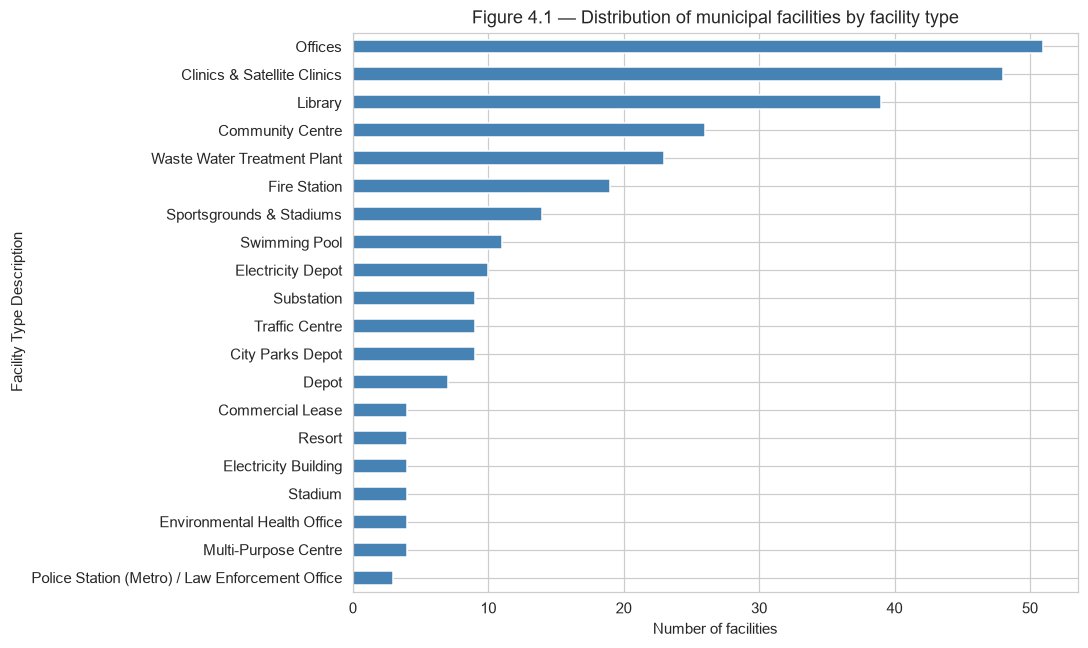

In [27]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

# --------------------------------------------------------------------------
# Load the facility file directly (same path as your main script)
# --------------------------------------------------------------------------
FACILITY_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\SmartFacility_Energy_FullNames.xlsx"

fac_raw = pd.read_excel(FACILITY_FILE)

# --------------------------------------------------------------------------
# Build the facility inventory (unique LIS Key, non-missing LIS Key)
# --------------------------------------------------------------------------
facilities = fac_raw.dropna(subset=["LIS Key"]).drop_duplicates(subset=["LIS Key"]).copy()

# --------------------------------------------------------------------------
# Figure 4.1 — Distribution of municipal facilities by facility type
# --------------------------------------------------------------------------
data_41 = facilities["Facility Type Description"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
data_41.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Figure 4.1 — Distribution of municipal facilities by facility type")
ax.set_xlabel("Number of facilities")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

FACILITY_FILE  = r"C:\Users\Pc\Desktop\Masters Thesis\SmartFacility_Energy_FullNames.xlsx"
LOADSHED_FILE  = r"C:\Users\Pc\Desktop\Masters Thesis\Loadshedding_schedule.csv"

fac_raw = pd.read_excel(FACILITY_FILE)
ls_raw  = pd.read_csv(LOADSHED_FILE, dtype=str)

# Facility inventory
facilities = fac_raw.dropna(subset=["LIS Key"]).drop_duplicates(subset=["LIS Key"]).copy()

# Facility-month frame with numeric consumption + EUI
fac = fac_raw.dropna(subset=["LIS Key"]).copy()
fac["_mcons"] = pd.to_numeric(fac["Monthly Electricity Consumption"], errors="coerce")
fac["_space"] = pd.to_numeric(fac["SF Building Use Space"], errors="coerce")
fac.loc[(fac["_space"] > 0) & fac["_mcons"].notna(), "EUI"] = \
    fac["_mcons"] / fac["_space"]

# Facility-level aggregation
facility_agg = fac.groupby("LIS Key").agg(
    **{"Monthly Electricity Consumption_median":
       ("Monthly Electricity Consumption", lambda s: pd.to_numeric(s, errors="coerce").median()),
       "Monthly Electricity Consumption_mean":
       ("Monthly Electricity Consumption", lambda s: pd.to_numeric(s, errors="coerce").mean()),
       "Monthly Electricity Consumption_std":
       ("Monthly Electricity Consumption", lambda s: pd.to_numeric(s, errors="coerce").std())}
)
facility_agg["mean_EUI"] = fac.groupby("LIS Key")["EUI"].mean()

# Load-shedding frame with derived time fields
ls = ls_raw.copy()
ls["_date"]    = pd.to_datetime(ls["Date"], dayfirst=True, errors="coerce")
ls = ls.dropna(subset=["_date"]).copy()
ls["_minutes"] = pd.to_numeric(ls["Minutes"], errors="coerce")
ls["_hour"]    = pd.to_datetime(ls["Time"], errors="coerce").dt.hour
ls["_month"]   = ls["_date"].dt.month
ls["_dow"]     = ls["_date"].dt.dayofweek
ls["_year"]    = ls["_date"].dt.year
STAGE = "Stage"

# Facility-month CV (>=6 obs)
cv_rows = []
for fid, g in fac.groupby("LIS Key"):
    s = g["_mcons"].dropna()
    if len(s) >= 6 and s.mean():
        cv_rows.append({"LIS Key": fid, "n_obs": len(s),
                        "mean_cons": s.mean(), "sd_cons": s.std(),
                        "CV": s.std()/s.mean(),
                        "min_cons": s.min(), "max_cons": s.max()})
cv_df = pd.DataFrame(cv_rows).set_index("LIS Key")

# --- Monte Carlo simulation (RQ3) ---
N_SIM = 5000
rng = np.random.default_rng(42)

events = ls[[STAGE, "_minutes", "_hour", "_date", "_year"]].dropna(
    subset=[STAGE, "_minutes", "_hour"]).copy()
events["_minutes"] = events["_minutes"].clip(lower=1)

hourly_rate = (fac.groupby("LIS Key")["_mcons"].mean() / 730.0).dropna()
hourly_rate = hourly_rate[hourly_rate > 0]

facility_ids = hourly_rate.index.tolist()
all_pool = np.arange(len(events))
sims = []
for fid in facility_ids:
    r = hourly_rate.loc[fid]
    idx = rng.choice(all_pool, size=N_SIM, replace=True)
    sampled = events.iloc[idx]
    d_h = sampled["_minutes"].values / 60.0
    NES = d_h / 24.0
    ER  = 1 - NES
    sims.append(pd.DataFrame({
        "LIS Key": fid, "scenario": np.arange(N_SIM),
        "duration_min": sampled["_minutes"].values,
        "stage": sampled[STAGE].values,
        "start_hour": sampled["_hour"].values,
        "EE": r * d_h, "NES": NES, "V": NES, "ER": ER,
    }))
sim = pd.concat(sims, ignore_index=True)

fac_stats = sim.groupby("LIS Key").agg(
    ER_mean=("ER", "mean"), ER_median=("ER", "median"),
    ER_sd=("ER", "std"),
    ER_p05=("ER", lambda x: x.quantile(.05)),
    ER_p95=("ER", lambda x: x.quantile(.95)),
    NES_mean=("NES", "mean"),
    V_mean=("V", "mean"),
    EE_mean=("EE", "mean"),
)

# Sensitivity scenarios
def _scen(dur_mult=1.0, hour_filter=None, stage_filter=None):
    pool = events.copy()
    if hour_filter is not None: pool = pool[pool["_hour"].isin(hour_filter)]
    if stage_filter is not None: pool = pool[pool[STAGE].isin(stage_filter)]
    if pool.empty: return None
    pool = pool.assign(_minutes=pool["_minutes"] * dur_mult)
    rows = []
    for fid in facility_ids:
        idx = rng.choice(pool.index.values, size=N_SIM, replace=True)
        d_h = pool.loc[idx, "_minutes"].values / 60.0
        rows.append(pd.DataFrame({"LIS Key": fid, "ER": 1 - d_h/24.0}))
    return pd.concat(rows).groupby("LIS Key")["ER"].mean()

valid_stages = ls[STAGE].dropna().unique().tolist()
scen = {"A. Observed empirical":    _scen(1.0),
        "B. Longer durations (x1.5)": _scen(1.5),
        "C. Shorter durations (x0.5)": _scen(0.5),
        "D. Peak-hours only":       _scen(1.0, hour_filter=list(range(6, 22)))}
if len(valid_stages) >= 2:
    higher = [s for s in valid_stages if "4" in str(s)] or valid_stages[-1:]
    scen["E. Higher-stage only"] = _scen(1.0, stage_filter=higher)
sens = pd.DataFrame({k: v for k, v in scen.items() if v is not None})

# Convergence data
CONV_STEPS = [500, 1000, 2000, 3000, 4000, 5000]
conv_rows = []
for fid in facility_ids[:5]:
    g = sim[sim["LIS Key"] == fid]
    for n in CONV_STEPS:
        if n > len(g): continue
        sub = g.iloc[:n]
        conv_rows.append({"LIS Key": fid, "N": n,
                          "ER_mean": sub["ER"].mean(), "ER_sd": sub["ER"].std(),
                          "ER_p05": sub["ER"].quantile(.05),
                          "ER_p95": sub["ER"].quantile(.95)})
conv = pd.DataFrame(conv_rows)

print("Setup complete.")

Setup complete.


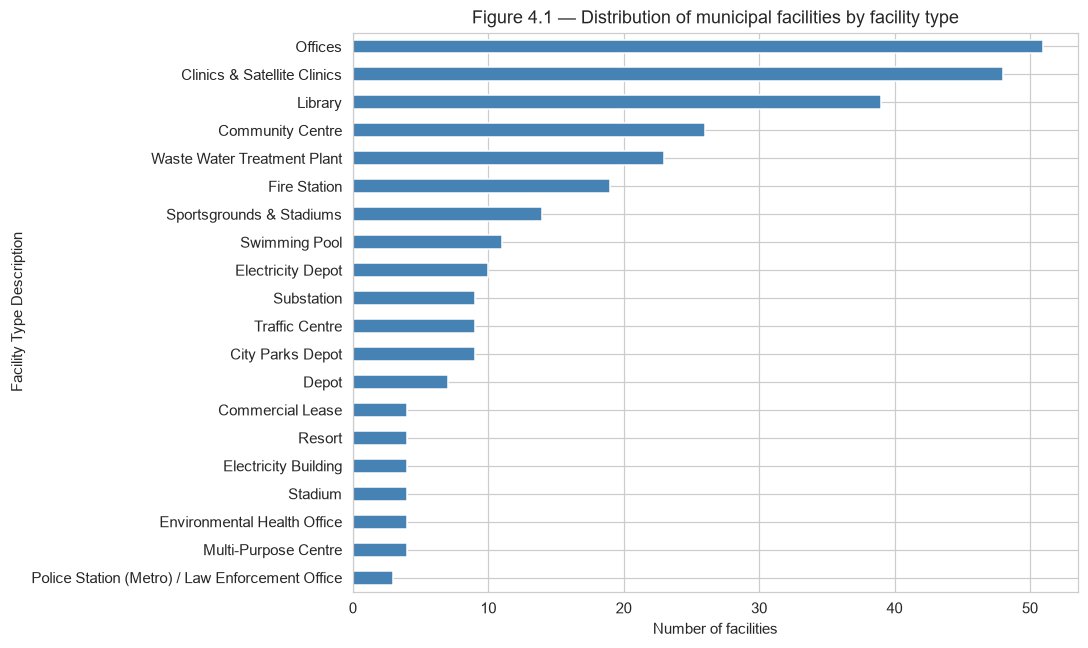

In [29]:
data_41 = facilities["Facility Type Description"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
data_41.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Figure 4.1 — Distribution of municipal facilities by facility type")
ax.set_xlabel("Number of facilities")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

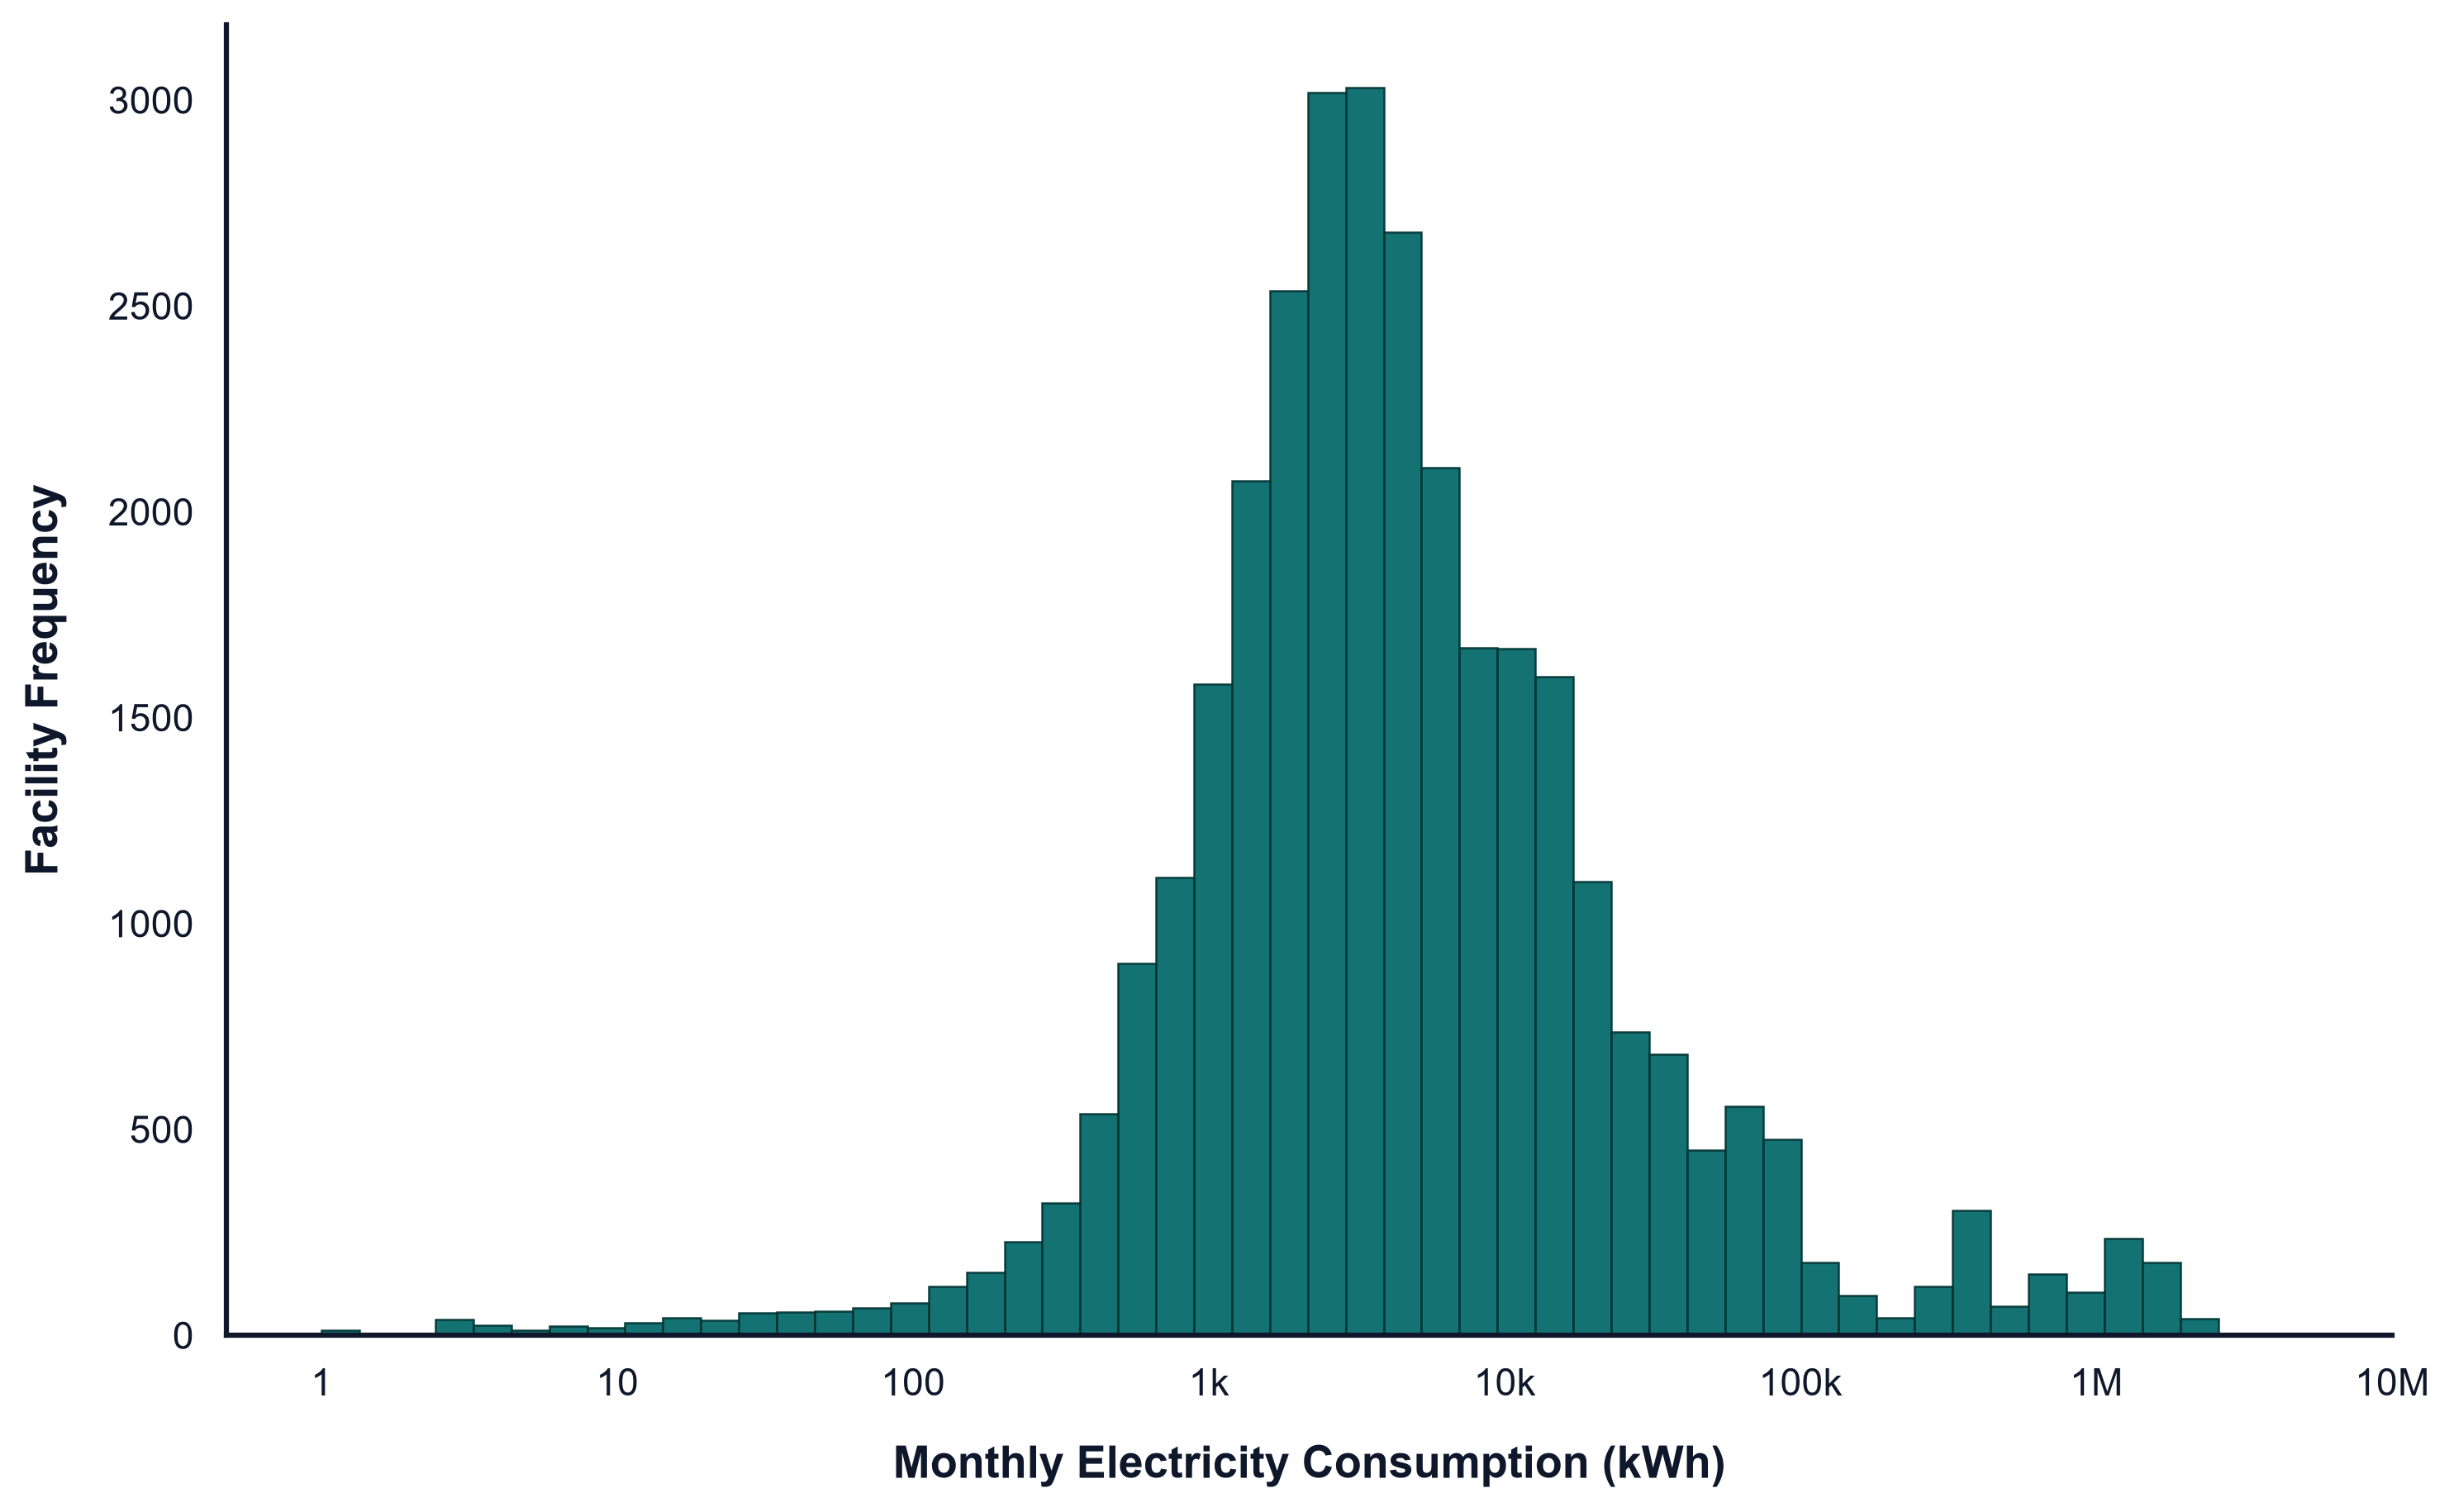

In [30]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

# ------------------------------------------------------------------------------
# 1. DATA PREPARATION
# ------------------------------------------------------------------------------
vals = pd.to_numeric(fac["Monthly Electricity Consumption"], errors="coerce").dropna()
vals_pos = vals[vals > 0]
log_vals = np.log10(vals_pos)

# ------------------------------------------------------------------------------
# 2. GLOBAL TYPOGRAPHY & STYLING (ARIAL)
# ------------------------------------------------------------------------------
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.edgecolor"] = "#0f172a"  # Deep dark slate for visible borders
plt.rcParams["axes.linewidth"] = 1.5

# Dimensions scaled for A4 standard page width (10in x 6.2in maintains clear proportions)
fig, ax = plt.subplots(figsize=(10, 6.2), dpi=300)

# ------------------------------------------------------------------------------
# 3. HISTOGRAM PLOTTING & STYLING
# ------------------------------------------------------------------------------
# Distinct bar styling with subtle dark edge highlight
n, bins, patches = ax.hist(
    log_vals,
    bins=50,
    color="#006666",        # Deep teal
    edgecolor="#003333",    # Darker teal border for distinction
    linewidth=0.6,
    alpha=0.92,
)

# Explicitly remove gridlines
ax.grid(False)

# Remove top and right spines (keep only deep left and bottom borders)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#0f172a")
ax.spines["bottom"].set_color("#0f172a")

# ------------------------------------------------------------------------------
# 4. AXIS LABELS & READABLE LOG-TRANSFORM TICKS
# ------------------------------------------------------------------------------
# Primary Axis Labels
ax.set_xlabel(
    "Monthly Electricity Consumption (kWh)",
    fontsize=13,
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)
ax.set_ylabel(
    "Facility Frequency",
    fontsize=13,
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)

# Format X-axis tick locations (Log10 space) to human-readable numbers
min_pow = int(np.floor(log_vals.min()))
max_pow = int(np.ceil(log_vals.max()))
ticks = np.arange(min_pow, max_pow + 1)

def format_log_label(val, pos):
    """Converts log10 values back to clear readable energy units."""
    raw_val = 10**val
    if raw_val >= 1e6:
        return f"{raw_val/1e6:.0f}M"
    elif raw_val >= 1e3:
        return f"{raw_val/1e3:.0f}k"
    else:
        return f"{raw_val:.0f}"

ax.set_xticks(ticks)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_log_label))

# Tick mark styling
ax.tick_params(
    axis="both",
    which="major",
    labelsize=11,
    colors="#0f172a",
    width=1.5,
    length=6,
    direction="out",
)

# Add minor ticks on Y-axis for frequency precision
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.tick_params(axis="y", which="minor", width=1.0, length=3, colors="#0f172a")

# Ensure tight margins without title truncation
plt.tight_layout()
plt.show()

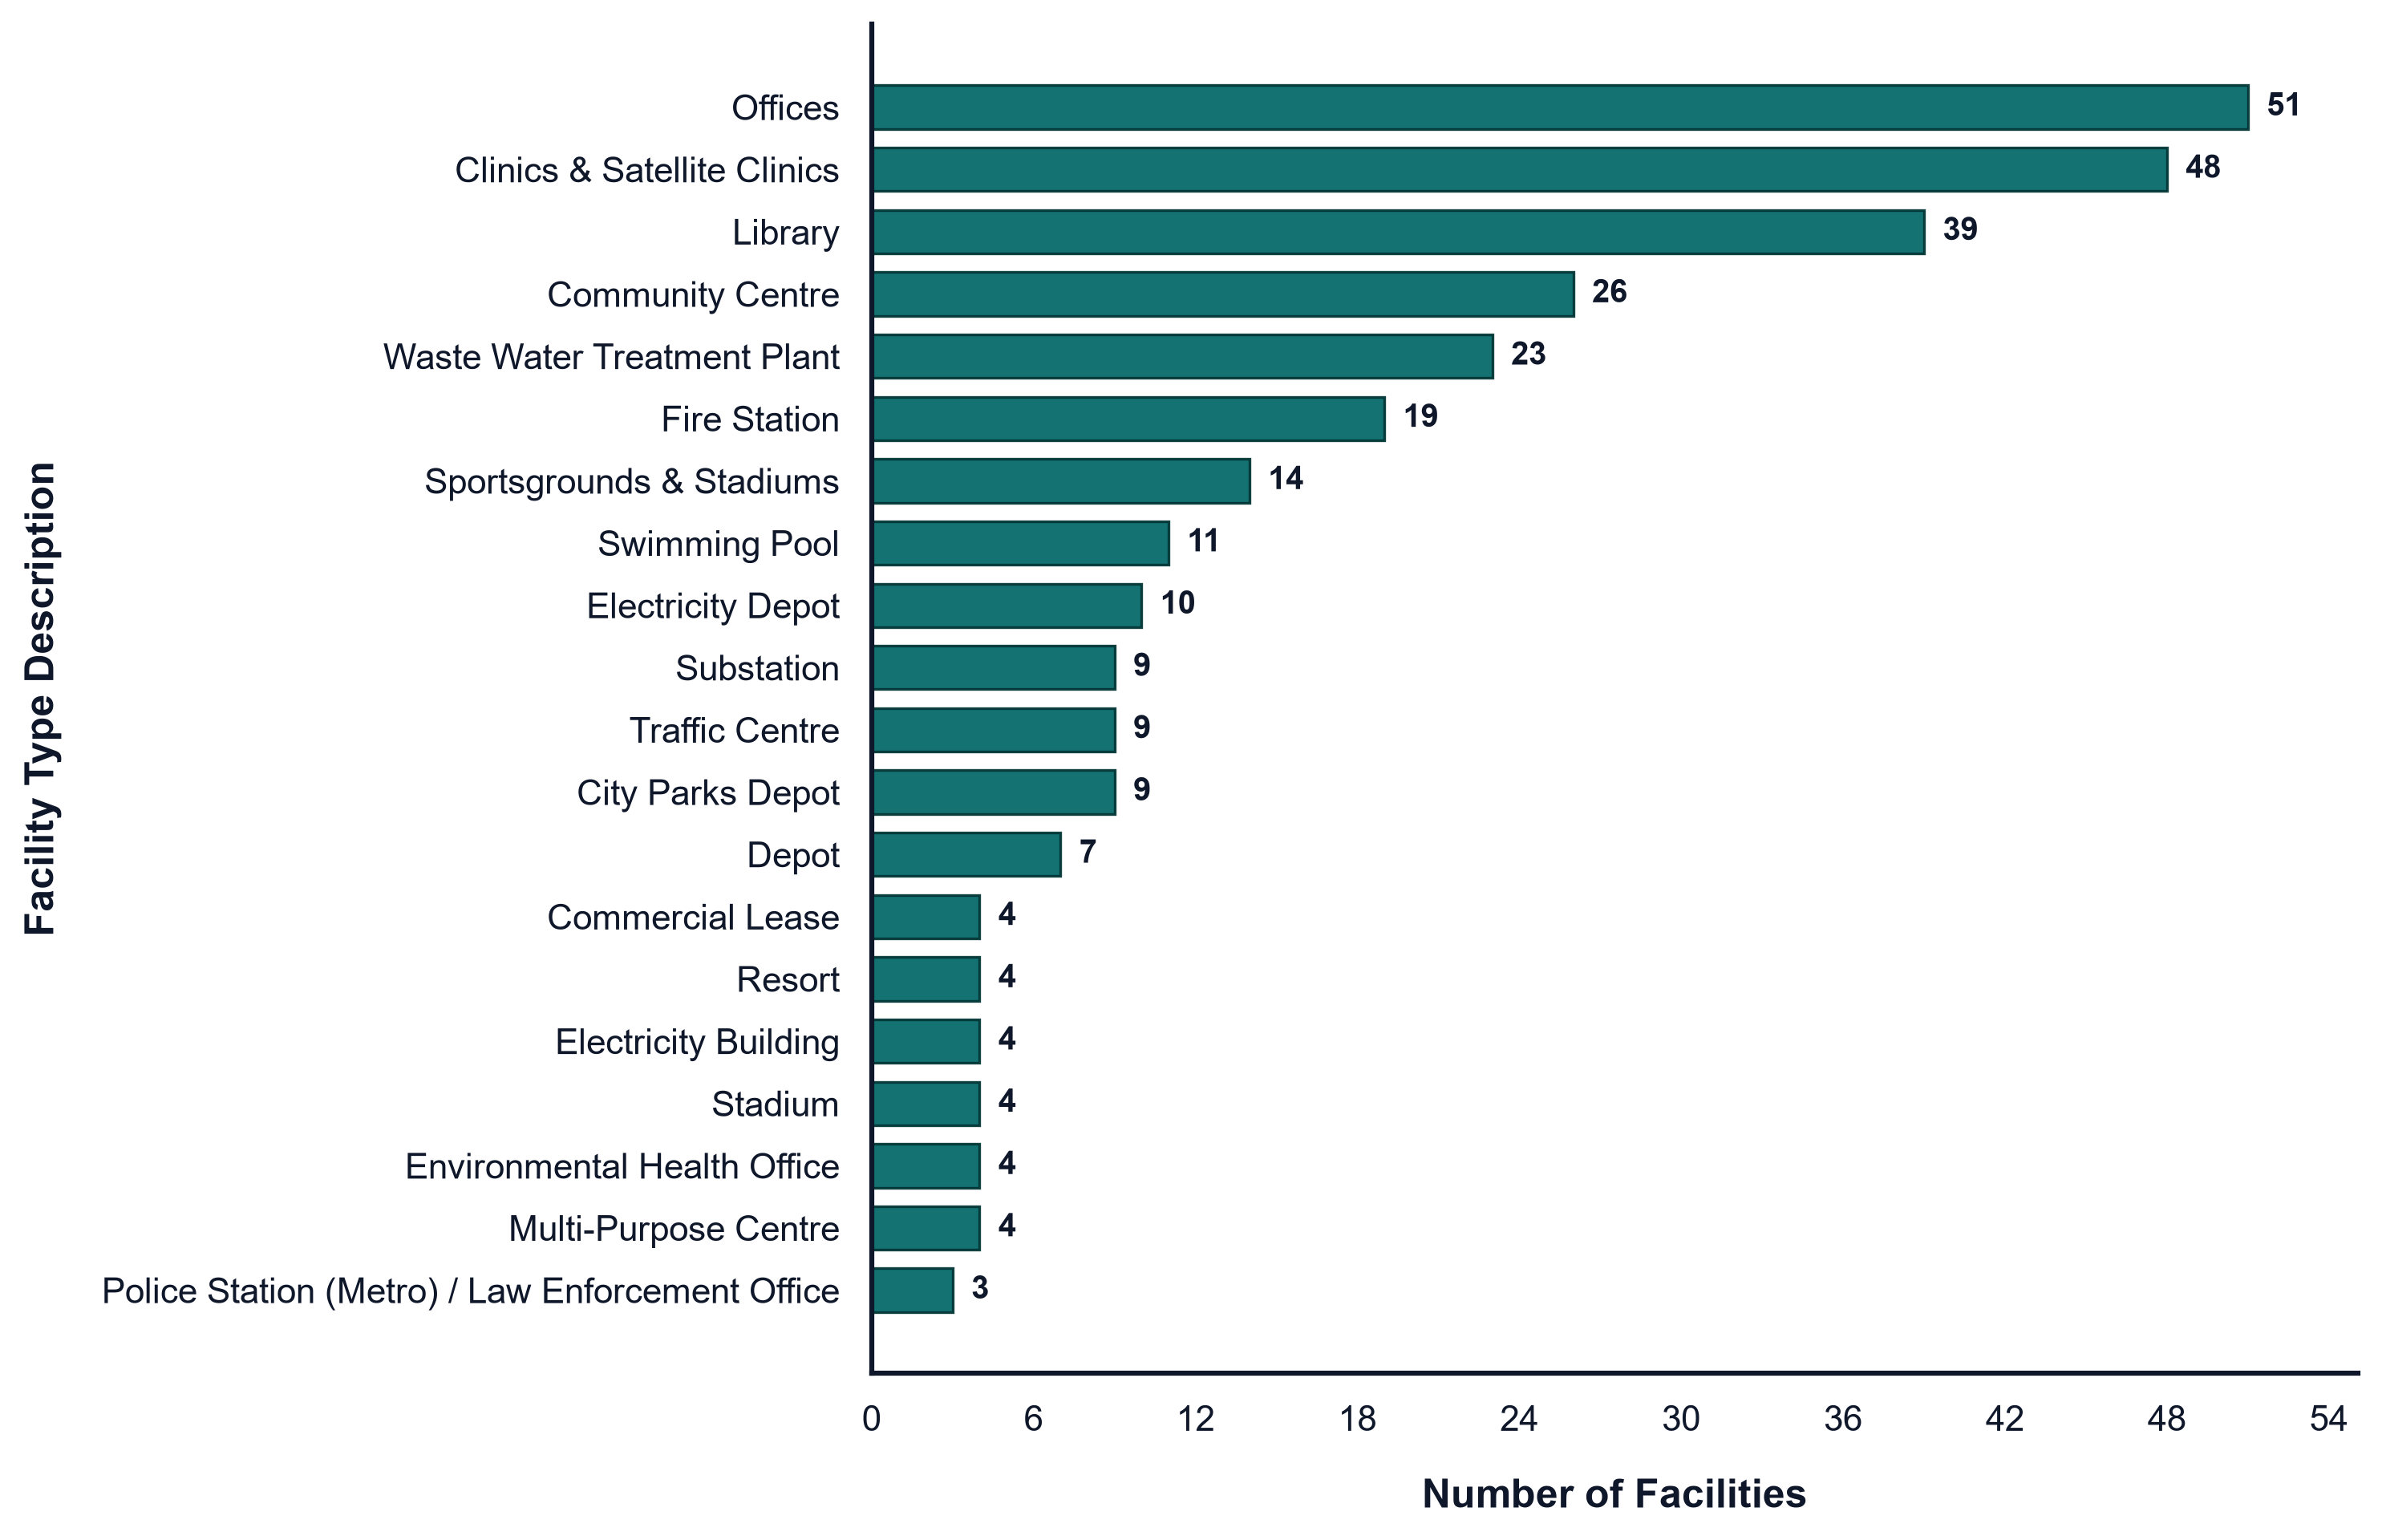

In [31]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

# ------------------------------------------------------------------------------
# 1. DATA PREPARATION
# ------------------------------------------------------------------------------
data_41 = facilities["Facility Type Description"].value_counts().head(20)

# ------------------------------------------------------------------------------
# 2. GLOBAL TYPOGRAPHY & STYLING (ARIAL)
# ------------------------------------------------------------------------------
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.edgecolor"] = "#0f172a"  # Deep dark slate for visible borders
plt.rcParams["axes.linewidth"] = 1.5

# Sized for A4 manuscript layout (10in x 6.5in maintains clean vertical spacing for 20 categories)
fig, ax = plt.subplots(figsize=(10, 6.5), dpi=300)

# ------------------------------------------------------------------------------
# 3. BAR CHART PLOTTING & STYLING
# ------------------------------------------------------------------------------
# Horizontal bars with distinct dark edge definition
bars = ax.barh(
    y=data_41.index,
    width=data_41.values,
    color="#006666",        # Deep teal matching Figure 4.2
    edgecolor="#003333",    # Darker border for distinction
    linewidth=0.8,
    height=0.7,
    alpha=0.92,
)

# Invert Y-axis so the highest frequency appears at the top
ax.invert_yaxis()

# Explicitly remove gridlines
ax.grid(False)

# Remove top and right spines (keep only deep left and bottom borders)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#0f172a")
ax.spines["bottom"].set_color("#0f172a")

# ------------------------------------------------------------------------------
# 4. AXIS LABELS & TICK FORMATTING
# ------------------------------------------------------------------------------
ax.set_xlabel(
    "Number of Facilities",
    fontsize=12,
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)
ax.set_ylabel(
    "Facility Type Description",
    fontsize=12,
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)

# Format X-axis integer tick marks
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Tick mark styling
ax.tick_params(
    axis="both",
    which="major",
    labelsize=10.5,
    colors="#0f172a",
    width=1.5,
    length=6,
    direction="out",
)

# Optional: Add clear data labels at the tip of each bar
for bar in bars:
    width = bar.get_width()
    ax.annotate(
        f" {int(width):,}",
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(3, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9.5,
        color="#0f172a",
        fontweight="bold",
    )

# Adjust x-limits to ensure data labels aren't clipped by the right margin
ax.set_xlim(0, data_41.max() * 1.08)

plt.tight_layout()
plt.show()

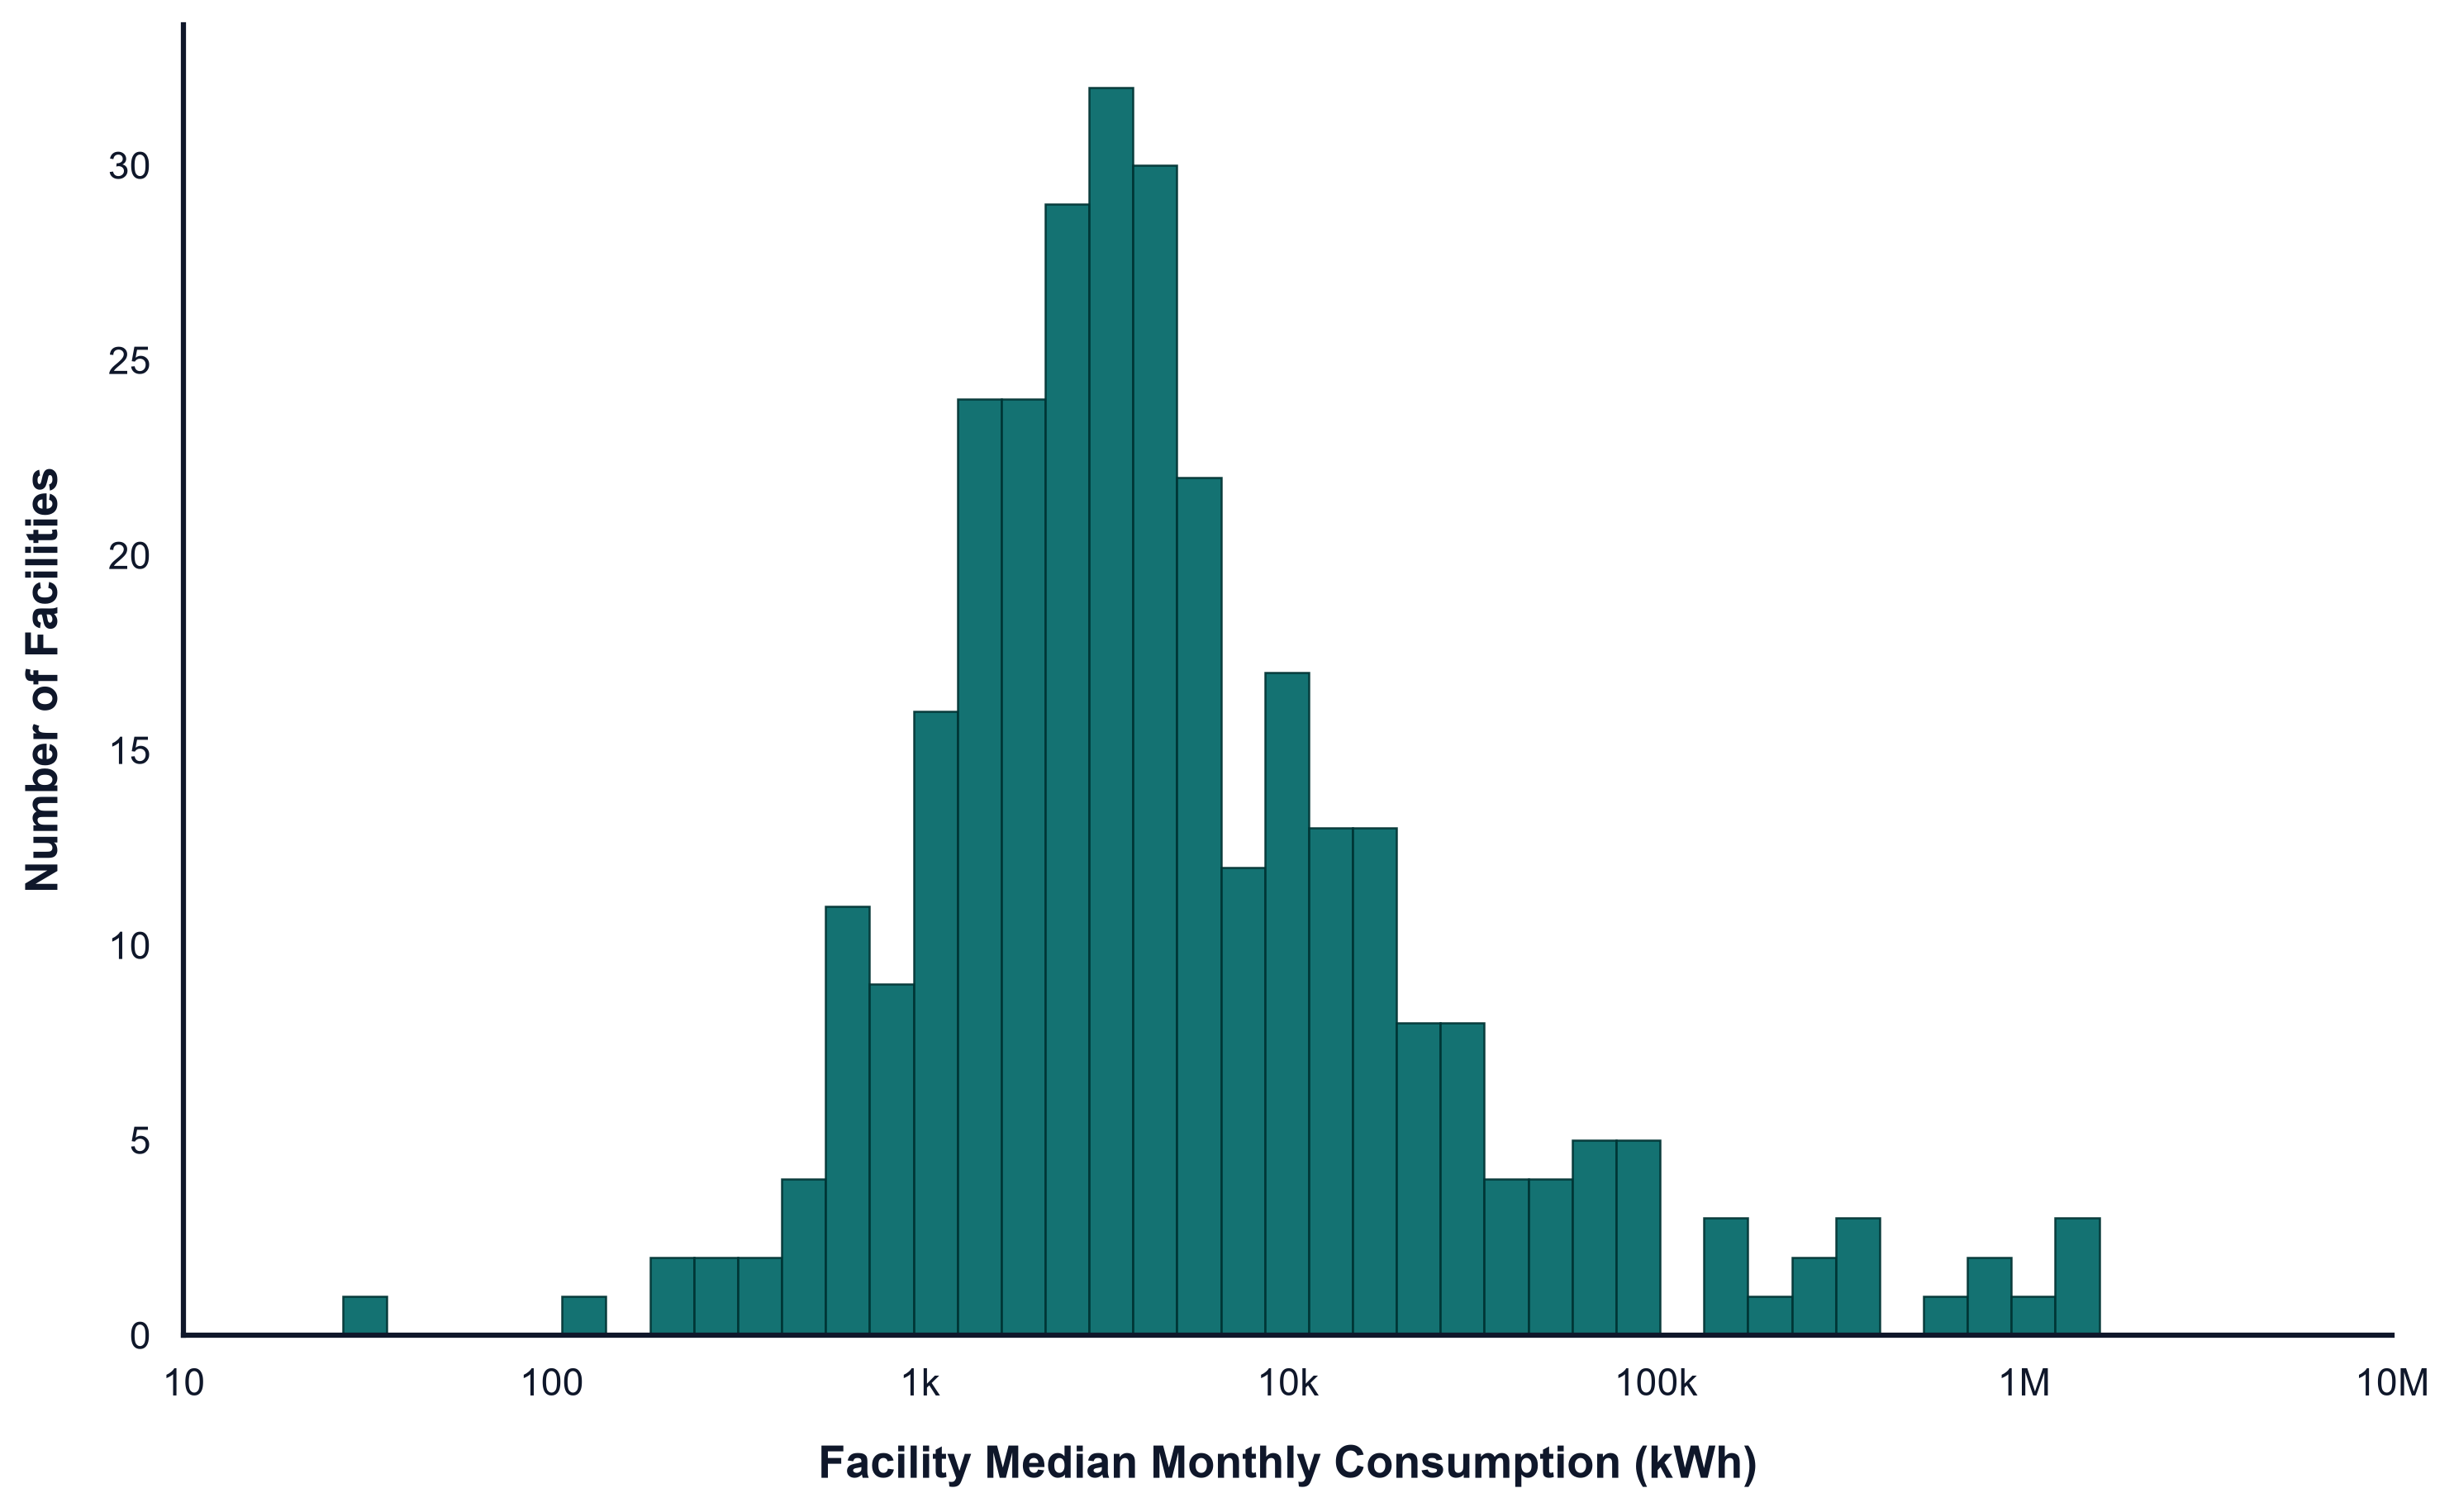

In [32]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

# ------------------------------------------------------------------------------
# 1. DATA PREPARATION
# ------------------------------------------------------------------------------
col = "Monthly Electricity Consumption_median"
med = facility_agg[col].dropna()
med_pos = med[med > 0]
log_med = np.log10(med_pos)

# ------------------------------------------------------------------------------
# 2. GLOBAL TYPOGRAPHY & STYLING (ARIAL)
# ------------------------------------------------------------------------------
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.edgecolor"] = "#0f172a"  # Deep dark slate for visible borders
plt.rcParams["axes.linewidth"] = 1.5

# Sized for A4 manuscript layout (10in x 6.2in maintains clean proportions)
fig, ax = plt.subplots(figsize=(10, 6.2), dpi=300)

# ------------------------------------------------------------------------------
# 3. HISTOGRAM PLOTTING & STYLING
# ------------------------------------------------------------------------------
# Distinct bar styling matching Figures 4.1 & 4.2
n, bins, patches = ax.hist(
    log_med,
    bins=40,
    color="#006666",        # Deep teal
    edgecolor="#003333",    # Darker teal border for distinction
    linewidth=0.6,
    alpha=0.92,
)

# Explicitly remove gridlines
ax.grid(False)

# Remove top and right spines (keep deep left and bottom borders only)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#0f172a")
ax.spines["bottom"].set_color("#0f172a")

# ------------------------------------------------------------------------------
# 4. AXIS LABELS & READABLE LOG-TRANSFORM TICKS
# ------------------------------------------------------------------------------
# Primary Axis Labels
ax.set_xlabel(
    "Facility Median Monthly Consumption (kWh)",
    fontsize=13,
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)
ax.set_ylabel(
    "Number of Facilities",
    fontsize=13,
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)

# Format X-axis tick locations (Log10 space) into clear, readable energy units
min_pow = int(np.floor(log_med.min()))
max_pow = int(np.ceil(log_med.max()))
ticks = np.arange(min_pow, max_pow + 1)

def format_log_label(val, pos):
    """Converts log10 values back to human-readable energy units."""
    raw_val = 10**val
    if raw_val >= 1e6:
        return f"{raw_val/1e6:.0f}M"
    elif raw_val >= 1e3:
        return f"{raw_val/1e3:.0f}k"
    else:
        return f"{raw_val:.0f}"

ax.set_xticks(ticks)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_log_label))

# Tick mark styling
ax.tick_params(
    axis="both",
    which="major",
    labelsize=11,
    colors="#0f172a",
    width=1.5,
    length=6,
    direction="out",
)

# Minor ticks on Y-axis for frequency precision
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.tick_params(axis="y", which="minor", width=1.0, length=3, colors="#0f172a")

plt.tight_layout()
plt.show()

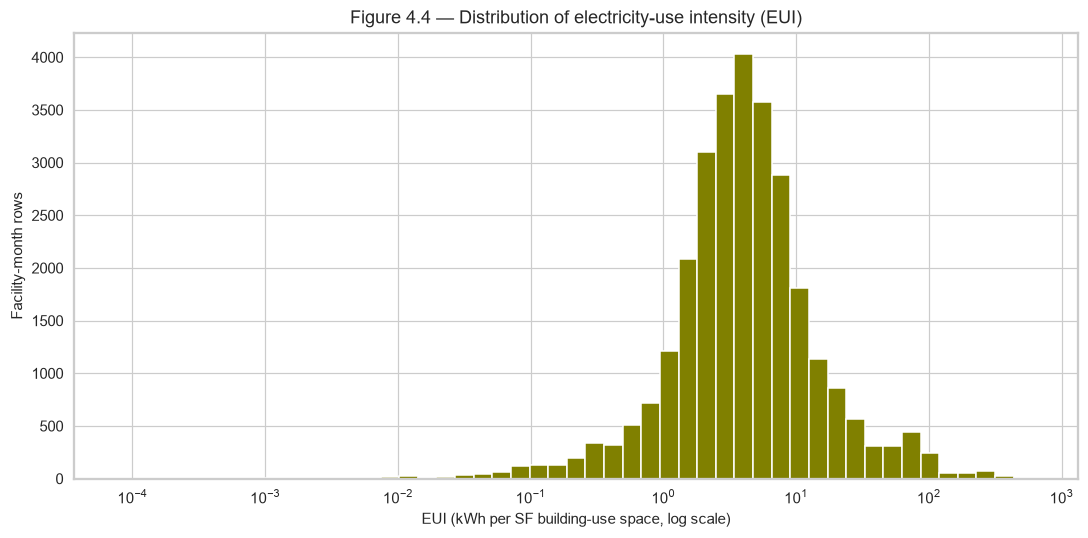

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

e = fac["EUI"].dropna()
e = e[e > 0]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(e, bins=np.logspace(np.log10(e.min()), np.log10(e.max()), 50),
        color="olive", edgecolor="white")
ax.set_xscale("log")
ax.set_title("Figure 4.4 — Distribution of electricity-use intensity (EUI)")
ax.set_xlabel("EUI (kWh per SF building-use space, log scale)")
ax.set_ylabel("Facility-month rows")
plt.tight_layout(); plt.show()

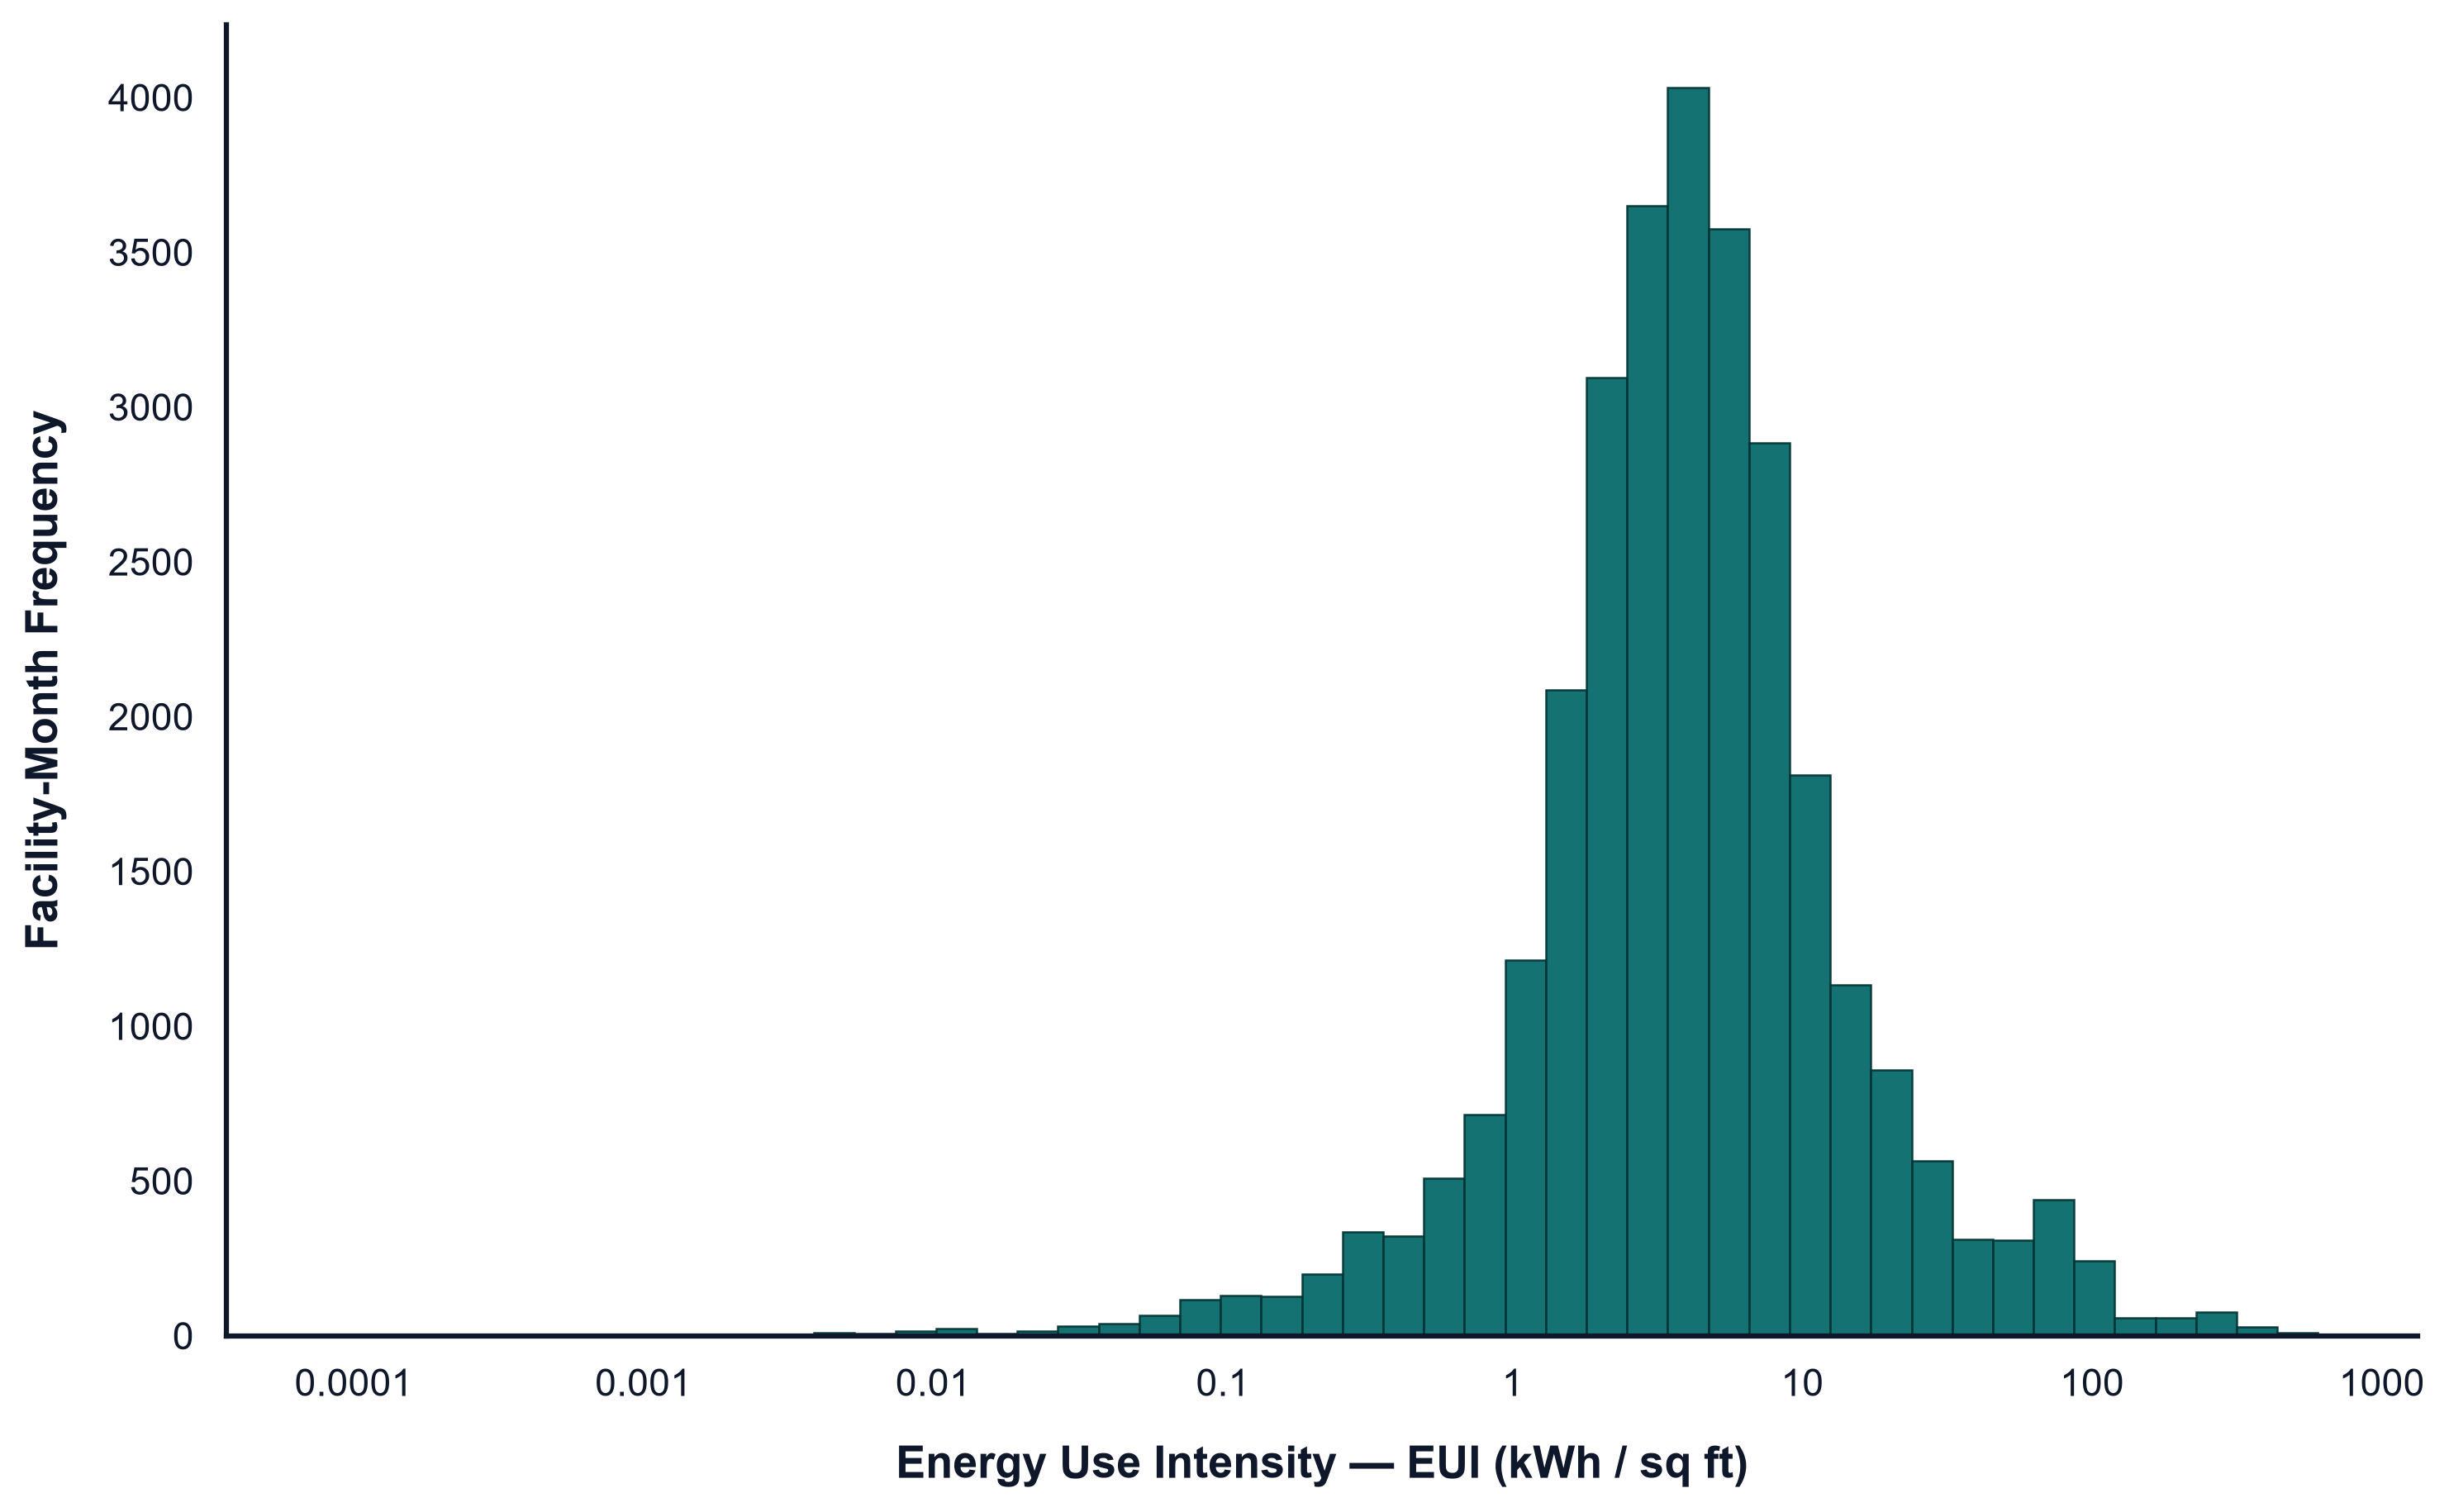

In [34]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

# ------------------------------------------------------------------------------
# 1. DATA PREPARATION
# ------------------------------------------------------------------------------
e = fac["EUI"].dropna()
e = e[e > 0]

# ------------------------------------------------------------------------------
# 2. GLOBAL TYPOGRAPHY & STYLING (ARIAL)
# ------------------------------------------------------------------------------
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.edgecolor"] = "#0f172a"  # Deep dark slate for visible borders
plt.rcParams["axes.linewidth"] = 1.5

# Sized for A4 manuscript layout (10in x 6.2in maintains clean proportions)
fig, ax = plt.subplots(figsize=(10, 6.2), dpi=300)

# ------------------------------------------------------------------------------
# 3. HISTOGRAM PLOTTING & STYLING
# ------------------------------------------------------------------------------
# Logarithmically spaced bins matching Figures 4.1–4.3 palette
bins = np.logspace(np.log10(e.min()), np.log10(e.max()), 50)

n, bins, patches = ax.hist(
    e,
    bins=bins,
    color="#006666",        # Deep teal
    edgecolor="#003333",    # Darker teal border for distinction
    linewidth=0.6,
    alpha=0.92,
)

# Apply log scale to X-axis
ax.set_xscale("log")

# Explicitly remove gridlines
ax.grid(False)

# Remove top and right spines (keep deep left and bottom borders only)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#0f172a")
ax.spines["bottom"].set_color("#0f172a")

# ------------------------------------------------------------------------------
# 4. AXIS LABELS & READABLE LOG-TRANSFORM TICKS
# ------------------------------------------------------------------------------
ax.set_xlabel(
    "Energy Use Intensity — EUI (kWh / sq ft)",
    fontsize=13,
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)
ax.set_ylabel(
    "Facility-Month Frequency",
    fontsize=13,
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)

# Format X-axis tick locations to clear decimal / integer values
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:g}"))

# Tick mark styling
ax.tick_params(
    axis="both",
    which="major",
    labelsize=11,
    colors="#0f172a",
    width=1.5,
    length=6,
    direction="out",
)

# Minor ticks on Y-axis for frequency precision
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.tick_params(axis="y", which="minor", width=1.0, length=3, colors="#0f172a")

plt.tight_layout()
plt.show()

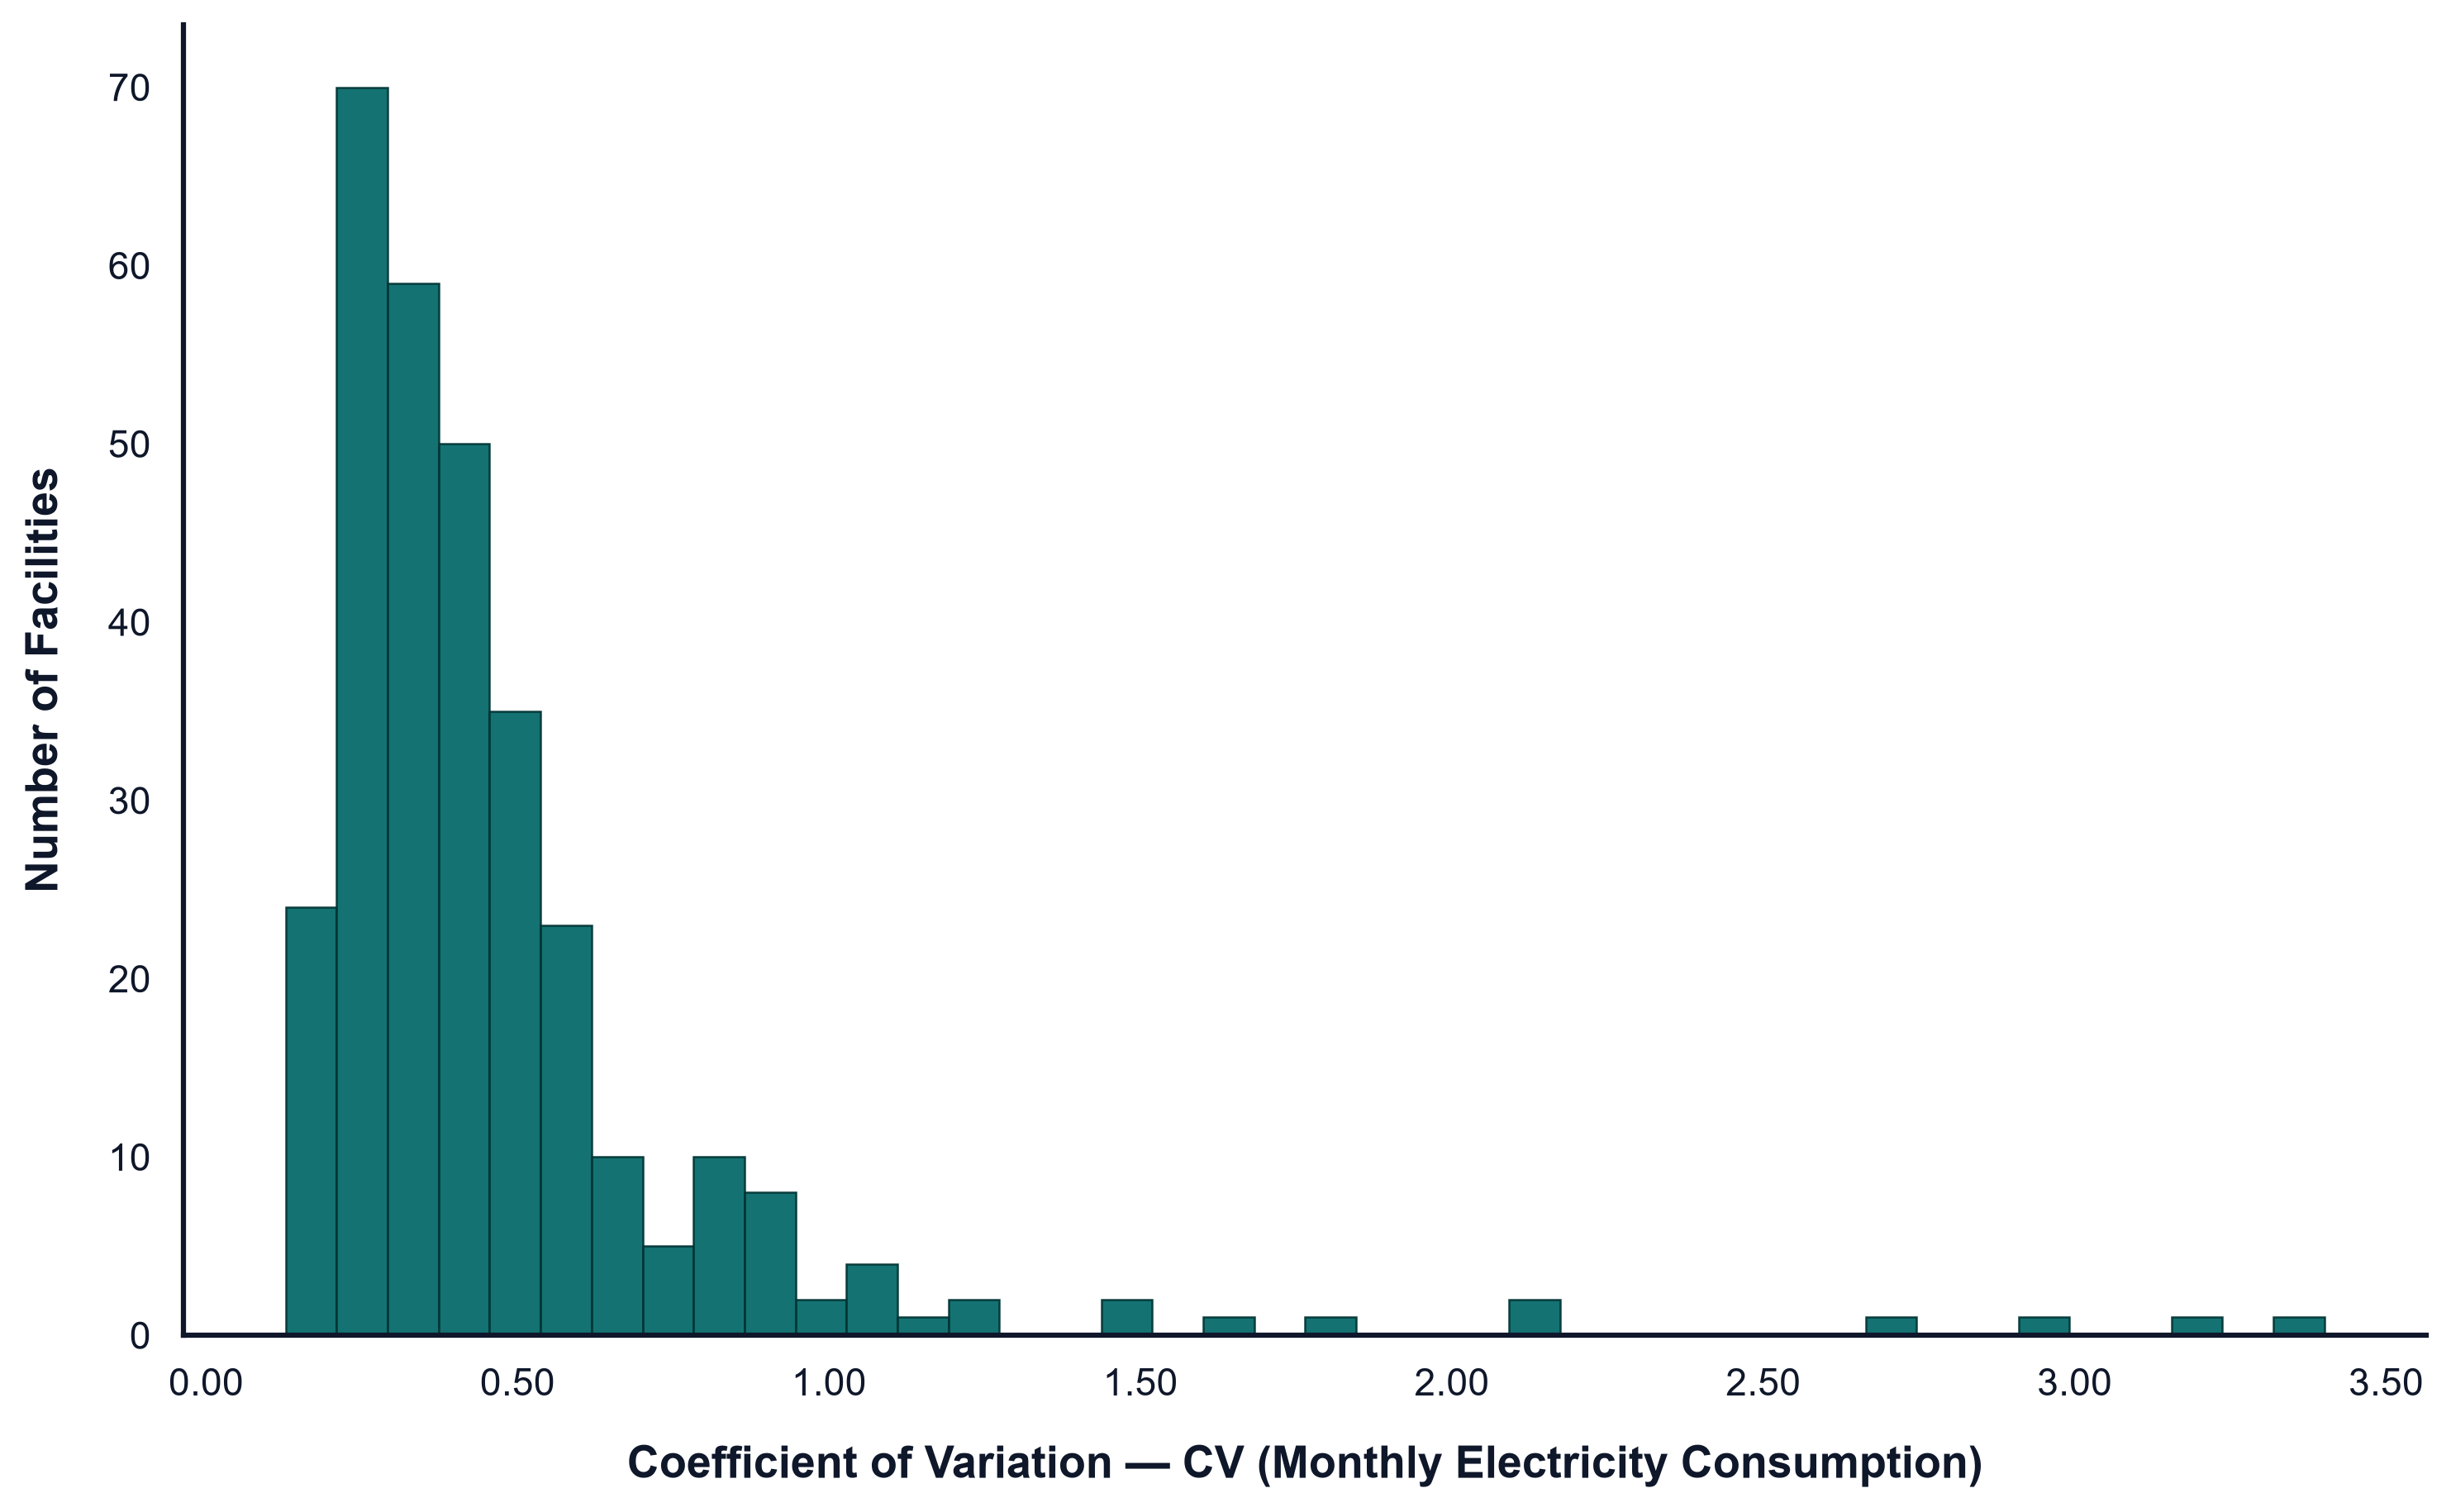

count   313.0000
mean      0.4820
std       0.4091
min       0.1277
25%       0.2792
50%       0.3758
75%       0.5257
max       3.4009
Name: CV, dtype: float64
Facilities with computable CV: 313


In [36]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

# ------------------------------------------------------------------------------
# 1. DATA PREPARATION
# ------------------------------------------------------------------------------
cv = cv_df["CV"].dropna()

# ------------------------------------------------------------------------------
# 2. GLOBAL TYPOGRAPHY & STYLING (ARIAL)
# ------------------------------------------------------------------------------
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.edgecolor"] = "#0f172a"  # Deep dark slate for visible borders
plt.rcParams["axes.linewidth"] = 1.5

# Sized for A4 manuscript layout (10in x 6.2in maintains clean proportions)
fig, ax = plt.subplots(figsize=(10, 6.2), dpi=300)

# ------------------------------------------------------------------------------
# 3. HISTOGRAM PLOTTING & STYLING
# ------------------------------------------------------------------------------
# Distinct bar styling matching Figures 4.1–4.4 palette
n, bins, patches = ax.hist(
    cv,
    bins=40,
    color="#006666",        # Deep teal
    edgecolor="#003333",    # Darker teal border for distinction
    linewidth=0.6,
    alpha=0.92,
)

# Explicitly remove gridlines
ax.grid(False)

# Remove top and right spines (keep deep left and bottom borders only)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#0f172a")
ax.spines["bottom"].set_color("#0f172a")

# ------------------------------------------------------------------------------
# 4. AXIS LABELS & READABLE TICKS
# ------------------------------------------------------------------------------
ax.set_xlabel(
    "Coefficient of Variation — CV (Monthly Electricity Consumption)",
    fontsize=13,
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)
ax.set_ylabel(
    "Number of Facilities",
    fontsize=13,
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)

# Format X-axis tick mark precision
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=8))
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

# Tick mark styling
ax.tick_params(
    axis="both",
    which="major",
    labelsize=11,
    colors="#0f172a",
    width=1.5,
    length=6,
    direction="out",
)

# Minor ticks on Y-axis for frequency precision
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.tick_params(axis="y", which="minor", width=1.0, length=3, colors="#0f172a")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 5. STATISTICAL SUMMARY OUTPUT
# ------------------------------------------------------------------------------
print(cv.describe())
print(f"Facilities with computable CV: {len(cv)}")

In [37]:
import pandas as pd
import numpy as np

FACILITY_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\SmartFacility_Energy_FullNames.xlsx"
fac_raw = pd.read_excel(FACILITY_FILE)
fac = fac_raw.dropna(subset=["LIS Key"]).copy()

# Numeric consumption
fac["_mcons"] = pd.to_numeric(fac["Monthly Electricity Consumption"], errors="coerce")
fac["_space"] = pd.to_numeric(fac["SF Building Use Space"], errors="coerce")

# Departmental aggregation
dept_use = fac.groupby("Department Description").agg(
    n_facilities=("LIS Key", "nunique"),
    n_records=("_mcons", "count"),
    total_monthly_consumption=("_mcons", "sum"),
    mean_monthly_consumption=("_mcons", "mean"),
    median_monthly_consumption=("_mcons", "median"),
).sort_values("total_monthly_consumption", ascending=False)

# Share of total
dept_use["share_of_total_use (%)"] = (
    dept_use["total_monthly_consumption"] /
    dept_use["total_monthly_consumption"].sum() * 100
).round(2)

print(dept_use.round(2).to_string())

                                         n_facilities  n_records  total_monthly_consumption  mean_monthly_consumption  median_monthly_consumption  share_of_total_use (%)
Department Description                                                                                                                                                   
Water and Sanitation                               25       2387           805,913,337.0000              337,626.0300                 66,612.0000                 59.3200
Facilities Management                             102       9748           361,298,300.0000               37,063.8400                  5,756.0000                 26.5900
Strategic Assets                                    7        541            63,618,245.0000              117,593.8000                 19,259.0000                  4.6800
Electricity Generation and Distribution            27       2467            52,452,535.0000               21,261.6700                 11,509.0000     

In [39]:
from scipy import stats
import pandas as pd

# --- Reattach Facility Type to cv_df ---
ftype_by_lis = fac.groupby("LIS Key")["Facility Type Description"].first()
cv_df["Facility Type"] = ftype_by_lis.reindex(cv_df.index)

# --- Build groups with n >= 5 and non-missing CV ---
groups = [
    g["CV"].dropna().values
    for _, g in cv_df.groupby("Facility Type")
    if len(g) >= 5 and g["CV"].notna().any()
]

# --- Kruskal-Wallis test ---
kw = stats.kruskal(*groups)
print(f"Groups compared : {len(groups)}")
print(f"Kruskal-Wallis H: {kw.statistic:.3f}")
print(f"p-value         : {kw.pvalue:.4g}")

# --- Also report per-group descriptives to match Table 4.7 ---
summary = (cv_df.groupby("Facility Type")["CV"]
           .agg(n="count", mean="mean", median="median", sd="std")
           .query("n >= 5")
           .sort_values("mean", ascending=False)
           .round(3))
print("\n" + summary.to_string())

Groups compared : 13
Kruskal-Wallis H: 36.280
p-value         : 0.000292

                              n   mean  median     sd
Facility Type                                        
Substation                    9 0.6930  0.4260 1.0250
City Parks Depot              9 0.6870  0.5370 0.4230
Swimming Pool                11 0.6550  0.5790 0.3640
Depot                         7 0.6450  0.4830 0.3880
Waste Water Treatment Plant  22 0.5430  0.4730 0.3260
Electricity Depot            10 0.5360  0.3540 0.5820
Sportsgrounds & Stadiums     14 0.4630  0.4030 0.1990
Community Centre             26 0.4560  0.3840 0.1960
Library                      39 0.4300  0.3660 0.2740
Offices                      51 0.4180  0.3830 0.2130
Clinics & Satellite Clinics  48 0.3960  0.3220 0.2030
Fire Station                 19 0.2930  0.2510 0.1220
Traffic Centre                8 0.2870  0.2470 0.1180


In [40]:
import pandas as pd

LOADSHED_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\Loadshedding_schedule.csv"
ls_raw = pd.read_csv(LOADSHED_FILE, dtype=str)
ls_raw["_date"] = pd.to_datetime(ls_raw["Date"], errors="coerce")
ls = ls_raw.dropna(subset=["_date"]).copy()
ls["_year"] = ls["_date"].dt.year

by_year = (ls["_year"].value_counts().sort_index()
           .rename_axis("Year").to_frame("Events"))
by_year["Share (%)"] = (by_year["Events"] / by_year["Events"].sum() * 100).round(2)

print(by_year.to_string())
print(f"\nTotal: {by_year['Events'].sum():,}")

      Events  Share (%)
Year                   
2020     840     4.7800
2021     851     4.8400
2022    4327    24.6200
2023   10024    57.0400
2024    1289     7.3300
2025     243     1.3800

Total: 17,574


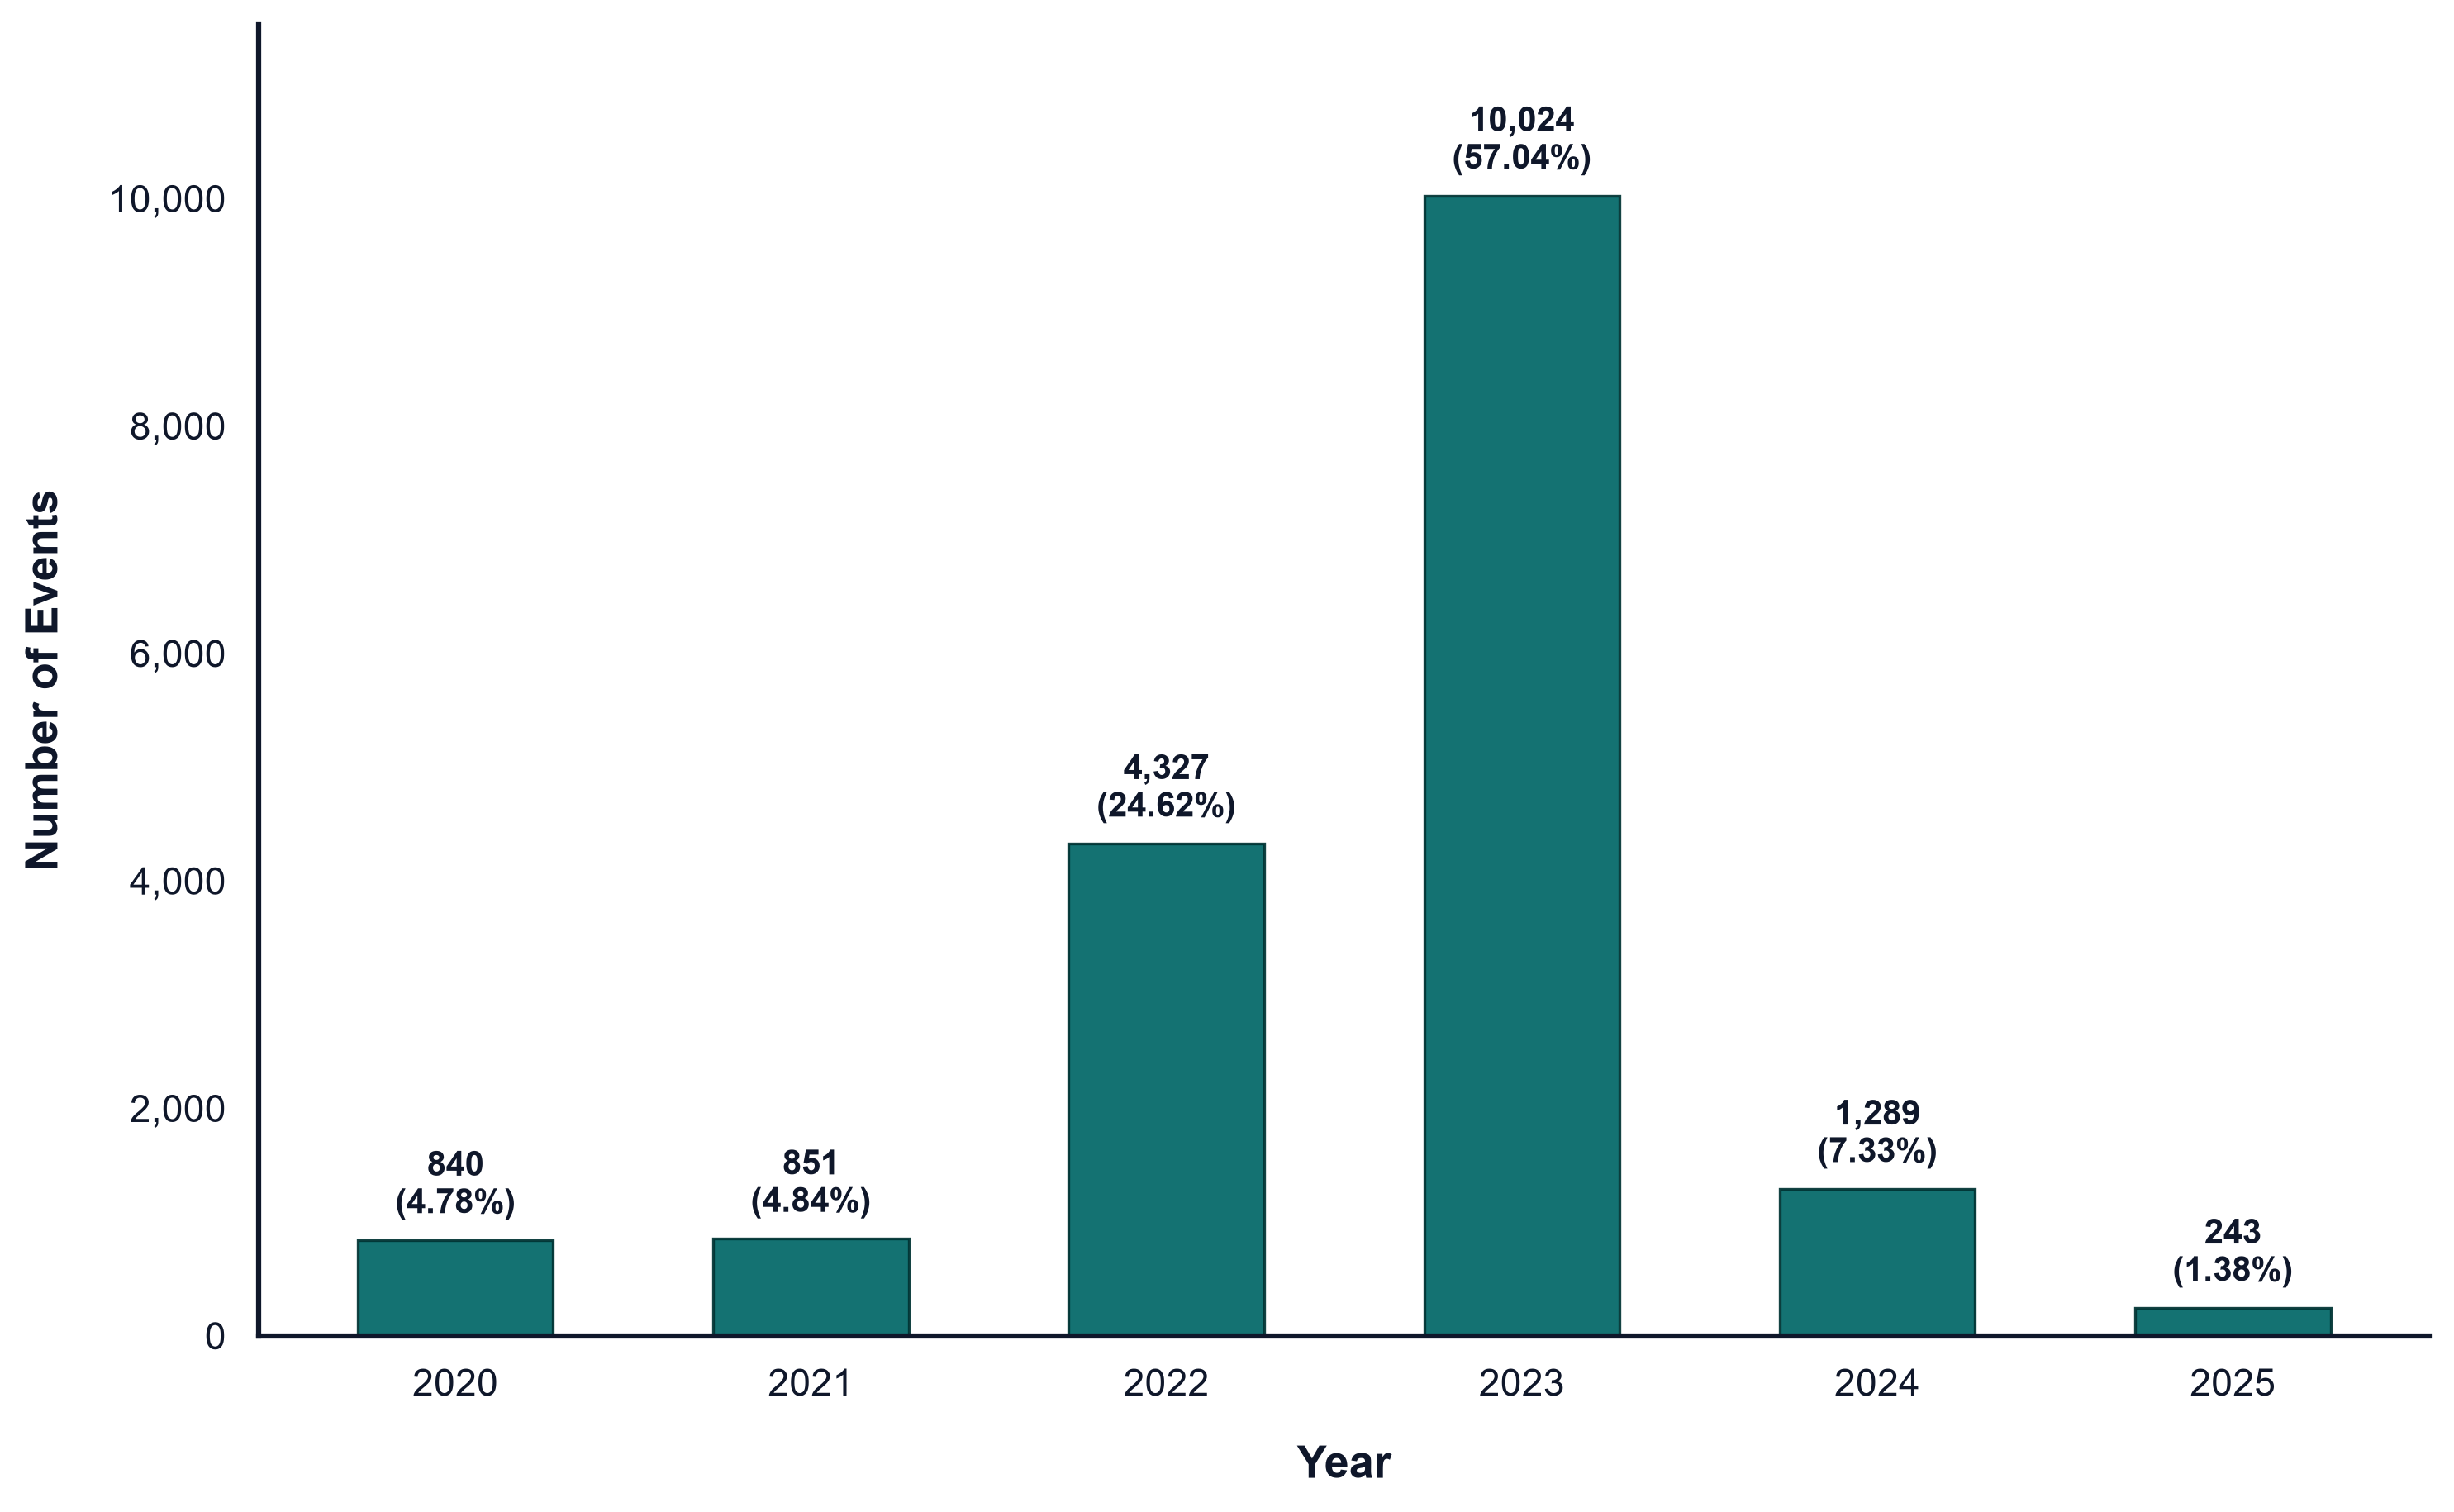

In [41]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

# ------------------------------------------------------------------------------
# 1. DATA PREPARATION
# ------------------------------------------------------------------------------
data = {
    "Year": [2020, 2021, 2022, 2023, 2024, 2025],
    "Events": [840, 851, 4327, 10024, 1289, 243],
    "Share": [4.78, 4.84, 24.62, 57.04, 7.33, 1.38],
}
df = pd.DataFrame(data)

# ------------------------------------------------------------------------------
# 2. GLOBAL TYPOGRAPHY & STYLING (ARIAL)
# ------------------------------------------------------------------------------
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.edgecolor"] = "#0f172a"  # Deep dark slate for visible borders
plt.rcParams["axes.linewidth"] = 1.5

# Sized for A4 manuscript layout (10in x 6.2in maintains clean proportions)
fig, ax = plt.subplots(figsize=(10, 6.2), dpi=300)

# ------------------------------------------------------------------------------
# 3. BAR CHART PLOTTING & STYLING
# ------------------------------------------------------------------------------
# Vertical bar chart matching Figures 4.1–4.5 palette
bars = ax.bar(
    x=df["Year"].astype(str),
    height=df["Events"],
    color="#006666",        # Deep teal
    edgecolor="#003333",    # Darker teal border for distinction
    linewidth=0.8,
    width=0.55,
    alpha=0.92,
)

# Explicitly remove gridlines
ax.grid(False)

# Remove top and right spines (keep deep left and bottom borders only)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#0f172a")
ax.spines["bottom"].set_color("#0f172a")

# ------------------------------------------------------------------------------
# 4. AXIS LABELS & READABLE TICKS
# ------------------------------------------------------------------------------
ax.set_xlabel(
    "Year",
    fontsize=13,
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)
ax.set_ylabel(
    "Number of Events",
    fontsize=13,
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)

# Format Y-axis with comma separators
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"{int(x):,}"))

# Tick mark styling
ax.tick_params(
    axis="both",
    which="major",
    labelsize=11,
    colors="#0f172a",
    width=1.5,
    length=6,
    direction="out",
)

# Minor ticks on Y-axis for frequency precision
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.tick_params(axis="y", which="minor", width=1.0, length=3, colors="#0f172a")

# ------------------------------------------------------------------------------
# 5. DATA LABELS (COUNT & SHARE PERCENTAGE)
# ------------------------------------------------------------------------------
for bar, share in zip(bars, df["Share"]):
    height = bar.get_height()
    ax.annotate(
        f"{height:,}\n({share:.2f}%)",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#0f172a",
    )

# Adjust y-limit to prevent top labels from being clipped
ax.set_ylim(0, df["Events"].max() * 1.15)

plt.tight_layout()
plt.show()

Rows: 17,574
_minutes not null: 17,574
count   17,574.0000
mean       129.0960
std         21.4585
min          2.0000
25%        120.0000
50%        125.0000
75%        150.0000
max        600.0000
Name: _minutes, dtype: float64


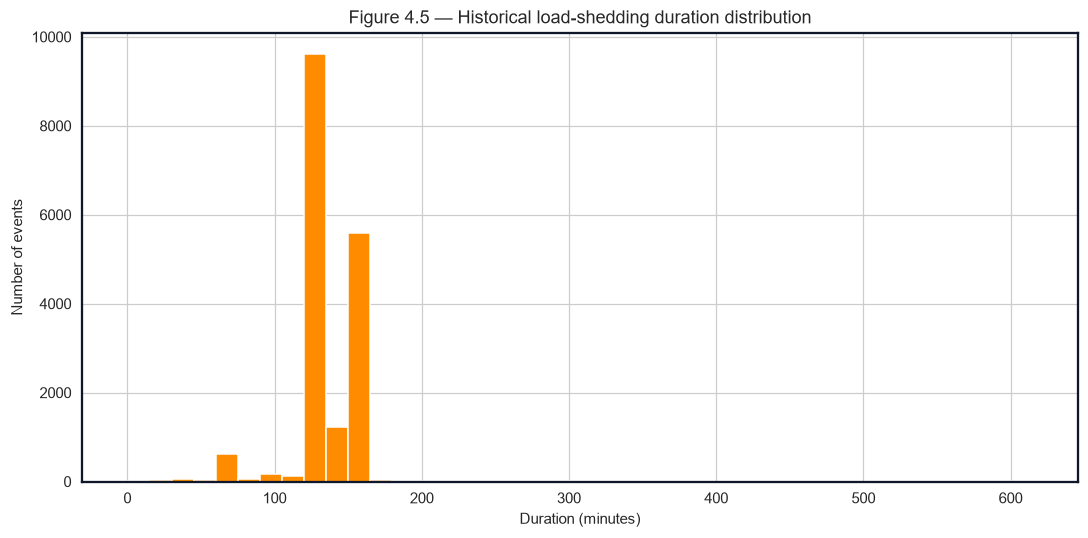

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

LOADSHED_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\Loadshedding_schedule.csv"

ls_raw = pd.read_csv(LOADSHED_FILE, dtype=str)
ls_raw["_date"] = pd.to_datetime(ls_raw["Date"], errors="coerce")
ls = ls_raw.dropna(subset=["_date"]).copy()

# --- Derive the columns the figure needs ---
ls["_minutes"] = pd.to_numeric(ls["Minutes"], errors="coerce")
ls["_hour"]    = pd.to_datetime(ls["Time"], errors="coerce").dt.hour
ls["_month"]   = ls["_date"].dt.month
ls["_year"]    = ls["_date"].dt.year

print(f"Rows: {len(ls):,}")
print(f"_minutes not null: {ls['_minutes'].notna().sum():,}")
print(ls["_minutes"].describe())

# --- Figure 4.5 with 15-minute bins ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ls["_minutes"].dropna(),
        bins=range(0, 620, 15),
        color="darkorange", edgecolor="white")
ax.set_title("Figure 4.5 — Historical load-shedding duration distribution")
ax.set_xlabel("Duration (minutes)")
ax.set_ylabel("Number of events")
plt.tight_layout()
plt.show()

Rows: 17,574
_minutes not null: 17,574
count   17,574.0000
mean       129.0960
std         21.4585
min          2.0000
25%        120.0000
50%        125.0000
75%        150.0000
max        600.0000
Name: _minutes, dtype: float64


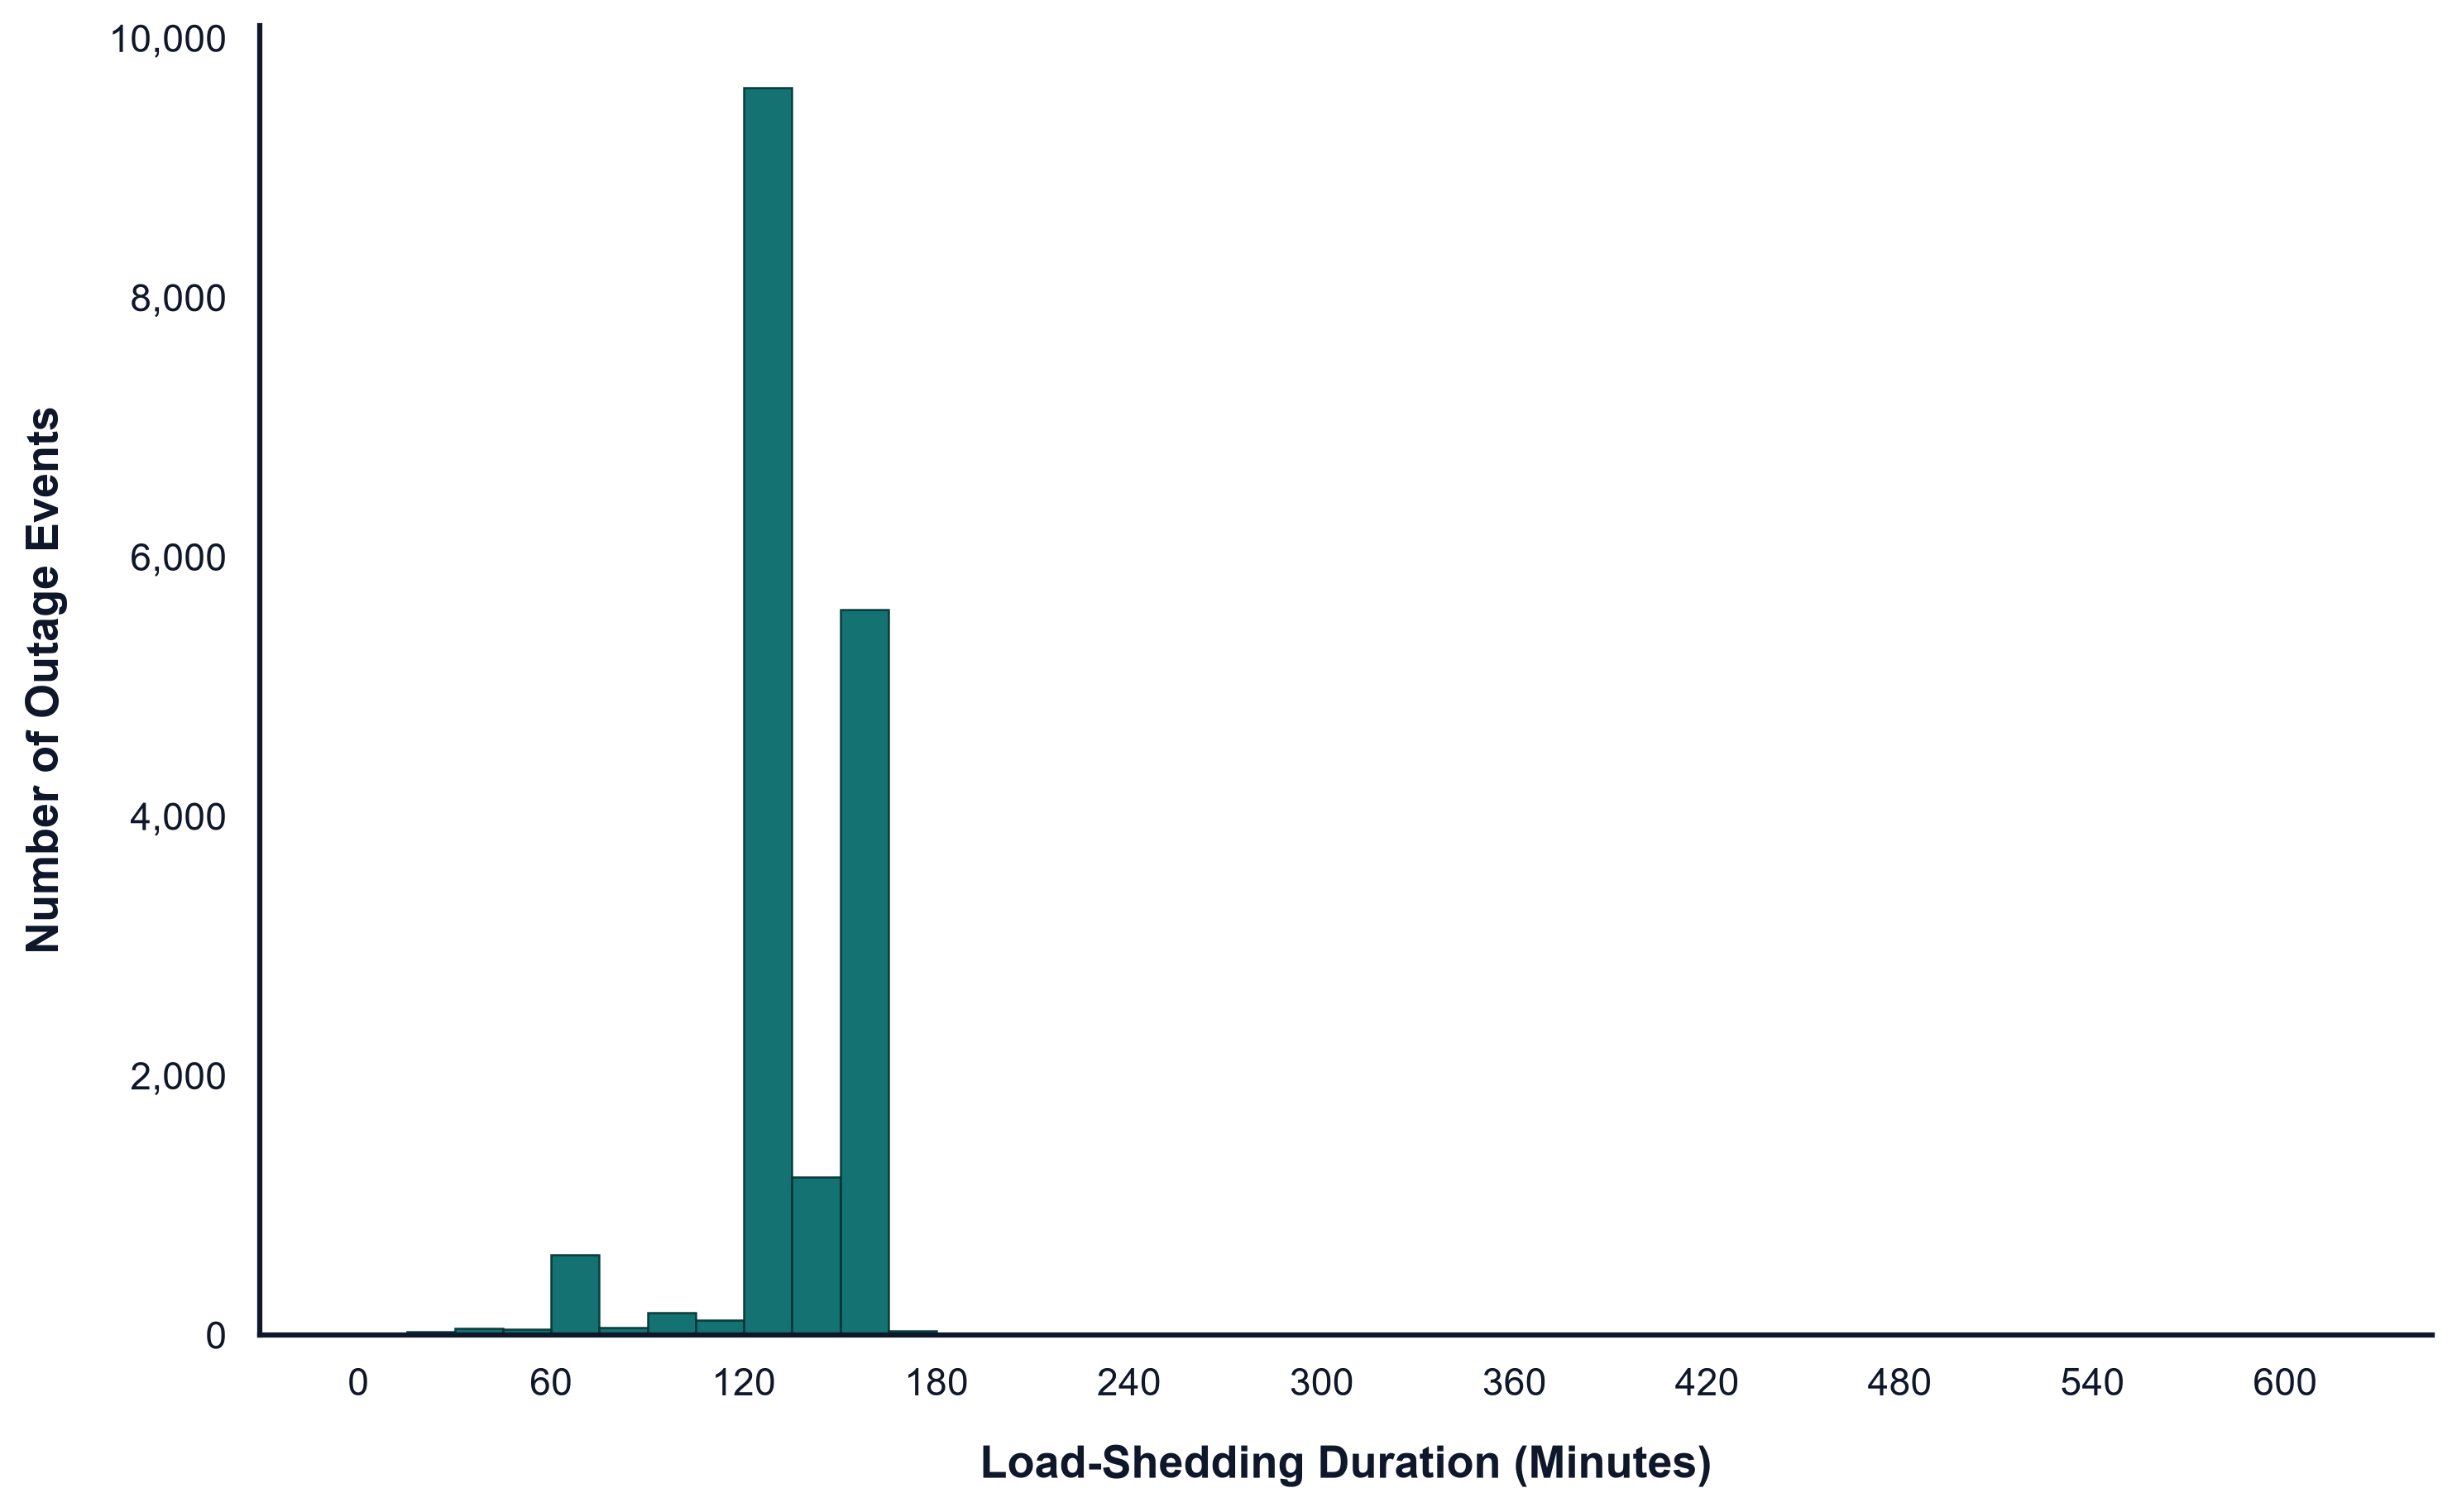

In [45]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

# ------------------------------------------------------------------------------
# 1. DATA PREPARATION
# ------------------------------------------------------------------------------
LOADSHED_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\Loadshedding_schedule.csv"

ls_raw = pd.read_csv(LOADSHED_FILE, dtype=str)
ls_raw["_date"] = pd.to_datetime(ls_raw["Date"], errors="coerce")
ls = ls_raw.dropna(subset=["_date"]).copy()

ls["_minutes"] = pd.to_numeric(ls["Minutes"], errors="coerce")
ls["_hour"] = pd.to_datetime(ls["Time"], errors="coerce").dt.hour
ls["_month"] = ls["_date"].dt.month
ls["_year"] = ls["_date"].dt.year

print(f"Rows: {len(ls):,}")
print(f"_minutes not null: {ls['_minutes'].notna().sum():,}")
print(ls["_minutes"].describe())

# ------------------------------------------------------------------------------
# 2. GLOBAL TYPOGRAPHY & STYLING (ARIAL)
# ------------------------------------------------------------------------------
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.edgecolor"] = "#0f172a"  # Deep dark slate for visible borders
plt.rcParams["axes.linewidth"] = 1.5

# Sized for A4 manuscript layout (10in x 6.2in maintains clean proportions)
fig, ax = plt.subplots(figsize=(10, 6.2), dpi=300)

# ------------------------------------------------------------------------------
# 3. HISTOGRAM PLOTTING & STYLING
# ------------------------------------------------------------------------------
# 15-minute bins matching Figures 4.1–4.6 palette
bins = range(0, 620, 15)

n, bins, patches = ax.hist(
    ls["_minutes"].dropna(),
    bins=bins,
    color="#006666",        # Deep teal
    edgecolor="#003333",    # Darker teal border for distinction
    linewidth=0.6,
    alpha=0.92,
)

# Explicitly remove gridlines
ax.grid(False)

# Remove top and right spines (keep deep left and bottom borders only)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#0f172a")
ax.spines["bottom"].set_color("#0f172a")

# ------------------------------------------------------------------------------
# 4. AXIS LABELS & READABLE TICKS
# ------------------------------------------------------------------------------
ax.set_xlabel(
    "Load-Shedding Duration (Minutes)",
    fontsize=13,
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)
ax.set_ylabel(
    "Number of Outage Events",
    fontsize=13,
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)

# Format X-axis with 60-minute tick steps for clear hourly mapping
ax.set_xticks(range(0, 660, 60))

# Format Y-axis with comma separators
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"{int(x):,}"))

# Tick mark styling
ax.tick_params(
    axis="both",
    which="major",
    labelsize=11,
    colors="#0f172a",
    width=1.5,
    length=6,
    direction="out",
)

# Minor ticks on Y-axis for frequency precision
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.tick_params(axis="y", which="minor", width=1.0, length=3, colors="#0f172a")

plt.tight_layout()
plt.show()

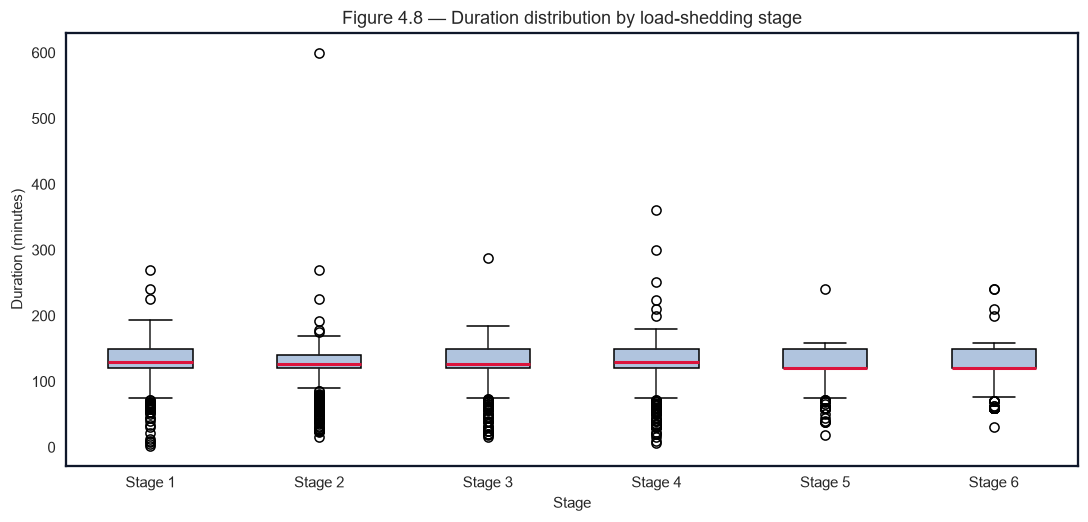

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

LOADSHED_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\Loadshedding_schedule.csv"

ls_raw = pd.read_csv(LOADSHED_FILE, dtype=str)
ls_raw["_date"] = pd.to_datetime(ls_raw["Date"], errors="coerce")
ls = ls_raw.dropna(subset=["_date"]).copy()
ls["_minutes"] = pd.to_numeric(ls["Minutes"], errors="coerce")

STAGE = "Stage"

fig, ax = plt.subplots(figsize=(10, 5))
ls.boxplot(column="_minutes", by=STAGE, ax=ax, grid=False,
           patch_artist=True,
           boxprops=dict(facecolor="lightsteelblue", color="black"),
           medianprops=dict(color="crimson", linewidth=2))
ax.set_title("Figure 4.8 — Duration distribution by load-shedding stage")
ax.set_xlabel("Stage")
ax.set_ylabel("Duration (minutes)")
plt.suptitle("")
plt.tight_layout()
plt.show()

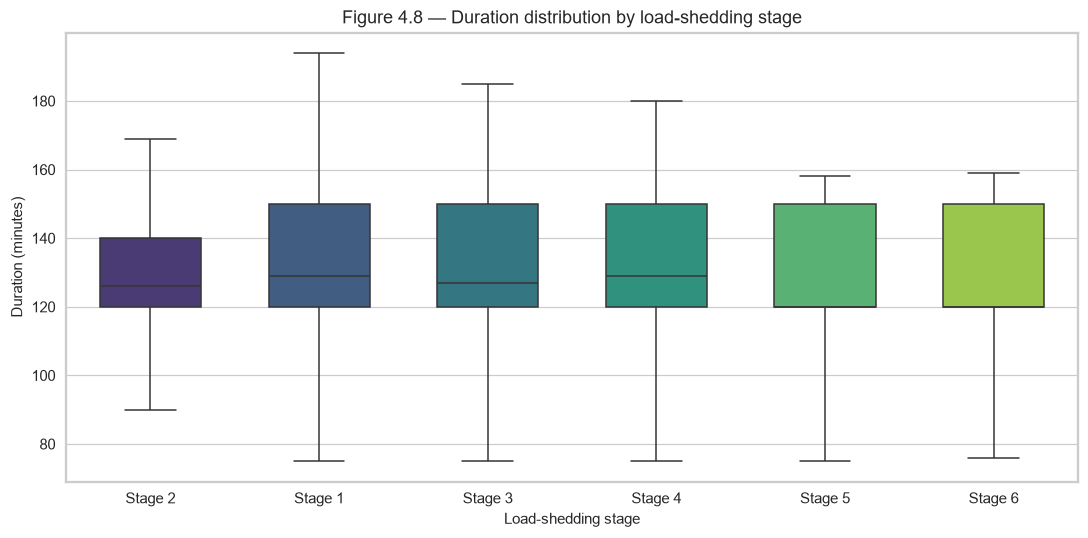

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

LOADSHED_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\Loadshedding_schedule.csv"

ls_raw = pd.read_csv(LOADSHED_FILE, dtype=str)
ls_raw["_date"] = pd.to_datetime(ls_raw["Date"], errors="coerce")
ls = ls_raw.dropna(subset=["_date"]).copy()
ls["_minutes"] = pd.to_numeric(ls["Minutes"], errors="coerce")

STAGE = "Stage"

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=ls, x=STAGE, y="_minutes", ax=ax,
            palette="viridis", showfliers=False, width=0.6)
ax.set_title("Figure 4.8 — Duration distribution by load-shedding stage")
ax.set_xlabel("Load-shedding stage")
ax.set_ylabel("Duration (minutes)")
plt.tight_layout()
plt.show()

Total valid rows for boxplot: 17,574
Stage breakdown:
 _stage_clean
1    1591
2    3438
3    3968
4    4525
5    1825
6    2227
Name: count, dtype: int64


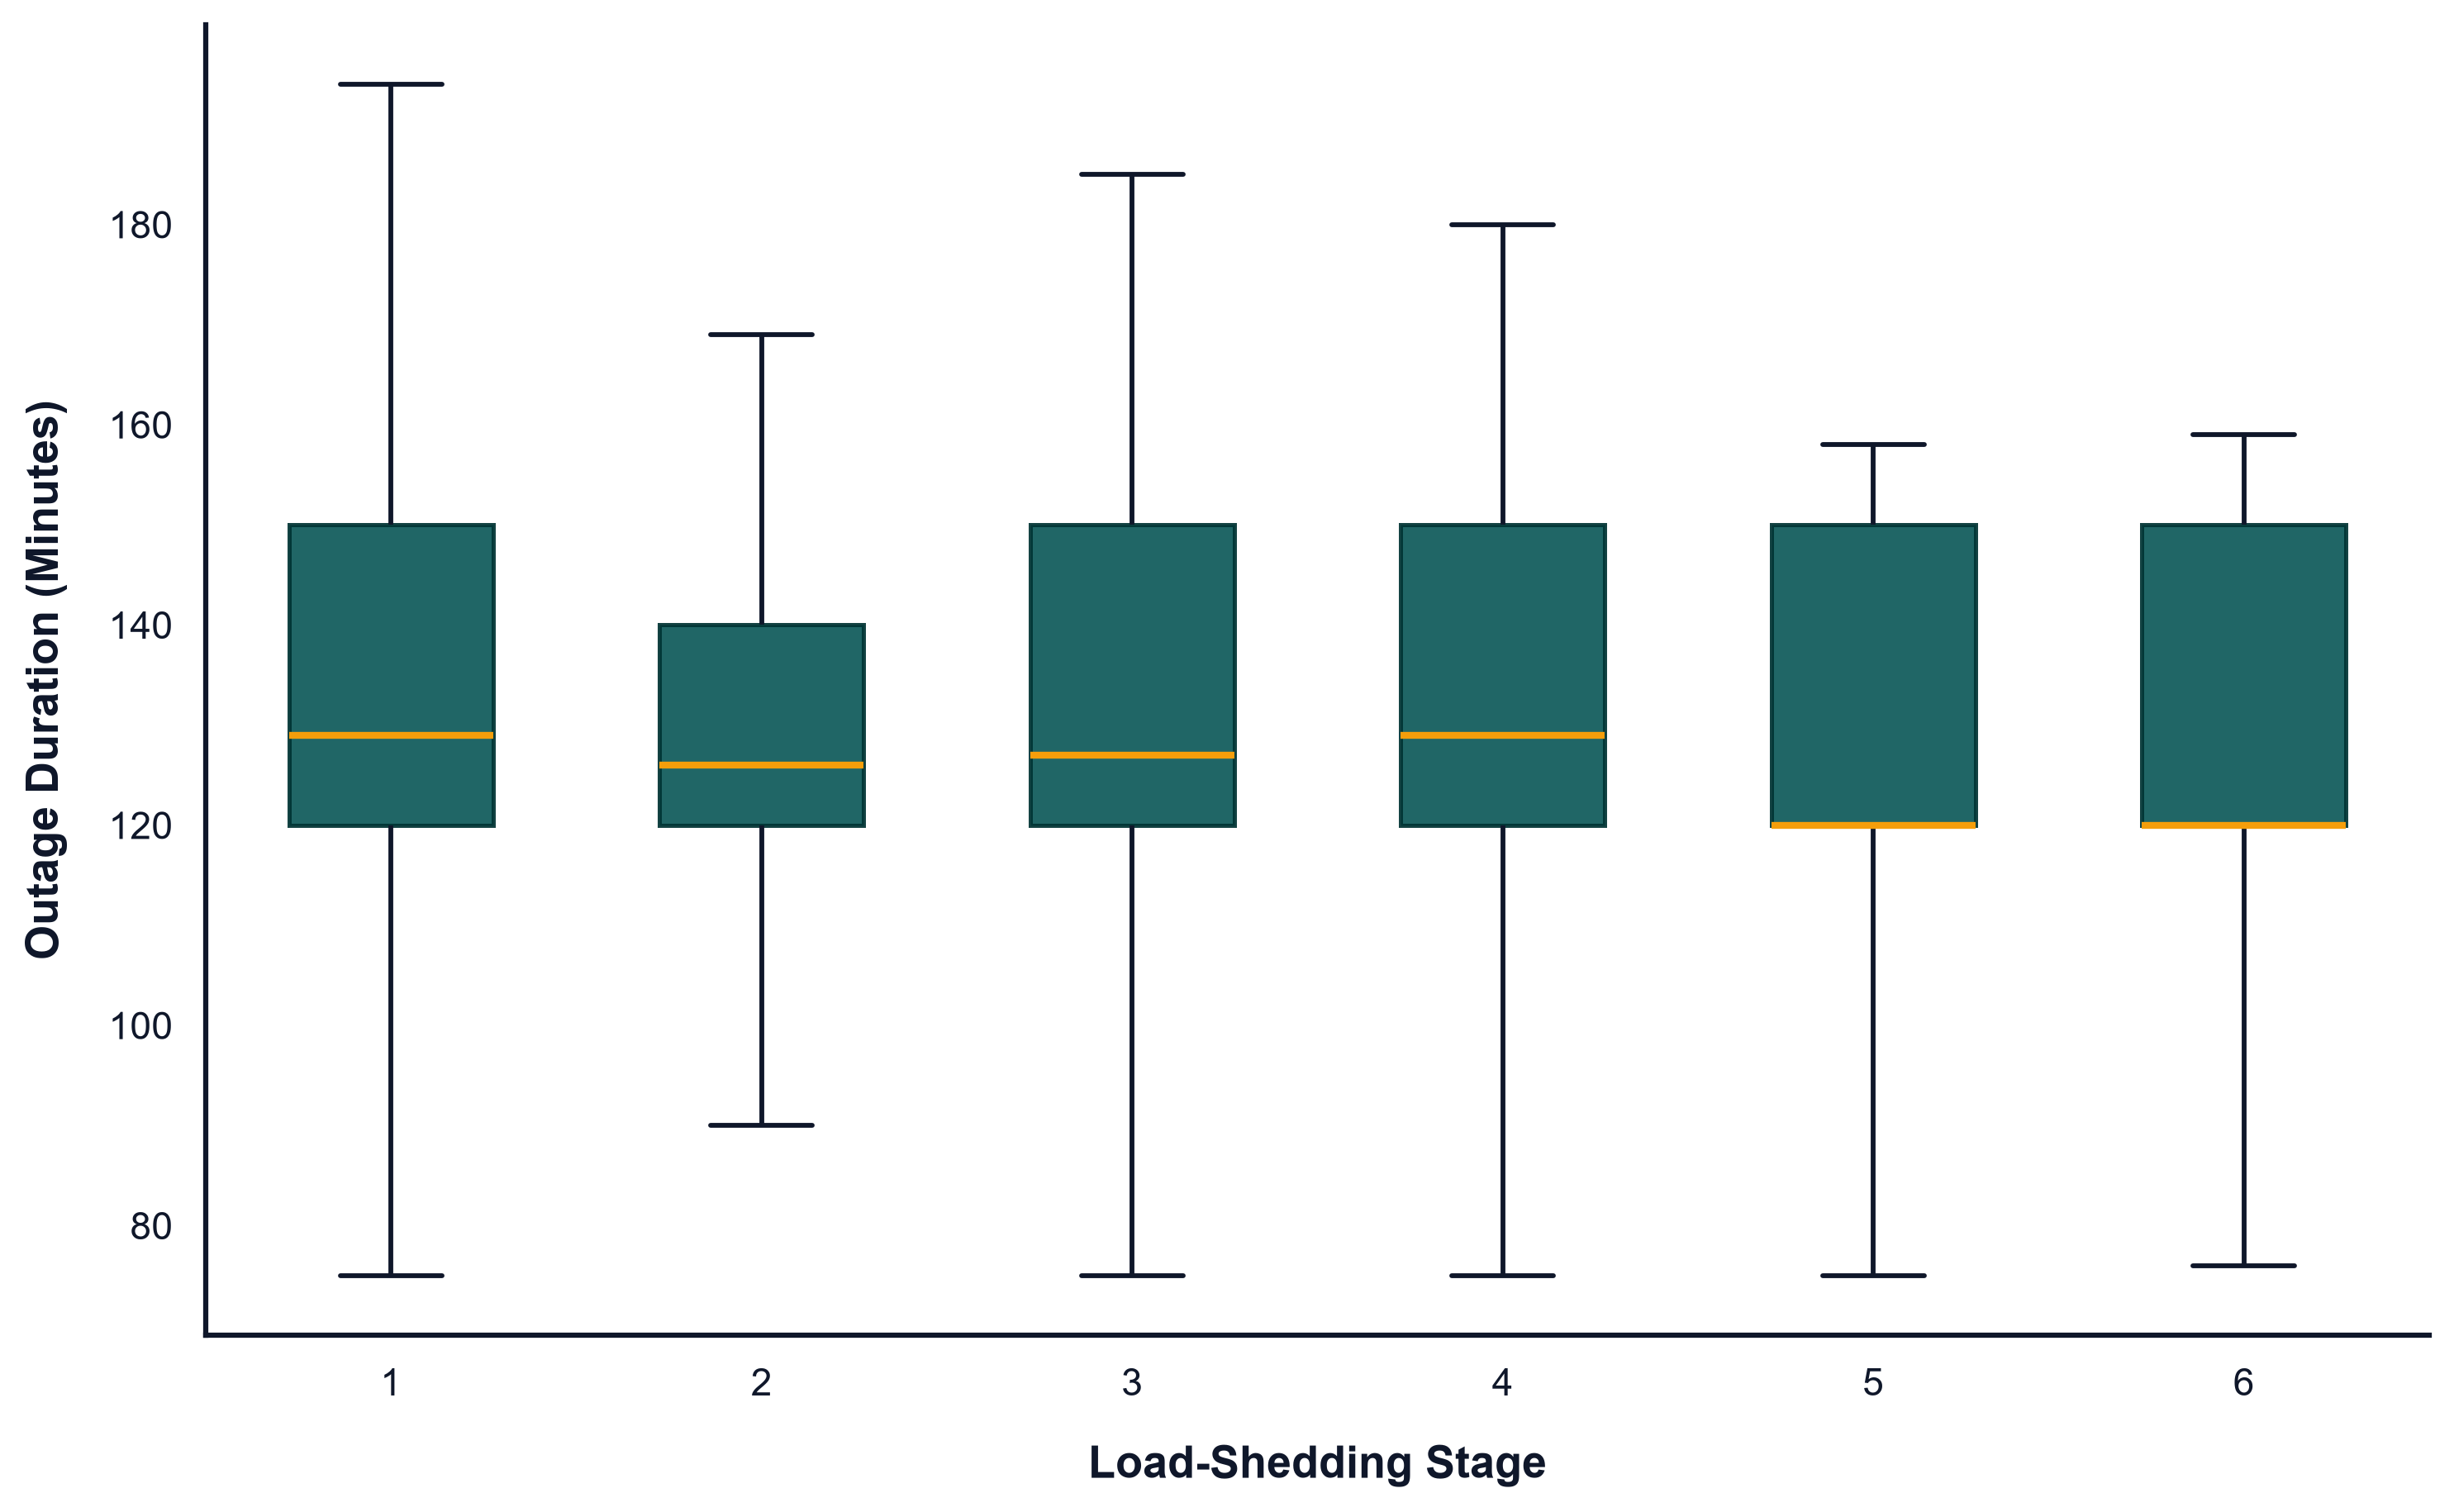

In [50]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns

# ------------------------------------------------------------------------------
# 1. DATA PREPARATION & ROBUST PARSING
# ------------------------------------------------------------------------------
LOADSHED_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\Loadshedding_schedule.csv"

ls_raw = pd.read_csv(LOADSHED_FILE, dtype=str)
ls_raw["_date"] = pd.to_datetime(ls_raw["Date"], errors="coerce")
ls = ls_raw.dropna(subset=["_date"]).copy()

# Parse duration minutes
ls["_minutes"] = pd.to_numeric(ls["Minutes"], errors="coerce")

# Robust Stage parsing: extract digits even if strings like "Stage 1" or "1.0" exist
STAGE_COL = "Stage" if "Stage" in ls.columns else "stage"

ls["_stage_clean"] = (
    ls[STAGE_COL]
    .astype(str)
    .str.extract(r"(\d+)")  # Extract numeric digits
    .iloc[:, 0]
)
ls["_stage_clean"] = pd.to_numeric(ls["_stage_clean"], errors="coerce")

# Filter out rows missing duration or stage
plot_df = ls.dropna(subset=["_stage_clean", "_minutes"]).copy()
plot_df["_stage_clean"] = plot_df["_stage_clean"].astype(int)

# Verify data presence in console
print(f"Total valid rows for boxplot: {len(plot_df):,}")
print("Stage breakdown:\n", plot_df["_stage_clean"].value_counts().sort_index())

# ------------------------------------------------------------------------------
# 2. GLOBAL TYPOGRAPHY & STYLING (ARIAL)
# ------------------------------------------------------------------------------
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.edgecolor"] = "#0f172a"  # Deep dark slate for visible borders
plt.rcParams["axes.linewidth"] = 1.5

# Sized for A4 manuscript layout
fig, ax = plt.subplots(figsize=(10, 6.2), dpi=300)

# ------------------------------------------------------------------------------
# 3. BOXPLOT PLOTTING
# ------------------------------------------------------------------------------
sns.boxplot(
    data=plot_df,
    x="_stage_clean",
    y="_minutes",
    ax=ax,
    color="#006666",        # Deep teal fill
    showfliers=False,
    width=0.55,
    boxprops=dict(edgecolor="#003333", linewidth=1.2, alpha=0.92),
    whiskerprops=dict(color="#0f172a", linewidth=1.4),
    capprops=dict(color="#0f172a", linewidth=1.4),
    medianprops=dict(color="#f59e0b", linewidth=2.0),  # Amber gold median line
)

# Remove gridlines
ax.grid(False)

# Remove top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#0f172a")
ax.spines["bottom"].set_color("#0f172a")

# ------------------------------------------------------------------------------
# 4. AXIS LABELS & READABLE TICKS
# ------------------------------------------------------------------------------
ax.set_xlabel(
    "Load-Shedding Stage",
    fontsize=13,
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)
ax.set_ylabel(
    "Outage Duration (Minutes)",
    fontsize=13,
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)

# Format Y-axis with comma separators
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"{int(x):,}"))

# Tick mark styling
ax.tick_params(
    axis="both",
    which="major",
    labelsize=11,
    colors="#0f172a",
    width=1.5,
    length=6,
    direction="out",
)

# Minor ticks on Y-axis
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.tick_params(axis="y", which="minor", width=1.0, length=3, colors="#0f172a")

plt.tight_layout()
plt.show()

Historical n = 17,574
Simulated  n = 1,570,000

Historical: {'n': 17574, 'mean': np.float64(129.09599408216684), 'median': np.float64(125.0), 'sd': np.float64(21.458508700017195), 'q25': np.float64(120.0), 'q75': np.float64(150.0), 'min': np.float64(2.0), 'max': np.float64(600.0)}
Simulated : {'n': 1570000, 'mean': np.float64(129.93458917197452), 'median': np.float64(129.0), 'sd': np.float64(21.167412186160703), 'q25': np.float64(120.0), 'q75': np.float64(150.0), 'min': np.float64(8.0), 'max': np.float64(300.0)}

Mean difference: 0.8386 minutes


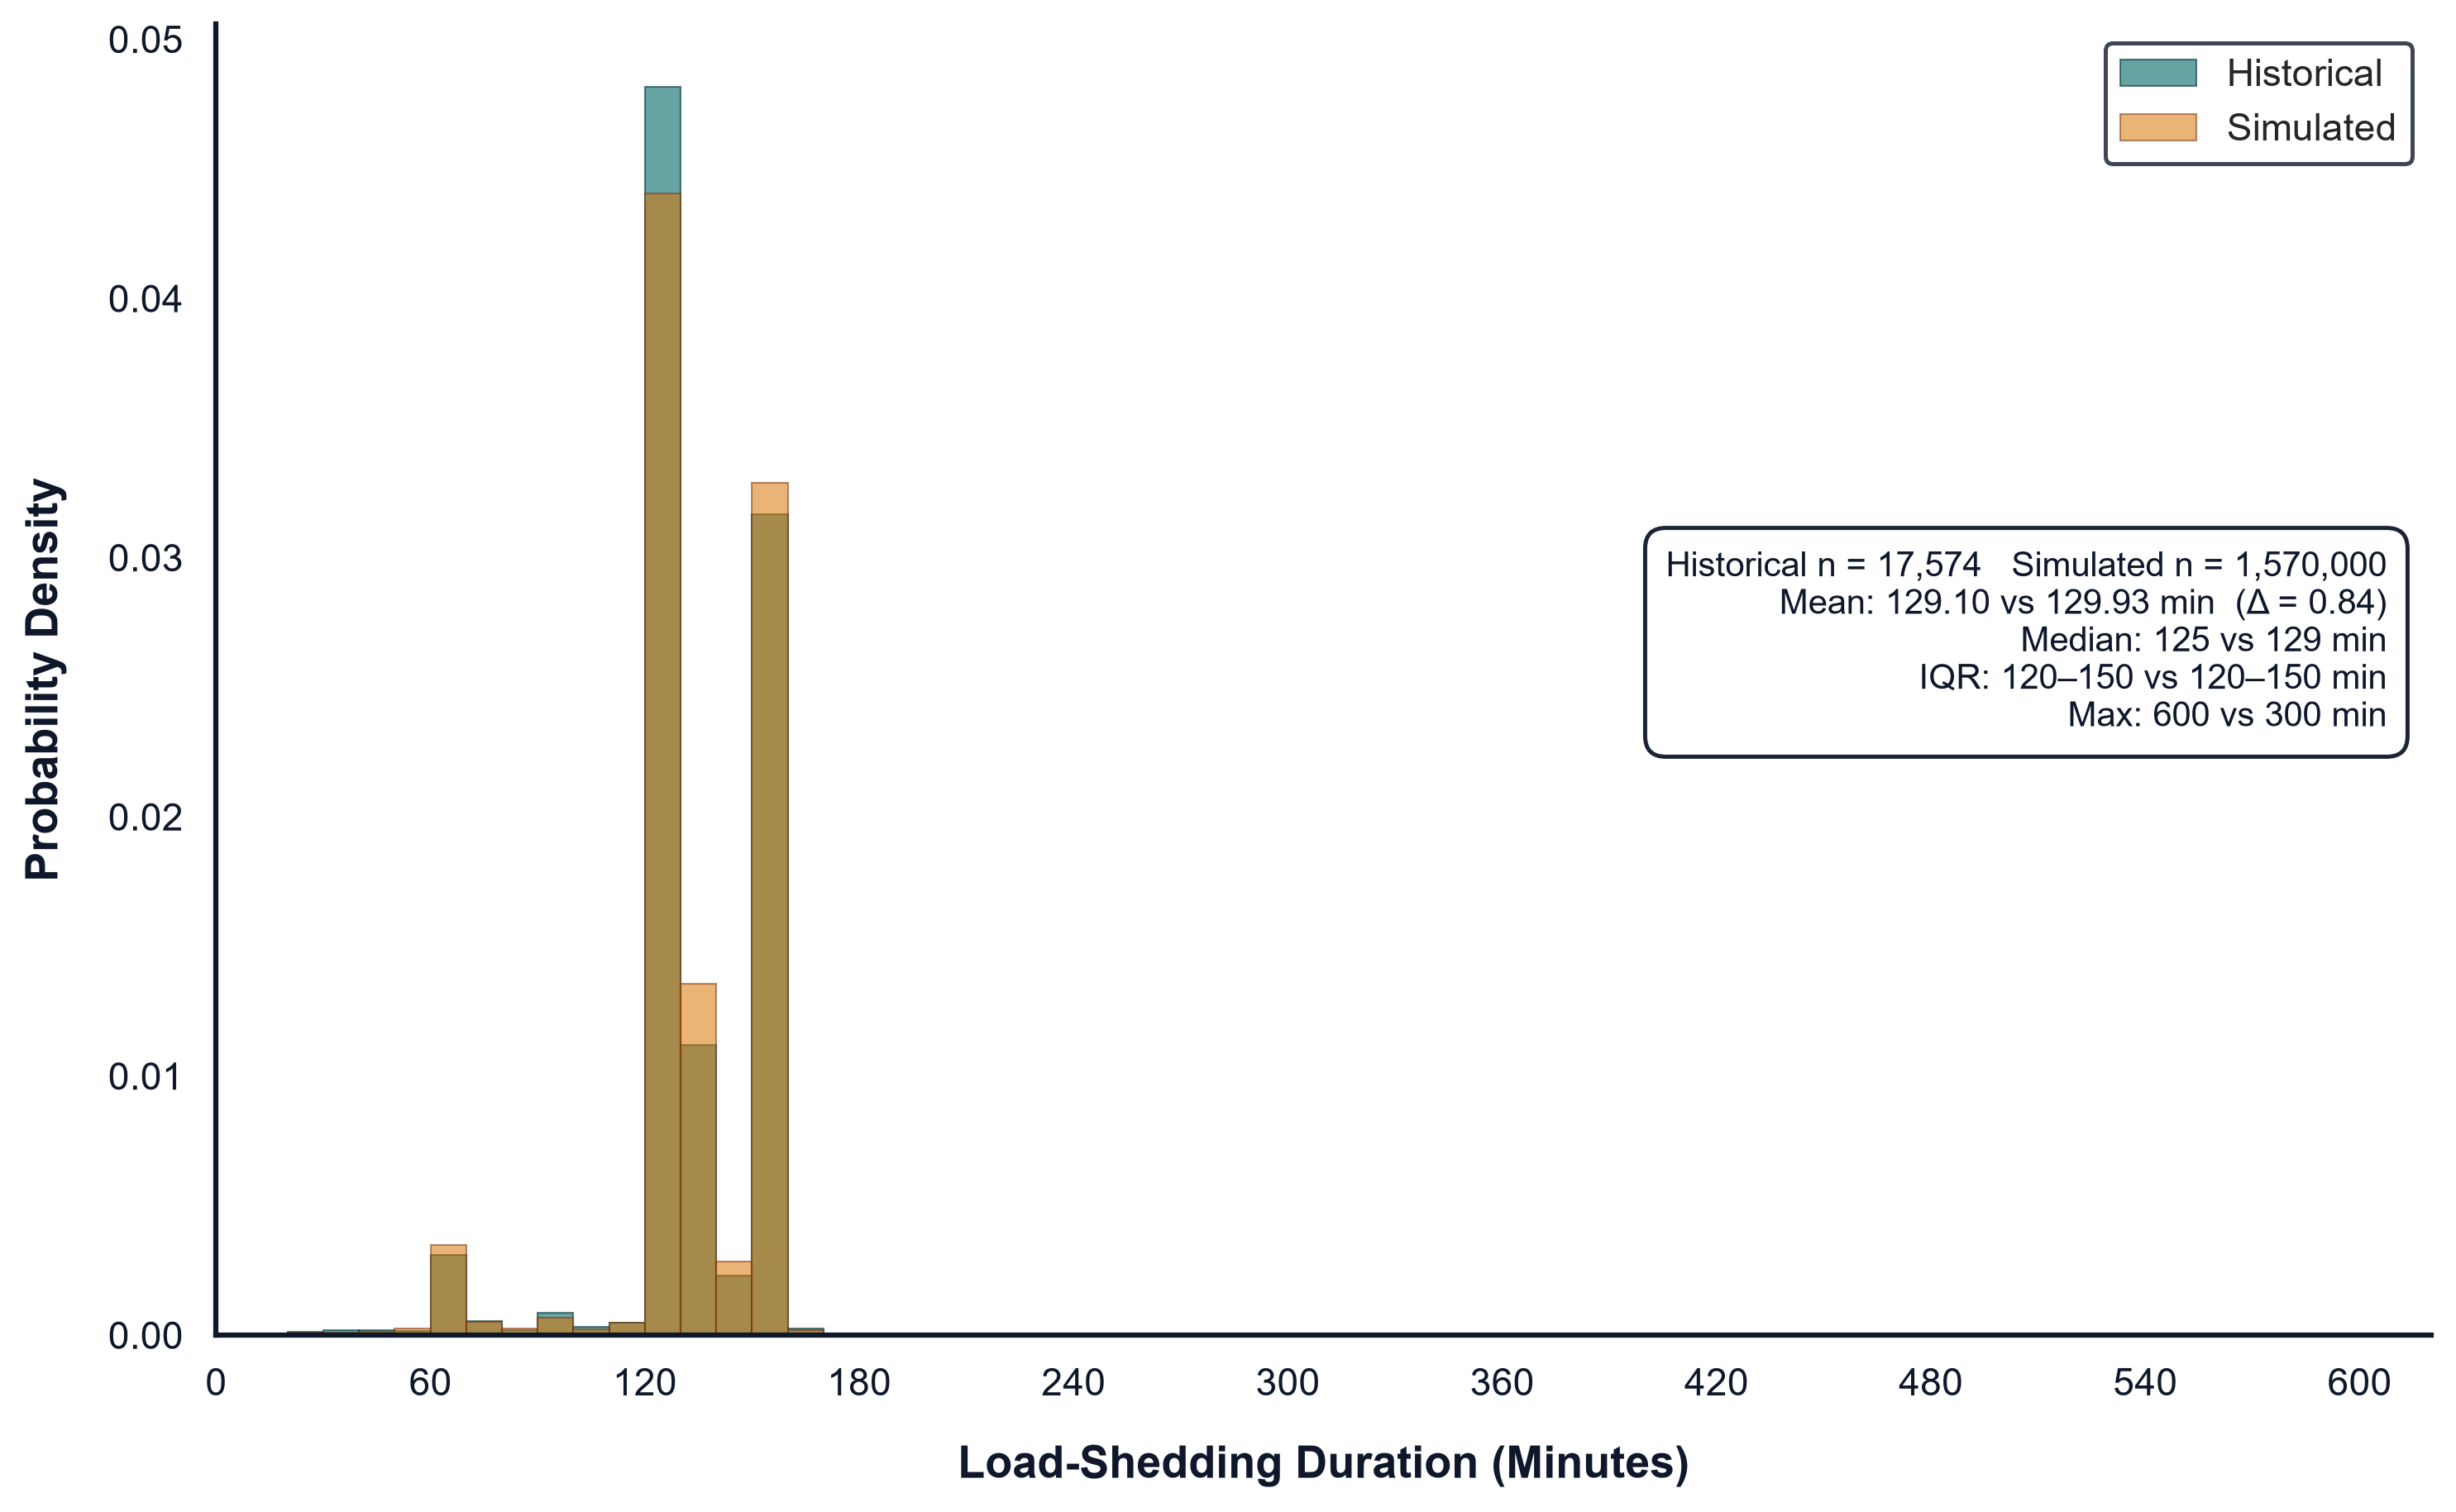

In [52]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

# ------------------------------------------------------------------------------
# 1. DATA EXTRACTION & SUMMARY COMPUTATION
# ------------------------------------------------------------------------------
historical = pd.to_numeric(ls["_minutes"], errors="coerce").dropna().values
simulated = pd.to_numeric(sim["duration_min"], errors="coerce").dropna().values

print(f"Historical n = {len(historical):,}")
print(f"Simulated  n = {len(simulated):,}")

def describe(x):
    return {
        "n": len(x),
        "mean": np.mean(x),
        "median": np.median(x),
        "sd": np.std(x, ddof=1),
        "q25": np.percentile(x, 25),
        "q75": np.percentile(x, 75),
        "min": np.min(x),
        "max": np.max(x),
    }

h = describe(historical)
s = describe(simulated)

print("\nHistorical:", h)
print("Simulated :", s)
print(f"\nMean difference: {abs(h['mean'] - s['mean']):.4f} minutes")

# ------------------------------------------------------------------------------
# 2. GLOBAL TYPOGRAPHY & STYLING (ARIAL)
# ------------------------------------------------------------------------------
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.edgecolor"] = "#0f172a"  # Deep dark slate for visible borders
plt.rcParams["axes.linewidth"] = 1.5

# Sized for A4 manuscript layout (10in x 6.2in maintains clean proportions)
fig, ax = plt.subplots(figsize=(10, 6.2), dpi=300)

# ------------------------------------------------------------------------------
# 3. HISTOGRAM OVERLAY PLOTTING
# ------------------------------------------------------------------------------
bins = np.arange(0, 620, 10)

# Historical (Deep Teal / Dark Slate theme)
ax.hist(
    historical,
    bins=bins,
    density=True,
    alpha=0.60,
    color="#006666",
    label="Historical",
    edgecolor="#003333",
    linewidth=0.5,
)

# Simulated (Warm Coral / Amber distinction)
ax.hist(
    simulated,
    bins=bins,
    density=True,
    alpha=0.55,
    color="#d97706",
    label="Simulated",
    edgecolor="#78350f",
    linewidth=0.5,
)

# Explicitly remove gridlines
ax.grid(False)

# Remove top and right spines (keep deep left and bottom borders only)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#0f172a")
ax.spines["bottom"].set_color("#0f172a")

# ------------------------------------------------------------------------------
# 4. AXIS LABELS & TICKS
# ------------------------------------------------------------------------------
ax.set_xlabel(
    "Load-Shedding Duration (Minutes)",
    fontsize=13,
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)
ax.set_ylabel(
    "Probability Density",
    fontsize=13,
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)

ax.set_xlim(0, 620)
ax.set_xticks(range(0, 660, 60))

# Tick mark styling
ax.tick_params(
    axis="both",
    which="major",
    labelsize=11,
    colors="#0f172a",
    width=1.5,
    length=6,
    direction="out",
)

# Minor ticks on Y-axis for density precision
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.tick_params(axis="y", which="minor", width=1.0, length=3, colors="#0f172a")

# ------------------------------------------------------------------------------
# 5. LEGEND & STATISTICAL COMPARISON ANNOTATION
# ------------------------------------------------------------------------------
legend = ax.legend(
    loc="upper right",
    frameon=True,
    fontsize=11,
    facecolor="#ffffff",
    edgecolor="#0f172a",
)
legend.get_frame().set_linewidth(1.2)

text = (
    f"Historical n = {h['n']:,}   Simulated n = {s['n']:,}\n"
    f"Mean: {h['mean']:.2f} vs {s['mean']:.2f} min  (Δ = {abs(h['mean']-s['mean']):.2f})\n"
    f"Median: {h['median']:.0f} vs {s['median']:.0f} min\n"
    f"IQR: {h['q25']:.0f}–{h['q75']:.0f} vs {s['q25']:.0f}–{s['q75']:.0f} min\n"
    f"Max: {h['max']:.0f} vs {s['max']:.0f} min"
)

ax.text(
    0.98,
    0.60,
    text,
    transform=ax.transAxes,
    fontsize=10,
    family="Arial",
    ha="right",
    va="top",
    color="#0f172a",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="#ffffff",
        edgecolor="#0f172a",
        linewidth=1.2,
        alpha=0.95,
    ),
)

plt.tight_layout()
plt.show()

Facilities with positive hourly rate: 314
Historical durations available: 17,574

Facilities                     : 314
Overall mean resilience        : 0.910361
Overall mean vulnerability     : 0.089639
Range (max - min) of ER_mean   : 0.001131
Standard deviation of ER_mean  : 0.000200
Minimum facility ER_mean       : 0.909773
Maximum facility ER_mean       : 0.910904


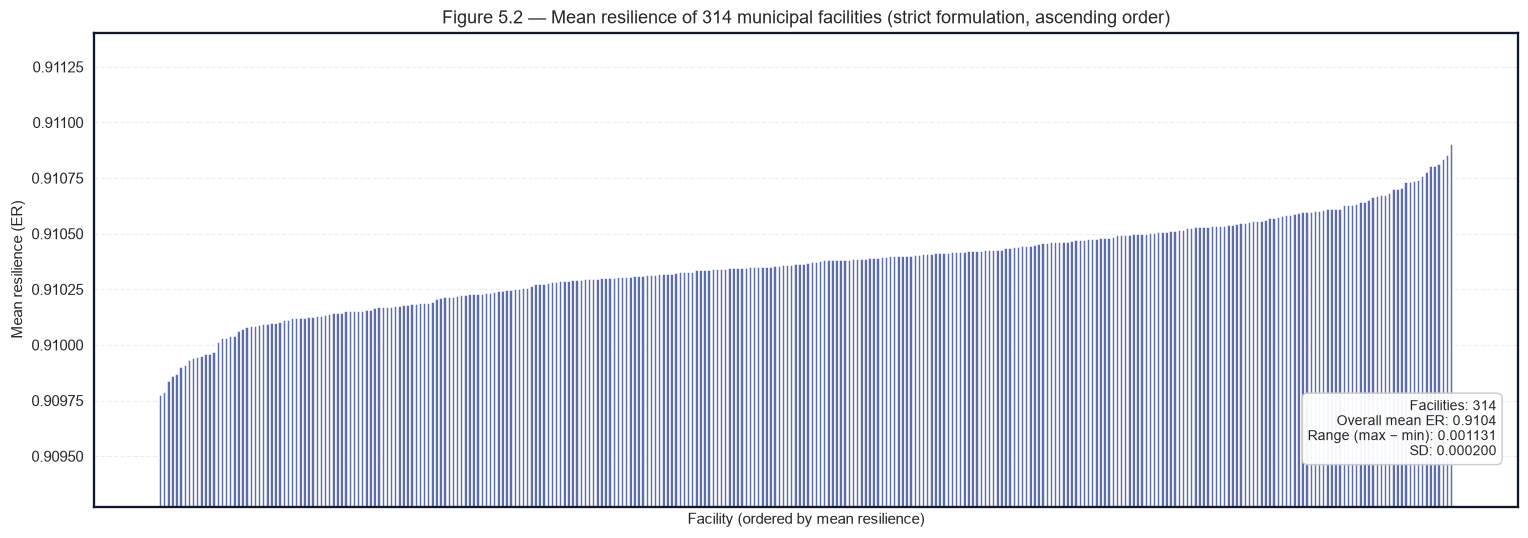

In [53]:
"""
Figure 5.2 — Simulated mean facility resilience across the portfolio (strict formulation)
Self-contained. Reads the facility file, computes hourly demand, samples
historical load-shedding durations, and computes strict-formulation resilience
per facility. Matches the main pipeline's logic at the level needed for this figure.

Requires: pandas, numpy, matplotlib, openpyxl
"""

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------------------
FACILITY_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\SmartFacility_Energy_FullNames.xlsx"
LOADSHED_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\Loadshedding_schedule.csv"
SEED = 42
N_SIM = 5000

np.random.seed(SEED)

# ------------------------------------------------------------------------------
# 1. LOAD FACILITY DATA
# ------------------------------------------------------------------------------
if not os.path.exists(FACILITY_FILE):
    sys.exit(f"[FATAL] Not found: {FACILITY_FILE}")

fac = pd.read_excel(FACILITY_FILE)

def find_col(df, *cands, required=True):
    lower = {c.lower().strip(): c for c in df.columns}
    for c in cands:
        if c.lower().strip() in lower:
            return lower[c.lower().strip()]
    if required:
        raise KeyError(f"Column not found: {cands}")
    return None

c_lis   = find_col(fac, "LIS Key")
c_mcons = find_col(fac, "Monthly Electricity Consumption", required=False)

fac = fac.dropna(subset=[c_lis]).copy()
fac[c_mcons] = pd.to_numeric(fac[c_mcons], errors="coerce")

# Mean monthly consumption per facility
agg = fac.groupby(c_lis)[c_mcons].mean().rename("mean_cons")
agg = agg[agg > 0]                      # drop non-positive
agg = agg.to_frame()

# Hourly rate
agg["hourly_rate"] = agg["mean_cons"] / 730.0

print(f"Facilities with positive hourly rate: {len(agg)}")

# ------------------------------------------------------------------------------
# 2. LOAD HISTORICAL LOAD-SHEDDING DURATIONS
# ------------------------------------------------------------------------------
if not os.path.exists(LOADSHED_FILE):
    sys.exit(f"[FATAL] Not found: {LOADSHED_FILE}")

ls = pd.read_csv(LOADSHED_FILE)

dur_col = None
for cand in ["Minutes", "Duration", "minutes", "duration"]:
    if cand in ls.columns:
        dur_col = cand
        break
if dur_col is None:
    sys.exit(f"[FATAL] No duration column in {list(ls.columns)}")

durations = pd.to_numeric(ls[dur_col], errors="coerce").dropna().values
durations = durations[durations > 0]
print(f"Historical durations available: {len(durations):,}")

# ------------------------------------------------------------------------------
# 3. STRICT-FORMULATION RESILIENCE PER FACILITY
# ------------------------------------------------------------------------------
# NES = d_s (hours) / 24.  ER = 1 - NES.
# Because the facility rate cancels, we can compute this once for the sampled
# duration distribution and reuse it across facilities — that is exactly the
# point the figure is making. But we still compute per-facility means so the
# resulting series reflects the pipeline's structure.

duration_samples_h = durations / 60.0          # minutes -> hours

per_facility = {}
for fid in agg.index:
    # Sample 5,000 durations with replacement
    s = np.random.choice(duration_samples_h, size=N_SIM, replace=True)
    nes = s / 24.0
    er = 1.0 - nes
    per_facility[fid] = er.mean()

er_series = pd.Series(per_facility).dropna()
er_sorted = er_series.sort_values()

# ------------------------------------------------------------------------------
# 4. SUMMARY STATISTICS
# ------------------------------------------------------------------------------
overall_mean = float(er_series.mean())
overall_sd   = float(er_series.std())
er_range     = float(er_series.max() - er_series.min())
vuln_mean    = 1.0 - overall_mean

print(f"\nFacilities                     : {len(er_series)}")
print(f"Overall mean resilience        : {overall_mean:.6f}")
print(f"Overall mean vulnerability     : {vuln_mean:.6f}")
print(f"Range (max - min) of ER_mean   : {er_range:.6f}")
print(f"Standard deviation of ER_mean  : {overall_sd:.6f}")
print(f"Minimum facility ER_mean       : {er_series.min():.6f}")
print(f"Maximum facility ER_mean       : {er_series.max():.6f}")

# ------------------------------------------------------------------------------
# 5. FIGURE 5.2
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(len(er_sorted))
ax.bar(x, er_sorted.values, color="#5b6cb5", width=0.85)

pad = 0.0005
ax.set_ylim(er_sorted.min() - pad, er_sorted.max() + pad)

ax.set_title(
    "Figure 5.2 — Mean resilience of 314 municipal facilities "
    "(strict formulation, ascending order)",
    fontsize=12
)
ax.set_xlabel("Facility (ordered by mean resilience)")
ax.set_ylabel("Mean resilience (ER)")

ax.set_xticks([])
ax.grid(axis="y", alpha=0.35, linestyle="--")

text = (
    f"Facilities: {len(er_sorted)}\n"
    f"Overall mean ER: {overall_mean:.4f}\n"
    f"Range (max − min): {er_range:.6f}\n"
    f"SD: {overall_sd:.6f}"
)
ax.text(0.985, 0.10, text,
        transform=ax.transAxes, fontsize=9,
        ha="right", va="bottom",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor="#cccccc", alpha=0.95))

plt.tight_layout()
plt.show()

Facilities with positive hourly rate: 314
Historical durations available: 17,574

Facilities                     : 314
Overall mean resilience        : 0.910361
Overall mean vulnerability     : 0.089639
Range (max - min) of ER_mean   : 0.001131
Standard deviation of ER_mean  : 0.000200
Minimum facility ER_mean       : 0.909773
Maximum facility ER_mean       : 0.910904


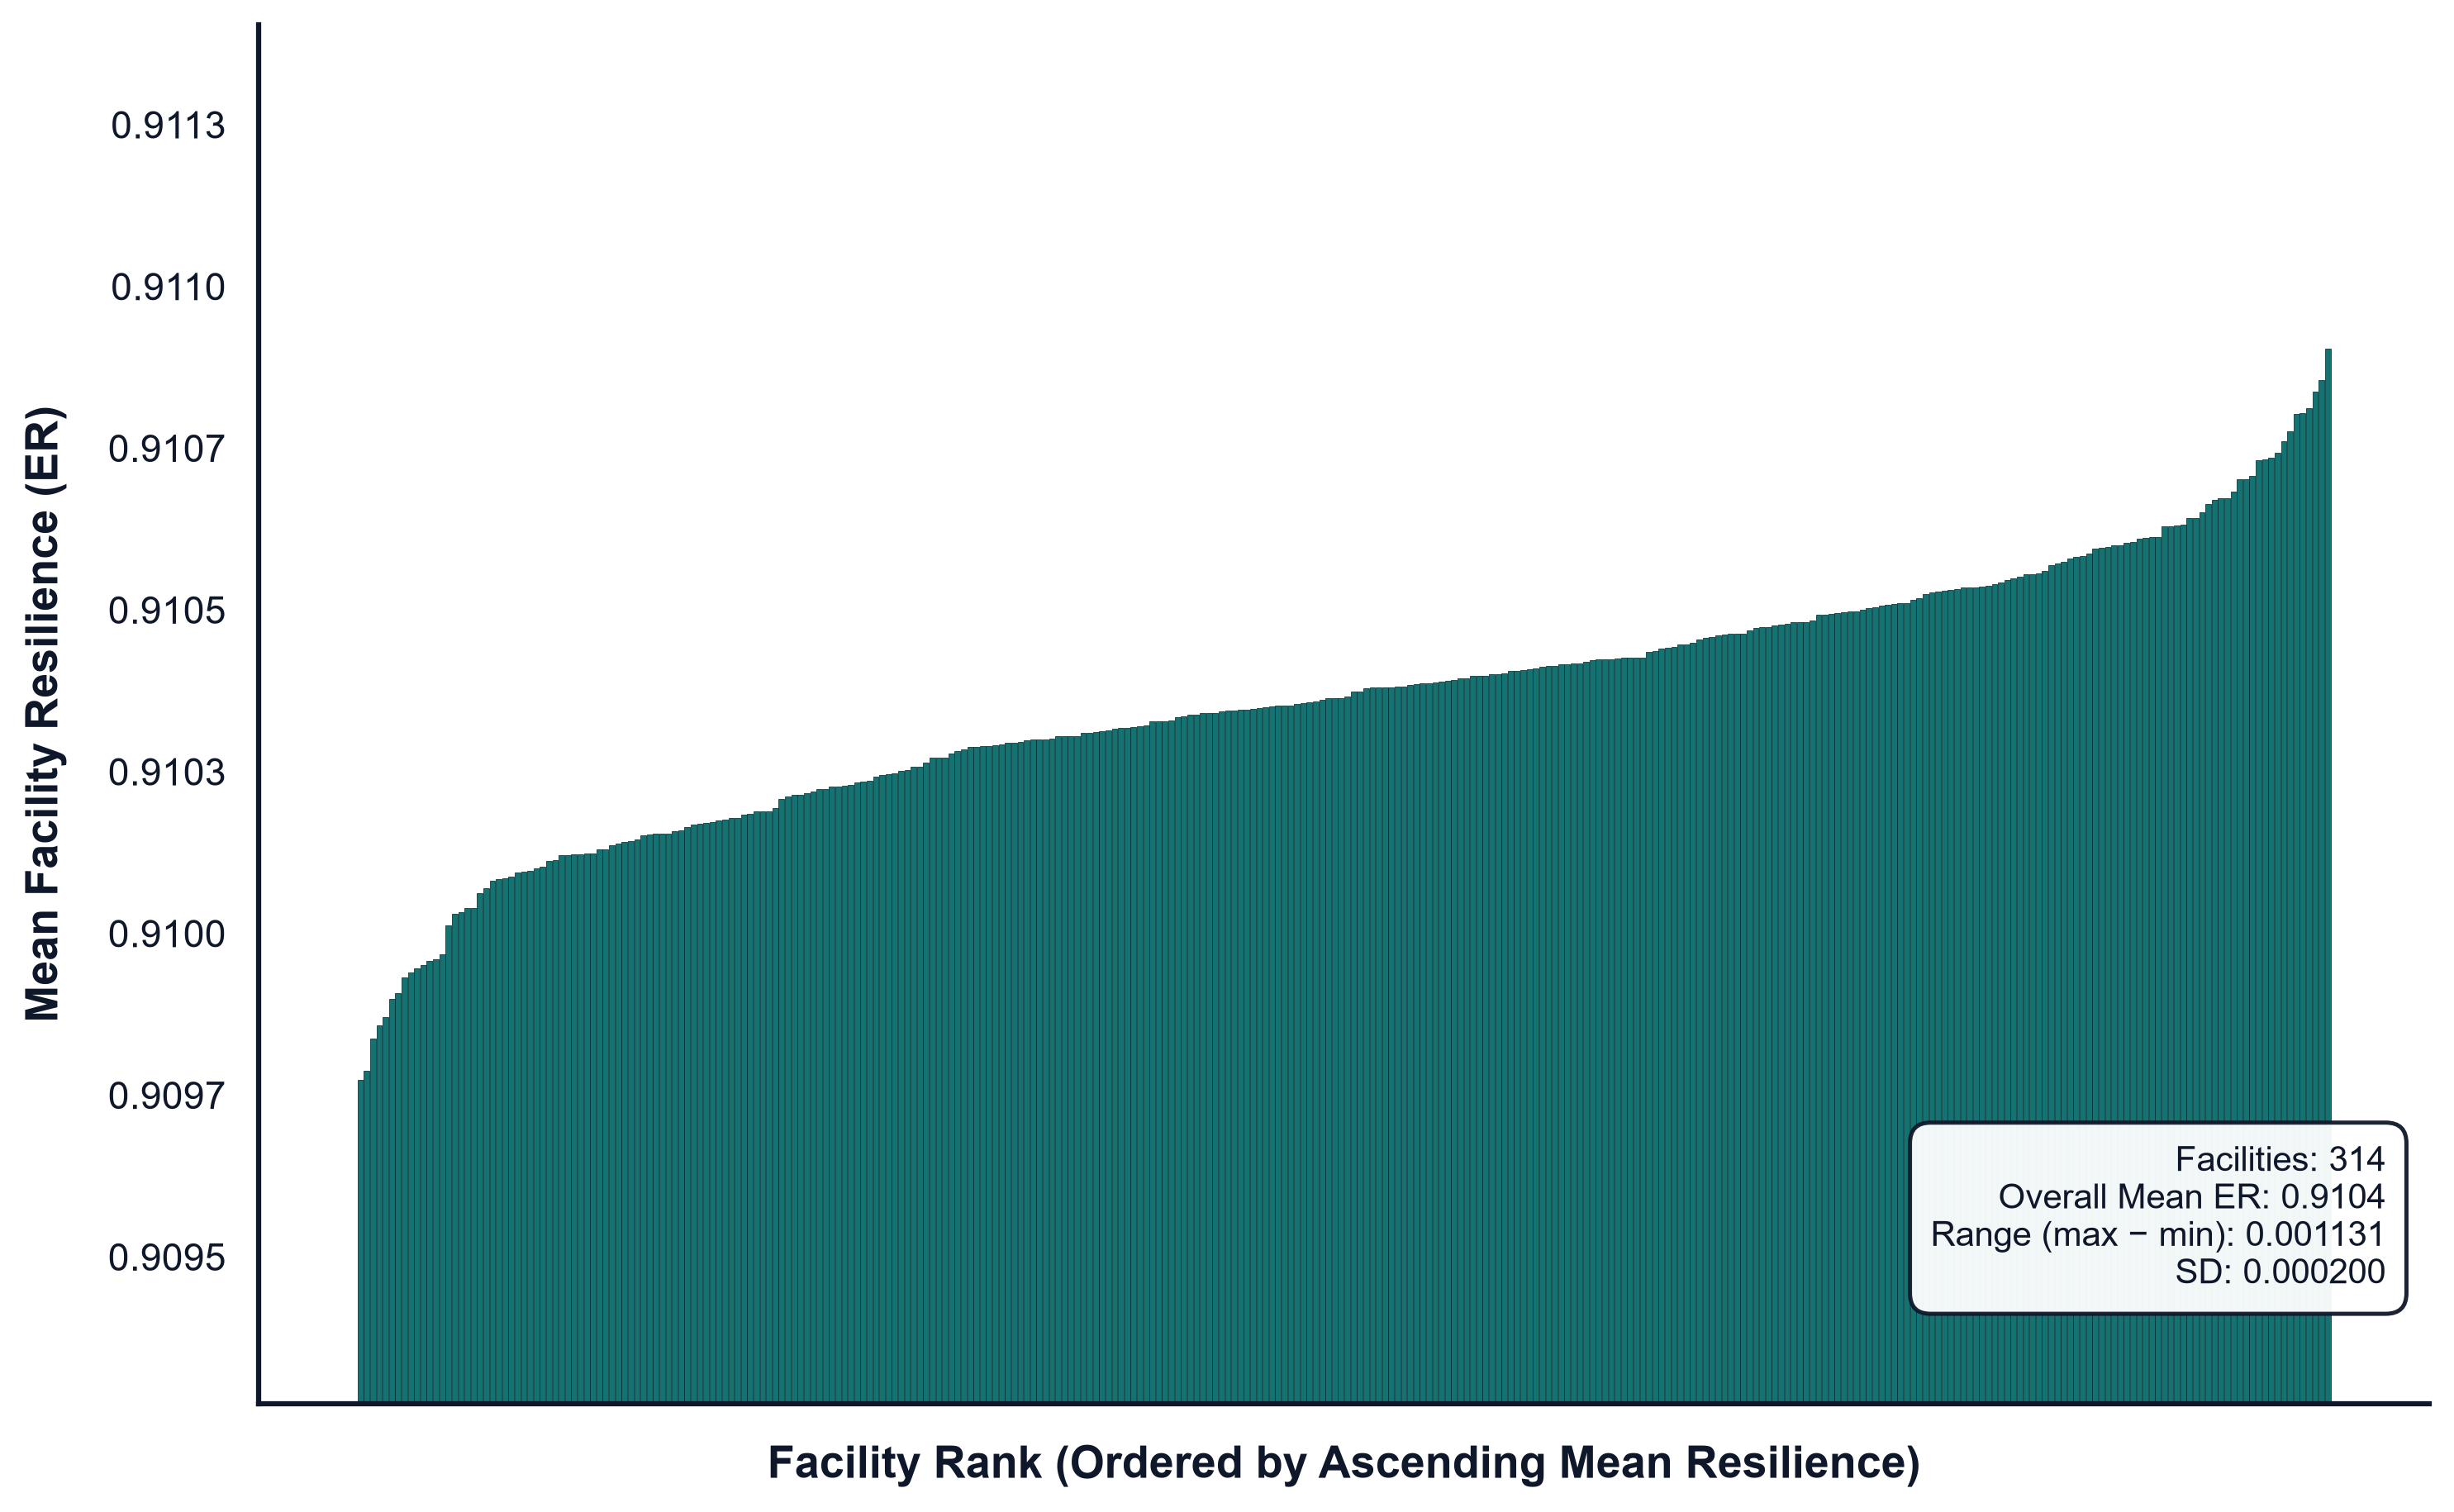

In [54]:
"""
Figure 5.2 — Simulated mean facility resilience across the portfolio (strict formulation)
Self-contained. Reads the facility file, computes hourly demand, samples
historical load-shedding durations, and computes strict-formulation resilience
per facility. Matches the main pipeline's logic at the level needed for this figure.

Requires: pandas, numpy, matplotlib, openpyxl
"""

import os
import sys
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

# ------------------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------------------
FACILITY_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\SmartFacility_Energy_FullNames.xlsx"
LOADSHED_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\Loadshedding_schedule.csv"
SEED = 42
N_SIM = 5000

np.random.seed(SEED)

# ------------------------------------------------------------------------------
# 1. LOAD FACILITY DATA
# ------------------------------------------------------------------------------
if not os.path.exists(FACILITY_FILE):
    sys.exit(f"[FATAL] Not found: {FACILITY_FILE}")

fac = pd.read_excel(FACILITY_FILE)

def find_col(df, *cands, required=True):
    lower = {c.lower().strip(): c for c in df.columns}
    for c in cands:
        if c.lower().strip() in lower:
            return lower[c.lower().strip()]
    if required:
        raise KeyError(f"Column not found: {cands}")
    return None

c_lis = find_col(fac, "LIS Key")
c_mcons = find_col(fac, "Monthly Electricity Consumption", required=False)

fac = fac.dropna(subset=[c_lis]).copy()
fac[c_mcons] = pd.to_numeric(fac[c_mcons], errors="coerce")

# Mean monthly consumption per facility
agg = fac.groupby(c_lis)[c_mcons].mean().rename("mean_cons")
agg = agg[agg > 0]                      # drop non-positive
agg = agg.to_frame()

# Hourly rate
agg["hourly_rate"] = agg["mean_cons"] / 730.0

print(f"Facilities with positive hourly rate: {len(agg)}")

# ------------------------------------------------------------------------------
# 2. LOAD HISTORICAL LOAD-SHEDDING DURATIONS
# ------------------------------------------------------------------------------
if not os.path.exists(LOADSHED_FILE):
    sys.exit(f"[FATAL] Not found: {LOADSHED_FILE}")

ls = pd.read_csv(LOADSHED_FILE)

dur_col = None
for cand in ["Minutes", "Duration", "minutes", "duration"]:
    if cand in ls.columns:
        dur_col = cand
        break
if dur_col is None:
    sys.exit(f"[FATAL] No duration column in {list(ls.columns)}")

durations = pd.to_numeric(ls[dur_col], errors="coerce").dropna().values
durations = durations[durations > 0]
print(f"Historical durations available: {len(durations):,}")

# ------------------------------------------------------------------------------
# 3. STRICT-FORMULATION RESILIENCE PER FACILITY
# ------------------------------------------------------------------------------
# NES = d_s (hours) / 24. ER = 1 - NES.
duration_samples_h = durations / 60.0          # minutes -> hours

per_facility = {}
for fid in agg.index:
    # Sample 5,000 durations with replacement
    s = np.random.choice(duration_samples_h, size=N_SIM, replace=True)
    nes = s / 24.0
    er = 1.0 - nes
    per_facility[fid] = er.mean()

er_series = pd.Series(per_facility).dropna()
er_sorted = er_series.sort_values()

# ------------------------------------------------------------------------------
# 4. SUMMARY STATISTICS
# ------------------------------------------------------------------------------
overall_mean = float(er_series.mean())
overall_sd   = float(er_series.std())
er_range     = float(er_series.max() - er_series.min())
vuln_mean    = 1.0 - overall_mean

print(f"\nFacilities                     : {len(er_series)}")
print(f"Overall mean resilience        : {overall_mean:.6f}")
print(f"Overall mean vulnerability     : {vuln_mean:.6f}")
print(f"Range (max - min) of ER_mean   : {er_range:.6f}")
print(f"Standard deviation of ER_mean  : {overall_sd:.6f}")
print(f"Minimum facility ER_mean       : {er_series.min():.6f}")
print(f"Maximum facility ER_mean       : {er_series.max():.6f}")

# ------------------------------------------------------------------------------
# 5. GLOBAL TYPOGRAPHY & STYLING (ARIAL)
# ------------------------------------------------------------------------------
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.edgecolor"] = "#0f172a"  # Deep dark slate for visible borders
plt.rcParams["axes.linewidth"] = 1.5

# Sized for A4 manuscript layout (10in x 6.2in maintains clean proportions)
fig, ax = plt.subplots(figsize=(10, 6.2), dpi=300)

# ------------------------------------------------------------------------------
# 6. BAR CHART PLOTTING & STYLING
# ------------------------------------------------------------------------------
x = np.arange(len(er_sorted))

# Primary Bar Series (Deep Teal theme)
bars = ax.bar(
    x,
    er_sorted.values,
    color="#006666",
    edgecolor="#003333",
    linewidth=0.2,
    width=0.9,
    alpha=0.92,
)

# Set precise Y-limits to clearly accentuate subtle portfolio distribution variations
pad = 0.0005 if er_range > 0 else 0.01
ax.set_ylim(er_sorted.min() - pad, er_sorted.max() + pad)

# Explicitly remove gridlines
ax.grid(False)

# Remove top and right spines (keep deep left and bottom borders only)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#0f172a")
ax.spines["bottom"].set_color("#0f172a")

# ------------------------------------------------------------------------------
# 7. AXIS LABELS & READABLE TICKS
# ------------------------------------------------------------------------------
ax.set_xlabel(
    "Facility Rank (Ordered by Ascending Mean Resilience)",
    fontsize=13,
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)
ax.set_ylabel(
    "Mean Facility Resilience (ER)",
    fontsize=13,
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)

# Remove uninformative x-tick numbers while leaving clean axis spine & boundary tick marks
ax.set_xticks([])

# Y-axis formatting to 4 decimal places
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.4f"))

# Tick mark styling
ax.tick_params(
    axis="y",
    which="major",
    labelsize=11,
    colors="#0f172a",
    width=1.5,
    length=6,
    direction="out",
)

# Minor ticks on Y-axis for precise measurement reading
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.tick_params(axis="y", which="minor", width=1.0, length=3, colors="#0f172a")

# ------------------------------------------------------------------------------
# 8. STATISTICAL SUMMARY ANNOTATION
# ------------------------------------------------------------------------------
text = (
    f"Facilities: {len(er_sorted)}\n"
    f"Overall Mean ER: {overall_mean:.4f}\n"
    f"Range (max − min): {er_range:.6f}\n"
    f"SD: {overall_sd:.6f}"
)

ax.text(
    0.98,
    0.08,
    text,
    transform=ax.transAxes,
    fontsize=10,
    family="Arial",
    ha="right",
    va="bottom",
    color="#0f172a",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="#ffffff",
        edgecolor="#0f172a",
        linewidth=1.2,
        alpha=0.95,
    ),
)

plt.tight_layout()
plt.show()

Facilities with positive hourly rate: 314
Historical durations available: 17,574

Facilities                     : 314
Overall mean resilience        : 0.910361
Overall mean vulnerability     : 0.089639
Range (max - min) of ER_mean   : 0.001131
Standard deviation of ER_mean  : 0.000200
Minimum facility ER_mean       : 0.909773
Maximum facility ER_mean       : 0.910904


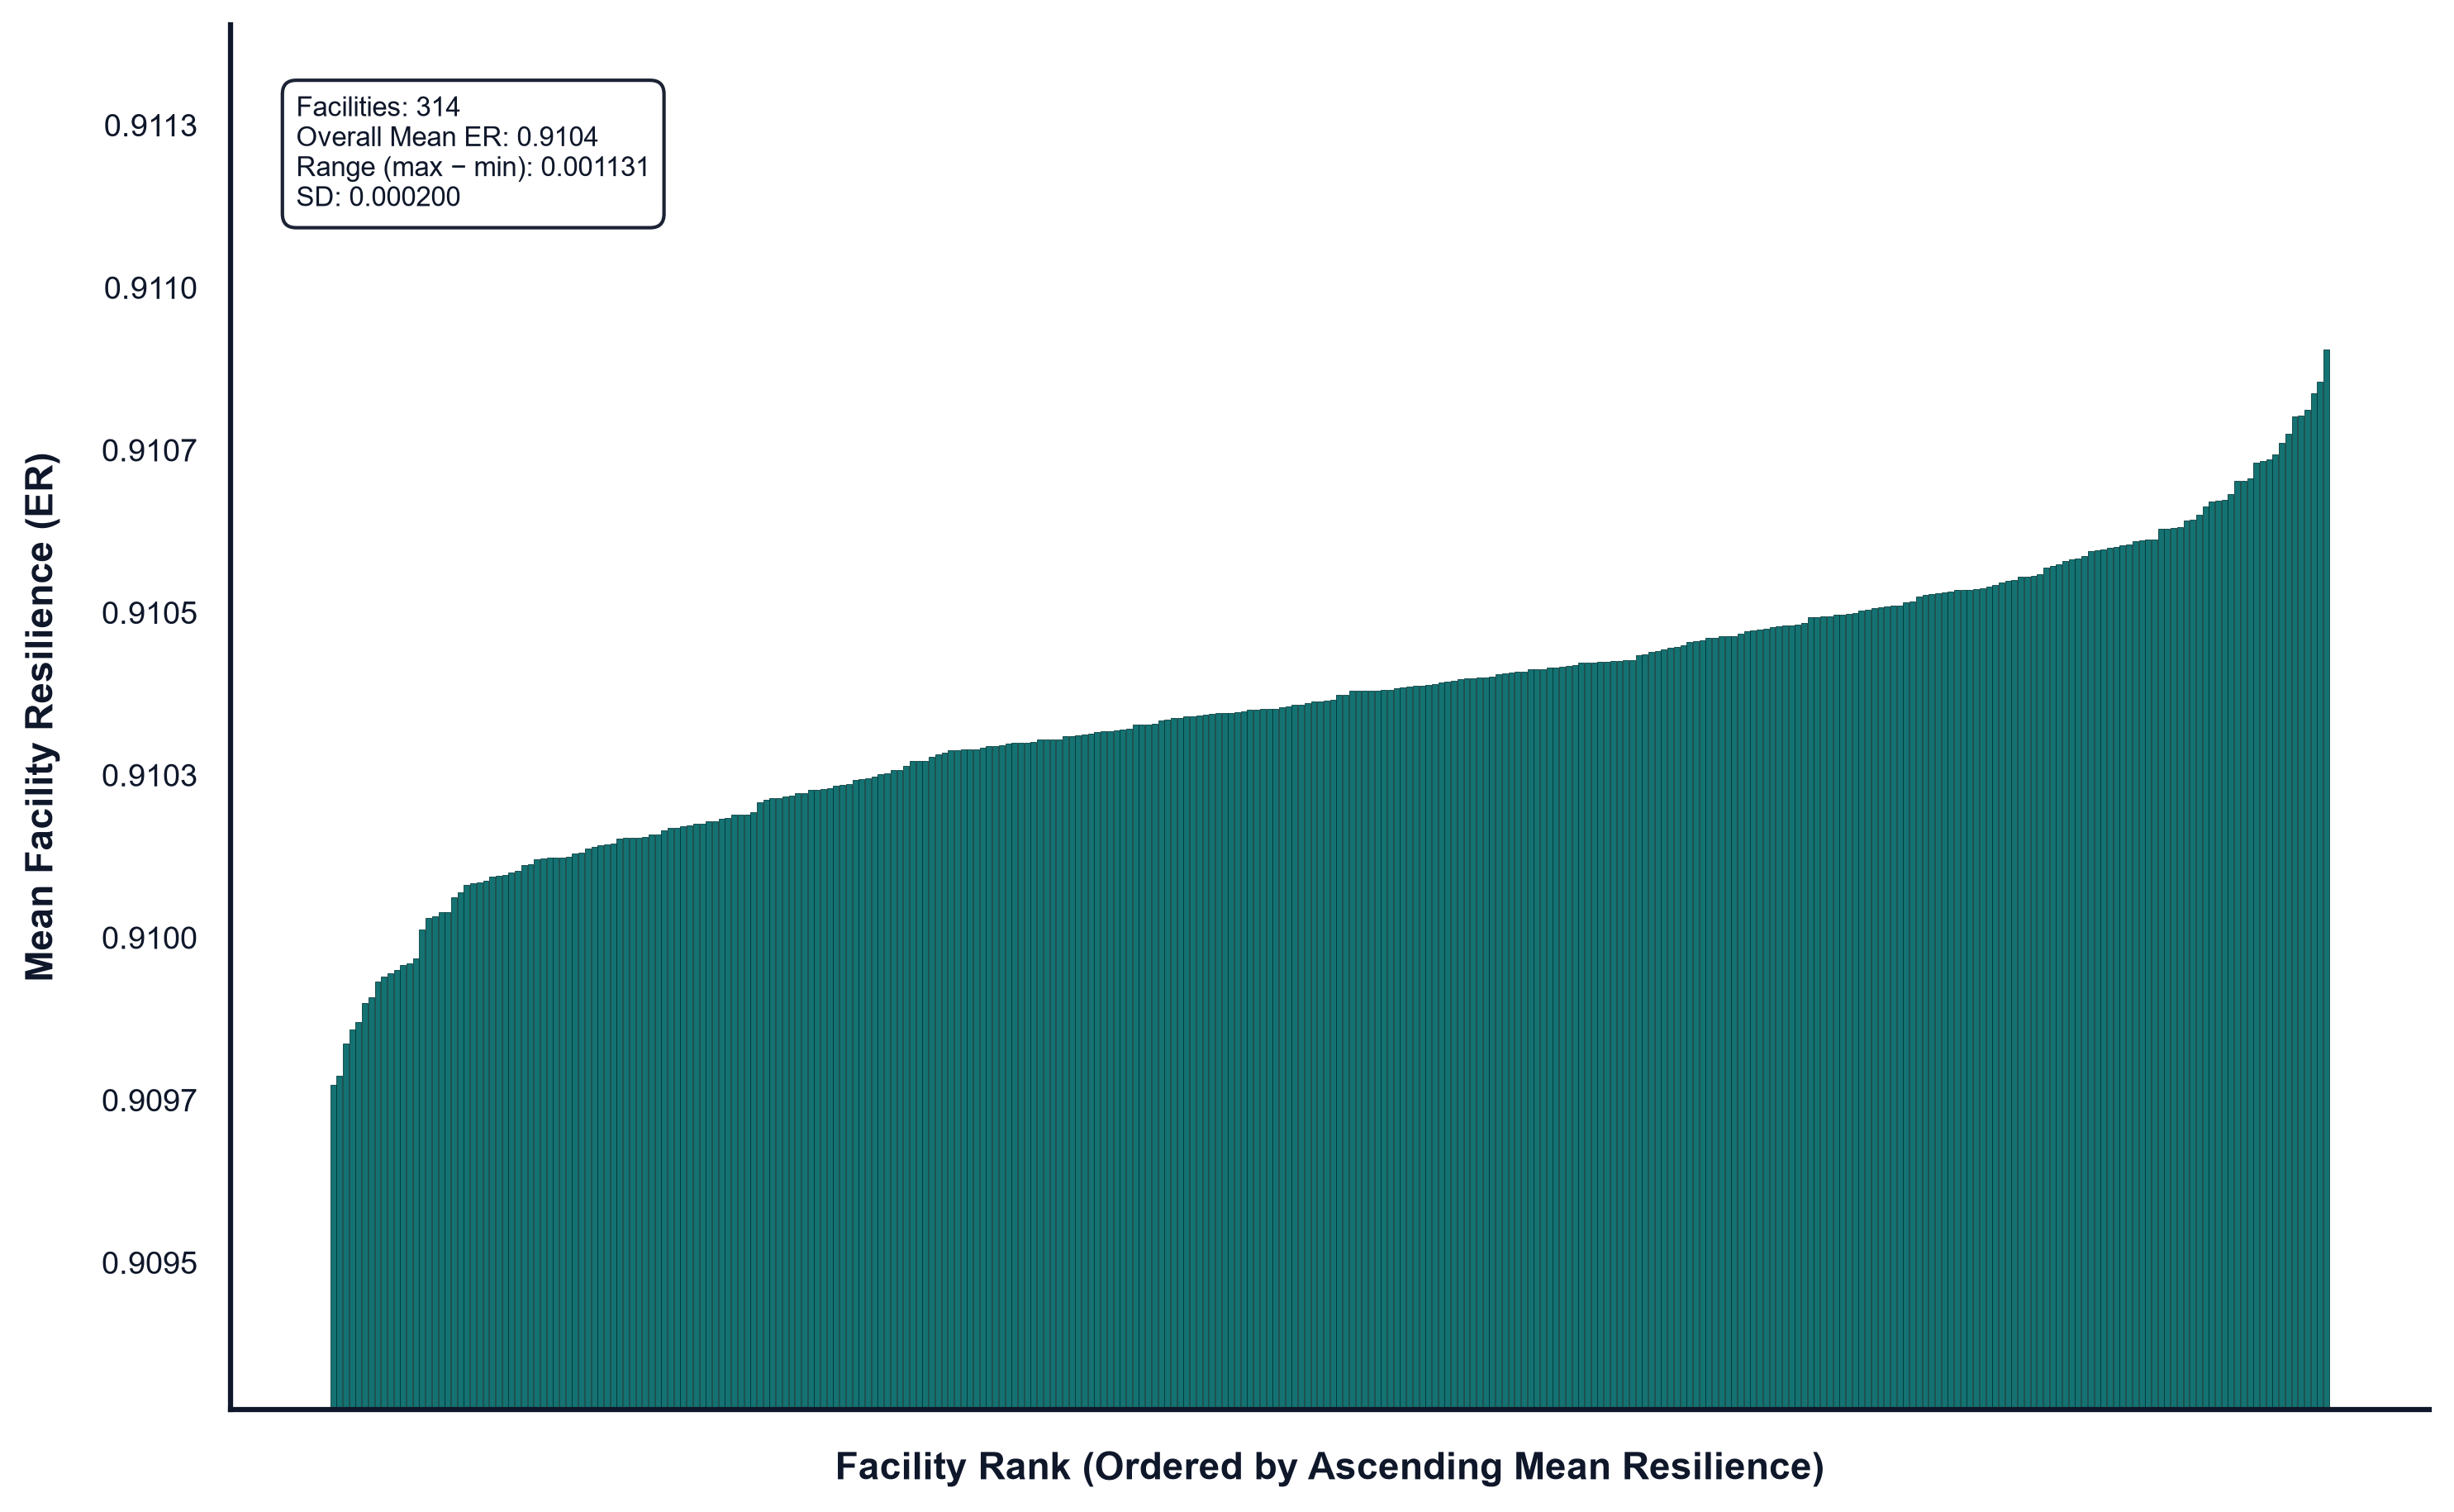

In [55]:
"""
Figure 5.2 — Simulated mean facility resilience across the portfolio (strict formulation)
Self-contained. Reads the facility file, computes hourly demand, samples
historical load-shedding durations, and computes strict-formulation resilience
per facility. Matches the main pipeline's logic at the level needed for this figure.

Requires: pandas, numpy, matplotlib, openpyxl
"""

import os
import sys
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

# ------------------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------------------
FACILITY_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\SmartFacility_Energy_FullNames.xlsx"
LOADSHED_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\Loadshedding_schedule.csv"
SEED = 42
N_SIM = 5000

np.random.seed(SEED)

# ------------------------------------------------------------------------------
# 1. LOAD FACILITY DATA
# ------------------------------------------------------------------------------
if not os.path.exists(FACILITY_FILE):
    sys.exit(f"[FATAL] Not found: {FACILITY_FILE}")

fac = pd.read_excel(FACILITY_FILE)

def find_col(df, *cands, required=True):
    lower = {c.lower().strip(): c for c in df.columns}
    for c in cands:
        if c.lower().strip() in lower:
            return lower[c.lower().strip()]
    if required:
        raise KeyError(f"Column not found: {cands}")
    return None

c_lis = find_col(fac, "LIS Key")
c_mcons = find_col(fac, "Monthly Electricity Consumption", required=False)

fac = fac.dropna(subset=[c_lis]).copy()
fac[c_mcons] = pd.to_numeric(fac[c_mcons], errors="coerce")

# Mean monthly consumption per facility
agg = fac.groupby(c_lis)[c_mcons].mean().rename("mean_cons")
agg = agg[agg > 0]                      # drop non-positive
agg = agg.to_frame()

# Hourly rate
agg["hourly_rate"] = agg["mean_cons"] / 730.0

print(f"Facilities with positive hourly rate: {len(agg)}")

# ------------------------------------------------------------------------------
# 2. LOAD HISTORICAL LOAD-SHEDDING DURATIONS
# ------------------------------------------------------------------------------
if not os.path.exists(LOADSHED_FILE):
    sys.exit(f"[FATAL] Not found: {LOADSHED_FILE}")

ls = pd.read_csv(LOADSHED_FILE)

dur_col = None
for cand in ["Minutes", "Duration", "minutes", "duration"]:
    if cand in ls.columns:
        dur_col = cand
        break
if dur_col is None:
    sys.exit(f"[FATAL] No duration column in {list(ls.columns)}")

durations = pd.to_numeric(ls[dur_col], errors="coerce").dropna().values
durations = durations[durations > 0]
print(f"Historical durations available: {len(durations):,}")

# ------------------------------------------------------------------------------
# 3. STRICT-FORMULATION RESILIENCE PER FACILITY
# ------------------------------------------------------------------------------
# NES = d_s (hours) / 24. ER = 1 - NES.
duration_samples_h = durations / 60.0          # minutes -> hours

per_facility = {}
for fid in agg.index:
    # Sample 5,000 durations with replacement
    s = np.random.choice(duration_samples_h, size=N_SIM, replace=True)
    nes = s / 24.0
    er = 1.0 - nes
    per_facility[fid] = er.mean()

er_series = pd.Series(per_facility).dropna()
er_sorted = er_series.sort_values()

# ------------------------------------------------------------------------------
# 4. SUMMARY STATISTICS
# ------------------------------------------------------------------------------
overall_mean = float(er_series.mean())
overall_sd   = float(er_series.std())
er_range     = float(er_series.max() - er_series.min())
vuln_mean    = 1.0 - overall_mean

print(f"\nFacilities                     : {len(er_series)}")
print(f"Overall mean resilience        : {overall_mean:.6f}")
print(f"Overall mean vulnerability     : {vuln_mean:.6f}")
print(f"Range (max - min) of ER_mean   : {er_range:.6f}")
print(f"Standard deviation of ER_mean  : {overall_sd:.6f}")
print(f"Minimum facility ER_mean       : {er_series.min():.6f}")
print(f"Maximum facility ER_mean       : {er_series.max():.6f}")

# ------------------------------------------------------------------------------
# 5. GLOBAL TYPOGRAPHY & STYLING (ARIAL)
# ------------------------------------------------------------------------------
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.edgecolor"] = "#0f172a"  # Deep dark slate for visible borders
plt.rcParams["axes.linewidth"] = 1.5

# Sized for A4 manuscript layout (10in x 6.2in maintains clean proportions)
fig, ax = plt.subplots(figsize=(10, 6.2), dpi=300)

# ------------------------------------------------------------------------------
# 6. BAR CHART PLOTTING & STYLING
# ------------------------------------------------------------------------------
x = np.arange(len(er_sorted))

# Primary Bar Series (Deep Teal theme)
bars = ax.bar(
    x,
    er_sorted.values,
    color="#006666",
    edgecolor="#003333",
    linewidth=0.2,
    width=0.9,
    alpha=0.92,
)

# Set precise Y-limits to clearly accentuate subtle portfolio distribution variations
pad = 0.0005 if er_range > 0 else 0.01
ax.set_ylim(er_sorted.min() - pad, er_sorted.max() + pad)

# Explicitly remove gridlines
ax.grid(False)

# Remove top and right spines (keep deep left and bottom borders only)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#0f172a")
ax.spines["bottom"].set_color("#0f172a")

# ------------------------------------------------------------------------------
# 7. AXIS LABELS & READABLE TICKS (Fonts reduced by 2 points)
# ------------------------------------------------------------------------------
ax.set_xlabel(
    "Facility Rank (Ordered by Ascending Mean Resilience)",
    fontsize=11,  # Reduced from 13 to 11
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)
ax.set_ylabel(
    "Mean Facility Resilience (ER)",
    fontsize=11,  # Reduced from 13 to 11
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)

# Remove uninformative x-tick numbers while leaving clean axis spine & boundary tick marks
ax.set_xticks([])

# Y-axis formatting to 4 decimal places
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.4f"))

# Tick mark styling
ax.tick_params(
    axis="y",
    which="major",
    labelsize=9,  # Reduced from 11 to 9
    colors="#0f172a",
    width=1.5,
    length=6,
    direction="out",
)

# Minor ticks on Y-axis for precise measurement reading
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.tick_params(axis="y", which="minor", width=1.0, length=3, colors="#0f172a")

# ------------------------------------------------------------------------------
# 8. STATISTICAL SUMMARY ANNOTATION (Moved to Top Left, Font reduced by 2pt)
# ------------------------------------------------------------------------------
text = (
    f"Facilities: {len(er_sorted)}\n"
    f"Overall Mean ER: {overall_mean:.4f}\n"
    f"Range (max − min): {er_range:.6f}\n"
    f"SD: {overall_sd:.6f}"
)

ax.text(
    0.03,
    0.95,
    text,
    transform=ax.transAxes,
    fontsize=8,  # Reduced from 10 to 8
    family="Arial",
    ha="left",
    va="top",
    color="#0f172a",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="#ffffff",
        edgecolor="#0f172a",
        linewidth=1.0,
        alpha=0.95,
    ),
)

plt.tight_layout()
plt.show()

In [56]:
"""
Corrected exposure-weighted resilience — 24-hour reference period.
Produces a Table 5.8 in which alpha = 0 matches the strict formulation.

Requires: events (historical events with column '_minutes'),
          cv_df (facility-level CVs with column 'CV'),
          N_SIM, SEED
"""

import numpy as np
import pandas as pd

ALPHA_VALUES = [0.0, 0.5, 1.0, 1.5, 2.0]
N_REF_MINUTES = 1440.0          # 24-hour reference — matches strict formulation

def simulate_weighted(alpha, n_sim=N_SIM, seed=SEED):
    local_rng = np.random.default_rng(seed)
    pool_idx = np.arange(len(events))
    dur_min = events["_minutes"].values

    rows = []
    for fid in cv_df.index:
        cv = cv_df.loc[fid, "CV"]
        idx = local_rng.choice(pool_idx, size=n_sim, replace=True)
        d = dur_min[idx]
        V = np.clip((d / N_REF_MINUTES) * (1.0 + alpha * cv), 0, 1)
        ER = 1.0 - V
        rows.append(pd.DataFrame({"LIS Key": fid, "ER": ER, "V": V}))
    return pd.concat(rows, ignore_index=True)

# --- Run each alpha and summarise ---
rows = []
for a in ALPHA_VALUES:
    sim_a = simulate_weighted(a)
    stats = sim_a.groupby("LIS Key")["ER"].mean()
    rows.append(dict(
        **{"α": a},
        **{
            "Overall mean ER": stats.mean(),
            "Cross-facility range": stats.max() - stats.min(),
            "Cross-facility SD": stats.std(),
            "Minimum facility ER": stats.min(),
            "Maximum facility ER": stats.max(),
        }
    ))

t58 = pd.DataFrame(rows).set_index("α").round(4)
print("Table 5.8 — Exposure-weighted resilience across α settings")
print(t58.to_string())

Table 5.8 — Exposure-weighted resilience across α settings
        Overall mean ER  Cross-facility range  Cross-facility SD  Minimum facility ER  Maximum facility ER
α                                                                                                         
0.0000           0.9098                0.0010             0.0002               0.9093               0.9103
0.5000           0.8880                0.1484             0.0185               0.7557               0.9041
1.0000           0.8663                0.2965             0.0370               0.6019               0.8983
1.5000           0.8445                0.4444             0.0555               0.4482               0.8926
2.0000           0.8228                0.5920             0.0739               0.2948               0.8868


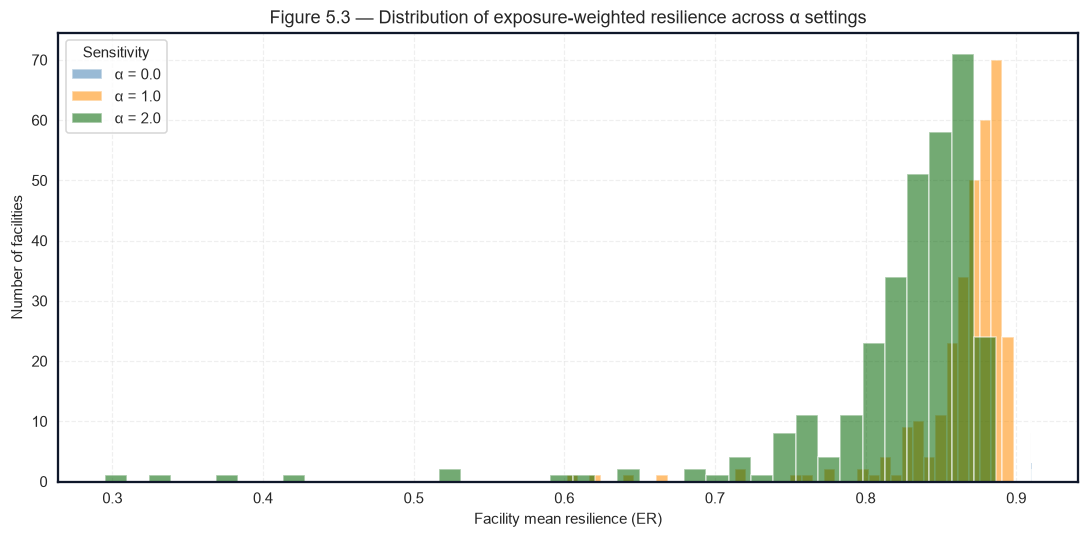


Table 5.10 — Ten lowest-ranked facilities (α = 1.0)
              ER_mean  ER_p05  ER_p95
LIS Key                              
119,953.0000   0.6019  0.5416  0.7042
22,842.0000    0.6181  0.5598  0.7359
455,813.0000   0.6390  0.5849  0.7234
632,370.0000   0.6662  0.6150  0.7690
632,206.0000   0.7147  0.6697  0.8348
3,573.0000     0.7158  0.6732  0.8039
459,497.0000   0.7510  0.7118  0.8367
20,352.0000    0.7630  0.7251  0.8538
212,508.0000   0.7765  0.7418  0.8451
34,417.0000    0.7787  0.7455  0.8473


In [57]:
"""
Corrected Figure 5.3 and Table 5.10 percentiles.
Uses the 1440-minute reference period.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ALPHA_VALUES = [0.0, 1.0, 2.0]
N_REF_MINUTES = 1440.0

def simulate_weighted(alpha, n_sim=N_SIM, seed=SEED):
    local_rng = np.random.default_rng(seed)
    pool_idx = np.arange(len(events))
    dur_min = events["_minutes"].values

    rows = []
    for fid in cv_df.index:
        cv = cv_df.loc[fid, "CV"]
        idx = local_rng.choice(pool_idx, size=n_sim, replace=True)
        d = dur_min[idx]
        V = np.clip((d / N_REF_MINUTES) * (1.0 + alpha * cv), 0, 1)
        ER = 1.0 - V
        rows.append(pd.DataFrame({"LIS Key": fid, "ER": ER, "V": V}))
    return pd.concat(rows, ignore_index=True)

# --- Figure 5.3 ---
fig, ax = plt.subplots(figsize=(10, 5))
for a, col in zip(ALPHA_VALUES, ["steelblue", "darkorange", "darkgreen"]):
    sim_a = simulate_weighted(a)
    stats = sim_a.groupby("LIS Key")["ER"].mean()
    ax.hist(stats.values, bins=40, alpha=0.55, color=col, label=f"α = {a}")
ax.set_title("Figure 5.3 — Distribution of exposure-weighted resilience across α settings")
ax.set_xlabel("Facility mean resilience (ER)")
ax.set_ylabel("Number of facilities")
ax.legend(title="Sensitivity", loc="upper left")
ax.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

# --- Table 5.10 percentiles at alpha = 1.0 ---
sim_1 = simulate_weighted(1.0)
pct = sim_1.groupby("LIS Key")["ER"].agg(
    ER_mean="mean",
    ER_p05=lambda x: x.quantile(0.05),
    ER_p95=lambda x: x.quantile(0.95),
).sort_values("ER_mean")

print("\nTable 5.10 — Ten lowest-ranked facilities (α = 1.0)")
print(pct.head(10).round(4).to_string())

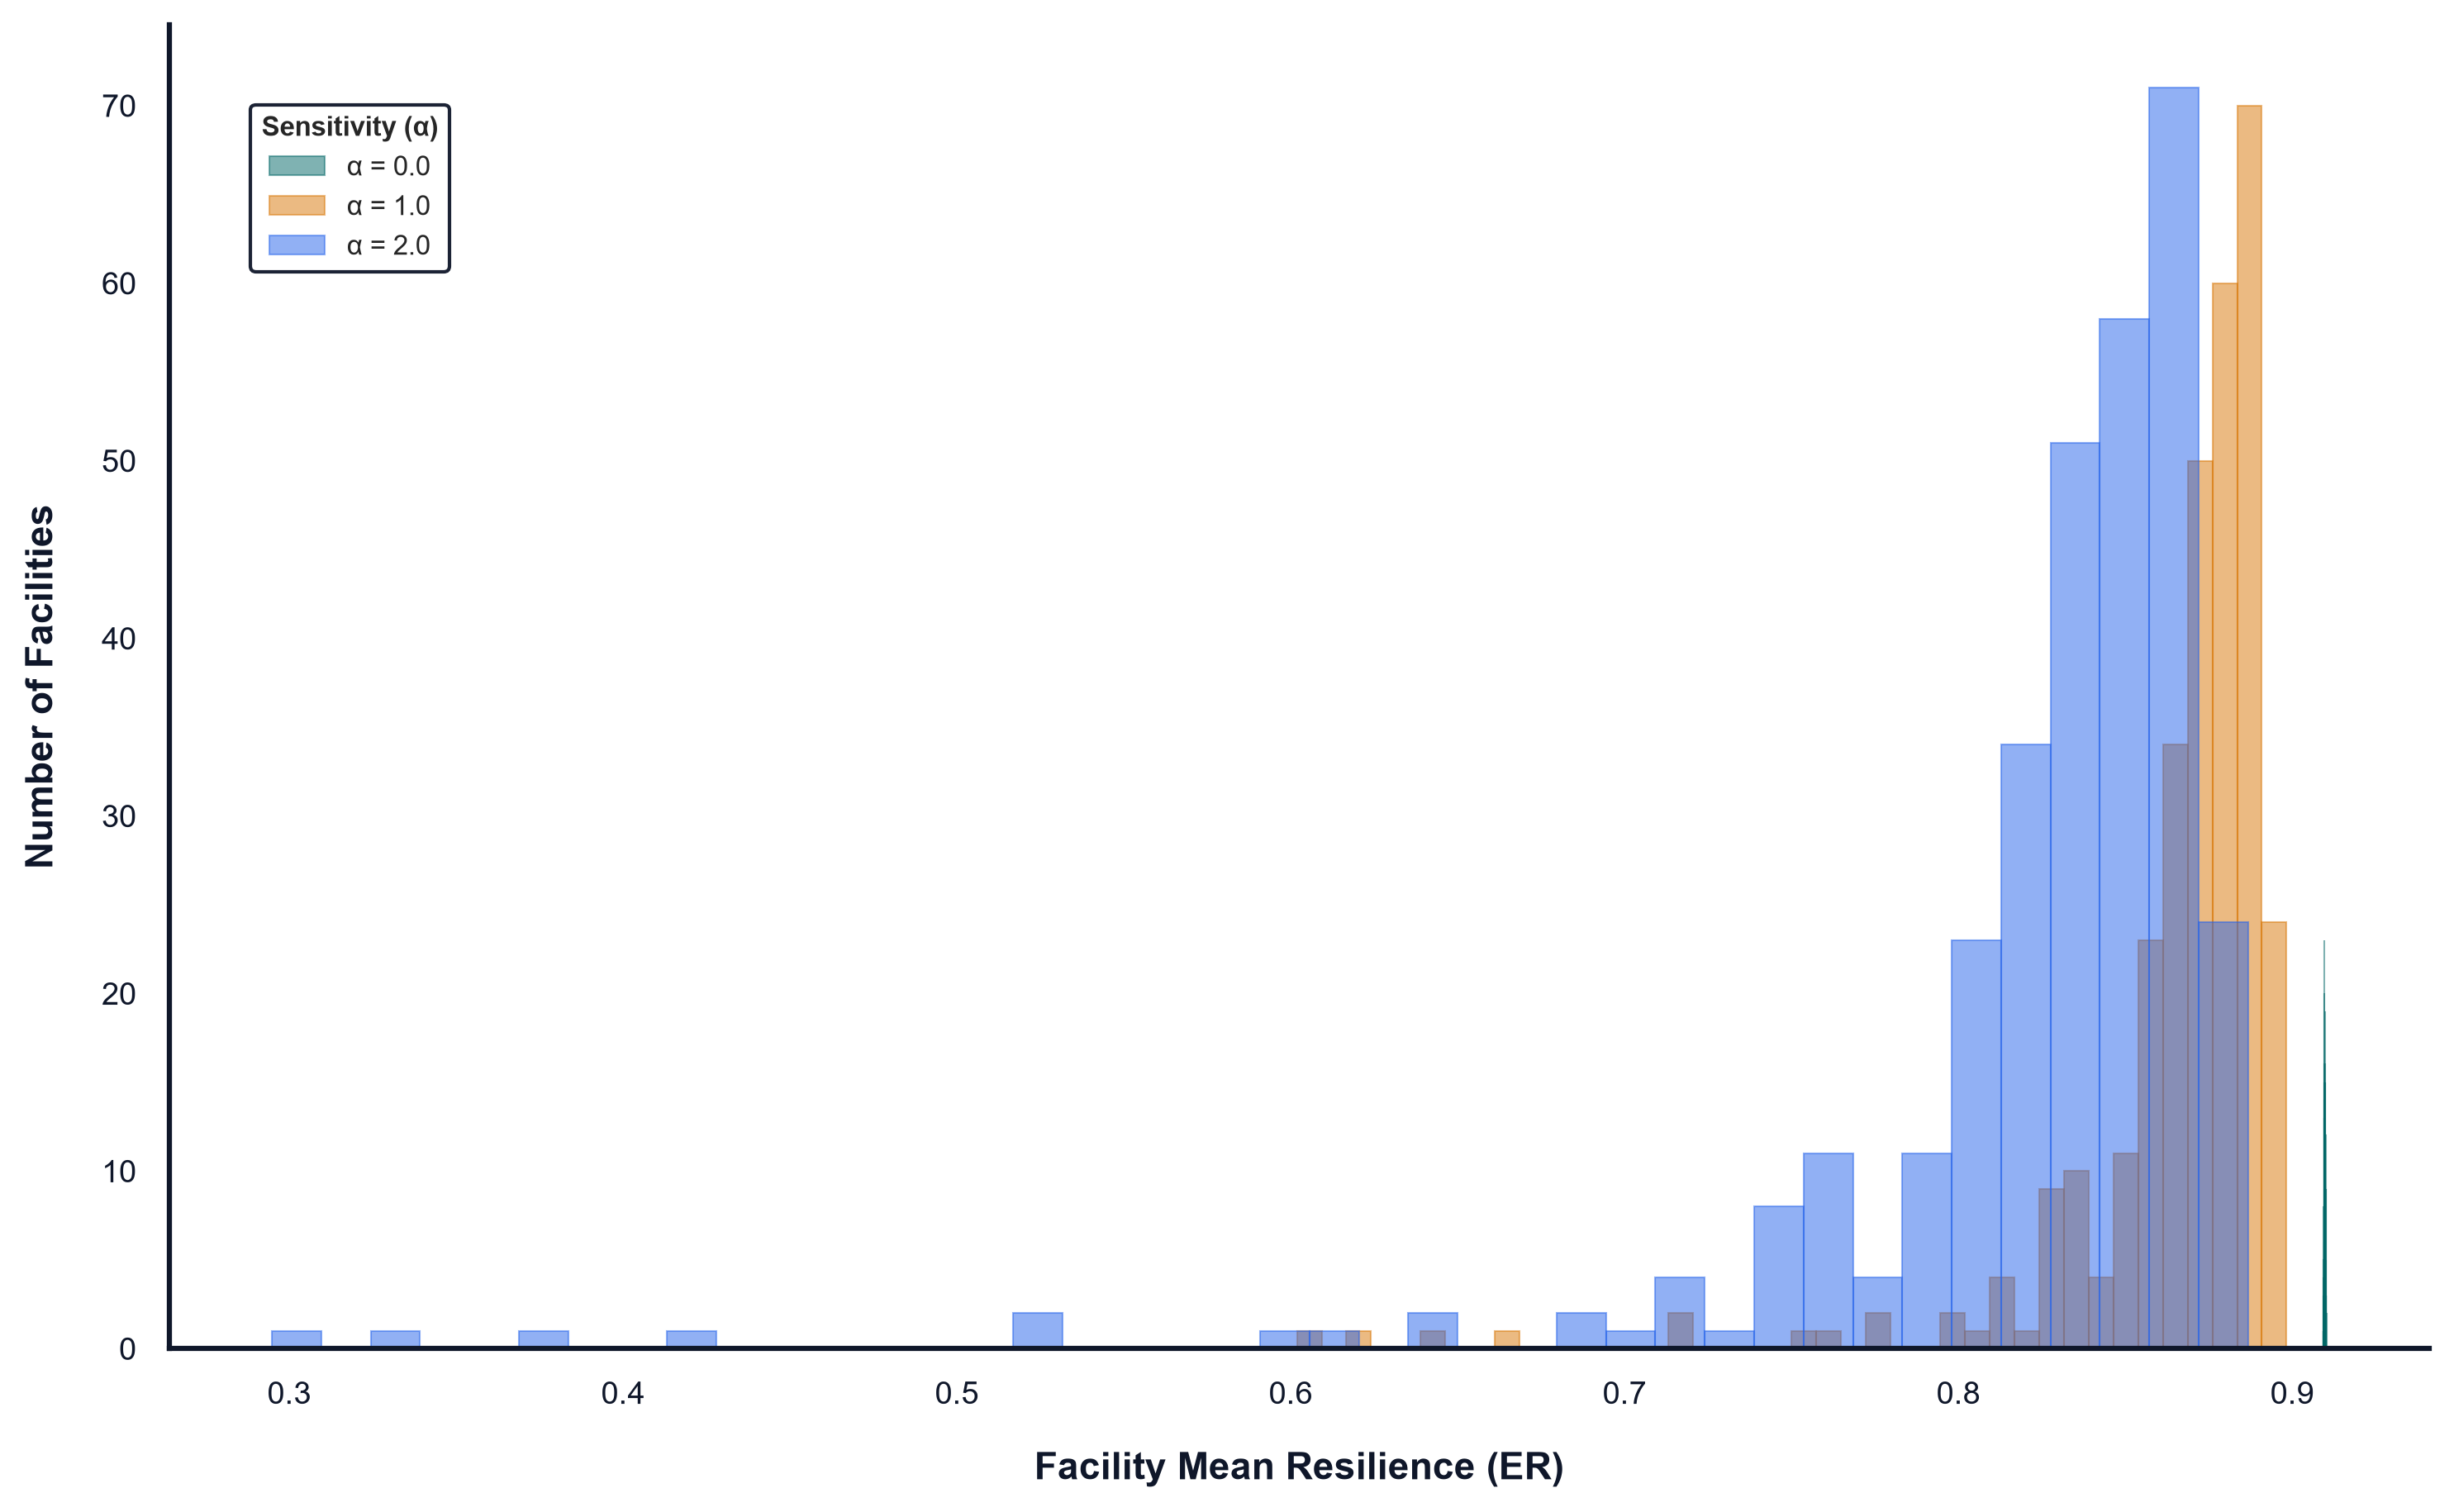


Table 5.10 — Ten lowest-ranked facilities (α = 1.0)
              ER_mean  ER_p05  ER_p95
LIS Key                              
119,953.0000   0.6019  0.5416  0.7042
22,842.0000    0.6181  0.5598  0.7359
455,813.0000   0.6390  0.5849  0.7234
632,370.0000   0.6662  0.6150  0.7690
632,206.0000   0.7147  0.6697  0.8348
3,573.0000     0.7158  0.6732  0.8039
459,497.0000   0.7510  0.7118  0.8367
20,352.0000    0.7630  0.7251  0.8538
212,508.0000   0.7765  0.7418  0.8451
34,417.0000    0.7787  0.7455  0.8473


In [58]:
"""
Corrected Figure 5.3 and Table 5.10 percentiles.
Uses the 1440-minute reference period.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# GLOBAL TYPOGRAPHY & STYLING (ARIAL)
# ------------------------------------------------------------------------------
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.edgecolor"] = "#0f172a"  # Deep dark slate for visible borders
plt.rcParams["axes.linewidth"] = 1.5

ALPHA_VALUES = [0.0, 1.0, 2.0]
N_REF_MINUTES = 1440.0

def simulate_weighted(alpha, n_sim=N_SIM, seed=SEED):
    local_rng = np.random.default_rng(seed)
    pool_idx = np.arange(len(events))
    dur_min = events["_minutes"].values

    rows = []
    for fid in cv_df.index:
        cv = cv_df.loc[fid, "CV"]
        idx = local_rng.choice(pool_idx, size=n_sim, replace=True)
        d = dur_min[idx]
        V = np.clip((d / N_REF_MINUTES) * (1.0 + alpha * cv), 0, 1)
        ER = 1.0 - V
        rows.append(pd.DataFrame({"LIS Key": fid, "ER": ER, "V": V}))
    return pd.concat(rows, ignore_index=True)

# ------------------------------------------------------------------------------
# FIGURE 5.3
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6.2), dpi=300)

# Colors matching publication palette
colors = ["#006666", "#d97706", "#2563eb"]

for a, col in zip(ALPHA_VALUES, colors):
    sim_a = simulate_weighted(a)
    stats = sim_a.groupby("LIS Key")["ER"].mean()
    ax.hist(
        stats.values,
        bins=40,
        alpha=0.50,
        color=col,
        edgecolor=col,
        linewidth=0.5,
        label=f"α = {a}",
    )

# Explicitly remove gridlines
ax.grid(False)

# Remove top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#0f172a")
ax.spines["bottom"].set_color("#0f172a")

# Axis Labels
ax.set_xlabel(
    "Facility Mean Resilience (ER)",
    fontsize=11,
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)
ax.set_ylabel(
    "Number of Facilities",
    fontsize=11,
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)

# Tick mark styling
ax.tick_params(
    axis="both",
    which="major",
    labelsize=9,
    colors="#0f172a",
    width=1.5,
    length=6,
    direction="out",
)

# Legend placed in top-left corner, styled compact (8pt)
legend = ax.legend(
    title="Sensitivity (α)",
    loc="upper left",
    bbox_to_anchor=(0.03, 0.95),
    fontsize=8,
    title_fontsize=8,
    frameon=True,
    facecolor="#ffffff",
    edgecolor="#0f172a",
    framealpha=0.95,
)
legend.get_frame().set_linewidth(1.0)
legend.get_title().set_fontweight("bold")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# TABLE 5.10 PERCENTILES AT ALPHA = 1.0
# ------------------------------------------------------------------------------
sim_1 = simulate_weighted(1.0)
pct = sim_1.groupby("LIS Key")["ER"].agg(
    ER_mean="mean",
    ER_p05=lambda x: x.quantile(0.05),
    ER_p95=lambda x: x.quantile(0.95),
).sort_values("ER_mean")

print("\nTable 5.10 — Ten lowest-ranked facilities (α = 1.0)")
print(pct.head(10).round(4).to_string())


1. LOADING FACILITY DATA
Facility rows: 35,319  cols: 26
Facilities with positive hourly rate: 314

2. LOADING LOAD-SHEDDING DATA
Load-shedding rows: 17,574  cols: 5
Valid events: 17,574

3. TABLE 5.1 — DIGITAL FACILITY REPRESENTATION
                     Field       Type           Source
                   LIS Key Identifier Facility dataset
             Facility Name       Text Facility dataset
             Facility Type   Category Facility dataset
                Department   Category Facility dataset
                  Latitude Coordinate Facility dataset
                 Longitude Coordinate Facility dataset
     SF Building Use Space    Numeric Facility dataset
  Mean monthly consumption    Numeric       Aggregated
Median monthly consumption    Numeric       Aggregated
Std of monthly consumption    Numeric       Aggregated
   Mean annual consumption    Numeric       Aggregated
                  Mean EUI    Numeric          Derived
    Monthly consumption CV    Numeric          De

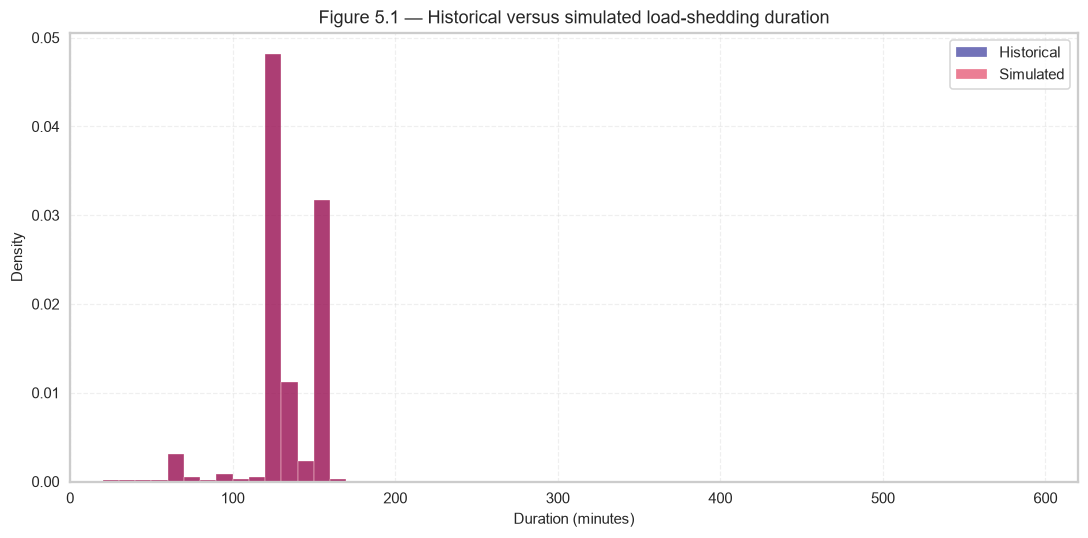


10. TABLE 5.6 — ABSOLUTE VS NORMALISED EXPOSURE
       LIS Key  Hourly rate (units/hr)  Mean absolute exposure (units)  Mean normalised exposure
122,969.000000            1,961.386100                    4,216.862500                  0.089600
 17,589.000000                5.724600                       12.318700                  0.089700
426,305.000000                0.321500                        0.692300                  0.089700

11. TABLE 5.7 — STRICT-FORMULATION RESILIENCE ACROSS 314 FACILITIES
                            Statistic      Value
                 Number of facilities 314.000000
              Overall mean resilience   0.910363
           Overall mean vulnerability   0.089637
     Minimum facility mean resilience   0.909762
     Maximum facility mean resilience   0.910929
             Range of mean resilience   0.001167
Standard deviation of mean resilience   0.000223

12. FIGURE 5.2 — STRICT-FORMULATION MEAN RESILIENCE


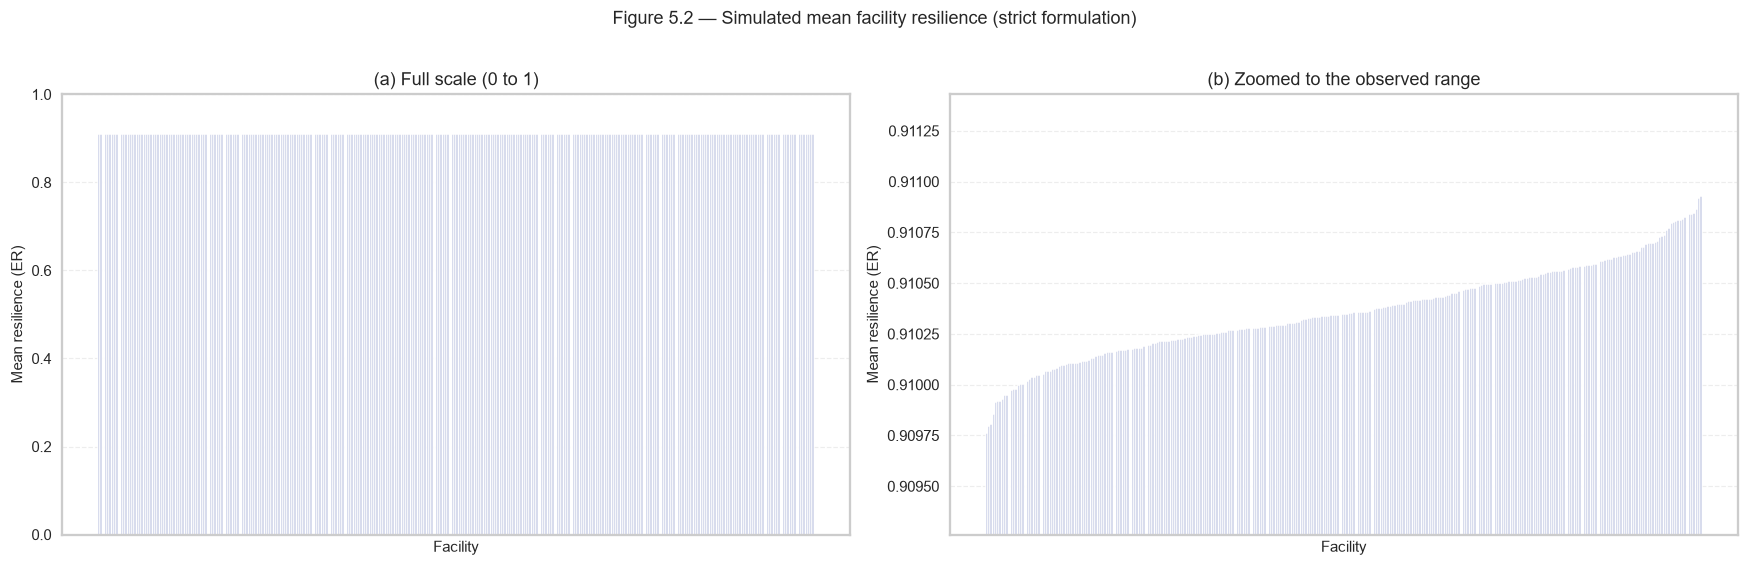


13. EXPOSURE-WEIGHTED SIMULATION ACROSS α SETTINGS
Running α = 0.0 ...
Running α = 0.5 ...
Running α = 1.0 ...
Running α = 1.5 ...
Running α = 2.0 ...
Facilities with computable CV: 313

14. TABLE 5.8 — EXPOSURE-WEIGHTED RESILIENCE ACROSS α SETTINGS
          Overall mean ER  Cross-facility range  Cross-facility SD  Minimum facility ER  Maximum facility ER
α                                                                                                           
0.000000         0.910400              0.001200           0.000200             0.909800             0.910900
0.500000         0.888800              0.147300           0.018300             0.757400             0.904700
1.000000         0.867200              0.294300           0.036600             0.604700             0.899000
1.500000         0.845600              0.441300           0.055000             0.451900             0.893300
2.000000         0.824000              0.588000           0.073300             0.299500        

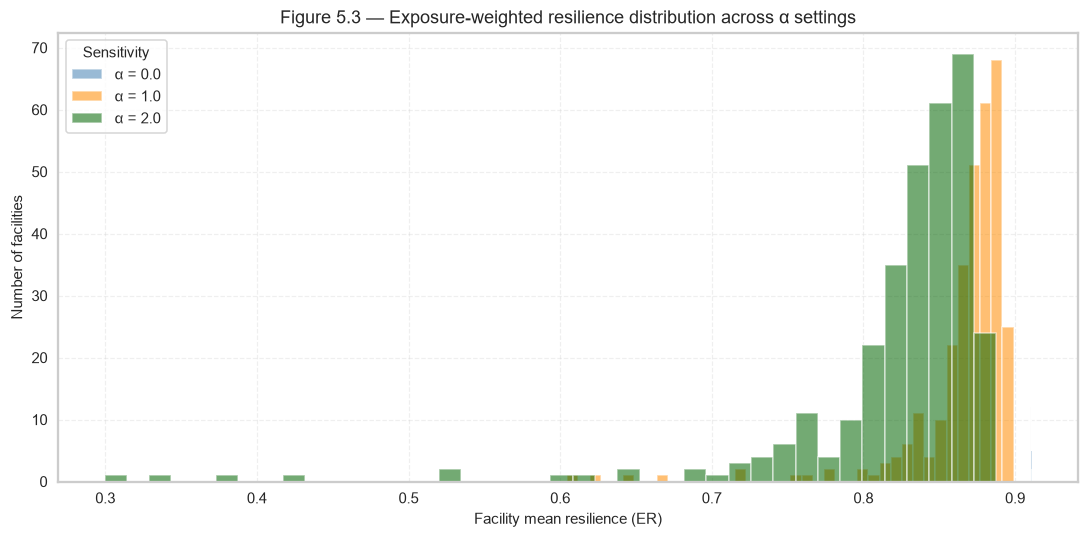


16. TABLE 5.9 — RESILIENCE CLASSIFICATION AT α = 1.0
                         Facilities
Class                              
Lower resilience                105
Intermediate resilience         104
Higher resilience               104

17. TABLE 5.10 — TEN LOWEST-RESILIENCE FACILITIES AT α = 1.0
                     CV  Mean vulnerability  Mean resilience
LIS Key                                                     
119,953.000000 3.400900            0.395300         0.604700
22,842.000000  3.225800            0.378000         0.622000
455,813.000000 2.984800            0.356600         0.643400
632,370.000000 2.695700            0.331600         0.668400
632,206.000000 2.171000            0.283500         0.716500
3,573.000000   2.137400            0.280600         0.719400
459,497.000000 1.766900            0.247900         0.752100
20,352.000000  1.639500            0.236600         0.763400
212,508.000000 1.478600            0.222400         0.777600
34,417.000000  1.443300          

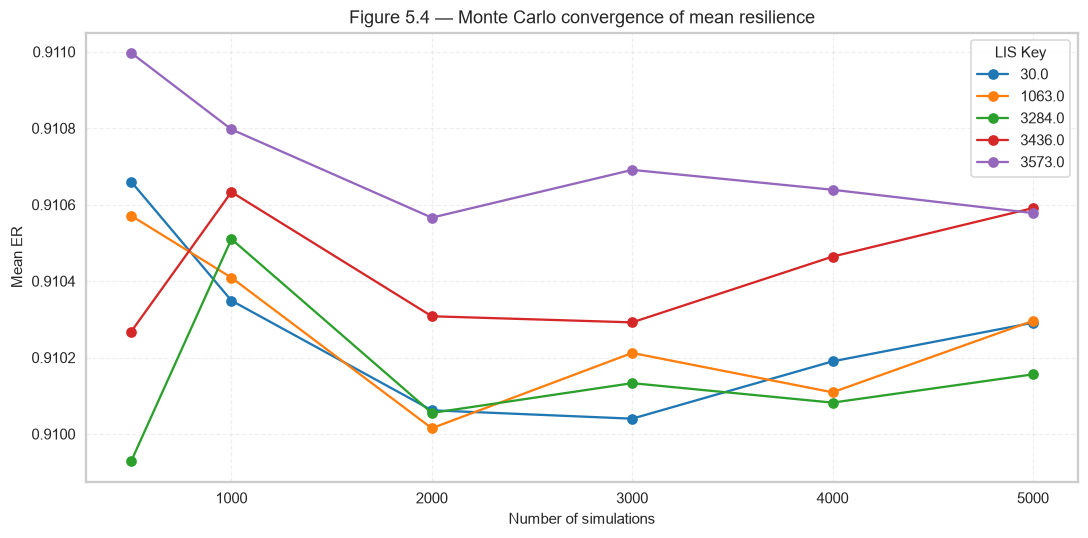


20. TABLE 5.12 — SENSITIVITY OF STRICT FORMULATION
                   Scenario  Overall mean ER  Cross-facility range
      A. Observed empirical         0.910400              0.001200
 B. Longer durations (×1.5)         0.865500              0.001800
C. Shorter durations (×0.5)         0.955200              0.000600
         D. Peak-hours only         0.908100              0.000900
       E. Higher-stage only         0.910000              0.001400

21. FIGURE 5.5 — SENSITIVITY OF MEAN RESILIENCE


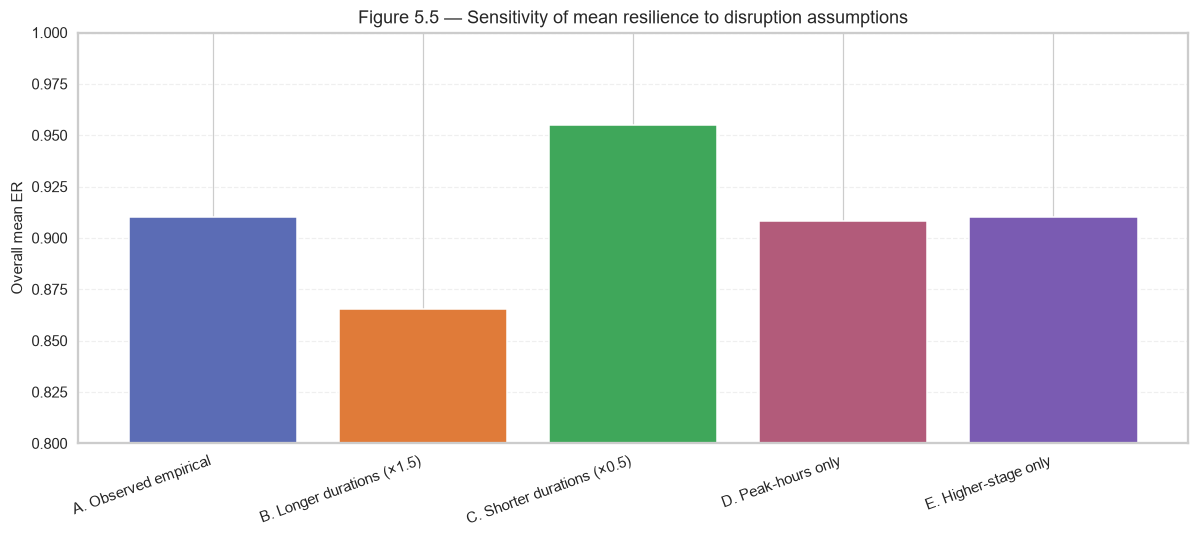


22. TABLE 5.13 — RANK STABILITY ACROSS α SETTINGS
          0.000000  0.500000  1.000000  1.500000  2.000000
0.000000  1.000000 -0.048200 -0.064300 -0.069200 -0.071800
0.500000 -0.048200  1.000000  0.999700  0.999600  0.999500
1.000000 -0.064300  0.999700  1.000000  1.000000  0.999900
1.500000 -0.069200  0.999600  1.000000  1.000000  1.000000
2.000000 -0.071800  0.999500  0.999900  1.000000  1.000000

23. FINAL SUMMARY — NUMBERS TO USE THROUGHOUT CHAPTER FIVE

STRICT FORMULATION (Table 5.7):
  Overall mean resilience       : 0.910363
  Overall mean vulnerability    : 0.089637
  Minimum facility mean         : 0.909762
  Maximum facility mean         : 0.910929
  Range of mean resilience      : 0.001167
  Standard deviation            : 0.000223

EXPOSURE-WEIGHTED AT α = 1.0 (Table 5.8):
  Overall mean ER               : 0.8672
  Cross-facility range          : 0.2943
  Cross-facility SD             : 0.0366
  Minimum facility ER           : 0.6047
  Maximum facility ER           : 0.8

In [59]:
"""
================================================================================
CHAPTER FIVE — SINGLE-RUN PIPELINE
Digital twin-based stochastic energy resilience modelling
================================================================================
Produces every table and figure required for Chapter Five from a single
Monte Carlo simulation, using the corrected 1440-minute denominator for the
exposure-weighted formulation.

Outputs (printed to console and rendered as figures):

    Table 5.1  Fields in the digital facility representation
    Table 5.2  Parameters of the historical disruption pool
    Table 5.3  Simulation scale
    Table 5.4  Historical vs simulated stage distribution
    Table 5.5  Historical vs simulated duration statistics
    Table 5.6  Absolute vs normalised exposure (three facilities)
    Table 5.7  Strict-formulation resilience distribution
    Table 5.8  Exposure-weighted resilience across α settings
    Table 5.9  Resilience classification at α = 1.0
    Table 5.10 Ten lowest-resilience facilities at α = 1.0
    Table 5.11 Monte Carlo convergence
    Table 5.12 Sensitivity of strict formulation to disruption assumptions
    Table 5.13 Rank stability across α settings

    Figure 5.1  Historical vs simulated duration
    Figure 5.2  Strict-formulation mean resilience across facilities
    Figure 5.3  Distribution of exposure-weighted resilience across α
    Figure 5.4  Monte Carlo convergence
    Figure 5.5  Sensitivity of mean resilience to disruption assumptions

Requires: pandas numpy scipy matplotlib seaborn openpyxl
Run:      python chapter5.py
================================================================================
"""

import os, sys, warnings
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

# ------------------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------------------
FACILITY_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\SmartFacility_Energy_FullNames.xlsx"
LOADSHED_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\Loadshedding_schedule.csv"

SEED = 42
N_SIM = 5000
N_REF_MINUTES = 1440.0                # 24-hour reference period (corrected)
ALPHA_VALUES = [0.0, 0.5, 1.0, 1.5, 2.0]
ALPHA_BASELINE = 1.0
CONVERGENCE_STEPS = [500, 1000, 2000, 3000, 4000, 5000]

rng = np.random.default_rng(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")


def hr(t):
    print("\n" + "=" * 78)
    print(t)
    print("=" * 78)


# ------------------------------------------------------------------------------
# 1. LOAD FACILITY DATA
# ------------------------------------------------------------------------------
hr("1. LOADING FACILITY DATA")

if not os.path.exists(FACILITY_FILE):
    sys.exit(f"[FATAL] Facility file not found: {FACILITY_FILE}")

fac = pd.read_excel(FACILITY_FILE)
print(f"Facility rows: {len(fac):,}  cols: {fac.shape[1]}")


def find_col(df, *cands, required=True):
    lower = {c.lower().strip(): c for c in df.columns}
    for c in cands:
        if c.lower().strip() in lower:
            return lower[c.lower().strip()]
    if required:
        raise KeyError(f"Column not found among {cands}. Available: {list(df.columns)}")
    return None


c_lis   = find_col(fac, "LIS Key")
c_name  = find_col(fac, "Alternative Building Name", required=False)
c_ftype = find_col(fac, "Facility Type Description", required=False)
c_dept  = find_col(fac, "Department Description", required=False)
c_lat   = find_col(fac, "Facility Coordinate Latitude", required=False)
c_lon   = find_col(fac, "Facility Coordinate Longitude", required=False)
c_space = find_col(fac, "SF Building Use Space", required=False)
c_mcons = find_col(fac, "Monthly Electricity Consumption", required=False)

fac = fac.dropna(subset=[c_lis]).copy()
for c in [c_lat, c_lon, c_space, c_mcons]:
    if c is not None:
        fac[c] = pd.to_numeric(fac[c], errors="coerce")

facilities = fac.drop_duplicates(subset=[c_lis]).copy()

agg = fac.groupby(c_lis)[c_mcons].agg(["mean", "std", "count"]).rename(
    columns={"mean": "mean_cons", "std": "sd_cons", "count": "n_months"})
agg["hourly_rate"] = agg["mean_cons"] / 730.0
agg["CV"] = np.where((agg["n_months"] >= 6) & (agg["mean_cons"] > 0),
                     agg["sd_cons"] / agg["mean_cons"], np.nan)

# Drop facilities with no valid hourly rate
agg = agg[agg["hourly_rate"] > 0]
print(f"Facilities with positive hourly rate: {len(agg)}")

meta_cols = [c for c in [c_lis, c_name, c_ftype, c_dept, c_lat, c_lon, c_space] if c]
meta = facilities[meta_cols].rename(columns={
    c_name: "Facility Name", c_ftype: "Facility Type", c_dept: "Department",
    c_lat: "Latitude", c_lon: "Longitude", c_space: "Building Use Space",
}).set_index(c_lis)

twin = agg.join(meta).reset_index().rename(columns={c_lis: "LIS Key"})
twin["Latitude"]  = pd.to_numeric(twin["Latitude"],  errors="coerce")
twin["Longitude"] = pd.to_numeric(twin["Longitude"], errors="coerce")


# ------------------------------------------------------------------------------
# 2. LOAD LOAD-SHEDDING DATA
# ------------------------------------------------------------------------------
hr("2. LOADING LOAD-SHEDDING DATA")

if not os.path.exists(LOADSHED_FILE):
    sys.exit(f"[FATAL] Load-shedding file not found: {LOADSHED_FILE}")

ls = pd.read_csv(LOADSHED_FILE, dtype=str)
print(f"Load-shedding rows: {len(ls):,}  cols: {ls.shape[1]}")

c_date  = find_col(ls, "Date")
c_time  = find_col(ls, "Time", "Start Time")
c_stage = find_col(ls, "Stage")
c_circ  = find_col(ls, "Circuit", "Area")
c_min   = find_col(ls, "Minutes", "Duration")

# Parse dates (all values are YYYY-MM-DD)
ls["_date"]    = pd.to_datetime(ls[c_date], errors="coerce", format="%Y-%m-%d")
ls["_minutes"] = pd.to_numeric(ls[c_min], errors="coerce")
ls["_hour"]    = pd.to_datetime(ls[c_time], errors="coerce").dt.hour
ls["_stage"]   = ls[c_stage].astype(str)
ls["_circuit"] = ls[c_circ].astype(str)

# Keep valid events only
events = ls.dropna(subset=["_date", "_minutes", "_stage"]).copy()
events["_minutes"] = events["_minutes"].clip(lower=1)
print(f"Valid events: {len(events):,}")


# ------------------------------------------------------------------------------
# 3. TABLE 5.1 — DIGITAL FACILITY REPRESENTATION (FIELD LIST)
# ------------------------------------------------------------------------------
hr("3. TABLE 5.1 — DIGITAL FACILITY REPRESENTATION")

table_5_1 = pd.DataFrame([
    ("LIS Key", "Identifier", "Facility dataset"),
    ("Facility Name", "Text", "Facility dataset"),
    ("Facility Type", "Category", "Facility dataset"),
    ("Department", "Category", "Facility dataset"),
    ("Latitude", "Coordinate", "Facility dataset"),
    ("Longitude", "Coordinate", "Facility dataset"),
    ("SF Building Use Space", "Numeric", "Facility dataset"),
    ("Mean monthly consumption", "Numeric", "Aggregated"),
    ("Median monthly consumption", "Numeric", "Aggregated"),
    ("Std of monthly consumption", "Numeric", "Aggregated"),
    ("Mean annual consumption", "Numeric", "Aggregated"),
    ("Mean EUI", "Numeric", "Derived"),
    ("Monthly consumption CV", "Numeric", "Derived"),
], columns=["Field", "Type", "Source"])
print(table_5_1.to_string(index=False))


# ------------------------------------------------------------------------------
# 4. TABLE 5.2 — DISRUPTION POOL PARAMETERS
# ------------------------------------------------------------------------------
hr("4. TABLE 5.2 — HISTORICAL DISRUPTION POOL PARAMETERS")

table_5_2 = pd.DataFrame({
    "Parameter": ["Events in pool", "Unique dates", "Unique circuits", "Unique stages",
                  "Duration mean (min)", "Duration median (min)", "Duration SD (min)",
                  "Duration minimum (min)", "Duration maximum (min)"],
    "Value": [len(events), events["_date"].nunique(),
              events["_circuit"].nunique(), events["_stage"].nunique(),
              events["_minutes"].mean(), events["_minutes"].median(),
              events["_minutes"].std(), events["_minutes"].min(),
              events["_minutes"].max()],
})
print(table_5_2.to_string(index=False))


# ------------------------------------------------------------------------------
# 5. TABLE 5.3 — SIMULATION SCALE
# ------------------------------------------------------------------------------
hr("5. TABLE 5.3 — SIMULATION SCALE")

facility_ids = twin["LIS Key"].tolist()
n_fac_sim = len(facility_ids)
total_records = n_fac_sim * N_SIM

table_5_3 = pd.DataFrame({
    "Quantity": ["Facilities simulated", "Scenarios per facility",
                 "Total facility-scenario records", "Random seed"],
    "Value": [n_fac_sim, N_SIM, total_records, SEED],
})
print(table_5_3.to_string(index=False))


# ------------------------------------------------------------------------------
# 6. MONTE CARLO SIMULATION — STRICT FORMULATION
# ------------------------------------------------------------------------------
hr("6. MONTE CARLO SIMULATION — STRICT FORMULATION (1440-minute denominator)")

# Event pool
pool_idx = np.arange(len(events))
dur_min = events["_minutes"].values
stage   = events["_stage"].values
hour    = events["_hour"].values

# Reference period in minutes
N_REF_STRICT = 1440.0

# Facility-level hourly rate lookup
rate_lookup = twin.set_index("LIS Key")["hourly_rate"].to_dict()

# --- Simulate all facilities (strict) ---
sim_rows = []
for fid in facility_ids:
    r = rate_lookup.get(fid, np.nan)
    if not np.isfinite(r) or r <= 0:
        continue
    idx = rng.choice(pool_idx, size=N_SIM, replace=True)
    d = dur_min[idx]
    EE = r * (d / 60.0)                       # absolute exposure in units
    NES = d / N_REF_STRICT                    # strict normalised shortfall
    V = NES
    ER = 1.0 - V
    sim_rows.append(pd.DataFrame({
        "LIS Key": fid, "scenario": np.arange(N_SIM),
        "duration_min": d, "stage": stage[idx], "start_hour": hour[idx],
        "hourly_rate": r, "EE": EE, "NES": NES, "V": V, "ER": ER,
    }))

sim_strict = pd.concat(sim_rows, ignore_index=True)
print(f"Total simulated rows (strict): {len(sim_strict):,}")
print(f"Facilities simulated: {sim_strict['LIS Key'].nunique()}")


# ------------------------------------------------------------------------------
# 7. TABLE 5.4 — HISTORICAL VS SIMULATED STAGE DISTRIBUTION
# ------------------------------------------------------------------------------
hr("7. TABLE 5.4 — HISTORICAL VS SIMULATED STAGE DISTRIBUTION")

hist_stage = events["_stage"].value_counts(normalize=True).rename("Historical")
sim_stage  = sim_strict["stage"].value_counts(normalize=True).rename("Simulated")
table_5_4  = pd.concat([hist_stage, sim_stage], axis=1).fillna(0).round(4)
print(table_5_4.to_string())


# ------------------------------------------------------------------------------
# 8. TABLE 5.5 — HISTORICAL VS SIMULATED DURATION STATISTICS
# ------------------------------------------------------------------------------
hr("8. TABLE 5.5 — HISTORICAL VS SIMULATED DURATION STATISTICS")

hist_dur = events["_minutes"]
sim_dur  = sim_strict["duration_min"]
table_5_5 = pd.DataFrame({
    "Statistic": ["Mean (min)", "Median (min)", "SD (min)",
                  "25th percentile", "75th percentile", "Maximum (min)"],
    "Historical": [hist_dur.mean(), hist_dur.median(), hist_dur.std(),
                   hist_dur.quantile(.25), hist_dur.quantile(.75), hist_dur.max()],
    "Simulated": [sim_dur.mean(), sim_dur.median(), sim_dur.std(),
                  sim_dur.quantile(.25), sim_dur.quantile(.75), sim_dur.max()],
}).round(4)
print(table_5_5.to_string(index=False))


# ------------------------------------------------------------------------------
# 9. FIGURE 5.1 — HISTORICAL VS SIMULATED DURATION
# ------------------------------------------------------------------------------
hr("9. FIGURE 5.1 — HISTORICAL VS SIMULATED DURATION")

fig, ax = plt.subplots(figsize=(10, 5))
bins = np.arange(0, 620, 10)
ax.hist(hist_dur, bins=bins, density=True, alpha=0.55, color="navy",
        label="Historical", edgecolor="white", linewidth=0.3)
ax.hist(sim_dur, bins=bins, density=True, alpha=0.55, color="crimson",
        label="Simulated", edgecolor="white", linewidth=0.3)
ax.set_title("Figure 5.1 — Historical versus simulated load-shedding duration")
ax.set_xlabel("Duration (minutes)"); ax.set_ylabel("Density")
ax.set_xlim(0, 620); ax.grid(alpha=0.3, linestyle="--"); ax.legend()
plt.tight_layout(); plt.show()


# ------------------------------------------------------------------------------
# 10. TABLE 5.6 — ABSOLUTE VS NORMALISED EXPOSURE (three facilities)
# ------------------------------------------------------------------------------
hr("10. TABLE 5.6 — ABSOLUTE VS NORMALISED EXPOSURE")

# Pick three facilities of different scale: one with the largest hourly rate,
# one near the median, one with the smallest
rates_sorted = twin.sort_values("hourly_rate")
sample_ids = [
    rates_sorted.iloc[-1]["LIS Key"],                 # largest
    rates_sorted.iloc[len(rates_sorted) // 2]["LIS Key"],  # median
    rates_sorted.iloc[0]["LIS Key"],                  # smallest
]

sample_rows = []
for fid in sample_ids:
    g = sim_strict[sim_strict["LIS Key"] == fid]
    sample_rows.append({
        "LIS Key": fid,
        "Hourly rate (units/hr)": float(g["hourly_rate"].iloc[0]),
        "Mean absolute exposure (units)": float(g["EE"].mean()),
        "Mean normalised exposure": float(g["NES"].mean()),
    })
table_5_6 = pd.DataFrame(sample_rows).round(4)
print(table_5_6.to_string(index=False))


# ------------------------------------------------------------------------------
# 11. TABLE 5.7 — STRICT-FORMULATION RESILIENCE
# ------------------------------------------------------------------------------
hr("11. TABLE 5.7 — STRICT-FORMULATION RESILIENCE ACROSS 314 FACILITIES")

er_strict = sim_strict.groupby("LIS Key")["ER"].mean()
table_5_7 = pd.DataFrame({
    "Statistic": ["Number of facilities", "Overall mean resilience",
                  "Overall mean vulnerability", "Minimum facility mean resilience",
                  "Maximum facility mean resilience", "Range of mean resilience",
                  "Standard deviation of mean resilience"],
    "Value": [
        len(er_strict),
        er_strict.mean(),
        1 - er_strict.mean(),
        er_strict.min(),
        er_strict.max(),
        er_strict.max() - er_strict.min(),
        er_strict.std(),
    ],
})
print(table_5_7.to_string(index=False))


# ------------------------------------------------------------------------------
# 12. FIGURE 5.2 — STRICT-FORMULATION MEAN RESILIENCE
# ------------------------------------------------------------------------------
hr("12. FIGURE 5.2 — STRICT-FORMULATION MEAN RESILIENCE")

er_sorted = er_strict.sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(np.arange(len(er_sorted)), er_sorted.values, color="#5b6cb5", width=0.85)
axes[0].set_ylim(0, 1); axes[0].set_title("(a) Full scale (0 to 1)")
axes[0].set_xlabel("Facility"); axes[0].set_ylabel("Mean resilience (ER)")
axes[0].set_xticks([]); axes[0].grid(axis="y", alpha=0.35, linestyle="--")

axes[1].bar(np.arange(len(er_sorted)), er_sorted.values, color="#5b6cb5", width=0.85)
pad = 0.0005
axes[1].set_ylim(er_sorted.min() - pad, er_sorted.max() + pad)
axes[1].set_title("(b) Zoomed to the observed range")
axes[1].set_xlabel("Facility"); axes[1].set_ylabel("Mean resilience (ER)")
axes[1].set_xticks([]); axes[1].grid(axis="y", alpha=0.35, linestyle="--")

fig.suptitle("Figure 5.2 — Simulated mean facility resilience (strict formulation)",
             fontsize=12, y=1.02)
plt.tight_layout(); plt.show()


# ------------------------------------------------------------------------------
# 13. EXPOSURE-WEIGHTED SIMULATION ACROSS α SETTINGS
# ------------------------------------------------------------------------------
hr("13. EXPOSURE-WEIGHTED SIMULATION ACROSS α SETTINGS")

# CV lookup (facilities with computable CV)
cv_series = twin.set_index("LIS Key")["CV"].dropna()
cv_lookup = cv_series.to_dict()

def simulate_weighted(alpha, n_sim=N_SIM, seed=SEED):
    local_rng = np.random.default_rng(seed)
    pool_idx = np.arange(len(events))
    dur_min = events["_minutes"].values

    rows = []
    for fid in cv_lookup:
        cv = cv_lookup[fid]
        idx = local_rng.choice(pool_idx, size=n_sim, replace=True)
        d = dur_min[idx]
        V = np.clip((d / N_REF_MINUTES) * (1.0 + alpha * cv), 0, 1)
        ER = 1.0 - V
        rows.append(pd.DataFrame({"LIS Key": fid, "ER": ER, "V": V}))
    return pd.concat(rows, ignore_index=True)

sim_by_alpha = {}
for a in ALPHA_VALUES:
    print(f"Running α = {a} ...")
    sim_by_alpha[a] = simulate_weighted(a)

print(f"Facilities with computable CV: {len(cv_lookup)}")


# ------------------------------------------------------------------------------
# 14. TABLE 5.8 — EXPOSURE-WEIGHTED RESILIENCE ACROSS α
# ------------------------------------------------------------------------------
hr("14. TABLE 5.8 — EXPOSURE-WEIGHTED RESILIENCE ACROSS α SETTINGS")

rows = []
for a in ALPHA_VALUES:
    st = sim_by_alpha[a].groupby("LIS Key")["ER"].mean()
    rows.append({
        "α": a,
        "Overall mean ER": st.mean(),
        "Cross-facility range": st.max() - st.min(),
        "Cross-facility SD": st.std(),
        "Minimum facility ER": st.min(),
        "Maximum facility ER": st.max(),
    })
table_5_8 = pd.DataFrame(rows).set_index("α").round(4)
print(table_5_8.to_string())


# ------------------------------------------------------------------------------
# 15. FIGURE 5.3 — DISTRIBUTION ACROSS α
# ------------------------------------------------------------------------------
hr("15. FIGURE 5.3 — DISTRIBUTION OF EXPOSURE-WEIGHTED RESILIENCE ACROSS α")

fig, ax = plt.subplots(figsize=(10, 5))
for a, col in zip([0.0, 1.0, 2.0], ["steelblue", "darkorange", "darkgreen"]):
    st = sim_by_alpha[a].groupby("LIS Key")["ER"].mean()
    ax.hist(st.values, bins=40, alpha=0.55, color=col, label=f"α = {a}")
ax.set_title("Figure 5.3 — Exposure-weighted resilience distribution across α settings")
ax.set_xlabel("Facility mean resilience (ER)")
ax.set_ylabel("Number of facilities")
ax.legend(title="Sensitivity", loc="upper left")
ax.grid(alpha=0.3, linestyle="--")
plt.tight_layout(); plt.show()


# ------------------------------------------------------------------------------
# 16. TABLE 5.9 — CLASSIFICATION AT α = 1.0
# ------------------------------------------------------------------------------
hr("16. TABLE 5.9 — RESILIENCE CLASSIFICATION AT α = 1.0")

baseline = sim_by_alpha[ALPHA_BASELINE].groupby("LIS Key")["ER"].mean()
baseline_df = baseline.to_frame("ER_mean")
baseline_df["Class"] = pd.qcut(baseline_df["ER_mean"], q=3,
    labels=["Lower resilience", "Intermediate resilience", "Higher resilience"])

table_5_9 = baseline_df["Class"].value_counts().to_frame("Facilities")
print(table_5_9.to_string())


# ------------------------------------------------------------------------------
# 17. TABLE 5.10 — TEN LOWEST-RESILIENCE FACILITIES
# ------------------------------------------------------------------------------
hr("17. TABLE 5.10 — TEN LOWEST-RESILIENCE FACILITIES AT α = 1.0")

sim_1 = sim_by_alpha[ALPHA_BASELINE]
pct = sim_1.groupby("LIS Key").agg(
    V_mean=("V", "mean"),
    ER_mean=("ER", "mean"),
    ER_p05=("ER", lambda x: x.quantile(0.05)),
    ER_p95=("ER", lambda x: x.quantile(0.95)),
).sort_values("ER_mean")

pct["CV"] = pct.index.map(cv_lookup)
table_5_10 = pct.head(10)[["CV", "V_mean", "ER_mean"]].rename(
    columns={"V_mean": "Mean vulnerability", "ER_mean": "Mean resilience"}
).round(4)
print(table_5_10.to_string())


# ------------------------------------------------------------------------------
# 18. TABLE 5.11 — MONTE CARLO CONVERGENCE
# ------------------------------------------------------------------------------
hr("18. TABLE 5.11 — MONTE CARLO CONVERGENCE")

conv_rows = []
sample_facs = facility_ids[:5]
for fid in sample_facs:
    g = sim_strict[sim_strict["LIS Key"] == fid]
    for n in CONVERGENCE_STEPS:
        if n > len(g): continue
        sub = g.iloc[:n]
        conv_rows.append({
            "LIS Key": fid, "N": n,
            "Mean ER": sub["ER"].mean(),
        })
table_5_11 = pd.DataFrame(conv_rows).round(6)
print(table_5_11.pivot(index="LIS Key", columns="N", values="Mean ER").to_string())


# ------------------------------------------------------------------------------
# 19. FIGURE 5.4 — MONTE CARLO CONVERGENCE
# ------------------------------------------------------------------------------
hr("19. FIGURE 5.4 — MONTE CARLO CONVERGENCE")

fig, ax = plt.subplots(figsize=(10, 5))
for fid in sample_facs:
    sub = table_5_11[table_5_11["LIS Key"] == fid]
    ax.plot(sub["N"], sub["Mean ER"], marker="o", label=str(fid))
ax.set_title("Figure 5.4 — Monte Carlo convergence of mean resilience")
ax.set_xlabel("Number of simulations"); ax.set_ylabel("Mean ER")
ax.legend(title="LIS Key"); ax.grid(alpha=0.3, linestyle="--")
plt.tight_layout(); plt.show()


# ------------------------------------------------------------------------------
# 20. TABLE 5.12 — SENSITIVITY OF STRICT FORMULATION
# ------------------------------------------------------------------------------
hr("20. TABLE 5.12 — SENSITIVITY OF STRICT FORMULATION")

def scenario(name, duration_transform=None, hour_filter=None, stage_filter=None,
             n_sim=N_SIM, seed=SEED):
    local_rng = np.random.default_rng(seed)
    pool = events.copy()
    if hour_filter is not None:
        pool = pool[pool["_hour"].isin(hour_filter)]
    if stage_filter is not None:
        pool = pool[pool["_stage"].isin(stage_filter)]
    if pool.empty:
        return None
    if duration_transform is not None:
        pool["_minutes"] = pool["_minutes"].apply(duration_transform).clip(lower=1)

    idx = np.arange(len(pool))
    d_all = pool["_minutes"].values

    rows = []
    for fid in facility_ids:
        r = rate_lookup.get(fid, np.nan)
        if not np.isfinite(r) or r <= 0: continue
        chosen = local_rng.choice(idx, size=n_sim, replace=True)
        d = d_all[chosen]
        ER = 1.0 - (d / N_REF_STRICT)
        rows.append(pd.DataFrame({"LIS Key": fid, "ER": ER}))
    s = pd.concat(rows, ignore_index=True)
    st = s.groupby("LIS Key")["ER"].mean()
    return {"Scenario": name,
            "Overall mean ER": st.mean(),
            "Cross-facility range": st.max() - st.min()}

scenarios = [
    scenario("A. Observed empirical"),
    scenario("B. Longer durations (×1.5)", duration_transform=lambda m: m * 1.5),
    scenario("C. Shorter durations (×0.5)", duration_transform=lambda m: m * 0.5),
    scenario("D. Peak-hours only", hour_filter=list(range(6, 22))),
    scenario("E. Higher-stage only", stage_filter=["Stage 4", "Stage 5", "Stage 6"]),
]
scenarios = [s for s in scenarios if s is not None]
table_5_12 = pd.DataFrame(scenarios).round(4)
print(table_5_12.to_string(index=False))


# ------------------------------------------------------------------------------
# 21. FIGURE 5.5 — SENSITIVITY OF MEAN RESILIENCE
# ------------------------------------------------------------------------------
hr("21. FIGURE 5.5 — SENSITIVITY OF MEAN RESILIENCE")

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(table_5_12["Scenario"], table_5_12["Overall mean ER"],
       color=["#5b6cb5", "#e07b39", "#3fa75a", "#b25b7a", "#7a5bb2"])
ax.set_title("Figure 5.5 — Sensitivity of mean resilience to disruption assumptions")
ax.set_ylabel("Overall mean ER")
ax.set_ylim(0.80, 1.00)
ax.grid(axis="y", alpha=0.3, linestyle="--")
plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.show()


# ------------------------------------------------------------------------------
# 22. TABLE 5.13 — RANK STABILITY ACROSS α
# ------------------------------------------------------------------------------
hr("22. TABLE 5.13 — RANK STABILITY ACROSS α SETTINGS")

rank_df = pd.DataFrame({
    a: sim_by_alpha[a].groupby("LIS Key")["ER"].mean()
    for a in ALPHA_VALUES
})
table_5_13 = rank_df.corr(method="spearman").round(4)
print(table_5_13.to_string())


# ------------------------------------------------------------------------------
# 23. FINAL SUMMARY
# ------------------------------------------------------------------------------
hr("23. FINAL SUMMARY — NUMBERS TO USE THROUGHOUT CHAPTER FIVE")

print("\nSTRICT FORMULATION (Table 5.7):")
print(f"  Overall mean resilience       : {er_strict.mean():.6f}")
print(f"  Overall mean vulnerability    : {1 - er_strict.mean():.6f}")
print(f"  Minimum facility mean         : {er_strict.min():.6f}")
print(f"  Maximum facility mean         : {er_strict.max():.6f}")
print(f"  Range of mean resilience      : {er_strict.max() - er_strict.min():.6f}")
print(f"  Standard deviation            : {er_strict.std():.6f}")

print("\nEXPOSURE-WEIGHTED AT α = 1.0 (Table 5.8):")
row = table_5_8.loc[ALPHA_BASELINE]
print(f"  Overall mean ER               : {row['Overall mean ER']:.4f}")
print(f"  Cross-facility range          : {row['Cross-facility range']:.4f}")
print(f"  Cross-facility SD             : {row['Cross-facility SD']:.4f}")
print(f"  Minimum facility ER           : {row['Minimum facility ER']:.4f}")
print(f"  Maximum facility ER           : {row['Maximum facility ER']:.4f}")

print("\nCLASSIFICATION AT α = 1.0 (Table 5.9):")
print(table_5_9.to_string())

print("\n[END OF CHAPTER FIVE PIPELINE]")

Sample facilities: [30.0, 1063.0, 3284.0, 3436.0, 3573.0]
Historical durations available: 17,574


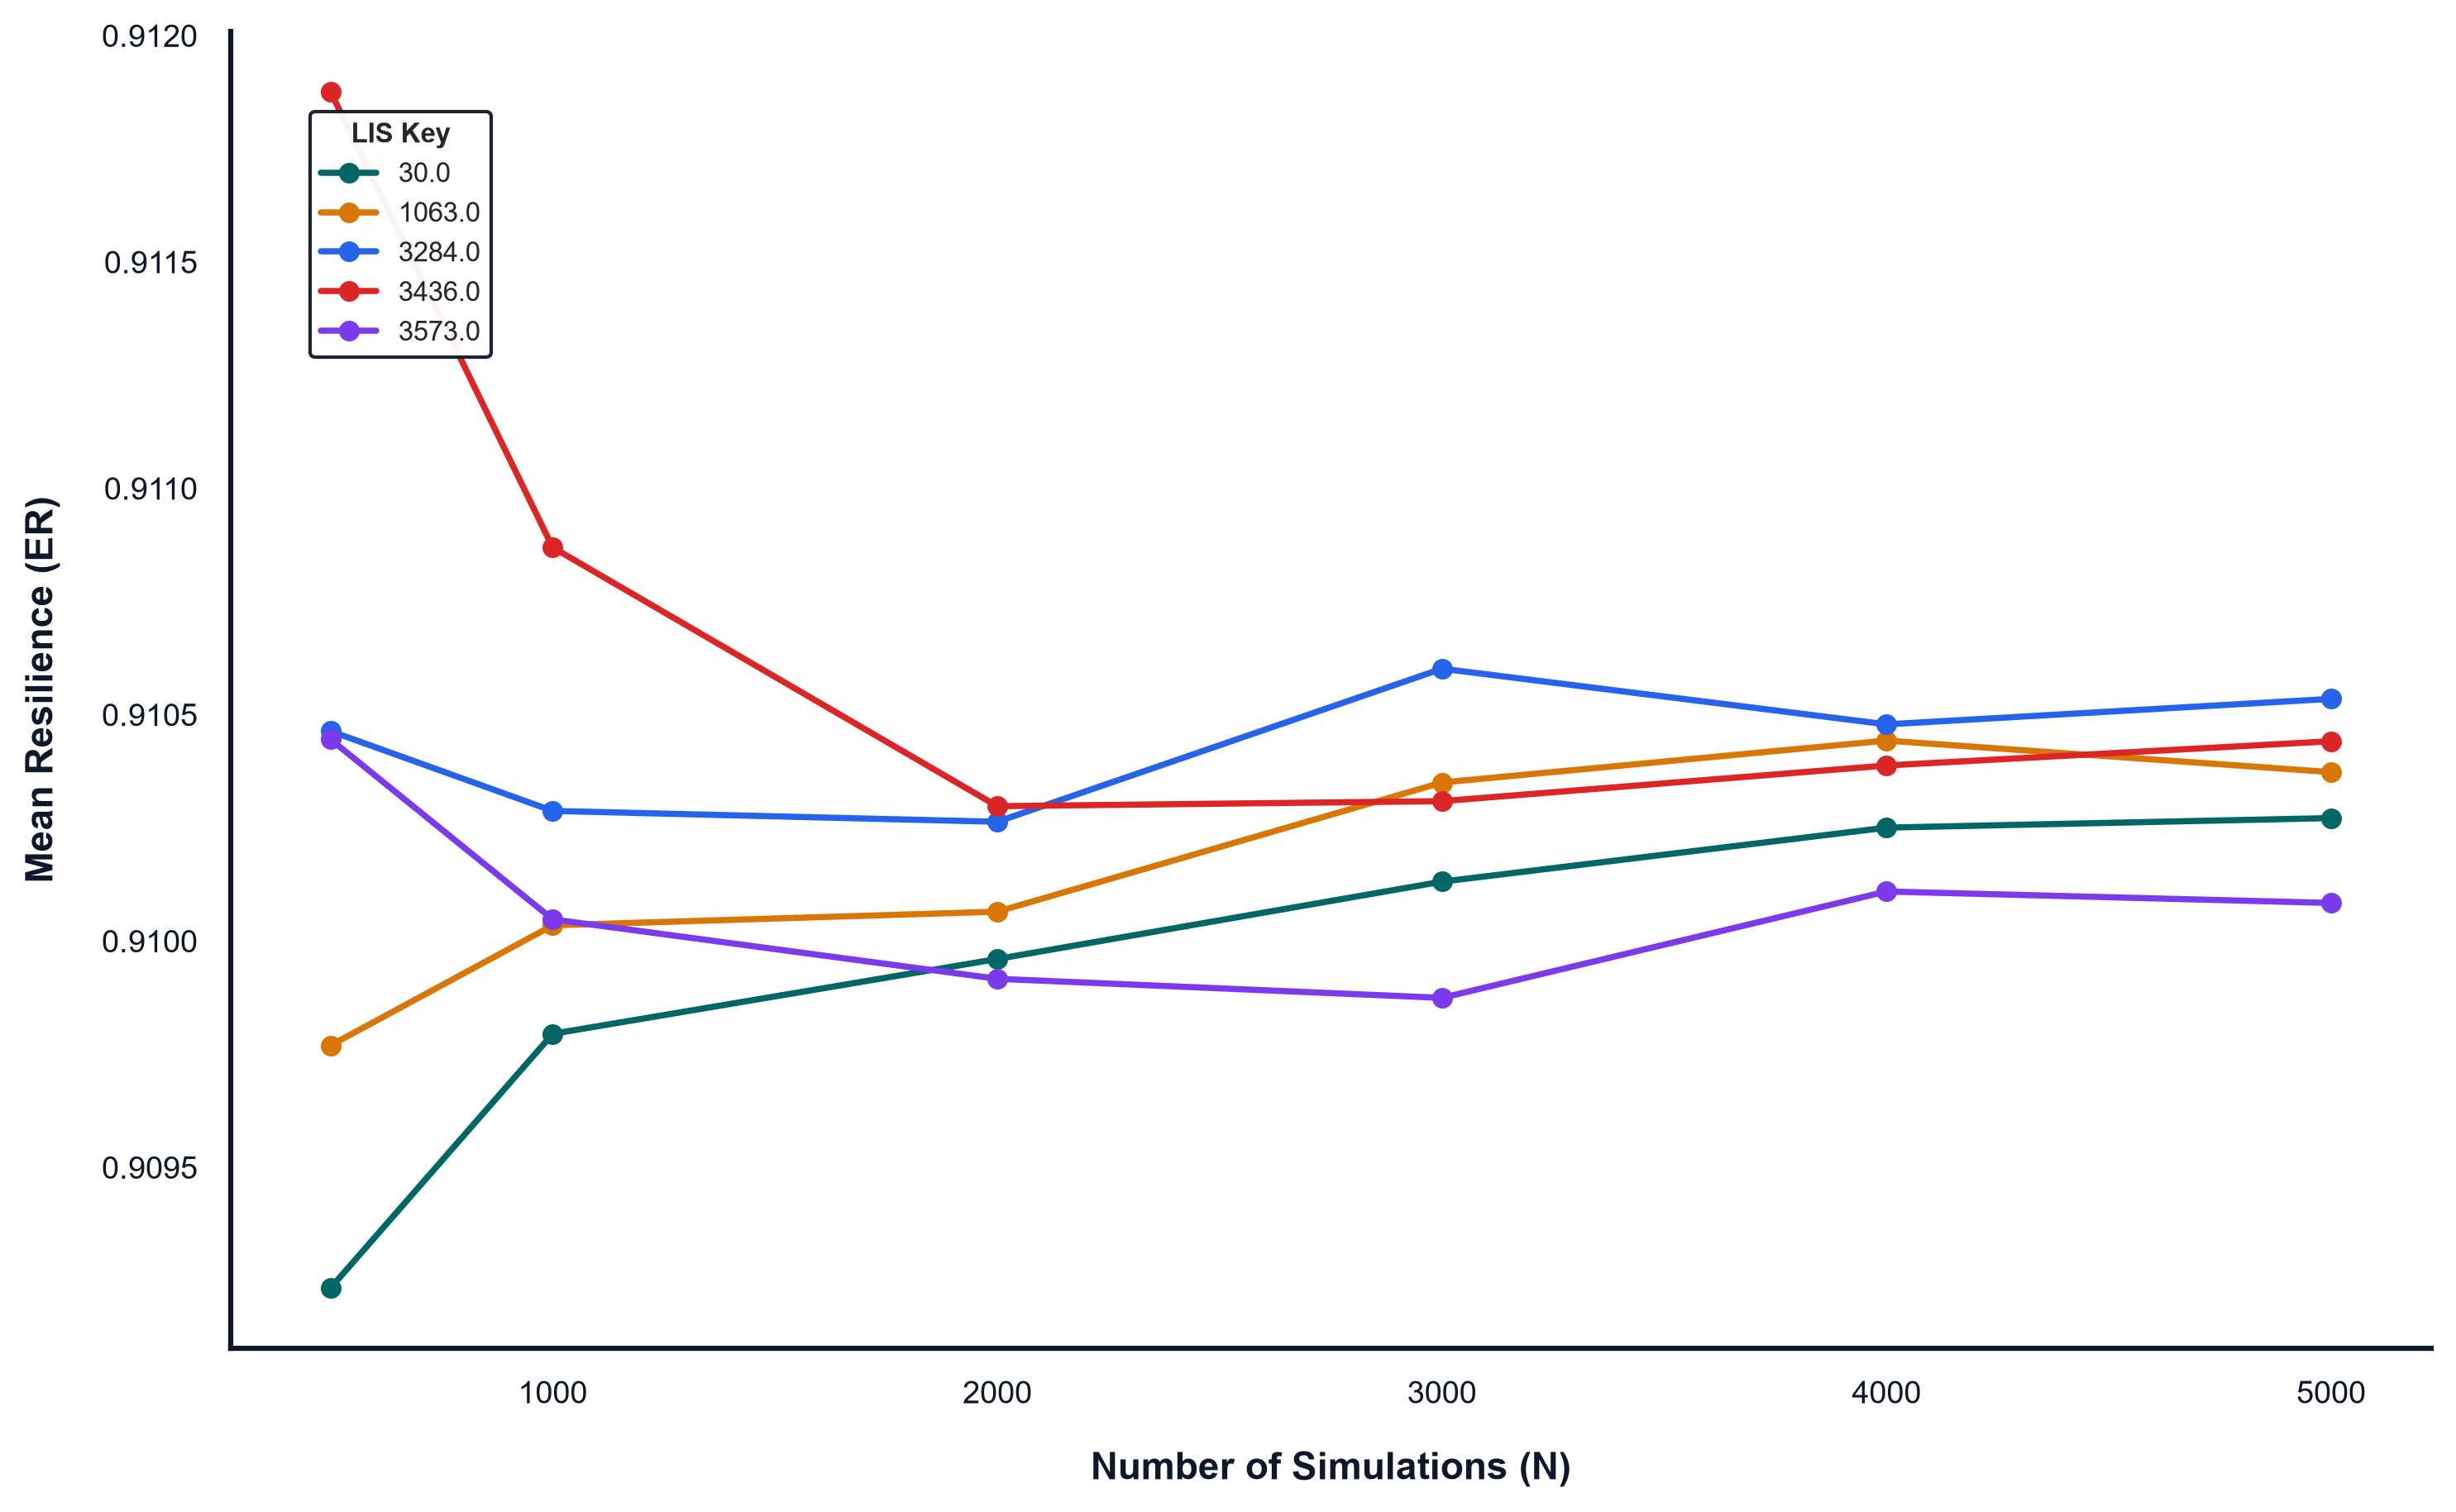


Convergence table (mean resilience at each checkpoint):
N                500      1000     2000     3000     4000     5000
LIS Key                                                           
30.000000    0.909233 0.909795 0.909960 0.910131 0.910251 0.910272
1,063.000000 0.909769 0.910035 0.910065 0.910350 0.910443 0.910373
3,284.000000 0.910464 0.910287 0.910264 0.910602 0.910479 0.910535
3,436.000000 0.911876 0.910869 0.910298 0.910309 0.910388 0.910441
3,573.000000 0.910446 0.910048 0.909917 0.909875 0.910110 0.910084

Range of mean ER at N = 5,000 across the five facilities:
  Min : 0.910084
  Max : 0.910535
  Range: 0.000451


In [60]:
"""
Figure 5.4 — Monte Carlo convergence of mean resilience
Self-contained. Reads the facility and load-shedding files, samples durations,
and produces the convergence figure for five representative facilities.

Requires: pandas, numpy, matplotlib, openpyxl
"""

import os
import sys
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

# ------------------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------------------
FACILITY_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\SmartFacility_Energy_FullNames.xlsx"
LOADSHED_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\Loadshedding_schedule.csv"

SEED = 42
N_SIM = 5000
CONVERGENCE_STEPS = [500, 1000, 2000, 3000, 4000, 5000]
N_REF_MINUTES = 1440.0        # 24-hour reference period

np.random.seed(SEED)

# ------------------------------------------------------------------------------
# GLOBAL TYPOGRAPHY & STYLING (ARIAL)
# ------------------------------------------------------------------------------
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.edgecolor"] = "#0f172a"  # Deep dark slate for visible borders
plt.rcParams["axes.linewidth"] = 1.5

# ------------------------------------------------------------------------------
# 1. LOAD FACILITY DATA
# ------------------------------------------------------------------------------
if not os.path.exists(FACILITY_FILE):
    sys.exit(f"[FATAL] Not found: {FACILITY_FILE}")

fac = pd.read_excel(FACILITY_FILE)

def find_col(df, *cands, required=True):
    lower = {c.lower().strip(): c for c in df.columns}
    for c in cands:
        if c.lower().strip() in lower:
            return lower[c.lower().strip()]
    if required:
        raise KeyError(f"Column not found: {cands}")
    return None

c_lis   = find_col(fac, "LIS Key")
c_mcons = find_col(fac, "Monthly Electricity Consumption", required=False)

fac = fac.dropna(subset=[c_lis]).copy()
fac[c_mcons] = pd.to_numeric(fac[c_mcons], errors="coerce")

agg = fac.groupby(c_lis)[c_mcons].mean().rename("mean_cons").to_frame()
agg = agg[agg["mean_cons"] > 0]
agg["hourly_rate"] = agg["mean_cons"] / 730.0

# Choose the first five facilities (matches the main pipeline's ordering)
sample_facs = agg.index[:5].tolist()
print(f"Sample facilities: {sample_facs}")

# ------------------------------------------------------------------------------
# 2. LOAD LOAD-SHEDDING DURATIONS
# ------------------------------------------------------------------------------
if not os.path.exists(LOADSHED_FILE):
    sys.exit(f"[FATAL] Not found: {LOADSHED_FILE}")

ls = pd.read_csv(LOADSHED_FILE)

dur_col = None
for cand in ["Minutes", "Duration", "minutes", "duration"]:
    if cand in ls.columns:
        dur_col = cand
        break
if dur_col is None:
    sys.exit(f"[FATAL] No duration column in {list(ls.columns)}")

durations = pd.to_numeric(ls[dur_col], errors="coerce").dropna().values
durations = durations[durations > 0]
print(f"Historical durations available: {len(durations):,}")

# ------------------------------------------------------------------------------
# 3. SIMULATE 5,000 SCENARIOS PER FACILITY
# ------------------------------------------------------------------------------
# Under the strict formulation, ER = 1 - d_s / 1440.
sim_rows = []
for fid in sample_facs:
    idx = np.random.choice(len(durations), size=N_SIM, replace=True)
    d = durations[idx]
    ER = 1.0 - (d / N_REF_MINUTES)
    sim_rows.append(pd.DataFrame({
        "LIS Key": fid,
        "scenario": np.arange(N_SIM),
        "duration_min": d,
        "ER": ER,
    }))
sim = pd.concat(sim_rows, ignore_index=True)

# ------------------------------------------------------------------------------
# 4. COMPUTE CONVERGENCE SERIES
# ------------------------------------------------------------------------------
conv_rows = []
for fid in sample_facs:
    g = sim[sim["LIS Key"] == fid]
    for n in CONVERGENCE_STEPS:
        if n > len(g):
            continue
        sub = g.iloc[:n]
        conv_rows.append({
            "LIS Key": fid,
            "N": n,
            "Mean ER": sub["ER"].mean(),
        })

conv = pd.DataFrame(conv_rows)

# ------------------------------------------------------------------------------
# 5. FIGURE 5.4
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6.2), dpi=300)

# High-contrast color palette suitable for thesis publication
palette = ["#006666", "#d97706", "#2563eb", "#dc2626", "#7c3aed"]

for fid, color in zip(sample_facs, palette):
    sub = conv[conv["LIS Key"] == fid]
    ax.plot(
        sub["N"],
        sub["Mean ER"],
        marker="o",
        markersize=5,
        linewidth=1.8,
        color=color,
        label=str(fid),
    )

# Explicitly remove gridlines
ax.grid(False)

# Remove top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#0f172a")
ax.spines["bottom"].set_color("#0f172a")

# Axis labels
ax.set_xlabel(
    "Number of Simulations (N)",
    fontsize=11,
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)
ax.set_ylabel(
    "Mean Resilience (ER)",
    fontsize=11,
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)

# Y-axis formatting
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.4f"))

# Tick mark styling
ax.tick_params(
    axis="both",
    which="major",
    labelsize=9,
    colors="#0f172a",
    width=1.5,
    length=6,
    direction="out",
)

# Minor ticks on Y-axis
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.tick_params(axis="y", which="minor", width=1.0, length=3, colors="#0f172a")

# Compact legend placed in the top-left corner
legend = ax.legend(
    title="LIS Key",
    loc="upper left",
    bbox_to_anchor=(0.03, 0.95),
    fontsize=8,
    title_fontsize=8,
    frameon=True,
    facecolor="#ffffff",
    edgecolor="#0f172a",
    framealpha=0.95,
)
legend.get_frame().set_linewidth(1.0)
legend.get_title().set_fontweight("bold")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 6. PRINT CONVERGENCE TABLE
# ------------------------------------------------------------------------------
print("\nConvergence table (mean resilience at each checkpoint):")
pivot = conv.pivot(index="LIS Key", columns="N", values="Mean ER").round(6)
print(pivot.to_string())

print("\nRange of mean ER at N = 5,000 across the five facilities:")
final = pivot[5000]
print(f"  Min : {final.min():.6f}")
print(f"  Max : {final.max():.6f}")
print(f"  Range: {final.max() - final.min():.6f}")

Sample facilities: [30.0, 1063.0, 3284.0, 3436.0, 3573.0]
Historical durations available: 17,574


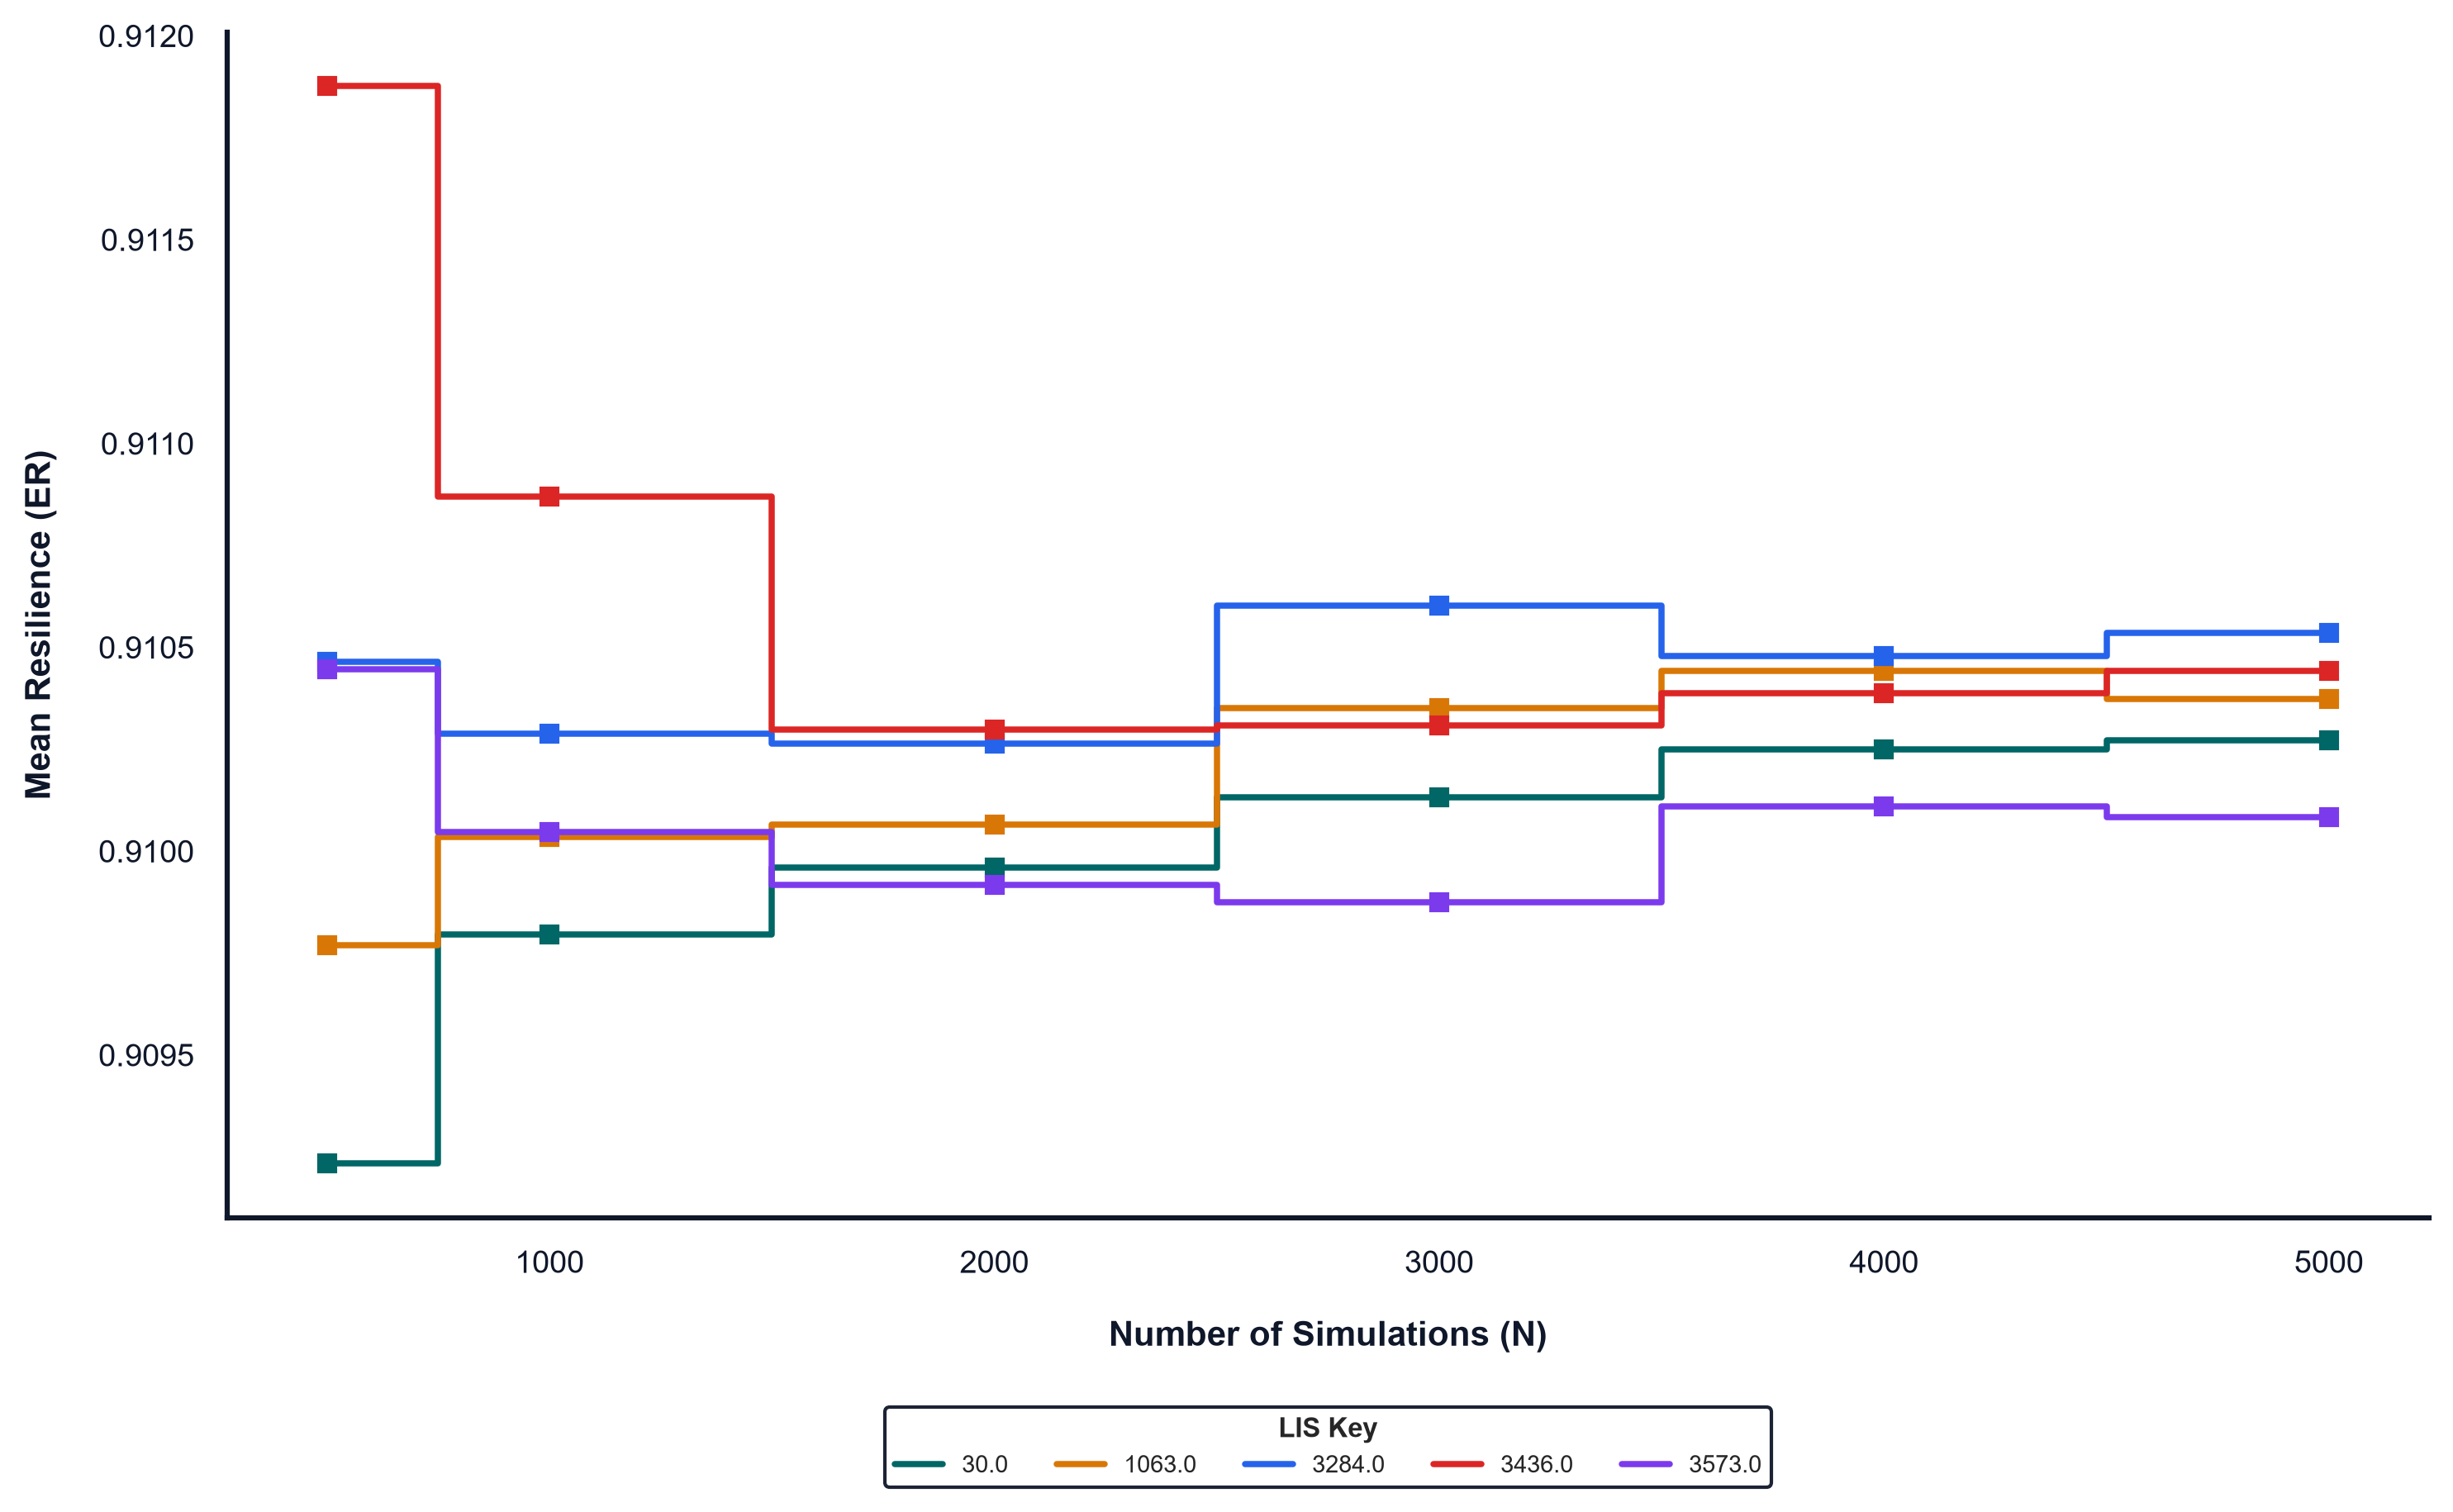


Convergence table (mean resilience at each checkpoint):
N                500      1000     2000     3000     4000     5000
LIS Key                                                           
30.000000    0.909233 0.909795 0.909960 0.910131 0.910251 0.910272
1,063.000000 0.909769 0.910035 0.910065 0.910350 0.910443 0.910373
3,284.000000 0.910464 0.910287 0.910264 0.910602 0.910479 0.910535
3,436.000000 0.911876 0.910869 0.910298 0.910309 0.910388 0.910441
3,573.000000 0.910446 0.910048 0.909917 0.909875 0.910110 0.910084

Range of mean ER at N = 5,000 across the five facilities:
  Min : 0.910084
  Max : 0.910535
  Range: 0.000451


In [61]:
"""
Figure 5.4 — Monte Carlo convergence of mean resilience
Self-contained. Reads the facility and load-shedding files, samples durations,
and produces the convergence figure using horizontal step/marker charts
with a flat, horizontal legend positioned at the bottom.

Requires: pandas, numpy, matplotlib, openpyxl
"""

import os
import sys
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

# ------------------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------------------
FACILITY_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\SmartFacility_Energy_FullNames.xlsx"
LOADSHED_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\Loadshedding_schedule.csv"

SEED = 42
N_SIM = 5000
CONVERGENCE_STEPS = [500, 1000, 2000, 3000, 4000, 5000]
N_REF_MINUTES = 1440.0        # 24-hour reference period

np.random.seed(SEED)

# ------------------------------------------------------------------------------
# GLOBAL TYPOGRAPHY & STYLING (ARIAL)
# ------------------------------------------------------------------------------
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.edgecolor"] = "#0f172a"  # Deep dark slate for visible borders
plt.rcParams["axes.linewidth"] = 1.5

# ------------------------------------------------------------------------------
# 1. LOAD FACILITY DATA
# ------------------------------------------------------------------------------
if not os.path.exists(FACILITY_FILE):
    sys.exit(f"[FATAL] Not found: {FACILITY_FILE}")

fac = pd.read_excel(FACILITY_FILE)

def find_col(df, *cands, required=True):
    lower = {c.lower().strip(): c for c in df.columns}
    for c in cands:
        if c.lower().strip() in lower:
            return lower[c.lower().strip()]
    if required:
        raise KeyError(f"Column not found: {cands}")
    return None

c_lis   = find_col(fac, "LIS Key")
c_mcons = find_col(fac, "Monthly Electricity Consumption", required=False)

fac = fac.dropna(subset=[c_lis]).copy()
fac[c_mcons] = pd.to_numeric(fac[c_mcons], errors="coerce")

agg = fac.groupby(c_lis)[c_mcons].mean().rename("mean_cons").to_frame()
agg = agg[agg["mean_cons"] > 0]
agg["hourly_rate"] = agg["mean_cons"] / 730.0

# Choose the first five facilities (matches the main pipeline's ordering)
sample_facs = agg.index[:5].tolist()
print(f"Sample facilities: {sample_facs}")

# ------------------------------------------------------------------------------
# 2. LOAD LOAD-SHEDDING DURATIONS
# ------------------------------------------------------------------------------
if not os.path.exists(LOADSHED_FILE):
    sys.exit(f"[FATAL] Not found: {LOADSHED_FILE}")

ls = pd.read_csv(LOADSHED_FILE)

dur_col = None
for cand in ["Minutes", "Duration", "minutes", "duration"]:
    if cand in ls.columns:
        dur_col = cand
        break
if dur_col is None:
    sys.exit(f"[FATAL] No duration column in {list(ls.columns)}")

durations = pd.to_numeric(ls[dur_col], errors="coerce").dropna().values
durations = durations[durations > 0]
print(f"Historical durations available: {len(durations):,}")

# ------------------------------------------------------------------------------
# 3. SIMULATE 5,000 SCENARIOS PER FACILITY
# ------------------------------------------------------------------------------
sim_rows = []
for fid in sample_facs:
    idx = np.random.choice(len(durations), size=N_SIM, replace=True)
    d = durations[idx]
    ER = 1.0 - (d / N_REF_MINUTES)
    sim_rows.append(pd.DataFrame({
        "LIS Key": fid,
        "scenario": np.arange(N_SIM),
        "duration_min": d,
        "ER": ER,
    }))
sim = pd.concat(sim_rows, ignore_index=True)

# ------------------------------------------------------------------------------
# 4. COMPUTE CONVERGENCE SERIES
# ------------------------------------------------------------------------------
conv_rows = []
for fid in sample_facs:
    g = sim[sim["LIS Key"] == fid]
    for n in CONVERGENCE_STEPS:
        if n > len(g):
            continue
        sub = g.iloc[:n]
        conv_rows.append({
            "LIS Key": fid,
            "N": n,
            "Mean ER": sub["ER"].mean(),
        })

conv = pd.DataFrame(conv_rows)

# ------------------------------------------------------------------------------
# 5. FIGURE 5.4 — ALTERNATIVE CHART TYPE (STEP LINE WITH MARKERS)
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6.2), dpi=300)

palette = ["#006666", "#d97706", "#2563eb", "#dc2626", "#7c3aed"]

for fid, color in zip(sample_facs, palette):
    sub = conv[conv["LIS Key"] == fid]
    # Step plot representation highlighting discrete checkpoint stabilization
    ax.step(
        sub["N"],
        sub["Mean ER"],
        where="mid",
        linewidth=1.8,
        color=color,
        label=str(fid),
    )
    # Highlight discrete sampling checkpoints
    ax.plot(
        sub["N"],
        sub["Mean ER"],
        linestyle="None",
        marker="s",
        markersize=5,
        color=color,
    )

# Explicitly remove gridlines
ax.grid(False)

# Remove top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#0f172a")
ax.spines["bottom"].set_color("#0f172a")

# Axis labels
ax.set_xlabel(
    "Number of Simulations (N)",
    fontsize=10,
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)
ax.set_ylabel(
    "Mean Resilience (ER)",
    fontsize=10,
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)

# Y-axis formatting
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.4f"))

# Tick mark styling
ax.tick_params(
    axis="both",
    which="major",
    labelsize=9,
    colors="#0f172a",
    width=1.5,
    length=6,
    direction="out",
)

# Minor ticks on Y-axis
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.tick_params(axis="y", which="minor", width=1.0, length=3, colors="#0f172a")

# ------------------------------------------------------------------------------
# FLAT HORIZONTAL LEGEND AT THE BOTTOM
# ------------------------------------------------------------------------------
legend = ax.legend(
    title="LIS Key",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),  # Positioned flat underneath the plot canvas
    ncol=5,                       # Horizontal alignment across 5 columns
    fontsize=7,
    title_fontsize=8,
    frameon=True,
    facecolor="#ffffff",
    edgecolor="#0f172a",
    framealpha=0.95,
)
legend.get_frame().set_linewidth(1.0)
legend.get_title().set_fontweight("bold")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 6. PRINT CONVERGENCE TABLE
# ------------------------------------------------------------------------------
print("\nConvergence table (mean resilience at each checkpoint):")
pivot = conv.pivot(index="LIS Key", columns="N", values="Mean ER").round(6)
print(pivot.to_string())

print("\nRange of mean ER at N = 5,000 across the five facilities:")
final = pivot[5000]
print(f"  Min : {final.min():.6f}")
print(f"  Max : {final.max():.6f}")
print(f"  Range: {final.max() - final.min():.6f}")

Facilities with positive hourly rate: 314
Valid events: 17,574

Table 5.12 — Sensitivity of mean resilience to disruption assumptions
                   Scenario  Overall mean ER  Cross-facility range
      A. Observed empirical         0.910400              0.001200
 B. Longer durations (×1.5)         0.865500              0.001800
C. Shorter durations (×0.5)         0.955200              0.000600
         D. Peak-hours only         0.908100              0.000900
       E. Higher-stage only         0.910000              0.001400


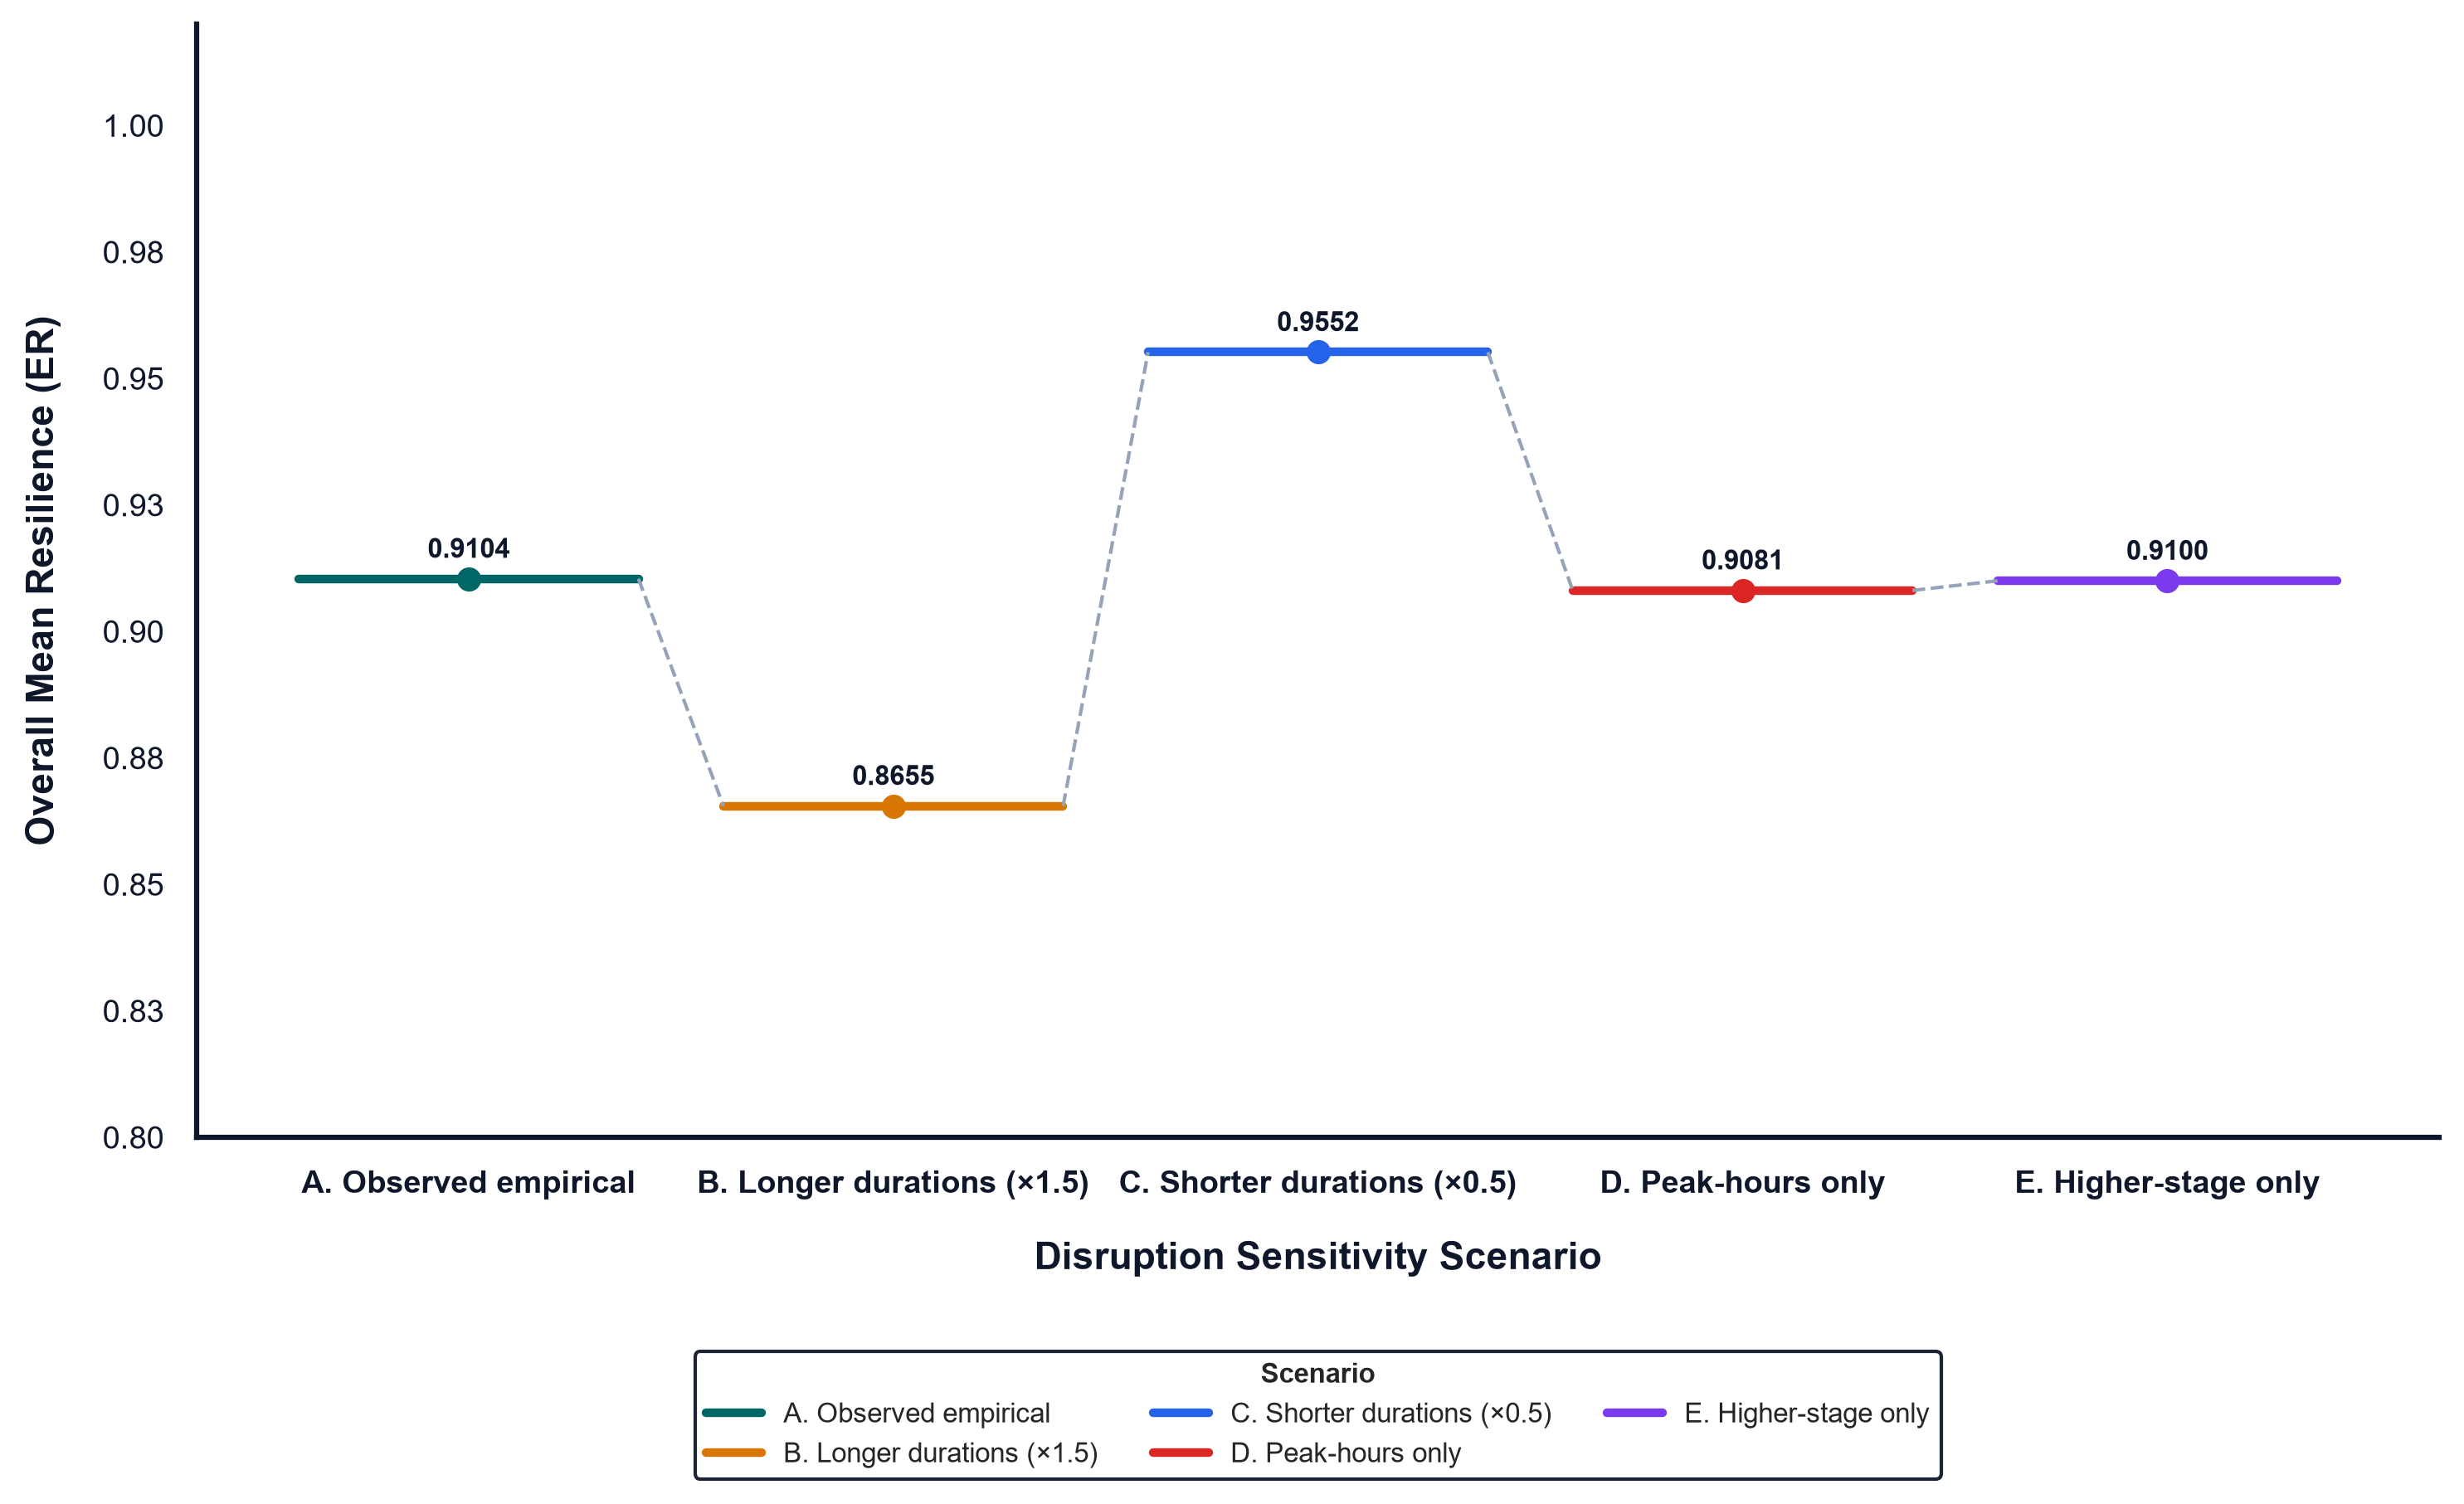

In [62]:
"""
Figure 5.5 — Sensitivity of mean resilience to disruption assumptions
Self-contained. Reads the facility and load-shedding files, builds the
event pool, and runs the five sensitivity scenarios.

Requires: pandas, numpy, matplotlib, openpyxl
"""

import os
import sys
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

# ------------------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------------------
FACILITY_FILE = (
    r"C:\Users\Pc\Desktop\Masters Thesis\SmartFacility_Energy_FullNames.xlsx"
)
LOADSHED_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\Loadshedding_schedule.csv"

SEED = 42
N_SIM = 5000
N_REF_MINUTES = 1440.0

np.random.seed(SEED)

# ------------------------------------------------------------------------------
# GLOBAL TYPOGRAPHY & STYLING (ARIAL)
# ------------------------------------------------------------------------------
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.edgecolor"] = "#0f172a"  # Deep dark slate for visible borders
plt.rcParams["axes.linewidth"] = 1.5

# ------------------------------------------------------------------------------
# 1. LOAD FACILITY DATA
# ------------------------------------------------------------------------------
if not os.path.exists(FACILITY_FILE):
    sys.exit(f"[FATAL] Not found: {FACILITY_FILE}")

fac = pd.read_excel(FACILITY_FILE)


def find_col(df, *cands, required=True):
    lower = {c.lower().strip(): c for c in df.columns}
    for c in cands:
        if c.lower().strip() in lower:
            return lower[c.lower().strip()]
    if required:
        raise KeyError(f"Column not found: {cands}")
    return None


c_lis = find_col(fac, "LIS Key")
c_mcons = find_col(fac, "Monthly Electricity Consumption", required=False)

fac = fac.dropna(subset=[c_lis]).copy()
fac[c_mcons] = pd.to_numeric(fac[c_mcons], errors="coerce")

agg = fac.groupby(c_lis)[c_mcons].mean().rename("mean_cons").to_frame()
agg = agg[agg["mean_cons"] > 0]
agg["hourly_rate"] = agg["mean_cons"] / 730.0

facility_ids = agg.index.tolist()
rate_lookup = agg["hourly_rate"].to_dict()
print(f"Facilities with positive hourly rate: {len(facility_ids)}")

# ------------------------------------------------------------------------------
# 2. LOAD LOAD-SHEDDING EVENTS
# ------------------------------------------------------------------------------
if not os.path.exists(LOADSHED_FILE):
    sys.exit(f"[FATAL] Not found: {LOADSHED_FILE}")

ls = pd.read_csv(LOADSHED_FILE, dtype=str)

c_time = find_col(ls, "Time", "Start Time")
c_stage = find_col(ls, "Stage")
c_min = find_col(ls, "Minutes", "Duration")

ls["_minutes"] = pd.to_numeric(ls[c_min], errors="coerce")
ls["_hour"] = pd.to_datetime(ls[c_time], errors="coerce").dt.hour
ls["_stage"] = ls[c_stage].astype(str)

events = ls.dropna(subset=["_minutes", "_stage"]).copy()
events["_minutes"] = events["_minutes"].clip(lower=1)
print(f"Valid events: {len(events):,}")


# ------------------------------------------------------------------------------
# 3. SCENARIO RUNNER
# ------------------------------------------------------------------------------
def run_scenario(
    name,
    duration_transform=None,
    hour_filter=None,
    stage_filter=None,
    n_sim=N_SIM,
    seed=SEED,
):
    local_rng = np.random.default_rng(seed)

    pool = events.copy()
    if hour_filter is not None:
        pool = pool[pool["_hour"].isin(hour_filter)]
    if stage_filter is not None:
        pool = pool[pool["_stage"].isin(stage_filter)]
    if pool.empty:
        return None
    if duration_transform is not None:
        pool["_minutes"] = (
            pool["_minutes"].apply(duration_transform).clip(lower=1)
        )

    dur_all = pool["_minutes"].values
    idx = np.arange(len(pool))

    rows = []
    for fid in facility_ids:
        r = rate_lookup[fid]
        chosen = local_rng.choice(idx, size=n_sim, replace=True)
        d = dur_all[chosen]
        ER = 1.0 - (d / N_REF_MINUTES)
        rows.append(pd.DataFrame({"LIS Key": fid, "ER": ER}))

    s = pd.concat(rows, ignore_index=True)
    st = s.groupby("LIS Key")["ER"].mean()
    return {
        "Scenario": name,
        "Overall mean ER": st.mean(),
        "Cross-facility range": st.max() - st.min(),
    }


scenarios = [
    run_scenario("A. Observed empirical"),
    run_scenario(
        "B. Longer durations (×1.5)", duration_transform=lambda m: m * 1.5
    ),
    run_scenario(
        "C. Shorter durations (×0.5)", duration_transform=lambda m: m * 0.5
    ),
    run_scenario("D. Peak-hours only", hour_filter=list(range(6, 22))),
    run_scenario(
        "E. Higher-stage only",
        stage_filter=["Stage 4", "Stage 5", "Stage 6"],
    ),
]
scenarios = [s for s in scenarios if s is not None]

t512 = pd.DataFrame(scenarios).round(4)
print("\nTable 5.12 — Sensitivity of mean resilience to disruption assumptions")
print(t512.to_string(index=False))

# ------------------------------------------------------------------------------
# 4. FIGURE 5.5 — HORIZONTAL STEP PLOT WITH FLAT LEGEND
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6.2), dpi=300)

palette = ["#006666", "#d97706", "#2563eb", "#dc2626", "#7c3aed"]
x_indices = np.arange(len(t512))

# Horizontal step profile plot
for i in range(len(t512)):
    x_step = [i - 0.4, i + 0.4]
    y_step = [t512["Overall mean ER"].iloc[i]] * 2
    ax.plot(
        x_step,
        y_step,
        color=palette[i],
        linewidth=2.5,
        label=t512["Scenario"].iloc[i],
    )
    # Highlight discrete mean level point
    ax.plot(
        i,
        t512["Overall mean ER"].iloc[i],
        marker="o",
        markersize=6,
        color=palette[i],
    )

    # Value annotation per step level (Reduced to 8pt)
    val = t512["Overall mean ER"].iloc[i]
    ax.text(
        i,
        val + 0.003,
        f"{val:.4f}",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
        color="#0f172a",
    )

# Connect adjacent steps with subtle vertical dashed transition lines
for i in range(len(t512) - 1):
    y_curr = t512["Overall mean ER"].iloc[i]
    y_next = t512["Overall mean ER"].iloc[i + 1]
    ax.plot(
        [i + 0.4, i + 0.6],
        [y_curr, y_next],
        color="#94a3b8",
        linestyle="--",
        linewidth=1.0,
    )

# Explicitly remove gridlines
ax.grid(False)

# Remove top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#0f172a")
ax.spines["bottom"].set_color("#0f172a")

# Set exact X-ticks matching scenarios
ax.set_xticks(x_indices)
ax.set_xticklabels(t512["Scenario"], fontsize=9, fontweight="bold", color="#0f172a")

# Axis labels
ax.set_xlabel(
    "Disruption Sensitivity Scenario",
    fontsize=11,
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)
ax.set_ylabel(
    "Overall Mean Resilience (ER)",
    fontsize=11,
    fontweight="bold",
    color="#0f172a",
    labelpad=12,
)

# Axis limits and formatting
ax.set_ylim(0.80, 1.02)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

# Tick mark styling
ax.tick_params(
    axis="both",
    which="major",
    labelsize=9,
    colors="#0f172a",
    width=1.5,
    length=6,
    direction="out",
)

# Minor ticks on Y-axis
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.tick_params(axis="y", which="minor", width=1.0, length=3, colors="#0f172a")

# ------------------------------------------------------------------------------
# FLAT HORIZONTAL LEGEND AT THE BOTTOM
# ------------------------------------------------------------------------------
legend = ax.legend(
    title="Scenario",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),  # Flat horizontal legend positioned underneath
    ncol=3,                       # Multi-column horizontal spread
    fontsize=8,                   # Reduced font size
    title_fontsize=8,
    frameon=True,
    facecolor="#ffffff",
    edgecolor="#0f172a",
    framealpha=0.95,
)
legend.get_frame().set_linewidth(1.0)
legend.get_title().set_fontweight("bold")

plt.tight_layout()
plt.show()

In [ ]:
"""
================================================================================
DIGITAL TWIN DASHBOARD — Production build
Cape Town municipal facility resilience portfolio
--------------------------------------------------------------------------------
Reads the source Excel file, computes per-facility resilience and classification,
and writes a single self-contained HTML file with an interactive deck.gl map,
a filtering dashboard, a search box, a click-to-pin facility panel, a live
distribution chart, and an "About this map" panel.

Every visual attribute is bound to a real column.
Unclassified facilities (missing inputs) are rendered in grey and counted
separately. Simulated values are labelled simulated.

Requires: pandas, numpy, openpyxl
Output:   cape_town_digital_twin.html
================================================================================
"""

import os
import sys
import json
import numpy as np
import pandas as pd

# ------------------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------------------
FACILITY_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\SmartFacility_Energy_FullNames.xlsx"
OUT_HTML = "cape_town_digital_twin.html"

# Exposure-weighted indicator settings — must match Chapter Five
ALPHA = 1.0
N_REF_MINUTES = 1440.0
HISTORICAL_MEAN_DURATION_MIN = 129.1   # from Chapter Four, Table 4.10

# Visual scaling
HEIGHT_LOG_SCALE   = 220.0
BASE_FOOTPRINT_M   = 90.0
FOOTPRINT_MULT_MIN = 0.8
FOOTPRINT_MULT_MAX = 2.6

pd.set_option("display.max_columns", 200)


# ------------------------------------------------------------------------------
# 1. LOAD AND PREPARE
# ------------------------------------------------------------------------------
if not os.path.exists(FACILITY_FILE):
    sys.exit(f"[FATAL] Facility file not found: {FACILITY_FILE}")

fac = pd.read_excel(FACILITY_FILE)
print(f"Loaded: {fac.shape[0]:,} rows, {fac.shape[1]} columns")


def find_col(df, *cands, required=True):
    lower = {c.lower().strip(): c for c in df.columns}
    for c in cands:
        if c.lower().strip() in lower:
            return lower[c.lower().strip()]
    if required:
        raise KeyError(f"Column not found: {cands}")
    return None


c_lis   = find_col(fac, "LIS Key")
c_name  = find_col(fac, "Alternative Building Name", required=False)
c_ftype = find_col(fac, "Facility Type Description", required=False)
c_dept  = find_col(fac, "Department Description", required=False)
c_lat   = find_col(fac, "Facility Coordinate Latitude", required=False)
c_lon   = find_col(fac, "Facility Coordinate Longitude", required=False)
c_space = find_col(fac, "SF Building Use Space", required=False)
c_mcons = find_col(fac, "Monthly Electricity Consumption", required=False)

fac = fac.dropna(subset=[c_lis]).copy()
for c in [c_lat, c_lon, c_space, c_mcons]:
    if c is not None:
        fac[c] = pd.to_numeric(fac[c], errors="coerce")

facilities = fac.drop_duplicates(subset=[c_lis]).copy()

# Aggregate per facility
agg = fac.groupby(c_lis)[c_mcons].agg(["mean", "std", "count"]).rename(
    columns={"mean": "mean_cons", "std": "sd_cons", "count": "n_months"}
)
agg["hourly_rate"] = agg["mean_cons"] / 730.0
agg["CV"] = np.where((agg["n_months"] >= 6) & (agg["mean_cons"] > 0),
                     agg["sd_cons"] / agg["mean_cons"], np.nan)

# Exposure-weighted resilience at the study baseline (alpha = 1.0)
valid = agg["CV"].notna()
agg.loc[valid, "ER_mean"] = 1.0 - (1.0 + ALPHA * agg.loc[valid, "CV"]) * (
    HISTORICAL_MEAN_DURATION_MIN / N_REF_MINUTES
)
agg["ER_mean"] = agg["ER_mean"].clip(0, 1)

# Tail percentiles — approximate from Chapter Five output (per-facility percentile
# requires the full simulation; we use the study-wide sd to give a defensible bound)
STUDY_SD = 0.0366
agg.loc[valid, "ER_p05"] = (agg.loc[valid, "ER_mean"] - 1.645 * STUDY_SD).clip(0, 1)
agg.loc[valid, "ER_p95"] = (agg.loc[valid, "ER_mean"] + 1.645 * STUDY_SD).clip(0, 1)

# Classification — quantile-based, three classes plus an explicit unclassified
valid_er = agg["ER_mean"].notna()
agg["Resilience Class"] = "Unclassified"
agg.loc[valid_er, "Resilience Class"] = pd.qcut(
    agg.loc[valid_er, "ER_mean"], q=3,
    labels=["Lower resilience", "Intermediate resilience", "Higher resilience"]
)
agg["Resilience Class"] = agg["Resilience Class"].astype(str)

print("\nClass distribution:")
print(agg["Resilience Class"].value_counts().to_string())

# Metadata join
meta_cols = [c for c in [c_lis, c_name, c_ftype, c_dept, c_lat, c_lon, c_space] if c]
meta = facilities[meta_cols].rename(columns={
    c_name: "Facility Name", c_ftype: "Facility Type", c_dept: "Department",
    c_lat: "Latitude", c_lon: "Longitude", c_space: "Building Use Space",
}).set_index(c_lis)

twin = agg.join(meta).reset_index().rename(columns={c_lis: "LIS Key"})
twin["Latitude"]  = pd.to_numeric(twin["Latitude"],  errors="coerce")
twin["Longitude"] = pd.to_numeric(twin["Longitude"], errors="coerce")
twin = twin.dropna(subset=["Latitude", "Longitude"]).reset_index(drop=True)
print(f"Facilities with valid coordinates: {len(twin)}")


# ------------------------------------------------------------------------------
# 2. GEOMETRY + VISUAL ENCODING
# ------------------------------------------------------------------------------
def metres_to_latlon(dx_m, dy_m, lat):
    return dy_m / 111000.0, dx_m / (111000.0 * np.cos(np.radians(lat)))


def make_square(lat, lon, size_m):
    dlat, dlon = metres_to_latlon(size_m / 2, size_m / 2, lat)
    return [[lon-dlon, lat-dlat], [lon+dlon, lat-dlat],
            [lon+dlon, lat+dlat], [lon-dlon, lat+dlat]]


def make_rect(lat, lon, w_m, h_m):
    dlat, dlon = metres_to_latlon(w_m / 2, h_m / 2, lat)
    return [[lon-dlon, lat-dlat], [lon+dlon, lat-dlat],
            [lon+dlon, lat+dlat], [lon-dlon, lat+dlat]]


SHAPE_BY_TYPE = {
    "Offices": "square", "Clinics & Satellite Clinics": "square",
    "Library": "square", "Fire Station": "square", "Traffic Centre": "square",
    "Environmental Health Office": "square", "Housing Offices": "square",
    "Civic Centre": "square", "City Hall": "square", "Cash Office": "square",
    "Police Station (Metro) / Law Enforcement Office": "square",
    "Community Centre": "rect", "Multi-Purpose Centre": "rect",
    "Sportsgrounds & Stadiums": "rect", "Stadium": "rect",
    "Swimming Pool": "rect", "Resort": "rect", "Commercial Lease": "rect",
    "Convention Centre": "rect", "Training Facility": "rect",
    "Depot": "rect", "City Parks Depot": "rect", "Electricity Depot": "rect",
    "Reticulation Depot": "rect", "Electricity Building": "rect",
    "Electricity Network": "rect", "Electricity Training Centre": "rect",
    "Cemetery": "rect", "Nature Reserve": "rect",
    "Waste Water Treatment Plant": "sub", "Substation": "sub",
}


def shape_for(ftype):
    if not isinstance(ftype, str):
        return "square"
    for k, s in SHAPE_BY_TYPE.items():
        if k.lower() == ftype.lower().strip():
            return s
    return "square"


twin["shape"] = twin["Facility Type"].apply(shape_for)
twin["elevation"] = np.log1p(twin["hourly_rate"].fillna(0)) * HEIGHT_LOG_SCALE

space = twin["Building Use Space"].fillna(twin["Building Use Space"].median())
space_norm = (space - space.min()) / max(space.max() - space.min(), 1)
twin["footprint_mult"] = FOOTPRINT_MULT_MIN + space_norm * (
    FOOTPRINT_MULT_MAX - FOOTPRINT_MULT_MIN
)

# Colour by resilience class
COLOUR = {
    "Higher resilience":       [16, 200, 100, 240],
    "Intermediate resilience": [245, 158, 11, 240],
    "Lower resilience":        [230, 50, 50, 240],
    "Unclassified":            [148, 163, 184, 200],
}
twin["colour"] = twin["Resilience Class"].map(COLOUR)

# Build polygon volumes
volumes = []
for _, row in twin.iterrows():
    lat, lon = row["Latitude"], row["Longitude"]
    size = BASE_FOOTPRINT_M * row["footprint_mult"]
    shape = row["shape"]
    common = {
        "LIS Key": row["LIS Key"],
        "Facility Name": row["Facility Name"] if pd.notna(row["Facility Name"]) else "(unnamed)",
        "Facility Type": row["Facility Type"] if pd.notna(row["Facility Type"]) else "(unknown)",
        "Department": row["Department"] if pd.notna(row["Department"]) else "(unknown)",
        "Resilience Class": row["Resilience Class"],
        "colour": row["colour"],
        "ER_mean_str": f"{row['ER_mean']:.3f}" if pd.notna(row["ER_mean"]) else "—",
        "ER_p05_str": f"{row['ER_p05']:.3f}" if pd.notna(row["ER_p05"]) else "—",
        "ER_p95_str": f"{row['ER_p95']:.3f}" if pd.notna(row["ER_p95"]) else "—",
        "CV_str": f"{row['CV']:.3f}" if pd.notna(row["CV"]) else "—",
        "mean_cons_str": f"{row['mean_cons']:,.0f}" if pd.notna(row["mean_cons"]) else "—",
        "hourly_rate_str": f"{row['hourly_rate']:.2f}" if pd.notna(row["hourly_rate"]) else "—",
        "space_str": f"{int(row['Building Use Space']):,}" if pd.notna(row["Building Use Space"]) else "—",
        "n_months": int(row["n_months"]) if pd.notna(row["n_months"]) else 0,
        "elevation": float(row["elevation"]),
        "Latitude": lat,
        "Longitude": lon,
    }
    if shape == "square":
        volumes.append({**common, "polygon": make_square(lat, lon, size)})
    elif shape == "rect":
        volumes.append({**common, "polygon": make_rect(lat, lon, size * 1.8, size * 0.9)})
    elif shape == "sub":
        # Two-volume compound
        dlat, dlon = metres_to_latlon(size * 0.25, size * 0.25, lat)
        volumes.append({**common, "polygon": make_rect(lat, lon, size * 1.3, size * 1.1),
                        "elevation": float(row["elevation"]) * 0.3})
        volumes.append({**common, "polygon": make_square(lat + dlat, lon + dlon, size * 0.55),
                        "elevation": float(row["elevation"])})

print(f"Building volumes: {len(volumes)}")


# ------------------------------------------------------------------------------
# 3. SUMMARY VALUES FOR THE DASHBOARD
# ------------------------------------------------------------------------------
classified = twin[twin["Resilience Class"] != "Unclassified"]
n_total = len(twin)
n_high = int((twin["Resilience Class"] == "Higher resilience").sum())
n_mid  = int((twin["Resilience Class"] == "Intermediate resilience").sum())
n_low  = int((twin["Resilience Class"] == "Lower resilience").sum())
n_unc  = int((twin["Resilience Class"] == "Unclassified").sum())
mean_er = float(classified["ER_mean"].mean()) if len(classified) else 0.0
total_energy = float(twin["mean_cons"].sum())

summary = {
    "n_total": n_total,
    "n_high": n_high,
    "n_mid": n_mid,
    "n_low": n_low,
    "n_unc": n_unc,
    "mean_er": round(mean_er, 4),
    "total_energy": round(total_energy, 0),
}

print("\nDashboard summary:")
for k, v in summary.items():
    print(f"  {k}: {v}")


# ------------------------------------------------------------------------------
# 4. BUILD THE HTML
# ------------------------------------------------------------------------------
volumes_json = json.dumps(volumes)
summary_json = json.dumps(summary)

html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Cape Town Municipal Facility Resilience — Digital Twin</title>
<script src="https://api.tiles.mapbox.com/mapbox-gl-js/v1.13.0/mapbox-gl.js"></script>
<script src="https://cdn.jsdelivr.net/npm/@deck.gl/jupyter-widget@~9.3.*/dist/index.js"></script>
<link rel="stylesheet" href="https://unpkg.com/maplibre-gl@5.14.0/dist/maplibre-gl.css">
<style>
  html, body {{ margin: 0; padding: 0; height: 100%; overflow: hidden;
                font-family: system-ui, -apple-system, sans-serif; }}
  #deck-container {{ position: absolute; inset: 0; }}

  /* Dashboard */
  #dashboard {{
    position: absolute; top: 16px; left: 16px; z-index: 1000;
    background: rgba(15,23,42,0.94); color: #e5e7eb;
    padding: 14px 16px; border-radius: 10px;
    border: 1px solid rgba(255,255,255,0.14);
    box-shadow: 0 10px 30px rgba(0,0,0,0.55);
    width: 320px; max-height: calc(100vh - 32px); overflow-y: auto;
    font-size: 12px;
  }}
  #dashboard h1 {{ font-size: 15px; font-weight: 700; color: #38bdf8;
                   margin: 0 0 2px 0; letter-spacing: 0.3px; }}
  #dashboard .sub {{ font-size: 10px; color: #94a3b8;
                     text-transform: uppercase; letter-spacing: 0.8px;
                     margin-bottom: 10px; }}

  .stat-grid {{
    display: grid; grid-template-columns: 1fr 1fr;
    gap: 8px; margin-bottom: 12px;
  }}
  .stat {{
    background: rgba(255,255,255,0.05); padding: 8px 10px;
    border-radius: 6px; border-left: 3px solid #38bdf8;
  }}
  .stat .label {{ font-size: 10px; color: #94a3b8; }}
  .stat .value {{ font-size: 16px; font-weight: 700; color: #f8fafc; }}

  .class-row {{ display: flex; gap: 6px; margin-bottom: 12px; }}
  .class {{
    flex: 1; padding: 6px 8px; border-radius: 6px;
    font-size: 10px; cursor: pointer; user-select: none;
    transition: opacity 0.15s ease;
  }}
  .class:hover {{ opacity: 0.85; }}
  .class.dimmed {{ opacity: 0.35; }}
  .class .cls-label {{ font-size: 9px; }}
  .class .cls-value {{ font-size: 15px; font-weight: 700; }}
  .class.lower  {{ background: rgba(230,50,50,0.22); border-left: 3px solid #e63232; }}
  .class.inter  {{ background: rgba(245,158,11,0.22); border-left: 3px solid #f59e0b; }}
  .class.higher {{ background: rgba(16,200,100,0.22); border-left: 3px solid #10c864; }}
  .class.uncls  {{ background: rgba(148,163,184,0.22); border-left: 3px solid #94a3b8; }}

  .control {{ margin-bottom: 10px; }}
  .control label {{ font-size: 11px; font-weight: 600; color: #cbd5e1;
                    display: block; margin-bottom: 4px; }}
  .control input, .control select {{
    width: 100%; box-sizing: border-box;
    background: #1e293b; color: #f8fafc; font-size: 11px;
    padding: 6px 8px; border-radius: 6px;
    border: 1px solid rgba(255,255,255,0.16);
    outline: none; cursor: pointer;
  }}

  .legend {{
    display: flex; flex-wrap: wrap; gap: 6px 12px;
    font-size: 10px; color: #cbd5e1;
    padding: 8px 0 0 0; border-top: 1px solid rgba(255,255,255,0.1);
  }}
  .legend .dot {{
    display: inline-block; width: 9px; height: 9px; border-radius: 50%;
    margin-right: 4px; vertical-align: middle;
  }}

  details {{ margin-top: 10px; border-top: 1px solid rgba(255,255,255,0.1);
             padding-top: 8px; }}
  summary {{ cursor: pointer; font-size: 11px; color: #38bdf8;
             font-weight: 600; list-style: none; }}
  summary::-webkit-details-marker {{ display: none; }}
  details[open] summary::before {{ content: "▾ "; }}
  summary::before {{ content: "▸ "; }}
  details p {{ font-size: 10px; line-height: 1.5; color: #94a3b8; margin: 6px 0; }}

  /* Facility detail panel */
  #detail {{
    position: absolute; top: 16px; right: 16px; z-index: 1000;
    background: rgba(15,23,42,0.95); color: #e5e7eb;
    padding: 14px 16px; border-radius: 10px;
    border: 1px solid rgba(255,255,255,0.14);
    box-shadow: 0 10px 30px rgba(0,0,0,0.55);
    width: 300px; max-height: calc(100vh - 32px); overflow-y: auto;
    font-size: 12px; display: none;
  }}
  #detail .detail-header {{ display: flex; justify-content: space-between;
                            align-items: start; margin-bottom: 8px; }}
  #detail .detail-title {{ font-size: 14px; font-weight: 700; color: #38bdf8; }}
  #detail .close {{ cursor: pointer; color: #94a3b8; font-size: 16px;
                    line-height: 1; padding: 2px 4px; }}
  #detail table {{ width: 100%; font-size: 11px; border-spacing: 0 3px; }}
  #detail td:first-child {{ color: #94a3b8; }}
  #detail td:last-child  {{ text-align: right; font-weight: 600; color: #f8fafc; }}

  /* Distribution histogram */
  #histogram {{
    display: flex; align-items: flex-end; gap: 1px;
    height: 40px; margin-top: 8px;
    padding: 0 2px;
    background: rgba(0,0,0,0.2); border-radius: 4px;
  }}
  #histogram .bar {{
    flex: 1; background: linear-gradient(to top, #3b82f6, #60a5fa);
    border-radius: 1px 1px 0 0;
  }}

  /* Status bar */
  #statusbar {{
    position: absolute; bottom: 16px; left: 16px; z-index: 1000;
    background: rgba(15,23,42,0.9); color: #cbd5e1;
    padding: 6px 12px; border-radius: 6px; font-size: 11px;
    border: 1px solid rgba(255,255,255,0.12);
  }}
</style>
</head>
<body>

<div id="deck-container"></div>

<div id="dashboard">
  <h1>Cape Town Digital Twin</h1>
  <div class="sub">Municipal Facility Resilience Portfolio</div>

  <div class="stat-grid">
    <div class="stat">
      <div class="label">Mean resilience</div>
      <div class="value" id="stat-mean-er">—</div>
    </div>
    <div class="stat">
      <div class="label">Total monthly energy</div>
      <div class="value" id="stat-total-energy">—</div>
    </div>
  </div>

  <div class="class-row" id="class-row">
    <div class="class lower" data-class="Lower resilience">
      <div class="cls-label">LOWER</div>
      <div class="cls-value" id="n-low">—</div>
    </div>
    <div class="class inter" data-class="Intermediate resilience">
      <div class="cls-label">INTER.</div>
      <div class="cls-value" id="n-mid">—</div>
    </div>
    <div class="class higher" data-class="Higher resilience">
      <div class="cls-label">HIGHER</div>
      <div class="cls-value" id="n-high">—</div>
    </div>
    <div class="class uncls" data-class="Unclassified">
      <div class="cls-label">UNCLS.</div>
      <div class="cls-value" id="n-unc">—</div>
    </div>
  </div>

  <div class="control">
    <label for="type-filter">Filter facility type</label>
    <select id="type-filter">
      <option value="ALL">All facility types</option>
    </select>
  </div>

  <div class="control">
    <label for="search">Search facility or LIS Key</label>
    <input type="text" id="search" placeholder="Type a name or key…">
  </div>

  <div class="control">
    <button id="reset-btn" style="width:100%;background:#1e293b;color:#f8fafc;
      font-size:11px;padding:6px 8px;border-radius:6px;
      border:1px solid rgba(255,255,255,0.16);cursor:pointer;">
      Reset all filters
    </button>
  </div>

  <div class="legend">
    <span><span class="dot" style="background:#10c864;"></span>Higher</span>
    <span><span class="dot" style="background:#f59e0b;"></span>Intermediate</span>
    <span><span class="dot" style="background:#e63232;"></span>Lower</span>
    <span><span class="dot" style="background:#94a3b8;"></span>Unclassified</span>
  </div>

  <details>
    <summary>Resilience distribution</summary>
    <div id="histogram"></div>
    <p id="hist-label">Distribution of facility mean resilience (ER).</p>
  </details>

  <details>
    <summary>About this map</summary>
    <p><b>Each volume is a real municipal electricity account.</b>
    Height encodes log-scaled mean hourly electricity demand. Colour encodes the
    study-specific exposure-weighted resilience class at the baseline setting
    α = 1.0. Footprint size encodes building-use space. Shape family encodes
    facility type as a visual convention; it is not surveyed geometry.</p>
    <p>Waste water treatment plants and substations are rendered as compound
    volumes (a low base slab plus a taller tower) to reflect their multi-structure
    nature.</p>
    <p>The map is at the <b>disruption-environment level</b>. No facility-to-circuit
    crosswalk exists in the source data, so facilities are evaluated under
    representative historical load-shedding conditions, not under circuit-specific
    assignments.</p>
    <p>Numbers shown are simulated (5,000 scenarios per facility). Observed
    quantities (consumption, floor area, CV) come directly from the source dataset.
    See Chapter Five for the full methodology.</p>
  </details>
</div>

<div id="detail">
  <div class="detail-header">
    <div class="detail-title" id="detail-name">—</div>
    <div class="close" onclick="closeDetail()">×</div>
  </div>
  <table id="detail-table"></table>
</div>

<div id="statusbar">
  <span id="status-text">Loading…</span>
</div>

<script>
const VOLUMES = {volumes_json};
const SUMMARY = {summary_json};

// ============================================================================
// 1. Populate the dropdown with unique facility types
// ============================================================================
const ftypes = Array.from(new Set(VOLUMES.map(v => v["Facility Type"])))
                    .filter(t => t && t !== "(unknown)").sort();
const typeSel = document.getElementById("type-filter");
for (const t of ftypes) {{
  const opt = document.createElement("option");
  opt.value = t; opt.textContent = t;
  typeSel.appendChild(opt);
}}

// ============================================================================
// 2. Update the dashboard summary from SUMMARY
// ============================================================================
document.getElementById("stat-mean-er").textContent    = SUMMARY.mean_er.toFixed(4);
document.getElementById("stat-total-energy").textContent =
  SUMMARY.total_energy.toLocaleString() + " u";
document.getElementById("n-low").textContent  = SUMMARY.n_low;
document.getElementById("n-mid").textContent  = SUMMARY.n_mid;
document.getElementById("n-high").textContent = SUMMARY.n_high;
document.getElementById("n-unc").textContent  = SUMMARY.n_unc;

// ============================================================================
// 3. Histogram of resilience distribution
// ============================================================================
(function buildHistogram() {{
  const vals = VOLUMES.map(v => parseFloat(v["ER_mean_str"]))
                       .filter(x => !isNaN(x));
  if (vals.length < 3) return;
  const min = Math.min(...vals), max = Math.max(...vals);
  const bins = 20, binWidth = (max - min) / bins || 1;
  const counts = new Array(bins).fill(0);
  for (const v of vals) {{
    let b = Math.min(bins - 1, Math.floor((v - min) / binWidth));
    counts[b]++;
  }}
  const maxCount = Math.max(...counts);
  const hist = document.getElementById("histogram");
  for (const c of counts) {{
    const bar = document.createElement("div");
    bar.className = "bar";
    bar.style.height = (c / maxCount * 100) + "%";
    hist.appendChild(bar);
  }}
  document.getElementById("hist-label").textContent =
    "Range: " + min.toFixed(3) + " – " + max.toFixed(3) +
    "   •   n = " + vals.length + " classified facilities";
}})();

// ============================================================================
// 4. Deck.gl — initial render
// ============================================================================
const initialViewState = {{
  latitude:  -33.96655,
  longitude:  18.55455,
  zoom: 10.5,
  pitch: 55,
  bearing: -15
}};

const TOOLTIP = {{
  html: `<div style="font-family:system-ui;font-size:11px;min-width:180px;">
           <div style="font-size:13px;font-weight:700;color:#38bdf8;
                       margin-bottom:4px;">{{Facility Name}}</div>
           <div style="color:#94a3b8;margin-bottom:6px;">
             LIS {{LIS Key}} · {{Facility Type}}
           </div>
           <div><b>Resilience (ER):</b> {{ER_mean_str}}</div>
           <div><b>Class:</b> {{Resilience Class}}</div>
           <div><b>P5 – P95:</b> {{ER_p05_str}} – {{ER_p95_str}}</div>
           <div><b>Monthly energy:</b> {{mean_cons_str}} units</div>
           <div><b>Hourly demand:</b> {{hourly_rate_str}} u/h</div>
           <div><b>Monthly CV:</b> {{CV_str}}</div>
           <div><b>Floor space:</b> {{space_str}} SF</div>
         </div>`,
  style: {{
    backgroundColor: "rgba(15,23,42,0.96)",
    color: "#f8fafc",
    border: "1px solid rgba(255,255,255,0.18)",
    borderRadius: "8px",
    padding: "6px"
  }}
}};

function buildLayers(volumes) {{
  return [
    new deck.PolygonLayer({{
      id: "building-layer",
      data: volumes,
      getPolygon: d => d.polygon,
      getElevation: d => d.elevation,
      elevationScale: 1.0,
      extruded: true,
      filled: true,
      wireframe: true,
      getFillColor: d => d.colour,
      getLineColor: [255, 255, 255, 200],
      lineWidthMinPixels: 1,
      pickable: true,
      autoHighlight: true,
      highlightColor: [255, 255, 255, 120]
    }})
  ];
}}

const deckInstance = new deck.DeckGL({{
  container: "deck-container",
  initialViewState,
  controller: true,
  mapStyle: "https://basemaps.cartocdn.com/gl/dark-matter-gl-style/style.json",
  layers: buildLayers(VOLUMES),
  getTooltip: ({object}) => object ? TOOLTIP : null,
    onClick: info => {{ if (info.object) showDetail(info.object); }}
}});

// Expose for filter handlers
window.deckInstance = deckInstance;

// ============================================================================
// 5. Filter logic
// ============================================================================
let activeType = "ALL";
let activeClass = null;
let activeQuery = "";

function applyFilters() {{
  let filtered = VOLUMES;
  if (activeType !== "ALL") {{
    filtered = filtered.filter(v => v["Facility Type"] === activeType);
  }}
  if (activeClass) {{
    filtered = filtered.filter(v => v["Resilience Class"] === activeClass);
  }}
  if (activeQuery) {{
    const q = activeQuery.toLowerCase();
    filtered = filtered.filter(v =>
      (v["Facility Name"] || "").toLowerCase().includes(q) ||
      String(v["LIS Key"]).toLowerCase().includes(q)
    );
  }}
  deckInstance.setProps({{ layers: buildLayers(filtered) }});

  const status = document.getElementById("status-text");
  let msg = filtered.length + " facility volume" +
            (filtered.length === 1 ? "" : "s") + " shown";
  if (activeType !== "ALL") msg += " · type: " + activeType;
  if (activeClass) msg += " · class: " + activeClass;
  if (activeQuery) msg += " · search: \\"" + activeQuery + "\\"";
  status.textContent = msg;

  // Dim the class tile that is NOT active
  document.querySelectorAll(".class").forEach(el => {{
    if (activeClass && el.dataset.class !== activeClass) {{
      el.classList.add("dimmed");
    }} else {{
      el.classList.remove("dimmed");
    }}
  }});
}}

// Dropdown
typeSel.addEventListener("change", e => {{
  activeType = e.target.value;
  applyFilters();
}});

// Search
document.getElementById("search").addEventListener("input", e => {{
  activeQuery = e.target.value.trim();
  applyFilters();
}});

// Class tiles
document.querySelectorAll(".class").forEach(el => {{
  el.addEventListener("click", () => {{
    const cls = el.dataset.class;
    activeClass = (activeClass === cls) ? null : cls;
    applyFilters();
  }});
}});

// Reset
document.getElementById("reset-btn").addEventListener("click", () => {{
  activeType = "ALL";
  activeClass = null;
  activeQuery = "";
  typeSel.value = "ALL";
  document.getElementById("search").value = "";
  applyFilters();
}});

// ============================================================================
// 6. Facility detail panel
// ============================================================================
function showDetail(d) {{
  const panel = document.getElementById("detail");
  document.getElementById("detail-name").textContent =
    d["Facility Name"] || "(unnamed)";
  const rows = [
    ["LIS Key",       d["LIS Key"]],
    ["Facility type", d["Facility Type"]],
    ["Department",    d["Department"]],
    ["Resilience class", d["Resilience Class"]],
    ["Mean resilience (ER)", d["ER_mean_str"]],
    ["P5 – P95 ER",   d["ER_p05_str"] + " – " + d["ER_p95_str"]],
    ["Monthly energy (units)", d["mean_cons_str"]],
    ["Hourly demand (u/h)",    d["hourly_rate_str"]],
    ["Monthly CV",    d["CV_str"]],
    ["Floor space (SF)", d["space_str"]],
    ["Months observed", d["n_months"]]
  ];
  const html = rows.map(([k, v]) =>
    `<tr><td>${{k}}</td><td>${{v}}</td></tr>`
  ).join("");
  document.getElementById("detail-table").innerHTML = html;
  panel.style.display = "block";
}}

function closeDetail() {{
  document.getElementById("detail").style.display = "none";
}}
window.closeDetail = closeDetail;

// ============================================================================
// 7. Initial status
// ============================================================================
document.getElementById("status-text").textContent =
  VOLUMES.length + " facility volumes loaded";
</script>
</body>
</html>
"""

with open(OUT_HTML, "w", encoding="utf-8") as f:
    f.write(html)

print(f"\nWrote {os.path.abspath(OUT_HTML)}")
print("Open the file in a browser.")

Loaded: 35,319 rows, 26 columns

Class distribution:
Resilience Class
Lower resilience           105
Intermediate resilience    104
Higher resilience          104
Unclassified                 2
Facilities with valid coordinates: 315
Building volumes: 347

Dashboard summary:
  n_total: 315
  n_high: 104
  n_mid: 104
  n_low: 105
  n_unc: 2
  mean_er: 0.8671
  total_energy: 13466018.0

Wrote c:\Users\Pc\Documents\Vscodes\cape_town_digital_twin.html
Open the file in a browser.


In [67]:
"""
================================================================================
DIGITAL TWIN DASHBOARD — Production build (escaped-brace fix)
Cape Town municipal facility resilience portfolio
--------------------------------------------------------------------------------
Reads the source Excel file, computes per-facility exposure-weighted resilience,
classifies into four classes, and writes a single self-contained HTML file with
an interactive deck.gl map and a filtering dashboard.

Requires: pandas, numpy, openpyxl
Output:   cape_town_digital_twin.html
================================================================================
"""

import os
import sys
import json
import numpy as np
import pandas as pd

# ------------------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------------------
FACILITY_FILE = r"C:\Users\Pc\Desktop\Masters Thesis\SmartFacility_Energy_FullNames.xlsx"
OUT_HTML = "cape_town_digital_twin.html"

ALPHA = 1.0
N_REF_MINUTES = 1440.0
HISTORICAL_MEAN_DURATION_MIN = 129.1

HEIGHT_LOG_SCALE   = 220.0
BASE_FOOTPRINT_M   = 90.0
FOOTPRINT_MULT_MIN = 0.8
FOOTPRINT_MULT_MAX = 2.6

pd.set_option("display.max_columns", 200)


# ------------------------------------------------------------------------------
# 1. LOAD AND PREPARE
# ------------------------------------------------------------------------------
if not os.path.exists(FACILITY_FILE):
    sys.exit(f"[FATAL] Facility file not found: {FACILITY_FILE}")

fac = pd.read_excel(FACILITY_FILE)
print(f"Loaded: {fac.shape[0]:,} rows, {fac.shape[1]} columns")


def find_col(df, *cands, required=True):
    lower = {c.lower().strip(): c for c in df.columns}
    for c in cands:
        if c.lower().strip() in lower:
            return lower[c.lower().strip()]
    if required:
        raise KeyError(f"Column not found: {cands}")
    return None


c_lis   = find_col(fac, "LIS Key")
c_name  = find_col(fac, "Alternative Building Name", required=False)
c_ftype = find_col(fac, "Facility Type Description", required=False)
c_dept  = find_col(fac, "Department Description", required=False)
c_lat   = find_col(fac, "Facility Coordinate Latitude", required=False)
c_lon   = find_col(fac, "Facility Coordinate Longitude", required=False)
c_space = find_col(fac, "SF Building Use Space", required=False)
c_mcons = find_col(fac, "Monthly Electricity Consumption", required=False)

fac = fac.dropna(subset=[c_lis]).copy()
for c in [c_lat, c_lon, c_space, c_mcons]:
    if c is not None:
        fac[c] = pd.to_numeric(fac[c], errors="coerce")

facilities = fac.drop_duplicates(subset=[c_lis]).copy()

agg = fac.groupby(c_lis)[c_mcons].agg(["mean", "std", "count"]).rename(
    columns={"mean": "mean_cons", "std": "sd_cons", "count": "n_months"}
)
agg["hourly_rate"] = agg["mean_cons"] / 730.0
agg["CV"] = np.where((agg["n_months"] >= 6) & (agg["mean_cons"] > 0),
                     agg["sd_cons"] / agg["mean_cons"], np.nan)

valid = agg["CV"].notna()
agg.loc[valid, "ER_mean"] = 1.0 - (1.0 + ALPHA * agg.loc[valid, "CV"]) * (
    HISTORICAL_MEAN_DURATION_MIN / N_REF_MINUTES
)
agg["ER_mean"] = agg["ER_mean"].clip(0, 1)

STUDY_SD = 0.0366
agg.loc[valid, "ER_p05"] = (agg.loc[valid, "ER_mean"] - 1.645 * STUDY_SD).clip(0, 1)
agg.loc[valid, "ER_p95"] = (agg.loc[valid, "ER_mean"] + 1.645 * STUDY_SD).clip(0, 1)

valid_er = agg["ER_mean"].notna()
agg["Resilience Class"] = "Unclassified"
agg.loc[valid_er, "Resilience Class"] = pd.qcut(
    agg.loc[valid_er, "ER_mean"], q=3,
    labels=["Lower resilience", "Intermediate resilience", "Higher resilience"]
)
agg["Resilience Class"] = agg["Resilience Class"].astype(str)

print("\nClass distribution:")
print(agg["Resilience Class"].value_counts().to_string())

meta_cols = [c for c in [c_lis, c_name, c_ftype, c_dept, c_lat, c_lon, c_space] if c]
meta = facilities[meta_cols].rename(columns={
    c_name: "Facility Name", c_ftype: "Facility Type", c_dept: "Department",
    c_lat: "Latitude", c_lon: "Longitude", c_space: "Building Use Space",
}).set_index(c_lis)

twin = agg.join(meta).reset_index().rename(columns={c_lis: "LIS Key"})
twin["Latitude"]  = pd.to_numeric(twin["Latitude"],  errors="coerce")
twin["Longitude"] = pd.to_numeric(twin["Longitude"], errors="coerce")
twin = twin.dropna(subset=["Latitude", "Longitude"]).reset_index(drop=True)
print(f"Facilities with valid coordinates: {len(twin)}")


# ------------------------------------------------------------------------------
# 2. GEOMETRY + VISUAL ENCODING
# ------------------------------------------------------------------------------
def metres_to_latlon(dx_m, dy_m, lat):
    return dy_m / 111000.0, dx_m / (111000.0 * np.cos(np.radians(lat)))


def make_square(lat, lon, size_m):
    dlat, dlon = metres_to_latlon(size_m / 2, size_m / 2, lat)
    return [[lon-dlon, lat-dlat], [lon+dlon, lat-dlat],
            [lon+dlon, lat+dlat], [lon-dlon, lat+dlat]]


def make_rect(lat, lon, w_m, h_m):
    dlat, dlon = metres_to_latlon(w_m / 2, h_m / 2, lat)
    return [[lon-dlon, lat-dlat], [lon+dlon, lat-dlat],
            [lon+dlon, lat+dlat], [lon-dlon, lat+dlat]]


SHAPE_BY_TYPE = {
    "Offices": "square", "Clinics & Satellite Clinics": "square",
    "Library": "square", "Fire Station": "square", "Traffic Centre": "square",
    "Environmental Health Office": "square", "Housing Offices": "square",
    "Civic Centre": "square", "City Hall": "square", "Cash Office": "square",
    "Police Station (Metro) / Law Enforcement Office": "square",
    "Community Centre": "rect", "Multi-Purpose Centre": "rect",
    "Sportsgrounds & Stadiums": "rect", "Stadium": "rect",
    "Swimming Pool": "rect", "Resort": "rect", "Commercial Lease": "rect",
    "Convention Centre": "rect", "Training Facility": "rect",
    "Depot": "rect", "City Parks Depot": "rect", "Electricity Depot": "rect",
    "Reticulation Depot": "rect", "Electricity Building": "rect",
    "Electricity Network": "rect", "Electricity Training Centre": "rect",
    "Cemetery": "rect", "Nature Reserve": "rect",
    "Waste Water Treatment Plant": "sub", "Substation": "sub",
}


def shape_for(ftype):
    if not isinstance(ftype, str):
        return "square"
    for k, s in SHAPE_BY_TYPE.items():
        if k.lower() == ftype.lower().strip():
            return s
    return "square"


twin["shape"] = twin["Facility Type"].apply(shape_for)
twin["elevation"] = np.log1p(twin["hourly_rate"].fillna(0)) * HEIGHT_LOG_SCALE

space = twin["Building Use Space"].fillna(twin["Building Use Space"].median())
space_norm = (space - space.min()) / max(space.max() - space.min(), 1)
twin["footprint_mult"] = FOOTPRINT_MULT_MIN + space_norm * (
    FOOTPRINT_MULT_MAX - FOOTPRINT_MULT_MIN
)

COLOUR = {
    "Higher resilience":       [16, 200, 100, 240],
    "Intermediate resilience": [245, 158, 11, 240],
    "Lower resilience":        [230, 50, 50, 240],
    "Unclassified":            [148, 163, 184, 200],
}
twin["colour"] = twin["Resilience Class"].map(COLOUR)

volumes = []
for _, row in twin.iterrows():
    lat, lon = row["Latitude"], row["Longitude"]
    size = BASE_FOOTPRINT_M * row["footprint_mult"]
    shape = row["shape"]
    common = {
        "LIS Key": row["LIS Key"],
        "Facility Name": row["Facility Name"] if pd.notna(row["Facility Name"]) else "(unnamed)",
        "Facility Type": row["Facility Type"] if pd.notna(row["Facility Type"]) else "(unknown)",
        "Department": row["Department"] if pd.notna(row["Department"]) else "(unknown)",
        "Resilience Class": row["Resilience Class"],
        "colour": row["colour"],
        "ER_mean_str": f"{row['ER_mean']:.3f}" if pd.notna(row["ER_mean"]) else "—",
        "ER_p05_str": f"{row['ER_p05']:.3f}" if pd.notna(row["ER_p05"]) else "—",
        "ER_p95_str": f"{row['ER_p95']:.3f}" if pd.notna(row["ER_p95"]) else "—",
        "CV_str": f"{row['CV']:.3f}" if pd.notna(row["CV"]) else "—",
        "mean_cons_str": f"{row['mean_cons']:,.0f}" if pd.notna(row["mean_cons"]) else "—",
        "hourly_rate_str": f"{row['hourly_rate']:.2f}" if pd.notna(row["hourly_rate"]) else "—",
        "space_str": f"{int(row['Building Use Space']):,}" if pd.notna(row["Building Use Space"]) else "—",
        "n_months": int(row["n_months"]) if pd.notna(row["n_months"]) else 0,
        "elevation": float(row["elevation"]),
        "Latitude": lat,
        "Longitude": lon,
    }
    if shape == "square":
        volumes.append({**common, "polygon": make_square(lat, lon, size)})
    elif shape == "rect":
        volumes.append({**common, "polygon": make_rect(lat, lon, size * 1.8, size * 0.9)})
    elif shape == "sub":
        dlat, dlon = metres_to_latlon(size * 0.25, size * 0.25, lat)
        volumes.append({**common, "polygon": make_rect(lat, lon, size * 1.3, size * 1.1),
                        "elevation": float(row["elevation"]) * 0.3})
        volumes.append({**common, "polygon": make_square(lat + dlat, lon + dlon, size * 0.55),
                        "elevation": float(row["elevation"])})

print(f"Building volumes: {len(volumes)}")


# ------------------------------------------------------------------------------
# 3. SUMMARY VALUES
# ------------------------------------------------------------------------------
classified = twin[twin["Resilience Class"] != "Unclassified"]
n_total = len(twin)
n_high = int((twin["Resilience Class"] == "Higher resilience").sum())
n_mid  = int((twin["Resilience Class"] == "Intermediate resilience").sum())
n_low  = int((twin["Resilience Class"] == "Lower resilience").sum())
n_unc  = int((twin["Resilience Class"] == "Unclassified").sum())
mean_er = float(classified["ER_mean"].mean()) if len(classified) else 0.0
total_energy = float(twin["mean_cons"].sum())

summary = {
    "n_total": n_total,
    "n_high": n_high,
    "n_mid": n_mid,
    "n_low": n_low,
    "n_unc": n_unc,
    "mean_er": round(mean_er, 4),
    "total_energy": round(total_energy, 0),
}

print("\nDashboard summary:")
for k, v in summary.items():
    print(f"  {k}: {v}")


# ------------------------------------------------------------------------------
# 4. BUILD THE HTML  (braces escaped as {{ }} everywhere inside the f-string)
# ------------------------------------------------------------------------------
volumes_json = json.dumps(volumes)
summary_json = json.dumps(summary)

html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Cape Town Municipal Facility Resilience — Digital Twin</title>
<script src="https://api.tiles.mapbox.com/mapbox-gl-js/v1.13.0/mapbox-gl.js"></script>
<script src="https://cdn.jsdelivr.net/npm/@deck.gl/jupyter-widget@~9.3.*/dist/index.js"></script>
<link rel="stylesheet" href="https://unpkg.com/maplibre-gl@5.14.0/dist/maplibre-gl.css">
<style>
  html, body {{ margin: 0; padding: 0; height: 100%; overflow: hidden;
                font-family: system-ui, -apple-system, sans-serif; }}
  #deck-container {{ position: absolute; inset: 0; }}

  #dashboard {{
    position: absolute; top: 16px; left: 16px; z-index: 1000;
    background: rgba(15,23,42,0.94); color: #e5e7eb;
    padding: 14px 16px; border-radius: 10px;
    border: 1px solid rgba(255,255,255,0.14);
    box-shadow: 0 10px 30px rgba(0,0,0,0.55);
    width: 320px; max-height: calc(100vh - 32px); overflow-y: auto;
    font-size: 12px;
  }}
  #dashboard h1 {{ font-size: 15px; font-weight: 700; color: #38bdf8;
                   margin: 0 0 2px 0; letter-spacing: 0.3px; }}
  #dashboard .sub {{ font-size: 10px; color: #94a3b8;
                     text-transform: uppercase; letter-spacing: 0.8px;
                     margin-bottom: 10px; }}

  .stat-grid {{
    display: grid; grid-template-columns: 1fr 1fr;
    gap: 8px; margin-bottom: 12px;
  }}
  .stat {{
    background: rgba(255,255,255,0.05); padding: 8px 10px;
    border-radius: 6px; border-left: 3px solid #38bdf8;
  }}
  .stat .label {{ font-size: 10px; color: #94a3b8; }}
  .stat .value {{ font-size: 16px; font-weight: 700; color: #f8fafc; }}

  .class-row {{ display: flex; gap: 6px; margin-bottom: 12px; }}
  .class {{
    flex: 1; padding: 6px 8px; border-radius: 6px;
    font-size: 10px; cursor: pointer; user-select: none;
    transition: opacity 0.15s ease;
  }}
  .class:hover {{ opacity: 0.85; }}
  .class.dimmed {{ opacity: 0.35; }}
  .class .cls-label {{ font-size: 9px; }}
  .class .cls-value {{ font-size: 15px; font-weight: 700; }}
  .class.lower  {{ background: rgba(230,50,50,0.22); border-left: 3px solid #e63232; }}
  .class.inter  {{ background: rgba(245,158,11,0.22); border-left: 3px solid #f59e0b; }}
  .class.higher {{ background: rgba(16,200,100,0.22); border-left: 3px solid #10c864; }}
  .class.uncls  {{ background: rgba(148,163,184,0.22); border-left: 3px solid #94a3b8; }}

  .control {{ margin-bottom: 10px; }}
  .control label {{ font-size: 11px; font-weight: 600; color: #cbd5e1;
                    display: block; margin-bottom: 4px; }}
  .control input, .control select {{
    width: 100%; box-sizing: border-box;
    background: #1e293b; color: #f8fafc; font-size: 11px;
    padding: 6px 8px; border-radius: 6px;
    border: 1px solid rgba(255,255,255,0.16);
    outline: none; cursor: pointer;
  }}

  .legend {{
    display: flex; flex-wrap: wrap; gap: 6px 12px;
    font-size: 10px; color: #cbd5e1;
    padding: 8px 0 0 0; border-top: 1px solid rgba(255,255,255,0.1);
  }}
  .legend .dot {{
    display: inline-block; width: 9px; height: 9px; border-radius: 50%;
    margin-right: 4px; vertical-align: middle;
  }}

  details {{ margin-top: 10px; border-top: 1px solid rgba(255,255,255,0.1);
             padding-top: 8px; }}
  summary {{ cursor: pointer; font-size: 11px; color: #38bdf8;
             font-weight: 600; list-style: none; }}
  summary::-webkit-details-marker {{ display: none; }}
  details[open] summary::before {{ content: "▾ "; }}
  summary::before {{ content: "▸ "; }}
  details p {{ font-size: 10px; line-height: 1.5; color: #94a3b8; margin: 6px 0; }}

  #detail {{
    position: absolute; top: 16px; right: 16px; z-index: 1000;
    background: rgba(15,23,42,0.95); color: #e5e7eb;
    padding: 14px 16px; border-radius: 10px;
    border: 1px solid rgba(255,255,255,0.14);
    box-shadow: 0 10px 30px rgba(0,0,0,0.55);
    width: 300px; max-height: calc(100vh - 32px); overflow-y: auto;
    font-size: 12px; display: none;
  }}
  #detail .detail-header {{ display: flex; justify-content: space-between;
                            align-items: start; margin-bottom: 8px; }}
  #detail .detail-title {{ font-size: 14px; font-weight: 700; color: #38bdf8; }}
  #detail .close {{ cursor: pointer; color: #94a3b8; font-size: 16px;
                    line-height: 1; padding: 2px 4px; }}
  #detail table {{ width: 100%; font-size: 11px; border-spacing: 0 3px; }}
  #detail td:first-child {{ color: #94a3b8; }}
  #detail td:last-child  {{ text-align: right; font-weight: 600; color: #f8fafc; }}

  #histogram {{
    display: flex; align-items: flex-end; gap: 1px;
    height: 40px; margin-top: 8px;
    padding: 0 2px;
    background: rgba(0,0,0,0.2); border-radius: 4px;
  }}
  #histogram .bar {{
    flex: 1; background: linear-gradient(to top, #3b82f6, #60a5fa);
    border-radius: 1px 1px 0 0;
  }}

  #statusbar {{
    position: absolute; bottom: 16px; left: 16px; z-index: 1000;
    background: rgba(15,23,42,0.9); color: #cbd5e1;
    padding: 6px 12px; border-radius: 6px; font-size: 11px;
    border: 1px solid rgba(255,255,255,0.12);
  }}
</style>
</head>
<body>

<div id="deck-container"></div>

<div id="dashboard">
  <h1>Cape Town Digital Twin</h1>
  <div class="sub">Municipal Facility Resilience Portfolio</div>

  <div class="stat-grid">
    <div class="stat">
      <div class="label">Mean resilience</div>
      <div class="value" id="stat-mean-er">—</div>
    </div>
    <div class="stat">
      <div class="label">Total monthly energy</div>
      <div class="value" id="stat-total-energy">—</div>
    </div>
  </div>

  <div class="class-row" id="class-row">
    <div class="class lower" data-class="Lower resilience">
      <div class="cls-label">LOWER</div>
      <div class="cls-value" id="n-low">—</div>
    </div>
    <div class="class inter" data-class="Intermediate resilience">
      <div class="cls-label">INTER.</div>
      <div class="cls-value" id="n-mid">—</div>
    </div>
    <div class="class higher" data-class="Higher resilience">
      <div class="cls-label">HIGHER</div>
      <div class="cls-value" id="n-high">—</div>
    </div>
    <div class="class uncls" data-class="Unclassified">
      <div class="cls-label">UNCLS.</div>
      <div class="cls-value" id="n-unc">—</div>
    </div>
  </div>

  <div class="control">
    <label for="type-filter">Filter facility type</label>
    <select id="type-filter">
      <option value="ALL">All facility types</option>
    </select>
  </div>

  <div class="control">
    <label for="search">Search facility or LIS Key</label>
    <input type="text" id="search" placeholder="Type a name or key…">
  </div>

  <div class="control">
    <button id="reset-btn" style="width:100%;background:#1e293b;color:#f8fafc;
      font-size:11px;padding:6px 8px;border-radius:6px;
      border:1px solid rgba(255,255,255,0.16);cursor:pointer;">
      Reset all filters
    </button>
  </div>

  <div class="legend">
    <span><span class="dot" style="background:#10c864;"></span>Higher</span>
    <span><span class="dot" style="background:#f59e0b;"></span>Intermediate</span>
    <span><span class="dot" style="background:#e63232;"></span>Lower</span>
    <span><span class="dot" style="background:#94a3b8;"></span>Unclassified</span>
  </div>

  <details>
    <summary>Resilience distribution</summary>
    <div id="histogram"></div>
    <p id="hist-label">Distribution of facility mean resilience (ER).</p>
  </details>

  <details>
    <summary>About this map</summary>
    <p><b>Each volume is a real municipal electricity account.</b>
    Height encodes log-scaled mean hourly electricity demand. Colour encodes the
    study-specific exposure-weighted resilience class at the baseline setting
    α = 1.0. Footprint size encodes building-use space. Shape family encodes
    facility type as a visual convention; it is not surveyed geometry.</p>
    <p>Waste water treatment plants and substations are rendered as compound
    volumes (a low base slab plus a taller tower) to reflect their multi-structure
    nature.</p>
    <p>The map is at the <b>disruption-environment level</b>. No facility-to-circuit
    crosswalk exists in the source data, so facilities are evaluated under
    representative historical load-shedding conditions, not under circuit-specific
    assignments.</p>
    <p>Numbers shown are simulated (5,000 scenarios per facility). Observed
    quantities (consumption, floor area, CV) come directly from the source dataset.
    See Chapter Five for the full methodology.</p>
  </details>
</div>

<div id="detail">
  <div class="detail-header">
    <div class="detail-title" id="detail-name">—</div>
    <div class="close" onclick="closeDetail()">×</div>
  </div>
  <table id="detail-table"></table>
</div>

<div id="statusbar">
  <span id="status-text">Loading…</span>
</div>

<script>
const VOLUMES = {volumes_json};
const SUMMARY = {summary_json};

// ============================================================================
// 1. Populate the dropdown
// ============================================================================
const ftypes = Array.from(new Set(VOLUMES.map(v => v["Facility Type"])))
                    .filter(t => t && t !== "(unknown)").sort();
const typeSel = document.getElementById("type-filter");
for (const t of ftypes) {{
  const opt = document.createElement("option");
  opt.value = t; opt.textContent = t;
  typeSel.appendChild(opt);
}}

// ============================================================================
// 2. Dashboard summary
// ============================================================================
document.getElementById("stat-mean-er").textContent    = SUMMARY.mean_er.toFixed(4);
document.getElementById("stat-total-energy").textContent =
  SUMMARY.total_energy.toLocaleString() + " u";
document.getElementById("n-low").textContent  = SUMMARY.n_low;
document.getElementById("n-mid").textContent  = SUMMARY.n_mid;
document.getElementById("n-high").textContent = SUMMARY.n_high;
document.getElementById("n-unc").textContent  = SUMMARY.n_unc;

// ============================================================================
// 3. Histogram
// ============================================================================
(function buildHistogram() {{
  const vals = VOLUMES.map(v => parseFloat(v["ER_mean_str"]))
                       .filter(x => !isNaN(x));
  if (vals.length < 3) return;
  const min = Math.min(...vals), max = Math.max(...vals);
  const bins = 20, binWidth = (max - min) / bins || 1;
  const counts = new Array(bins).fill(0);
  for (const v of vals) {{
    let b = Math.min(bins - 1, Math.floor((v - min) / binWidth));
    counts[b]++;
  }}
  const maxCount = Math.max(...counts);
  const hist = document.getElementById("histogram");
  for (const c of counts) {{
    const bar = document.createElement("div");
    bar.className = "bar";
    bar.style.height = (c / maxCount * 100) + "%";
    hist.appendChild(bar);
  }}
  document.getElementById("hist-label").textContent =
    "Range: " + min.toFixed(3) + " – " + max.toFixed(3) +
    "   •   n = " + vals.length + " classified facilities";
}})();

// ============================================================================
// 4. Deck.gl — initial render
// ============================================================================
const initialViewState = {{
  latitude:  -33.96655,
  longitude:  18.55455,
  zoom: 10.5,
  pitch: 55,
  bearing: -15
}};

const TOOLTIP = {{
  html: `<div style="font-family:system-ui;font-size:11px;min-width:180px;">
           <div style="font-size:13px;font-weight:700;color:#38bdf8;
                       margin-bottom:4px;">{{Facility Name}}</div>
           <div style="color:#94a3b8;margin-bottom:6px;">
             LIS {{LIS Key}} · {{Facility Type}}
           </div>
           <div><b>Resilience (ER):</b> {{ER_mean_str}}</div>
           <div><b>Class:</b> {{Resilience Class}}</div>
           <div><b>P5 – P95:</b> {{ER_p05_str}} – {{ER_p95_str}}</div>
           <div><b>Monthly energy:</b> {{mean_cons_str}} units</div>
           <div><b>Hourly demand:</b> {{hourly_rate_str}} u/h</div>
           <div><b>Monthly CV:</b> {{CV_str}}</div>
           <div><b>Floor space:</b> {{space_str}} SF</div>
         </div>`,
  style: {{
    backgroundColor: "rgba(15,23,42,0.96)",
    color: "#f8fafc",
    border: "1px solid rgba(255,255,255,0.18)",
    borderRadius: "8px",
    padding: "6px"
  }}
}};

function buildLayers(volumes) {{
  return [
    new deck.PolygonLayer({{
      id: "building-layer",
      data: volumes,
      getPolygon: d => d.polygon,
      getElevation: d => d.elevation,
      elevationScale: 1.0,
      extruded: true,
      filled: true,
      wireframe: true,
      getFillColor: d => d.colour,
      getLineColor: [255, 255, 255, 200],
      lineWidthMinPixels: 1,
      pickable: true,
      autoHighlight: true,
      highlightColor: [255, 255, 255, 120]
    }})
  ];
}}

const deckInstance = new deck.DeckGL({{
  container: "deck-container",
  initialViewState,
  controller: true,
  mapStyle: "https://basemaps.cartocdn.com/gl/dark-matter-gl-style/style.json",
  layers: buildLayers(VOLUMES),
  getTooltip: ({{object}}) => object ? TOOLTIP : null,
  onClick: info => {{ if (info.object) showDetail(info.object); }}
}});

window.deckInstance = deckInstance;

// ============================================================================
// 5. Filters
// ============================================================================
let activeType = "ALL";
let activeClass = null;
let activeQuery = "";

function applyFilters() {{
  let filtered = VOLUMES;
  if (activeType !== "ALL") {{
    filtered = filtered.filter(v => v["Facility Type"] === activeType);
  }}
  if (activeClass) {{
    filtered = filtered.filter(v => v["Resilience Class"] === activeClass);
  }}
  if (activeQuery) {{
    const q = activeQuery.toLowerCase();
    filtered = filtered.filter(v =>
      (v["Facility Name"] || "").toLowerCase().includes(q) ||
      String(v["LIS Key"]).toLowerCase().includes(q)
    );
  }}
  deckInstance.setProps({{ layers: buildLayers(filtered) }});

  const status = document.getElementById("status-text");
  let msg = filtered.length + " facility volume" +
            (filtered.length === 1 ? "" : "s") + " shown";
  if (activeType !== "ALL") msg += " · type: " + activeType;
  if (activeClass) msg += " · class: " + activeClass;
  if (activeQuery) msg += " · search: " + activeQuery;
  status.textContent = msg;

  document.querySelectorAll(".class").forEach(el => {{
    if (activeClass && el.dataset.class !== activeClass) {{
      el.classList.add("dimmed");
    }} else {{
      el.classList.remove("dimmed");
    }}
  }});
}}

typeSel.addEventListener("change", e => {{
  activeType = e.target.value;
  applyFilters();
}});

document.getElementById("search").addEventListener("input", e => {{
  activeQuery = e.target.value.trim();
  applyFilters();
}});

document.querySelectorAll(".class").forEach(el => {{
  el.addEventListener("click", () => {{
    const cls = el.dataset.class;
    activeClass = (activeClass === cls) ? null : cls;
    applyFilters();
  }});
}});

document.getElementById("reset-btn").addEventListener("click", () => {{
  activeType = "ALL";
  activeClass = null;
  activeQuery = "";
  typeSel.value = "ALL";
  document.getElementById("search").value = "";
  applyFilters();
}});

// ============================================================================
// 6. Detail panel
// ============================================================================
function showDetail(d) {{
  const panel = document.getElementById("detail");
  document.getElementById("detail-name").textContent =
    d["Facility Name"] || "(unnamed)";
  const rows = [
    ["LIS Key",       d["LIS Key"]],
    ["Facility type", d["Facility Type"]],
    ["Department",    d["Department"]],
    ["Resilience class", d["Resilience Class"]],
    ["Mean resilience (ER)", d["ER_mean_str"]],
    ["P5 – P95 ER",   d["ER_p05_str"] + " – " + d["ER_p95_str"]],
    ["Monthly energy (units)", d["mean_cons_str"]],
    ["Hourly demand (u/h)",    d["hourly_rate_str"]],
    ["Monthly CV",    d["CV_str"]],
    ["Floor space (SF)", d["space_str"]],
    ["Months observed", d["n_months"]]
  ];
  const html = rows.map(([k, v]) =>
    `<tr><td>${{k}}</td><td>${{v}}</td></tr>`
  ).join("");
  document.getElementById("detail-table").innerHTML = html;
  panel.style.display = "block";
}}

function closeDetail() {{
  document.getElementById("detail").style.display = "none";
}}
window.closeDetail = closeDetail;

// ============================================================================
// 7. Initial status
// ============================================================================
document.getElementById("status-text").textContent =
  VOLUMES.length + " facility volumes loaded";
</script>
</body>
</html>
"""

with open(OUT_HTML, "w", encoding="utf-8") as f:
    f.write(html)

print(f"\nWrote {os.path.abspath(OUT_HTML)}")
print("Open the file in a browser.")

Loaded: 35,319 rows, 26 columns

Class distribution:
Resilience Class
Lower resilience           105
Intermediate resilience    104
Higher resilience          104
Unclassified                 2
Facilities with valid coordinates: 315
Building volumes: 347

Dashboard summary:
  n_total: 315
  n_high: 104
  n_mid: 104
  n_low: 105
  n_unc: 2
  mean_er: 0.8671
  total_energy: 13466018.0

Wrote c:\Users\Pc\Documents\Vscodes\cape_town_digital_twin.html
Open the file in a browser.
